# BA510 Final Project Phase 1: Testing the Models
By Elmir Shabayev

##Problem Substantiation

Platform companies have one of the most robust business models because of network effects, where an additional user brings in more value for other platform users. The benefit of this is that platform businesses do not have to work to satisfy every transaction that occurs on the platform, e.g., if someone buys something on eBay and is not satisfied with the quality of the product, they are more likely to blame the specific seller than the entire platform. Moreover, if a platform gains a significant amount of users, it can continue to make profits even with few updates, such as the case with Craigslist.

VC firms receive hundreds of pitches from startups and are pressured by limited partners to perform; otherwise, they would lose their capital. In most cases, they invest in many startups fully expecting most of them to fail, with one huge success being able to cover all of the losses. Moreover, it takes time before startups succeed, anywhere between 5 and 10 years. Considering the huge strength of the platform business model, VCs are interested in a way to help predict success in platform startups and receive some certainty about their long-term investment.

Consequently, this neural network model can help VC firms better predict which platforms are likely to succeed, which would save time but can also help in more efficiently spending investment capital.


##Project Goal


To predict whether a platform-based startup would succeed or not. Here, success would be if they had an exit(IPO or Acquisition) and failure would be if the startup failed or if the stayed private. The reason for why Private startups being a failure is that VC firms can not easily liquidate their stock if the company stays private, so it would not be considered a direct success for them.

##Notebook Description

This notebook is where I conducted the analysis shown in the Chapter 1 section of the slides. Here, I tested various models we covered throughout the class(Particularly dealing with text data) to see which ones are capable at predicting platform startup success. Moreover, I teseted different ways that Venture Capital firms can collect the data to possibly improve the predictions.







The models used are the following:

* Dummy Classifier(Majority rule) to use as the baseline.

* Simple Vectorization on the text column(s), where I concatenate the vectorized column along with the structured columns before passing them into the neural network.

* Embedings on the text columns(treating them as a separate branch and concatenating them in the neural network architecture itself).

* Recurrent Neural Network(RNN) models along with embedings. The RNNs used are the following:
  * Simple RNN
  * LSTM
  * GRU
  * Bidirectoinal Simple RNN
  * Biderectional LSTM
  * Biderectional GRU.

* Simple Attention using only QKV.
* Multihead Attention using QKV.




The Data collection strategies used are the following:

* The Wayback Machine webscraper method, which would grab the About text column descriptions from the original company sites at the time that they were startups.
* The Chatgpt Autofilled Dataset where it would fill the about text and founder columns based on templates and pull certain information from the structured columns.
The templates include the following:

  * "{name} is a {platform} company founded around {year} in {city}, {country}. It builds a scalable digital ecosystem that connects users and enables transactions through network-driven technology."
  * "Founded in {year}, {name} operates a {platform} platform based in {city}, {country}. The company focuses on leveraging network effects to drive user engagement and marketplace efficiency."
  * "{name}, established around {year} in {city}, {country}, is a technology-driven {platform} startup. Its platform facilitates interactions between users while optimizing growth through data and digital infrastructure."
  * "{name} is a fast-growing {platform} startup headquartered in {city}, {country}. Since its founding in {year}, it has focused on building scalable digital services and user-centric platform experiences."
  * "{name} is a digital {platform} platform founded in {year} and operating out of {city}, {country}. The company enables users to connect, transact, and interact through a scalable, technology-driven ecosystem."


  * Adding a Logo Image input, based on company logos collected through making API calls to Logo.dev. Here the image input was separate branch in each of the Neural Network models.

  To add another layer to the analysis, each model-data collection method pair was tested on two fronts:
  
  * Binary, whether it could predict the company would be successful or not.
  * Multiclass, whether it could predict which type of exit the company would have(IPO, Acquired, or Failure).








  For simplicity, Accuracy was used as the main metric to compare across models. This would also make sense for VC firms because they would want to have a good balance of predicting actually success while also avoiding failure to save on millions of dollars.

##Importing The Necessary Libraries

In [1]:
#Import the Necessary Libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from google.colab import drive,files
import plotly.express as px
from geopy.geocoders import Nominatim
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.patches as mpatches




#Mount the Drive
drive.mount('/content/drive')

Mounted at /content/drive


##Exploratory Data Analysis

For this section, I have imported the dataset created through scraping from the Wayback machine by using a script created by Claude. Upon inspection, the founder_background had only 100 rows, so for now, I dropped it, but it will be used in the next iterations. Moreover, I removed the rows with no about_text descriptions(the ones that the web scraper failed to find), and was left with around 1000 rows. This is more of trial run, and in the next attempts, I would implement ways of increasing the size of the data.

In [ ]:
#Initialize the dataset and check the first 5 rows and its shape.
raw_startup_df = pd.read_csv('/content/drive/MyDrive/Spring 2026/BA510/Project/Data/Phase 1/WaybackMachine Dataset.csv')
print(raw_startup_df.head())
print(raw_startup_df.shape)

   id   company_name platform_type                              seller_type  \
0   0       #waywire         Media                  Publishers to Consumers   
1   1  .Fox Networks   Advertising                  Businesses to Consumers   
2   2   1000 Markets   Marketplace  Businesses and Individuals to Consumers   
3   3   1000memories   Information                  Publishers to Consumers   
4   4   10BestThings   Information                  Publishers to Consumers   

   founded_year  first_funding_year  country    state           city  \
0        2012.0              2012.0      USA       NY       New York   
1           NaN              2007.0      ARG  Unknown   Buenos Aires   
2        2009.0              2009.0  Unknown  Unknown        Unknown   
3        2010.0              2010.0      USA       CA  San Francisco   
4        2009.0              2009.0      USA       OH      Cleveland   

  outcome_label  outcome  has_angel_investor  has_seed_funding  has_grant  \
0      acquired

In [ ]:
#Drop all of the null values in the dataset for now.
startup_df = raw_startup_df.dropna(
          subset=['about_text'])

#Drop founder_background for now because it has only around
#a 100 non-null values.
startup_df= startup_df.drop(columns=['founder_background','id'],
                            errors='ignore')

#Print the shape of the current dataset, to see how many
#rows are left.
print(startup_df.shape)

#Show the columns of the dataset.
print(startup_df.columns)

(1138, 17)
Index(['company_name', 'platform_type', 'seller_type', 'founded_year',
       'first_funding_year', 'country', 'state', 'city', 'outcome_label',
       'outcome', 'has_angel_investor', 'has_seed_funding', 'has_grant',
       'has_accelerator', 'source', 'about_text', 'text_source'],
      dtype='object')


##Data Cleaning

For this section, I checked which columns besides our unstructured features, had null values. To deal with these, I have exported them as separate CSVs and fed them into Claude. I then asked Claude to fill them in with its best guess or knowledge, and retrive those as 3 separate CSVs. I then proceeded to merge them back into the original dataset based on the Startup name.

In [ ]:
#Checking to see how many null values there are in each leftover column.
print(startup_df.isnull().sum())

company_name            0
platform_type           0
seller_type             0
founded_year          210
first_funding_year    154
country                 0
state                  43
city                    0
outcome_label           0
outcome                 0
has_angel_investor      0
has_seed_funding        0
has_grant               0
has_accelerator         0
source                  0
about_text              0
text_source             0
dtype: int64


In [ ]:
#For each column with null values, extract it as a csv,
#so that I can fill them up using LLMs.

#Store the columns to check in a list.
columns_to_check = ['founded_year', 'first_funding_year', 'state']

#Loop through each column.
for col in columns_to_check:

    #Store the column's null values
    null_df = startup_df[startup_df[col].isnull()]

    #Define its filename
    filename = f'null_{col}.csv'

    #Convert to CSV and download it.
    null_df.to_csv(filename, index=False)
    files.download(filename)

    #Print to confirm that the result was saved.
    print(f"Saved '{filename}' | Shape: {null_df.shape}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved 'null_founded_year.csv' | Shape: (210, 17)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved 'null_first_funding_year.csv' | Shape: (154, 17)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved 'null_state.csv' | Shape: (43, 17)


In [ ]:
#Initialize the newly created csvs with the null values filled.
funding_year_filled = pd.read_csv("/content/drive/MyDrive/Spring 2026/BA510/Project/Data/Phase 1/CSV's with Null Values filled/null_first_funding_year_filled.csv")
founded_year_filled = pd.read_csv("/content/drive/MyDrive/Spring 2026/BA510/Project/Data/Phase 1/CSV's with Null Values filled/null_founded_year_filled.csv")
state_filled = pd.read_csv("/content/drive/MyDrive/Spring 2026/BA510/Project/Data/Phase 1/CSV's with Null Values filled/null_state_filled.csv")

In [ ]:
# Define a dictionary with the null value filled columns
#and appropriately lablled keys.
fill_sources = {
    'founded_year': founded_year_filled,
    'first_funding_year': funding_year_filled,
    'state': state_filled
}

#Loop through each key and df in the dictionary.
for col, filled_df in fill_sources.items():

  #Merges startup_df with the current filled_df,
  #based on company_name because that is unique
  #and how=left, because we want to keep all of the
  #observations from Startup_df. For the suffixes
  #argument, we temporarily create the same named
  #column but with _filled at the end with values
  #from filled_df.
  startup_df = startup_df.merge(
                        filled_df[['company_name', col]],
                        on='company_name',
                        how='left',
                        suffixes=('', '_filled'))


  #Fill all of the null values in the original
  #startup_df with values from the filled_df column.
  startup_df[col] = startup_df[col].fillna(
                          startup_df[f'{col}_filled'])

  #Drop the filled column after we replaced the
  #values.
  startup_df = startup_df.drop(
                          columns=[f'{col}_filled'])

# Drop rows still missing values after filling
startup_df.dropna(subset=list(fill_sources.keys()), inplace=True)

# Convert year columns to int
for col in ['founded_year', 'first_funding_year']:
    startup_df[col] = startup_df[col].astype(int)

#Check if there are any null values left.
print(startup_df.isnull().sum())

company_name          0
platform_type         0
seller_type           0
founded_year          0
first_funding_year    0
country               0
state                 0
city                  0
outcome_label         0
outcome               0
has_angel_investor    0
has_seed_funding      0
has_grant             0
has_accelerator       0
source                0
about_text            0
text_source           0
dtype: int64


##Visuals of the Data

After cleaning the data, I created some visuals to  get a better understanding of the data. Beginning with bar charts, The most common type of platform startup is named Platform, followed by Informatin and Marketplace. The first one's name is not descriptive enough because all of the companies in the dataset, should be platforms. This could be due to the companies being "in-the-middle" and not precisely neatly fitting into one category. Information is second and altough it may have sites like Wikipedia which could be used often, it intuitively does not make sense that people would be on that type of site rather than a social network, like Instagram. Again, this could be that the Platform over generalized what it does and did not fit into a category neatly. Finally Marketplace can make sense because people could be trying to replicate Amazon's popularity. Moreover, because you purchase and buy goods on Amazon, people may have some bias that makes more money than a social network like Facebook or others(which rely on advertising revenue).


The next chart shows seller type(i.e. is the platform b2b, b2c, etc.). Unsurprisingly, most of the companies are b2c, which makes sense because every day people are consumers, so more ideas would be created for adressing consumer facing problems.


The final chart shows if the startup had a successful exit or not. Based on it, most of the companies got acquired, a lot of them closed, and only some gone through an IPO. This also makes sense beause startups may not have sufficient resources to go through an IPO or the acquisition offers are so favorable to founders that they decide to sell off the company(https://www.svb.com/startup-insights/startup-strategy/types-startup-exit-strategy/).

<Figure size 1800x1500 with 0 Axes>

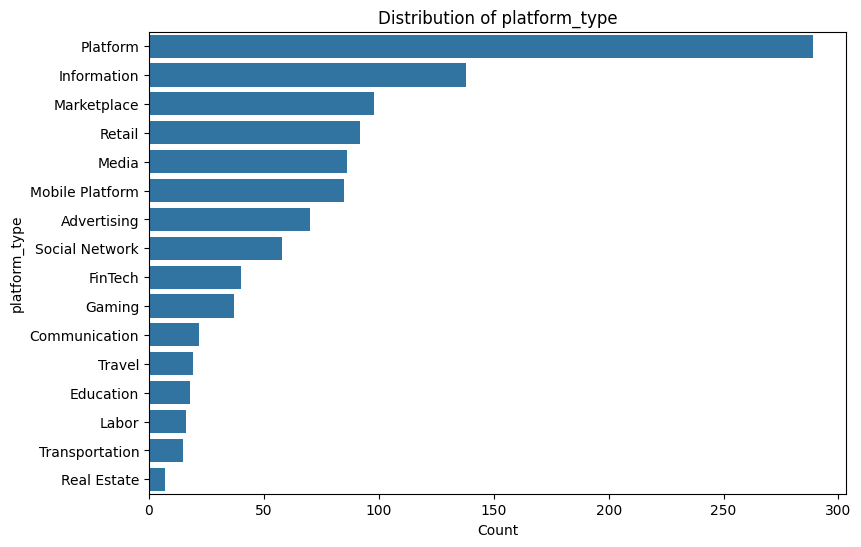

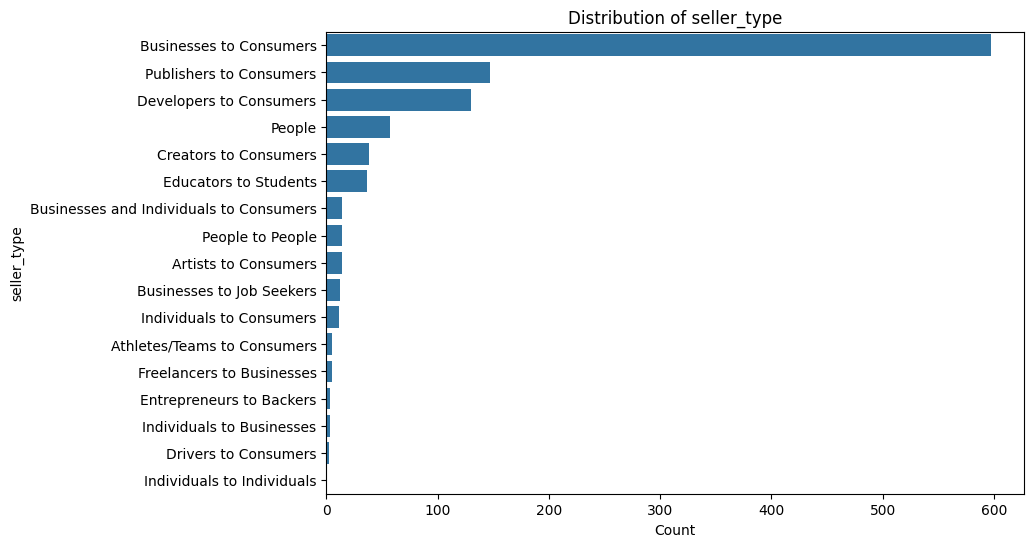

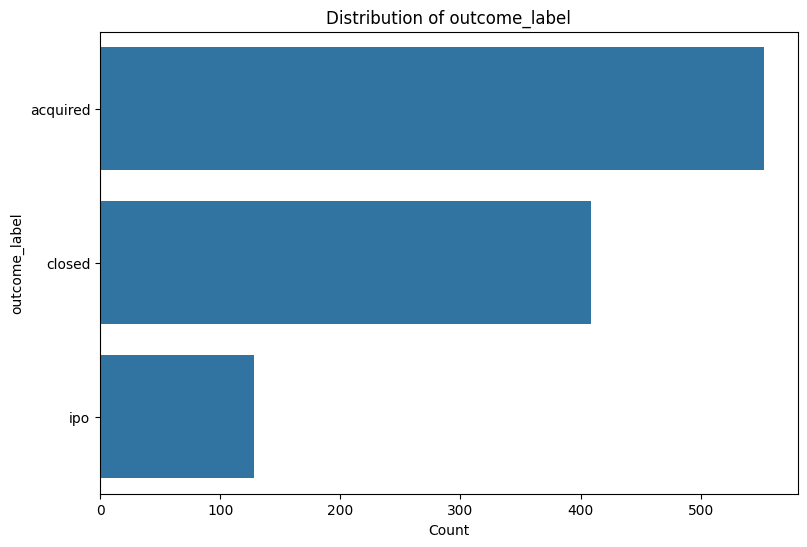

In [ ]:
#Create bar charts for visualizing some categorical
#columns in the dataset.
categorical_cols = ['platform_type',
                    'seller_type',
                    'outcome_label']

#Initialize the figure size.
plt.figure(figsize=(18, 15))


#Loop through each cateogrical column.
for col in categorical_cols:

    #For each one, create a plt figure.
    plt.figure(figsize=(9, 6))

    #Setup the figure with the data, and the axis
    #(Note, columns are in the y axis because, there do
    #not fit in the x axis)
    sns.countplot(data=startup_df, y=col,
                  order=startup_df[col].value_counts().index)

    #Show the title, and axis labels.
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

    #Show the figures.
    plt.show()

The next couple of graphs showcase geograhic distributions of the data. Unsurprisingly, the US has the most number of startups, possibly due to the entrepreneurship culture and more opportunities. Furthermore, San Fransisco, California has the greatest number of startups, due to Silicon Valley being situated there, and all of the Technology VC space being in that area.

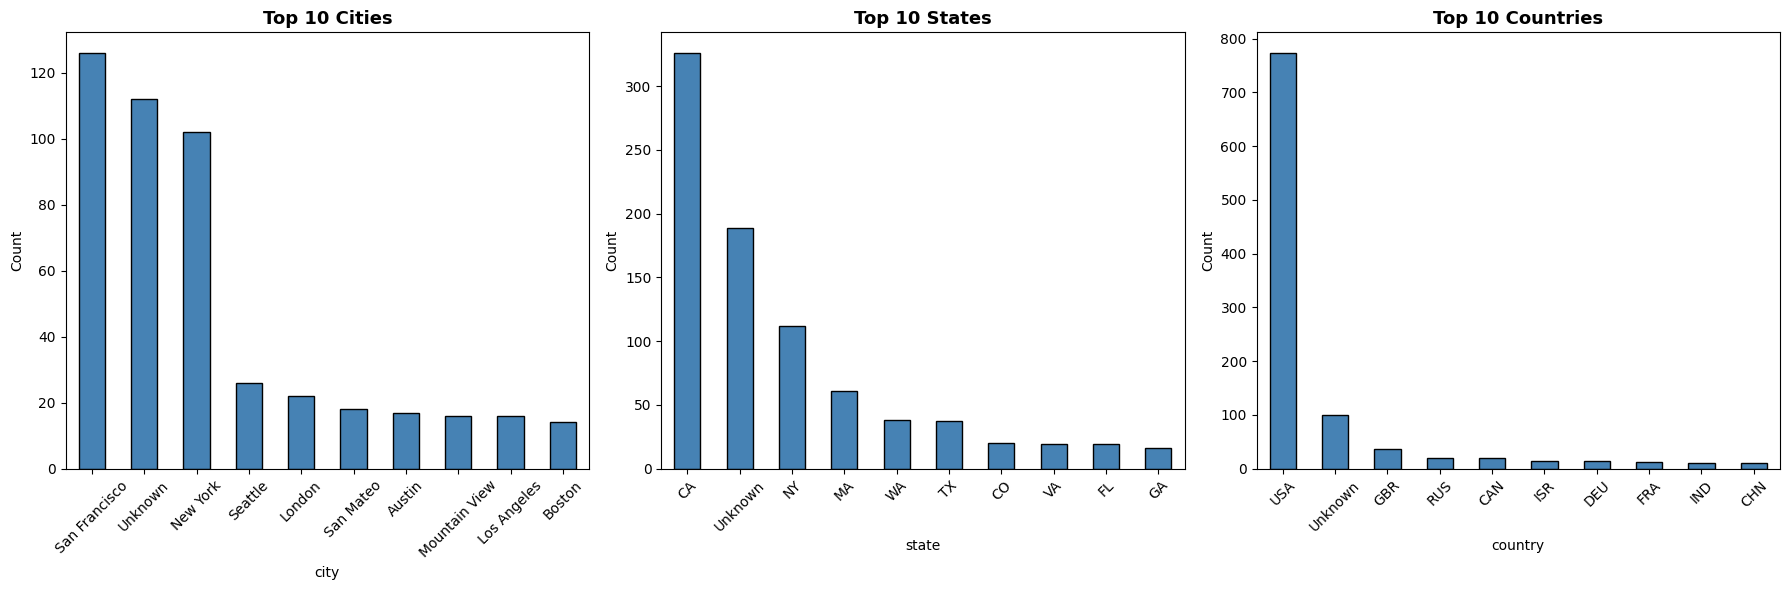

In [ ]:
#Creating visuals for the geographic columns
#of the dataset.

#Function to help find the top 10 georgraphic
#region for each column.
def plot_top10_bar(df, col, ax, title):
    # Get top 10 most frequent values
    top10 = df[col].value_counts().nlargest(10).index
    # Replace everything not in top 10 with 'Other'
    series = df[col].where(df[col].isin(top10))
    # Count frequencies (keep top 10 order, put Other at end)
    counts = series.value_counts()


    # Plot the graph, setup the title, labels, and
    #tick the labels so that they do not overflow.
    counts.plot(kind='bar',
                ax=ax,
                color='steelblue',
                edgecolor='black')

    ax.set_title(title,
                 fontsize=13,
                 fontweight='bold')

    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

#Show the graphs side by side.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#Call the function for each geographic column.
plot_top10_bar(startup_df, 'city',
               axes[0], 'Top 10 Cities')
plot_top10_bar(startup_df, 'state',
               axes[1], 'Top 10 States')
plot_top10_bar(startup_df, 'country',
               axes[2], 'Top 10 Countries')

#Tight layout to make sure hte graphs do not
#overflow with each other.
plt.tight_layout()

#Show the graphs.
plt.show()

In [ ]:
#Create a choropleth map to show how many startups
#are in each country.

#Create a counts dataframe for keeping track
#of each country and their corresponding
#number of startups.
country_counts = startup_df['country'] \
                      .value_counts() \
                      .reset_index()

#Define the columns of the dataset, and
#show the output.
country_counts.columns = ['country', 'count']
display(country_counts.head())

#Create some space for the choropleth map.
print('\n')


# Filter out 'Unknown' countries
country_counts_filtered = country_counts[
                country_counts['country'] != 'Unknown']

# Create the choropleth map
fig = px.choropleth(
    country_counts_filtered,
    locations='country',
    color='count',
    title='Global Distribution of Platform Startups',
    color_continuous_scale='Viridis',
    labels={'count': 'Number of Startups'}
)

#Show the figure
fig.show()

,country,count
0,USA,773
1,Unknown,100
2,GBR,36
3,RUS,20
4,CAN,19


In [ ]:
#Create a choropleth map showing how many
#startups are in each US state.


#Filter for startups in the US and that have known
#states.
us_startups = startup_df[(startup_df['country'] == 'USA')
                      & (startup_df['state'] != 'Unknown')]

#Create a counts dataframe for keeping track
#of each state and their corresponding
#number of startups.
state_counts = us_startups['state'] \
                    .value_counts() \
                    .reset_index()

#Define the columns of the dataset, and
#show the output.
state_counts.columns = ['state', 'count']
display(state_counts.head())

#Create some space for the choropleth.
print('\n')


# Create the US choropleth map
fig_us = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    title='Distribution of Platform Startups Across US States',
    color_continuous_scale='Viridis',
    labels={'count': 'Number of Startups'}
)

#Show the figure
fig_us.show()

,state,count
0,CA,325
1,NY,112
2,MA,61
3,WA,38
4,TX,37


In [ ]:
#Create a choropleth map for startups in California.

#Filter for startups that are specifically in California.
ca_startups = us_startups[us_startups['state'] == 'CA']


#Create a counts dataframe for keeping track
#of each city and their corresponding
#number of startups.
ca_city_counts = ca_startups['city'] \
                      .value_counts() \
                      .reset_index()

#Define the columns of the dataset, and
#show the output.
ca_city_counts.columns = ['city', 'count']
display(ca_city_counts.head())

#Make some space for the other outputs.
print('\n')



#Convert the city names into lattitude and longitude
#coordinates so we can visualize them.


# Initialize Nominatim geolocator
geolocator = Nominatim(user_agent='startup_mapper')

# Helper function to geocode cities
def geocode_city(city_name):
    try:
        #Forces the search query to be only in California.
        query = f"{city_name}, California, USA"

        #Send the request to geolocator, to get latitude,
        #and longitude.
        location = geolocator.geocode(query, timeout=10)

        # Add delay to avoid rate limiting
        time.sleep(1)

        #If the location is found, we return
        #the latitude and longitude.
        if location:
            return location.latitude, location.longitude

        #If it does not find anything, return none.
        else:
            return None, None

    #Prevent the script from crashing if an exception
    #is thrown.
    except Exception as e:
        print(f"Error geocoding {city_name}: {e}")
        return None, None


# Create new latitude and longitude columns by using
#the newly created function.
ca_city_counts['latitude'], ca_city_counts['longitude'] =  \
              zip(*ca_city_counts['city'] \
              .apply(geocode_city))


# Display the first few rows to verify.
display(ca_city_counts.head())
print('\n')




# Drop rows with missing coordinates just in case
ca_city_counts_mapped = ca_city_counts.dropna(
                          subset=['latitude', 'longitude'])

#Makes each city in CA a dot on the map.
fig_ca = px.scatter_mapbox(
    #Input our dataset.
    ca_city_counts_mapped,

    #Where to place each point.
    lat='latitude',
    lon='longitude',

    #Adjust bubble size.
    size='count',
    color='count',

    #Information to show when
    #hovering over a point on the
    #map.
    hover_name='city',
    hover_data={'latitude': False,
                'longitude': False,
                'count': True},

    #Set the color-gradient,based on
    #number of startups.
    color_continuous_scale='Viridis',

    #Maximum size for hte dots.
    size_max=30,

    #Zoom in the map.
    zoom=5,

    #Center the map on California.
    center={'lat': 36.7783,
            'lon': -119.4179},

    #Adjust the style of the map.
    mapbox_style='carto-positron',

    #Add the title of the dataset.
    title='Distribution of Startups Across California Cities'
)

#Show the figure.
fig_ca.show()

,city,count
0,San Francisco,126
1,San Mateo,18
2,Mountain View,16
3,Los Angeles,16
4,Sunnyvale,13


,city,count,latitude,longitude
0,San Francisco,126,37.787936,-122.407520
1,San Mateo,18,37.496904,-122.333057
2,Mountain View,16,37.389389,-122.083210
3,Los Angeles,16,34.053691,-118.242766
4,Sunnyvale,13,37.368830,-122.036349


Below is the visualization of the outcome varaible. As expected, the successful cases are a lot more than the not successful one because they are more easily retrievable and well documented.

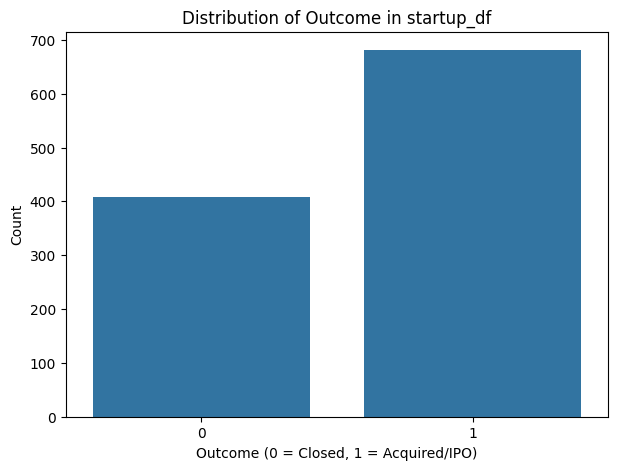

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=startup_df, x='outcome')
plt.title('Distribution of Outcome in startup_df')
plt.xlabel('Outcome (0 = Closed, 1 = Acquired/IPO)')
plt.ylabel('Count')
plt.show()

##Creating Dummy Columns

After Creating the visuals for the categorical columns, I transformed them into dummies to be processed for the Neural Network models. I decided to keep the top 10 most frequent classes in each of the categorical columns, and define all the rest ones as other, to help avoid creating too many dummies.

In [ ]:
# Identify categorical columns (excluding company_name and text)
cols_to_process = startup_df.select_dtypes(include=['object']).columns.tolist()
cols_to_process = [c for c in cols_to_process if c not in ['company_name', 'about_text', 'outcome_label']]

# Create a copy to modify
startup_df_limited = startup_df.copy()

for col in cols_to_process:
    # Find the top 10 most frequent categories
    top_10 = startup_df[col].value_counts().nlargest(10).index

    # Replace categories not in top 10 with 'Other'
    startup_df_limited[col] = startup_df[col].apply(lambda x: x if x in top_10 else 'Other')

# Create dummy variables for the processed columns
# We exclude company_name from dummies entirely as requested
startup_df_w_dummies = pd.get_dummies(
    startup_df_limited.drop(columns=['company_name']),
    columns=cols_to_process,
    drop_first=True
)

print(f"New shape with limited dummies: {startup_df_w_dummies.shape}")
print("Columns created:", [c for c in startup_df_w_dummies.columns if '_' in c][:20], "...")
startup_df_w_dummies.head()

New shape with limited dummies: (1090, 62)
Columns created: ['founded_year', 'first_funding_year', 'outcome_label', 'has_angel_investor', 'has_seed_funding', 'has_grant', 'has_accelerator', 'about_text', 'platform_type_FinTech', 'platform_type_Gaming', 'platform_type_Information', 'platform_type_Marketplace', 'platform_type_Media', 'platform_type_Mobile Platform', 'platform_type_Other', 'platform_type_Platform', 'platform_type_Retail', 'platform_type_Social Network', 'seller_type_Businesses and Individuals to Consumers', 'seller_type_Businesses to Consumers'] ...


,founded_year,first_funding_year,outcome_label,outcome,has_angel_investor,has_seed_funding,has_grant,has_accelerator,about_text,platform_type_FinTech,...,city_Mountain View,city_New York,city_Other,city_San Francisco,city_San Mateo,city_Seattle,city_Unknown,source_external_knowledge,source_investments_VC_csv,text_source_wayback_machine
0,2009,2009,acquired,1,0,1,0,0,Cookies Cart: 0 Login Sign Up Help Home Browse...,False,...,False,False,False,False,False,False,True,False,True,True
1,1990,2002,acquired,1,0,0,0,0,"170 Systems, Inc.",False,...,False,False,True,False,False,False,False,False,True,True
2,2007,2008,acquired,1,1,0,0,0,280 North was a developer tools company that b...,False,...,False,False,False,False,False,False,True,False,True,False
3,2005,2007,acquired,1,0,0,0,0,56.com was one of China's early video sharing ...,False,...,False,False,True,False,False,False,False,False,True,False
4,2007,2007,acquired,1,1,0,0,0,5min Media was a video distribution platform a...,False,...,False,True,False,False,False,False,False,False,True,False


##Wayback Machine Dataset

In this section, I ran all of the models by using the Wayback Machine Dataset. Here, I start by evaluating the binary performance of Models, then check the multiclass performances.

###Splitting the Dataset into Train/Test

I first start off splitting the dataset. Before splitting, I make sure to shuffle the data to avoid any ordering that could have been caused by the Webscraper. I then first split the data into X and Y, then further into validation and teest sets. Note: I separate the about text column from the X splits because that will be evaluated as a separate branch in most of the Neural Network Models.

In [ ]:
# Shuffle the full dataset before anything else
startup_df_w_dummies = startup_df_w_dummies \
                      .sample(frac=1, random_state=42) \
                      .reset_index(drop=True)

#Define X as our predictors, and y as our
#response variable.
X = startup_df_w_dummies.drop(['outcome','outcome_label'], axis=1)
y = startup_df_w_dummies['outcome']

# First split off the test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split the remainder into train (75%) and val (25%),
# giving a 60/20/20 overall split
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


#Adjusting columns so that we can implement our neural
#network and vectorizer.

#Separate the unstructured text column from the rest.
X_train_text = X_train['about_text']
X_val_text   = X_val['about_text']
X_test_text  = X_test['about_text']

#Drop the text column from the rest.
X_train_structured = X_train.drop('about_text', axis=1)
X_val_structured   = X_val.drop('about_text', axis=1)
X_test_structured = X_test.drop('about_text', axis=1)



#Convert the boolean columns into floats to
#make it easier for the neural network.
X_train_structured = X_train_structured.astype(float)
X_val_structured   = X_val_structured.astype(float)
X_test_structured  = X_test_structured.astype(float)

###Binary: Dummy Classifier

Find the Dummy Classifier as a benchmark for the other models. In this case, the accuracy of the majority rule is 62.39%

In [ ]:
#Determine the most common class in y_train
majority_class = y_train.value_counts().idxmax()
print(f"Majority Class in y_train: {majority_class}")

#Predict all classes in y_test as that most common class
y_pred_dummy = np.full(shape=y_test.shape, fill_value=majority_class)

#Calculate its accuracy
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
print(f"Dummy Classifier Accuracy: {dummy_accuracy:.4f}")


Majority Class in y_train: 1
Dummy Classifier Accuracy: 0.6239


###Binary: Simple Model, Just Text Vectorization.

For the text vectorization model, I used multi-hot encoding becaus we are not using embedings, and concatenated that vectorizer to our structured data to have on input to the neural network. As for its test set performance, it performs the same as the majority classifier, indicating that it does not provide any substantial improvement.

In [ ]:
#Define an object to store the simple text vectorization in Keras.
text_vectorization = keras.layers.TextVectorization(
    max_tokens = 20_000,
    output_mode="multi_hot"
)

#Apply the vectorizer ot our dataset to get the vocabulary.
text_vectorization.adapt(X_train_text)

In [ ]:
#Vectorize our text columns
X_train_text_vec = text_vectorization(X_train_text.values)
X_val_text_vec   = text_vectorization(X_val_text.values)
X_test_text_vec  = text_vectorization(X_test_text.values)



# Combine vectorized text with structured data
X_train_combined = np.concatenate(
    [X_train_text_vec.numpy(),
     X_train_structured.values.astype('float32')], axis=1)
X_val_combined   = np.concatenate(
    [X_val_text_vec.numpy(),
     X_val_structured.values.astype('float32')],   axis=1)
X_test_combined  = np.concatenate(
    [X_test_text_vec.numpy(),
     X_test_structured.values.astype('float32')],  axis=1)


# Rebuild the datasets with the combined data
train_ds = tf.data.Dataset.from_tensor_slices((X_train_combined, y_train.astype('float32')))
val_ds   = tf.data.Dataset.from_tensor_slices((X_val_combined,   y_val.astype('float32')))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test_combined,  y_test.astype('float32')))

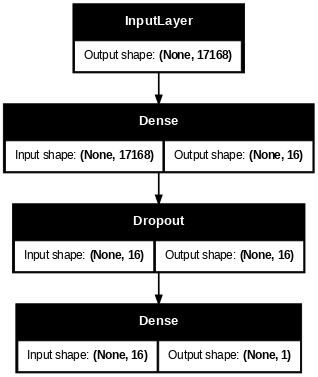

In [ ]:
# Update input shape to match your combined data
inputs = keras.Input(shape=(X_train_combined.shape[1],))

x = keras.layers.Dense(16, activation="relu")(inputs)
x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(1, activation="sigmoid")(x)

#Create and compile the model.
simple_model = keras.Model(inputs, outputs)
simple_model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

#Visualize the model.
keras.utils.plot_model(simple_model,show_shapes=True,dpi=60)

In [ ]:
#Train the model
history = simple_model.fit(
    train_ds.batch(32),
    epochs=10,
    validation_data=val_ds.batch(32)
)

#Evaluate on test set
test_loss, test_accuracy = simple_model.evaluate(test_ds.batch(32))
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.5902 - loss: 4.5020 - val_accuracy: 0.6239 - val_loss: 0.6914
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6254 - loss: 0.6905 - val_accuracy: 0.6239 - val_loss: 0.6894
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6254 - loss: 0.6885 - val_accuracy: 0.6239 - val_loss: 0.6875
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6254 - loss: 0.6866 - val_accuracy: 0.6239 - val_loss: 0.6857
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6254 - loss: 0.6848 - val_accuracy: 0.6239 - val_loss: 0.6839
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6254 - loss: 0.6830 - val_accuracy: 0.6239 - val_loss: 0.6822
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6254 - loss: 0.6814 - val_accuracy: 0.6239 - val_loss: 0.6807
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6254 - loss: 0.6798 - val_accuracy: 0.6239 - val_loss

###Binary: Embedding Model

Here, the embeding model slightly outperformed the benchmark, achieving a 65.14% Accuracy.

In [ ]:
#Adapt the text vectorizatoin to our
#text column in the training data.
text_vectorization.adapt(X_train_text.values)

#Get the number of structured columns
#for the input layer of the neural
#network model.
n_structured = X_train_structured.shape[1]

In [ ]:
#Defining the architecture to
#process the textual inputs of the
#data.

#Define the input layer.
text_input = keras.Input(shape=(1,),
                         dtype=tf.string,
                         name="text_input")

#Vectorize the data.
x_text = text_vectorization(text_input)

#Apply Relu Activation then a dropout layer.
x_text = keras.layers.Dense(64, activation="relu")(x_text)
x_text = keras.layers.Dropout(0.3)(x_text)

In [ ]:
#Defining the architecture to process
#the structured inputs of the data.

#Define the input layer, with the same
#dimensions as our structured columns.
struct_input = keras.Input(shape=
        (n_structured,), name="struct_input")


#Apply a relu activation and a dropout layer
#for our structured inputs.
x_struct = keras.layers.Dense(32, activation="relu")(struct_input)
x_struct = keras.layers.Dropout(0.3)(x_struct)

In [ ]:
#Combine the textual and structured nodes into
#one layer.
combined = keras.layers.Concatenate()([x_text, x_struct])

#Apply another relu activation.
x = keras.layers.Dense(32, activation="relu")(combined)

#Output the function as a sigmoid.
output = keras.layers.Dense(1, activation="sigmoid")(x)

In [ ]:
#Apply the model with  text and structured
#inputs(Note we are not inputting our data
#this is just a blueprint for the model!)
embeding_model = keras.Model(inputs=[text_input, struct_input], outputs=output)

#Compile the model.
embeding_model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

#Show the embeding_model summary.
embeding_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 17109)     │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ struct_input        │ (None, 59)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │  1,095,040 │ text_vectorizati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      1,920 │ struct_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      3,104 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         33 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,100,097 (4.20 MB)

 Trainable params: 1,100,097 (4.20 MB)

 Non-trainable params: 0 (0.00 B)

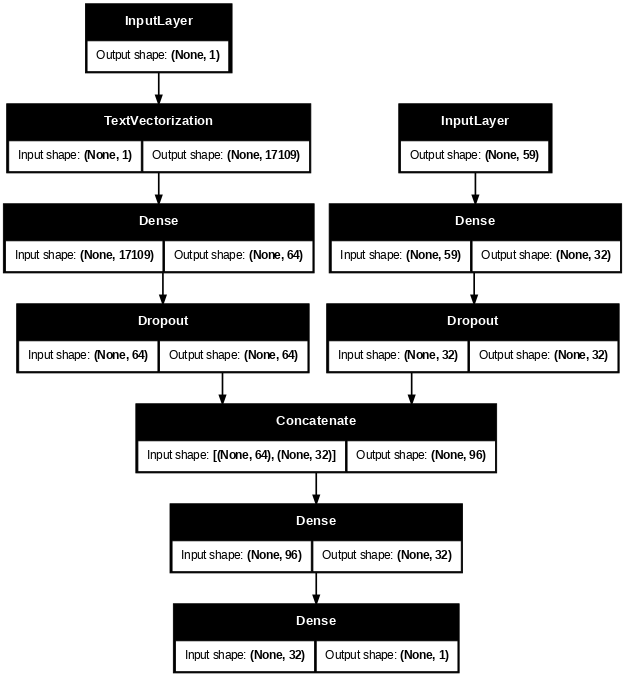

In [ ]:
#Plot the model.
keras.utils.plot_model(embeding_model,
                        show_shapes=True,
                        dpi=60)

In [ ]:
#Fit the model onto our data. Note: it is
#harder for tensors to deal with separate
#inputs and this project does not
#levrage the tensor benefits so we
#used numpy arrays for this.
history = embeding_model.fit(
    (X_train_text.values,

    X_train_structured
                .values
                .astype('float32')),

    y_train.values,

    validation_data=(
        (X_val_text.values,

        X_val_structured
                  .values
                  .astype('float32')),

        y_val.values
    ),
    epochs=10,
    batch_size=32
)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4465 - loss: 80.5520 - val_accuracy: 0.6239 - val_loss: 37.0563
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5107 - loss: 39.4798 - val_accuracy: 0.3761 - val_loss: 6.0521
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5076 - loss: 25.6721 - val_accuracy: 0.5321 - val_loss: 1.7054
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5352 - loss: 17.0153 - val_accuracy: 0.6239 - val_loss: 11.5189
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5627 - loss: 14.1769 - val_accuracy: 0.6239 - val_loss: 17.6865
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5520 - loss: 13.1462 - val_accuracy: 0.4220 - val_loss: 6.4934
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5979 - loss: 10.2003 - val_accuracy: 0.4450 - val_loss: 6.2449
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6239 - loss: 7.8387 - val_accuracy: 

In [ ]:
#Evaluate the model's performance on the test set.
test_loss_emb, test_acc_emb = embeding_model.evaluate(
    (X_test_text.values, X_test_structured.values.astype('float32')),
    y_test.values,
    verbose=0
)
print(f"Embedding Model Test Accuracy: {test_acc_emb:.4f}")
print(f"Embedding Model Test Loss: {test_loss_emb:.4f}")

Embedding Model Test Accuracy: 0.6514
Embedding Model Test Loss: 2.4939


###Binary: RNN-s with Embeddings

For the RNNs, I decided to write a helper function which basically loops through each RNN layer and applies to my dataset. The unfortunate part here is that all these models perfomed exactly the same as the benchmark, indicating no huge improvement.

In [ ]:
#Now, for testing out various types
#of RNNs while also keeping the relative
#network structure the same, to have
#a more accurate comparison of the models,
#I have created a function that builds the
#model and takes an RNN layer as the input.

def build_rnn_model(rnn_layer):
    '''Helper funciton to run various RNN models
    by just changing one rnn_layer input.'''


    #Retrieving a good Max_length argument
    #to be used in our text vectorizer for RNN.

    #Get the text lengths for the about_me data
    text_lenghts = X_train_text \
                .str.split() \
                .str.len()

    #Retrieve the 95th percentile of the lengths,
    #to avoid being to get a sweetspot max-length.
    text_lenght_95th_percentile = int(text_lenghts \
                                .quantile(0.95))



    #Re-define the number of structured columns
    #for an input to the structured portion
    #of the model.
    n_structured = X_train_structured.shape[1]


    #In order to apply an RNN we would have
    #to define a new vectorizer which
    #gives integers.


    #Note we add padding because RNNs
    #expect all inputs to be of the same
    #length.
    text_vectorization_for_rnn =  \
      keras.layers.TextVectorization(
        max_tokens = 20_000,
        output_mode = 'int',
        output_sequence_length = text_lenght_95th_percentile
    )


    #Have the vectorizer learn the vocabulary
    #of our text.
    text_vectorization_for_rnn.adapt(
            X_train_text.values)

    #The text branch of the architecture.
    text_input = keras.Input(shape=(1,),
                             dtype=tf.string,
                             name="text_input")
    x_text = text_vectorization_for_rnn(text_input)
    x_text = keras.layers.Embedding(20_000, 64)(x_text)
    x_text = rnn_layer(x_text) #The only part that changes.
    x_text = keras.layers.Dropout(0.3)(x_text)


    #The Structured branch of the architecture.
    struct_input = keras.Input(shape=(n_structured,),
                               name="struct_input")
    x_struct = keras.layers.Dense(32, activation="relu")(struct_input)
    x_struct = keras.layers.Dropout(0.3)(x_struct)


    #Merge the two branches together.
    combined = keras.layers.Concatenate()(
                      [x_text, x_struct])
    x = keras.layers.Dense(32, activation="relu")(combined)
    output = keras.layers.Dense(1, activation="sigmoid")(x)

    #Define the model and compile it.
    rnn_model = keras.Model(
        inputs=[text_input, struct_input],
        outputs=output)

    rnn_model.compile(optimizer="rmsprop",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])


    #Return the rnn_model.
    return rnn_model

In [ ]:
#Creating a dictionary with the models we want
#to try and their respective rnn_layers.
rnn_models = {
    "SimpleRNN":      keras.layers.SimpleRNN(64),
    "LSTM":           keras.layers.LSTM(64),
    "GRU":            keras.layers.GRU(64),
    "Bi-SimpleRNN":   keras.layers.Bidirectional(keras.layers.SimpleRNN(64)),
    "Bi-LSTM":        keras.layers.Bidirectional(keras.layers.LSTM(64)),
    "Bi-GRU":         keras.layers.Bidirectional(keras.layers.GRU(64)),
}

#Define an empty list for the results.
results = []



for model_name, rnn_layer in rnn_models.items():

    #Print statementts to show pretty formatting
    #as the models are being trained.
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    # Build the model
    model = build_rnn_model(rnn_layer)

    #Fit the model to our data.
    history = model.fit(
        (X_train_text.values, X_train_structured.values.astype('float32')),
        y_train.values,
        validation_data=(
            (X_val_text.values, X_val_structured.values.astype('float32')),
            y_val.values
        ),
        epochs=10,
        batch_size=32,
    )

    #Average validation accuracy across all epochs
    #so we can more directly compare across models.
    avg_val_acc  = sum(history.history['val_accuracy']) / len(history.history['val_accuracy'])
    avg_val_loss = sum(history.history['val_loss'])     / len(history.history['val_loss'])

    #Evaluate on test set.
    test_loss, test_acc = model.evaluate(
        (X_test_text.values, X_test_structured.values.astype('float32')),
        y_test.values,
        verbose=0
    )

    #Store everything.
    results.append({
        "Model":            model_name,
        "Avg Val Accuracy": round(avg_val_acc,  4),
        "Avg Val Loss":     round(avg_val_loss,  4),
        "Test Accuracy":    round(test_acc,  4),
        "Test Loss":        round(test_loss, 4),
    })

    #Show the Test Accuracy of the model.
    print(f"Done! Test Accuracy: {test_acc:.4f}")

#Print out a nice summary model showing the
#result.
results_df = pd.DataFrame(results).set_index("Model")
print("\n\n===== SUMMARY TABLE =====")
print(results_df.to_string())


Training: SimpleRNN
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 437ms/step - accuracy: 0.4572 - loss: 114.2024 - val_accuracy: 0.6239 - val_loss: 24.7637
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 414ms/step - accuracy: 0.5275 - loss: 39.0071 - val_accuracy: 0.6239 - val_loss: 1.1066
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 423ms/step - accuracy: 0.5474 - loss: 22.8922 - val_accuracy: 0.3761 - val_loss: 2.9612
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 415ms/step - accuracy: 0.5183 - loss: 13.1881 - val_accuracy: 0.3761 - val_loss: 5.0501
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 419ms/step - accuracy: 0.4969 - loss: 11.8086 - val_accuracy: 0.3761 - val_loss: 1.0471
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 409ms/step - accuracy: 0.5382 - loss: 8.1696 - val_accuracy: 0.3761 - val_loss: 4.2122
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 413ms/step - accuracy: 0.5550 - loss: 7.2135 - val_accuracy: 0.3761 - val_loss: 0.8423
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 423ms/step - accuracy: 0.5275 - lo

###Binary: Using Attention Weights with simple QKV

Here I applied a simple QKV attention on my dataset which again performed about the same as the benchmark.

In [ ]:
#Setup text vectorization for simple attention.
text_vectorization_for_QKV = keras.layers.TextVectorization(
    output_mode="int",
    max_tokens=20_000, # Use a reasonable number of tokens for the vocabulary
    output_sequence_length=200
)

#Create the vocabulary based on our text data.
text_vectorization_for_QKV.adapt(X_train_text.values)

In [ ]:
#Define the text branch.

#Define a max_length and vocab_size
#to be used later.
MAX_LENGTH = 200 # Aligned with text_vectorization_for_QKV.output_sequence_length
VOCAB_SIZE = 20_000 + 1 # Aligned with text_vectorization_for_QKV.max_tokens + 1



#Define the input and embeding layers.
about_input = keras.Input(shape=(MAX_LENGTH,), name='about_input')
about_emb = layers.Embedding(VOCAB_SIZE, 32)(about_input)

#Define our attention weights.
Q = about_emb
K = about_emb
V = about_emb

#Apply self attention because the column
#would only be looking at itself.
attention = layers.Attention()([Q, K, V])


#Flatten the 3 vectors from Q,K,V into one
#vector, apply a relu, and dropout.
text_pooled = layers.GlobalAveragePooling1D()(attention) # Changed from Flatten to GlobalAveragePooling1D
text_dense = layers.Dense(64, activation='relu')(text_pooled) # Now receives (None, 32)
text_out = layers.Dropout(0.3)(text_dense)


#Define the structured branch.

#Define the number of structured columns for our
#input layer.
n_structured = X_train_structured.shape[1]

#Input layer for structured branch, apply a relu,
#and dropout, then relu again.
struct_input = keras.Input(shape=(n_structured,),
                           name='struct_input')
s = layers.Dense(64, activation="relu")(struct_input)
s = layers.Dropout(0.3)(s)
struct_out = layers.Dense(32, activation="relu")(s)



#Merge the text and structured branch, do a relu,
#then a sigmoid to give out one prediction.
merged = layers.Concatenate()([text_out, struct_out])
merged = layers.Dense(32, activation="relu")(merged)
output = layers.Dense(1, activation="sigmoid")(merged)


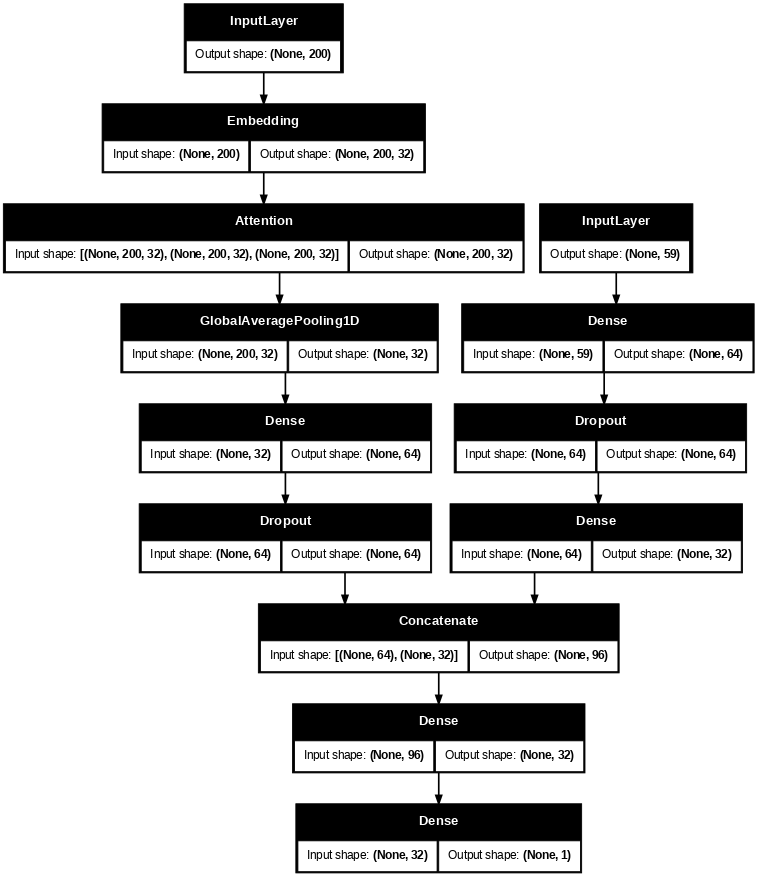

In [ ]:
#Define the model blueprint.
simple_QKV_model = keras.Model(
    inputs=[about_input, struct_input],
    outputs=output
)

#Compile the model.
simple_QKV_model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

#Plot the model.
keras.utils.plot_model(simple_QKV_model,
                           show_shapes=True,
                           dpi=60)

In [ ]:
# Tokenize and pad the text data for the simple_QKV_model
X_train_text_padded_QKV = text_vectorization_for_QKV(X_train_text.values)
X_val_text_padded_QKV = text_vectorization_for_QKV(X_val_text.values)
X_test_text_padded_QKV = text_vectorization_for_QKV(X_test_text.values)

#Fit the model to our data.
history = simple_QKV_model.fit(
    x=[X_train_text_padded_QKV, X_train_structured.values.astype("float32")],
    y=y_train.values,
    validation_data=(
        [X_val_text_padded_QKV, X_val_structured.values.astype("float32")],
        y_val.values
    ),
    epochs=20,
    batch_size=16,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                      patience=3,
                                      restore_best_weights=True)
    ]
)



#Evaluate on test set
test_loss, test_acc = simple_QKV_model.evaluate(
    [X_test_text_padded_QKV, X_test_structured.values.astype("float32")],
    y_test.values
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.5535 - loss: 17.3659 - val_accuracy: 0.6239 - val_loss: 8.9986
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5306 - loss: 10.3349 - val_accuracy: 0.6239 - val_loss: 7.9635
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5505 - loss: 6.6236 - val_accuracy: 0.6239 - val_loss: 1.8649
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5260 - loss: 6.0579 - val_accuracy: 0.6239 - val_loss: 5.8579
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.6239 - loss: 9.0014
Test Loss:     9.0014
Test Accuracy: 0.6239


###Binary: Using Keras Multi-Head

Here I applied Keras Multi-Head which unfortunately, also performed about the same as the benchmark.

In [ ]:
#Define variables for the layers.
MAX_LENGTH = 256
VOCAB_SIZE = 10_001
EMBED_DIM  = 32
NUM_HEADS  = 2

#Initiliaze the vectorizer.
text_vectorizer = keras.layers.TextVectorization(
    max_tokens=10000,
    output_mode="int",
    output_sequence_length=MAX_LENGTH
)

#Adapt it to our vocabulary.
text_vectorizer.adapt(X_train_text.values)

#Pad X_train, X_val, and X_test to be the same length.
X_train_padded = text_vectorizer(X_train_text.values)
X_val_padded   = text_vectorizer(X_val_text.values)
X_test_padded  = text_vectorizer(X_test_text.values)


#Text Branch.

#Dfine the input and embedings.
about_input = keras.Input(shape=(MAX_LENGTH,), name="about_input")
about_emb   = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(about_input)

#Define the QKV.
Q = about_emb
K = about_emb
V = about_emb

#Apply multi-head attention.
attended = layers.MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM // NUM_HEADS
)(Q, V, K)

#Flatten for Dimensionality purposes,
#and apply a relu and some dropout.
text_flat  = layers.Flatten()(attended)
text_dense = layers.Dense(64, activation="relu")(text_flat)
text_out   = layers.Dropout(0.3)(text_dense)

#Structured Branch.
n_structured = X_train_structured.shape[1]

struct_input = keras.Input(shape=(n_structured,), name="struct_input")
s            = layers.Dense(64, activation="relu")(struct_input)
s            = layers.Dropout(0.3)(s)
struct_out   = layers.Dense(32, activation="relu")(s)

#Merge the sturctured and text branches.
merged = layers.Concatenate()([text_out, struct_out])
merged = layers.Dense(32, activation="relu")(merged)
output = layers.Dense(1, activation="sigmoid")(merged)

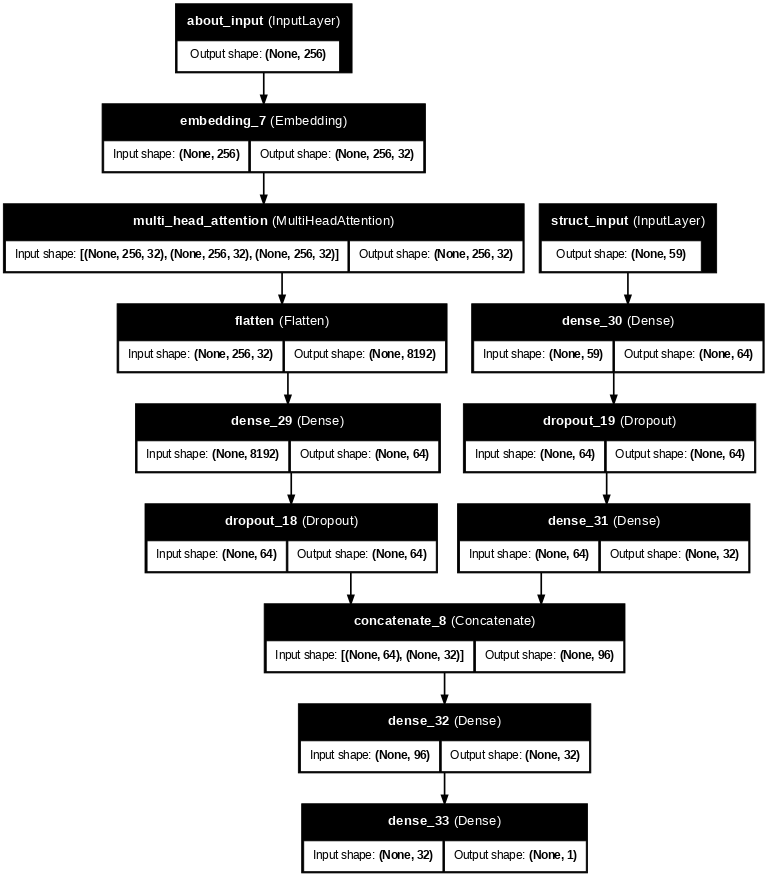

In [ ]:
#Build the blueprint and compile the model.
model = keras.Model(inputs=[about_input, struct_input], outputs=output)

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

#Plot the model.
keras.utils.plot_model(model, show_shapes=True, dpi=60, show_layer_names=True)

In [ ]:
#Fit the model on our data.
history = model.fit(
    x=[X_train_padded, X_train_structured.values.astype("float32")],
    y=y_train.values,
    validation_data=(
        [X_val_padded, X_val_structured.values.astype("float32")],
        y_val.values
    ),
    epochs=20,
    batch_size=16,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                      patience=3,
                                      restore_best_weights=True)
    ]
)

#Evaluate the model, and check its performance on the test data.
test_loss, test_acc = model.evaluate(
    [X_test_padded, X_test_structured.values.astype("float32")],
    y_test.values
)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.5168 - loss: 30.8828 - val_accuracy: 0.6239 - val_loss: 9.8851
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5076 - loss: 9.6549 - val_accuracy: 0.6239 - val_loss: 3.2656
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5459 - loss: 5.2585 - val_accuracy: 0.3761 - val_loss: 1.4421
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5214 - loss: 3.5846 - val_accuracy: 0.6239 - val_loss: 0.7210
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6239 - loss: 9.8876
Test Loss:     9.8876
Test Accuracy: 0.6239


###Multi-Class Testing

In this section, I tested the same Wayback machine dataset, but this time for a multiclass situation. Most of the models here have the same architecture except for the actiavtion function being Softmax and the loss function changing from binary cross entropy to sparse categorical cross entropy.

In [ ]:
#Map our outcome_label into integers so that
#it is easier for our models.
label_map = {'closed': 0, 'acquired': 1, 'ipo': 2}



#Redefine our y for Softmax as the outcome_label and map
#it to the dictionary we have above.
y_m = startup_df_w_dummies['outcome_label'].map(label_map)

#Re-split but this time using our new y_m.
X_temp_m, X_test_m, y_temp_m, y_test_m = train_test_split(
    X, y_m, test_size=0.2, random_state=42, stratify=y_m
)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(
    X_temp_m, y_temp_m,
    test_size=0.25, random_state=42, stratify=y_temp_m
)

#Separate text and structured columns(same as before, just new y).
X_train_text_m  = X_train_m['about_text']
X_val_text_m  = X_val_m['about_text']
X_test_text_m  = X_test_m['about_text']

X_train_structured_m = X_train_m.drop('about_text', axis=1).astype(float)
X_val_structured_m   = X_val_m.drop('about_text', axis=1).astype(float)
X_test_structured_m  = X_test_m.drop('about_text', axis=1).astype(float)

#Class weights so that the model does not just learn to predict the
#most common thing in the dataset.
#This also applies to the real world scenario that VC firms would
#want to use a model like this to hedge against the failures.


#Takes the classes in y and basically
#applies a formula to give higher weights
#for rarer classes and lower weights for
#more frequent classes.
class_weights_m = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_m),
    y=y_train_m
)


#Enumerate the weights into dictionaries
#to make it easier for keras to use.
class_weight_dict_m = dict(
                enumerate(class_weights_m))
print("Class weights:", class_weight_dict_m)

Class weights: {0: np.float64(0.889795918367347), 1: np.float64(0.6566265060240963), 2: np.float64(2.831168831168831)}


####Multi-Class: Dummy Classifier

Here, I checked for benchmark performances on my data. The majority class yielded a 50.92% accuracy while the random guesser got a 33.3% accuracy.

In [ ]:
#Check the class distribution in the full
#dataset.

#Count how many of each class is within
#the outcome column.
label_counts = y_m.value_counts() \
                  .sort_index()

#Decode those numbers into the actual
#names for readability.
label_names  = {0: 'closed',
                1: 'acquired',
                2: 'ipo'}

#Fancy formatting to get a readable
#output.
print("=== Class Distribution ===")
for label, count in label_counts.items():
    print(f"  {label_names[label]:>10}: {count:>4} ({count/len(y_m):.1%})")

#Benchmark 1: Always predict the majority class.
#Determine the most common class in y_train_m
label_names = {0: 'closed', 1: 'acquired', 2: 'ipo'}
majority_class_m = y_train_m.value_counts().idxmax()
print(f"Majority Class in y_train_m: {majority_class_m} ({label_names[majority_class_m]})")

#Predict all classes in y_test_m as that most common class
y_pred_dummy_m = np.full(shape=y_test_m.shape, fill_value=majority_class_m)

#Calculate its accuracy
majority_class_acc_m = accuracy_score(y_test_m, y_pred_dummy_m)
print(f"Dummy Classifier (Multiclass) Test Accuracy: {majority_class_acc_m:.4f}")

#Benchmark 2: Random guessing (1/3 since there are 3 classes).
print(f"Random Guess Benchmark:   {1/3:.4f} ({1/3:.1%})")

=== Class Distribution ===
      closed:  409 (37.5%)
    acquired:  553 (50.7%)
         ipo:  128 (11.7%)
Majority Class in y_train_m: 1 (acquired)
Dummy Classifier (Multiclass) Test Accuracy: 0.5092
Random Guess Benchmark:   0.3333 (33.3%)


####Multi-Class: Just-Text Vectorization

The text vectorier in this case was only able to achieve a 38% accuracy significantly less than the majority class benchmark.

In [ ]:
#Create and adapt a fresh vectorizer on multiclass training text.
text_vectorization_m = keras.layers.TextVectorization(
    max_tokens=20_000,
    output_mode='multi_hot'
)

text_vectorization_m.adapt(X_train_text_m.values)

#Vectorize.
X_train_text_vec_m = text_vectorization_m(X_train_text_m.values).numpy()
X_val_text_vec_m   = text_vectorization_m(X_val_text_m.values).numpy()
X_test_text_vec_m  = text_vectorization_m(X_test_text_m.values).numpy()

#Combine text + structured into one flat input (same as binary simple model).
X_train_combined_m = np.concatenate([X_train_text_vec_m,
                                      X_train_structured_m.values.astype('float32')], axis=1)
X_val_combined_m   = np.concatenate([X_val_text_vec_m,
                                      X_val_structured_m.values.astype('float32')], axis=1)
X_test_combined_m  = np.concatenate([X_test_text_vec_m,
                                      X_test_structured_m.values.astype('float32')], axis=1)

#Build the model — only the output layer changes
#as compared to previous binary outcome variable.
inputs_m  = keras.Input(shape=(X_train_combined_m.shape[1],))
x_m = keras.layers.Dense(16, activation='relu')(inputs_m)
x_m  = keras.layers.Dropout(0.5)(x_m)
outputs_m = keras.layers.Dense(3, activation='softmax')(x_m)  # 3 classes


#Initialize the model object and compile it.
simple_model_m = keras.Model(inputs_m, outputs_m)
simple_model_m.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',  # works with integer labels
    metrics=['accuracy']
)


#Fit the model to our dataset.
history_simple_m = simple_model_m.fit(
    X_train_combined_m, y_train_m.values,
    validation_data=(X_val_combined_m, y_val_m.values),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict_m
)


#Retrieve the perfroamcne scores of the model.
test_loss_simple_m, test_acc_simple_m = simple_model_m.evaluate(
    X_test_combined_m, y_test_m.values, verbose=0
)
print(f"Simple Model (Multiclass) — Test Accuracy: {test_acc_simple_m:.4f} | Loss: {test_loss_simple_m:.4f}")

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.3807 - loss: 8.7682 - val_accuracy: 0.5046 - val_loss: 1.0950
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5076 - loss: 1.0987 - val_accuracy: 0.5046 - val_loss: 1.0955
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4190 - loss: 1.0988 - val_accuracy: 0.5046 - val_loss: 1.0961
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5076 - loss: 1.0987 - val_accuracy: 0.5046 - val_loss: 1.0965
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5076 - loss: 1.0988 - val_accuracy: 0.5046 - val_loss: 1.0963
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4052 - loss: 1.0988 - val_accuracy: 0.5046 - val_loss: 1.0966
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4281 - loss: 1.0987 - val_accuracy: 0.5046 - val_loss: 1.0963
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5076 - loss: 1.0988 - val_accuracy: 0.3761 - val_loss

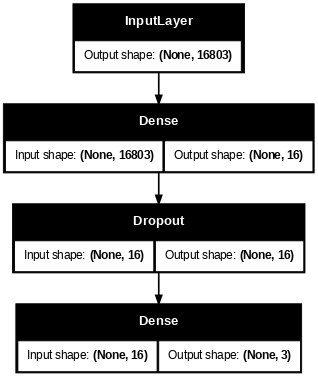

In [ ]:
#Visualize the architecture.
keras.utils.plot_model(simple_model_m, show_shapes=True, dpi=60)

####Multi-Class: Embeding Model

The Embeding Model here was only able to achieve a 37.6% accuracy which is also worse than the marjoity class benchmark.

In [ ]:
#Create the vectorizer and adapt our data to it for our embeding layer.
text_vectorization_emb_m = keras.layers.TextVectorization(
    max_tokens=20_000,
    output_mode='int', #The key difference with the previous vectorizer.
    output_sequence_length=int(X_train_text_m.str.split().str.len().quantile(0.95))
)

text_vectorization_emb_m.adapt(X_train_text_m.values)

#Define the number of structured inputs
#as a separate variable.
n_structured_m = X_train_structured_m.shape[1]

#Text branch.
text_input_m = keras.Input(shape=(1,), dtype=tf.string, name="text_input")
x_text_m     = text_vectorization_emb_m(text_input_m)
x_text_m     = keras.layers.Embedding(20_000, 64)(x_text_m)
x_text_m     = keras.layers.GlobalAveragePooling1D()(x_text_m)
x_text_m     = keras.layers.Dense(64, activation='relu')(x_text_m)
x_text_m     = keras.layers.Dropout(0.3)(x_text_m)

#Structured branch.
struct_input_m = keras.Input(shape=(n_structured_m,), name="struct_input")
x_struct_m     = keras.layers.Dense(32, activation='relu')(struct_input_m)
x_struct_m     = keras.layers.Dropout(0.3)(x_struct_m)

#Merge.
combined_m  = keras.layers.Concatenate()([x_text_m, x_struct_m])
x_m         = keras.layers.Dense(32, activation='relu')(combined_m)
output_m    = keras.layers.Dense(3, activation='softmax')(x_m)  # 3 classes



#Initialize the model and compile it.
embedding_model_m = keras.Model(
    inputs=[text_input_m, struct_input_m],
    outputs=output_m
)

embedding_model_m.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



#Fit the model with our data.
history_emb_m = embedding_model_m.fit(
    (X_train_text_m.values, X_train_structured_m.values.astype('float32')),
    y_train_m.values,
    validation_data=(
        (X_val_text_m.values, X_val_structured_m.values.astype('float32')),
        y_val_m.values
    ),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict_m
)

#Retrieve the performance results.
test_loss_emb_m, test_acc_emb_m = embedding_model_m.evaluate(
    (X_test_text_m.values, X_test_structured_m.values.astype('float32')),
    y_test_m.values, verbose=0
)
print(f"Embedding Model (Multiclass) — Test Accuracy: {test_acc_emb_m:.4f} | Loss: {test_loss_emb_m:.4f}")

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3639 - loss: 96.4094 - val_accuracy: 0.4128 - val_loss: 32.4018
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3639 - loss: 50.4810 - val_accuracy: 0.3761 - val_loss: 16.2158
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3532 - loss: 35.9554 - val_accuracy: 0.3761 - val_loss: 32.0035
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3287 - loss: 27.2853 - val_accuracy: 0.3761 - val_loss: 11.5729
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3456 - loss: 24.5375 - val_accuracy: 0.1193 - val_loss: 32.4543
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3287 - loss: 20.6355 - val_accuracy: 0.3761 - val_loss: 11.7883
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3058 - loss: 15.8846 - val_accuracy: 0.3761 - val_loss: 16.8296
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3196 - loss: 13.2756 - val_accur

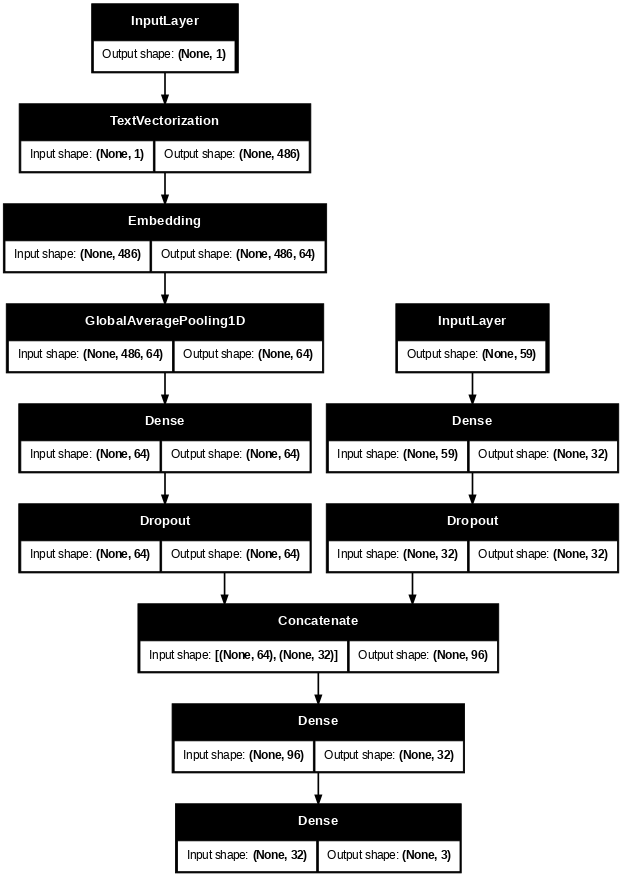

In [ ]:
#Visualize the architecture.
keras.utils.plot_model(embedding_model_m, show_shapes=True, dpi=60)

####Multi-Class: RNNs with Embedings

Among the RNN models, only the Bi-LSTM and Bi-GRU were able to beat the majority class benchmark at 52.29% and 53.21% accuracies.

In [ ]:
#Define the aggreagte model to be
#used so that we can test out a variety
#RNN architectures.
def build_rnn_model_m(rnn_layer):
    '''Multiclass version of the
    RNN builder (3-class softmax output).'''


    #Determine the text length of the text column,
    #and define the max length so that we can
    #standardize the lengths of all the columns.
    text_lengths_m = X_train_text_m.str.split().str.len()
    max_len_m = int(text_lengths_m.quantile(0.95))

    #Determine the number of structured columns for the
    #Structured branch input.
    n_structured_m = X_train_structured_m.shape[1]

    #Define our Text vectorizer and adapt it to
    #our about_me column.
    text_vec_rnn_m = keras.layers.TextVectorization(
        max_tokens=20_000,
        output_mode='int',
        output_sequence_length=max_len_m
    )

    text_vec_rnn_m.adapt(X_train_text_m.values)

    #Text branch.
    text_input_m = keras.Input(shape=(1,), dtype=tf.string, name="text_input")
    x_text_m     = text_vec_rnn_m(text_input_m)
    x_text_m     = keras.layers.Embedding(20_000, 64)(x_text_m)
    x_text_m     = rnn_layer(x_text_m)
    x_text_m     = keras.layers.Dropout(0.3)(x_text_m)

    #Structured branch.
    struct_input_m = keras.Input(shape=(n_structured_m,), name="struct_input")
    x_struct_m     = keras.layers.Dense(32, activation='relu')(struct_input_m)
    x_struct_m     = keras.layers.Dropout(0.3)(x_struct_m)

    #Merge.
    combined_m = keras.layers.Concatenate()([x_text_m, x_struct_m])
    x_m        = keras.layers.Dense(32, activation='relu')(combined_m)
    output_m   = keras.layers.Dense(3, activation='softmax')(x_m)  # 3 classes


    #Define the model and compile it.
    rnn_model_m = keras.Model(
        inputs=[text_input_m, struct_input_m], outputs=output_m
    )
    rnn_model_m.compile(
        optimizer='rmsprop',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    #Return the model.
    return rnn_model_m


#Dictionary defining all 6 of the
#RNN models to be used, and their
#respective layers.
rnn_models_m = {
    "SimpleRNN":    keras.layers.SimpleRNN(64),
    "LSTM":         keras.layers.LSTM(64),
    "GRU":          keras.layers.GRU(64),
    "Bi-SimpleRNN": keras.layers.Bidirectional(keras.layers.SimpleRNN(64)),
    "Bi-LSTM":      keras.layers.Bidirectional(keras.layers.LSTM(64)),
    "Bi-GRU":       keras.layers.Bidirectional(keras.layers.GRU(64)),
}

#Createa a blank list to store our results.
results_m = []

#Create a loop to show the results of each RNN-model
#accross the epochs, and store their average perforamnce
#across all epochs into our results_m list.
for model_name, rnn_layer in rnn_models_m.items():

    #Fancy output for readability.
    print(f"\n{'='*50}")
    print(f"Training (Multiclass): {model_name}")
    print(f"{'='*50}")

    #Call our aggreagte model, passing in the
    #appropriate layer.
    model_m = build_rnn_model_m(rnn_layer)

    #Fit the model to our dataset.
    history_m = model_m.fit(
        (X_train_text_m.values, X_train_structured_m.values.astype('float32')),
        y_train_m.values,
        validation_data=(
            (X_val_text_m.values, X_val_structured_m.values.astype('float32')),
            y_val_m.values
        ),
        epochs=10,
        batch_size=32,
        class_weight=class_weight_dict_m
    )

    #Find the average validation accuracy and validation loss of
    #our model.
    avg_val_acc_m  = sum(history_m.history['val_accuracy']) / len(history_m.history['val_accuracy'])
    avg_val_loss_m = sum(history_m.history['val_loss'])     / len(history_m.history['val_loss'])


    #Retrieve the performance metrics of thhe model.
    test_loss_m, test_acc_m = model_m.evaluate(
        (X_test_text_m.values, X_test_structured_m.values.astype('float32')),
        y_test_m.values, verbose=0
    )

    #Add the results as a dictionary to our
    #list.
    results_m.append({
        "Model":            model_name,
        "Avg Val Accuracy": round(avg_val_acc_m,  4),
        "Avg Val Loss":     round(avg_val_loss_m, 4),
        "Test Accuracy":    round(test_acc_m,     4),
        "Test Loss":        round(test_loss_m,    4),
    })

    #Show the test accuracy to the user.
    print(f"Done! Test Accuracy: {test_acc_m:.4f}")

#Print out a fancy table to easily compare the models with each
#other.
results_df_m = pd.DataFrame(results_m).set_index("Model")
print("\n\n===== SUMMARY TABLE (Multiclass) =====")
print(results_df_m.to_string())


Training (Multiclass): SimpleRNN
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 463ms/step - accuracy: 0.3731 - loss: 162.0312 - val_accuracy: 0.1193 - val_loss: 57.5603
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 429ms/step - accuracy: 0.3119 - loss: 84.9945 - val_accuracy: 0.1193 - val_loss: 45.1197
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 432ms/step - accuracy: 0.3456 - loss: 57.8570 - val_accuracy: 0.3761 - val_loss: 16.8047
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 432ms/step - accuracy: 0.3257 - loss: 41.5940 - val_accuracy: 0.3761 - val_loss: 20.1358
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 427ms/step - accuracy: 0.3318 - loss: 38.2189 - val_accuracy: 0.1193 - val_loss: 43.8724
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 419ms/step - accuracy: 0.3456 - loss: 25.5161 - val_accuracy: 0.1193 - val_loss: 10.1855
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 424ms/step - accuracy: 0.3272 - loss: 23.4166 - val_accuracy: 0.3761 - val_loss: 5.6090
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 432ms/step - a

####Multi-Class: Attention Weights with Simple QKV

The simple attention model did not improve on the majority classifier, matching it at 50.92% accuracy.

In [ ]:
#Create a vectorizer which is basically the same as what we did in
#binary prediction and adapt it to our text.
text_vectorization_for_QKV_m = keras.layers.TextVectorization(
    output_mode="int",
    max_tokens=20_000,
    output_sequence_length=200
)

text_vectorization_for_QKV_m.adapt(X_train_text_m.values)

#Vectorize our stuff.
X_train_text_padded_QKV_m = text_vectorization_for_QKV_m(X_train_text_m.values)
X_val_text_padded_QKV_m   = text_vectorization_for_QKV_m(X_val_text_m.values)
X_test_text_padded_QKV_m  = text_vectorization_for_QKV_m(X_test_text_m.values)

#Define the maximum length of the text input
#and the maximum vocabulary size in the embeding.
MAX_LENGTH_M = 200
VOCAB_SIZE_M = 20_001

#Define the input size for our structured branch.
n_structured_m = X_train_structured_m.shape[1]


#Text Branch.
about_input_m = keras.Input(shape=(MAX_LENGTH_M,), name='about_input')
about_emb_m   = layers.Embedding(VOCAB_SIZE_M, 32)(about_input_m)
attended_m    = layers.Attention()([about_emb_m, about_emb_m, about_emb_m])
text_pooled_m = layers.GlobalAveragePooling1D()(attended_m)
text_dense_m  = layers.Dense(64, activation='relu')(text_pooled_m)
text_out_m    = layers.Dropout(0.3)(text_dense_m)


#Structured branch.
struct_input_m = keras.Input(shape=(n_structured_m,), name='struct_input')
s_m            = layers.Dense(64, activation='relu')(struct_input_m)
s_m            = layers.Dropout(0.3)(s_m)
struct_out_m   = layers.Dense(32, activation='relu')(s_m)

#Merge.
merged_m  = layers.Concatenate()([text_out_m, struct_out_m])
merged_m  = layers.Dense(32, activation='relu')(merged_m)
output_m  = layers.Dense(3, activation='softmax')(merged_m)  # 3 classes


#Define the model and compile it.
simple_QKV_model_m = keras.Model(
    inputs=[about_input_m, struct_input_m], outputs=output_m
)

simple_QKV_model_m.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Fit the model to our dataset.
history_qkv_m = simple_QKV_model_m.fit(
    x=[X_train_text_padded_QKV_m, X_train_structured_m.values.astype('float32')],
    y=y_train_m.values,
    validation_data=(
        [X_val_text_padded_QKV_m, X_val_structured_m.values.astype('float32')],
        y_val_m.values
    ),
    epochs=20,
    batch_size=16,
    class_weight=class_weight_dict_m,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                                              restore_best_weights=True)]
)

#Retrieve the performance metrics for our model.
test_loss_qkv_m, test_acc_qkv_m = simple_QKV_model_m.evaluate(
    [X_test_text_padded_QKV_m, X_test_structured_m.values.astype('float32')],
    y_test_m.values
)
print(f"QKV Attention (Multiclass) — Test Accuracy: {test_acc_qkv_m:.4f} | Loss: {test_loss_qkv_m:.4f}")

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.3563 - loss: 53.1681 - val_accuracy: 0.1193 - val_loss: 26.6237
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3043 - loss: 28.1888 - val_accuracy: 0.5046 - val_loss: 8.0467
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3318 - loss: 17.6653 - val_accuracy: 0.1193 - val_loss: 3.7114
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3486 - loss: 14.1990 - val_accuracy: 0.1193 - val_loss: 10.8338
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3456 - loss: 10.5205 - val_accuracy: 0.3761 - val_loss: 4.1394
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.5092 - loss: 7.9320
QKV Attention (Multiclass) — Test Accuracy: 0.5092 | Loss: 7.9320


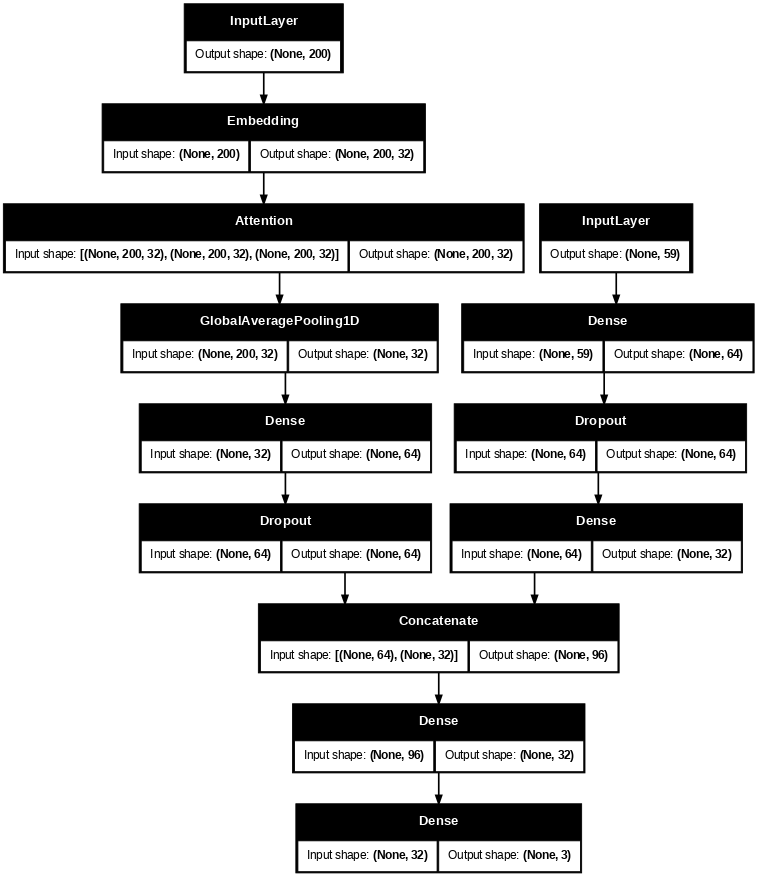

In [ ]:
#Visualize the architecture.
keras.utils.plot_model(simple_QKV_model_m, show_shapes=True, dpi=60)

####Multi-Class: Multi-Head Attention

Multi-Head Attention also only matched the majority benchmark.

In [ ]:
#Define the length of each text
#sequence, how many unique words
#the multi-head attention should learn,
#the dimensions in which the embedings
#should represent each word, the
#number of heads to run in parallel.
MAX_LENGTH_MHA_M = 256
VOCAB_SIZE_MHA_M = 10_001
EMBED_DIM_MHA_M  = 32
NUM_HEADS_MHA_M  = 2


#Define the text Vectorizer and adapt it
#to our text column.
text_vectorizer_m = keras.layers.TextVectorization(
    max_tokens=10_000,
    output_mode='int',
    output_sequence_length=MAX_LENGTH_MHA_M
)
text_vectorizer_m.adapt(X_train_text_m.values)


#Vectorize.
X_train_padded_m = text_vectorizer_m(X_train_text_m.values)
X_val_padded_m   = text_vectorizer_m(X_val_text_m.values)
X_test_padded_m  = text_vectorizer_m(X_test_text_m.values)

#Define the input size for our structured
#branch.
n_structured_m = X_train_structured_m.shape[1]


#Text branch.
about_input_mha_m = keras.Input(shape=(MAX_LENGTH_MHA_M,), name="about_input")
about_emb_mha_m = layers.Embedding(VOCAB_SIZE_MHA_M, EMBED_DIM_MHA_M)(about_input_mha_m)

#Applying self-attention with the
#code below.
attended_mha_m  = layers.MultiHeadAttention(
    num_heads=NUM_HEADS_MHA_M,
    key_dim=EMBED_DIM_MHA_M // NUM_HEADS_MHA_M
)(about_emb_mha_m, about_emb_mha_m, about_emb_mha_m)


#Flatten for Dimensionality reasons, apply a relu
#and some dropout.
text_flat_m  = layers.GlobalAveragePooling1D()(attended_mha_m)
text_dense_m = layers.Dense(64, activation='relu')(text_flat_m)
text_out_m   = layers.Dropout(0.3)(text_dense_m)


#Structured branch.
struct_input_mha_m = keras.Input(shape=(n_structured_m,), name="struct_input")
s_mha_m            = layers.Dense(64, activation='relu')(struct_input_mha_m)
s_mha_m            = layers.Dropout(0.3)(s_mha_m)
struct_out_mha_m   = layers.Dense(32, activation='relu')(s_mha_m)


#Merge.
merged_mha_m = layers.Concatenate()([text_out_m, struct_out_mha_m])
merged_mha_m = layers.Dense(32, activation='relu')(merged_mha_m)
output_mha_m = layers.Dense(3, activation='softmax')(merged_mha_m)  # 3 classes



#Define and compile the model.
mha_model_m = keras.Model(
    inputs=[about_input_mha_m, struct_input_mha_m], outputs=output_mha_m
)
mha_model_m.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#Fit the model to our dataset.
history_mha_m = mha_model_m.fit(
    x=[X_train_padded_m, X_train_structured_m.values.astype('float32')],
    y=y_train_m.values,
    validation_data=(
        [X_val_padded_m, X_val_structured_m.values.astype('float32')],
        y_val_m.values
    ),
    epochs=20,
    batch_size=16,
    class_weight=class_weight_dict_m,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                                              restore_best_weights=True)]
)


#Retrieve the performance metrics for our model.
test_loss_mha_m, test_acc_mha_m = mha_model_m.evaluate(
    [X_test_padded_m, X_test_structured_m.values.astype('float32')],
    y_test_m.values
)
print(f"MultiHead Attention (Multiclass) — Test Accuracy: {test_acc_mha_m:.4f} | Loss: {test_loss_mha_m:.4f}")

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.3272 - loss: 57.7207 - val_accuracy: 0.1193 - val_loss: 26.0675
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3226 - loss: 31.8147 - val_accuracy: 0.1193 - val_loss: 35.3721
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3792 - loss: 22.6628 - val_accuracy: 0.5046 - val_loss: 2.9993
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3165 - loss: 19.1127 - val_accuracy: 0.3761 - val_loss: 8.8553
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3960 - loss: 15.3416 - val_accuracy: 0.3761 - val_loss: 6.0922
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3104 - loss: 12.6317 - val_accuracy: 0.3624 - val_loss: 1.6055
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.5092 - loss: 2.9053
MultiHead Attention (Multiclass) — Test Accuracy: 0.5092 | Loss: 2.9053


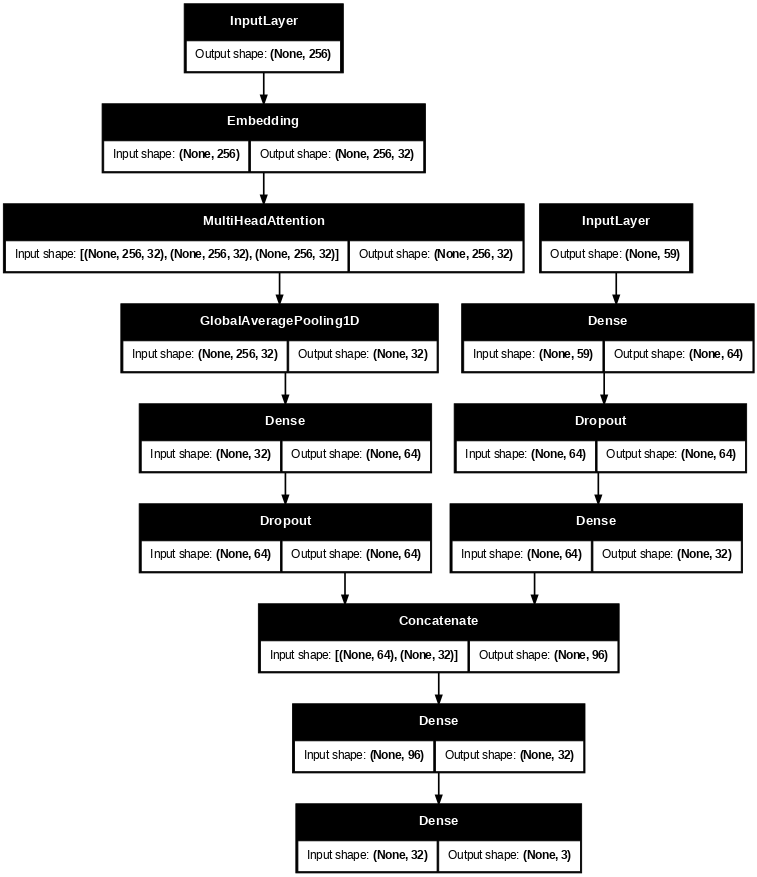

In [ ]:
#Visualize the architecture.
keras.utils.plot_model(mha_model_m, show_shapes=True, dpi=60)

##Chatgpt Dataset Performance Check

In this section, I ran the models against the Chatgpt Dataset. I started by evaluating their binary performances then checking their multiclass benchmarks. Note: because the dataset was much larger, I decided to run the visulizations again to see if the distributions changed signficantly or not.

In [ ]:
#Import the ataste from my drive.
chatgpt_startup_df = pd.read_csv('/content/drive/MyDrive/Spring 2026/BA510/Project/Data/Phase 1/ChatGPT Dataset.csv')

###Visuals of the Chatgpt Dataset

Because the Chatpgt Dataset has more rows the original dataset, I thougt it would be useful to redo the visualizations to see if there are any meaningful differences in the data. Note: The insightts were basically the same so I copied my response to here as well.


Beginning with bar charts, The most common type of platform startup is named Platform, followed by Information and Marketplace. The first one's name is not descriptive enough because all of the companies in the dataset, should be platforms. This could be due to the companies being "in-the-middle" and not precisely neatly fitting into one category. Information is second and altough it may have sites like Wikipedia which could be used often, it intuitively does not make sense that people would be on that type of site rather than a social network, like Instagram. Again, this could be that the Platform over generalized what it does and did not fit into a category neatly. Finally Marketplace can make sense because people could be trying to replicate Amazon's popularity. Moreover, because you purchase and buy goods on Amazon, people may have some bias that makes more money than a social network like Facebook or others(which rely on advertising revenue).


The next chart shows seller type(i.e. is the platform b2b, b2c, etc.). Unsurprisingly, most of the companies are b2c, which makes sense because every day people are consumers, so more ideas would be created for adressing consumer facing problems.


The final chart shows if the startup had a successful exit or not. Based on it, most of the companies got acquired, a lot of them closed, and only some gone through an IPO. This also makes sense beause startups may not have sufficient resources to go through an IPO or the acquisition offers are so favorable to founders that they decide to sell off the company(https://www.svb.com/startup-insights/startup-strategy/types-startup-exit-strategy/).

<Figure size 1800x1500 with 0 Axes>

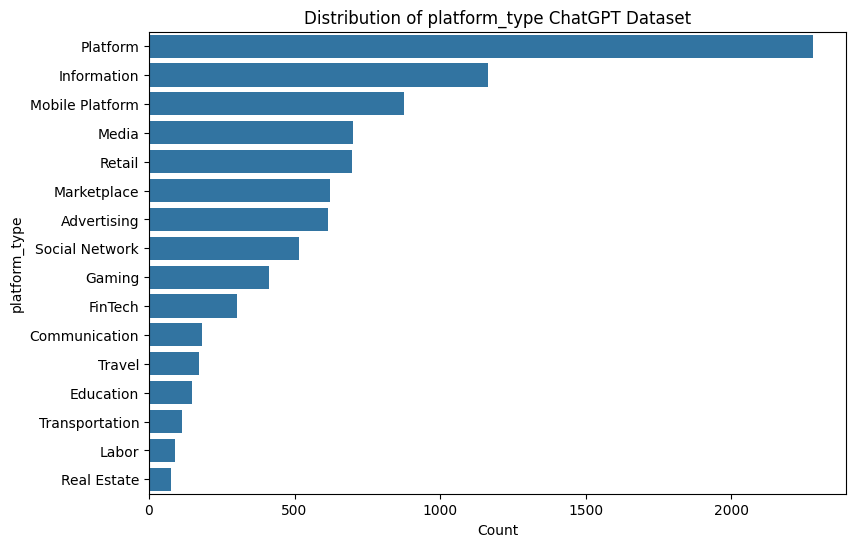

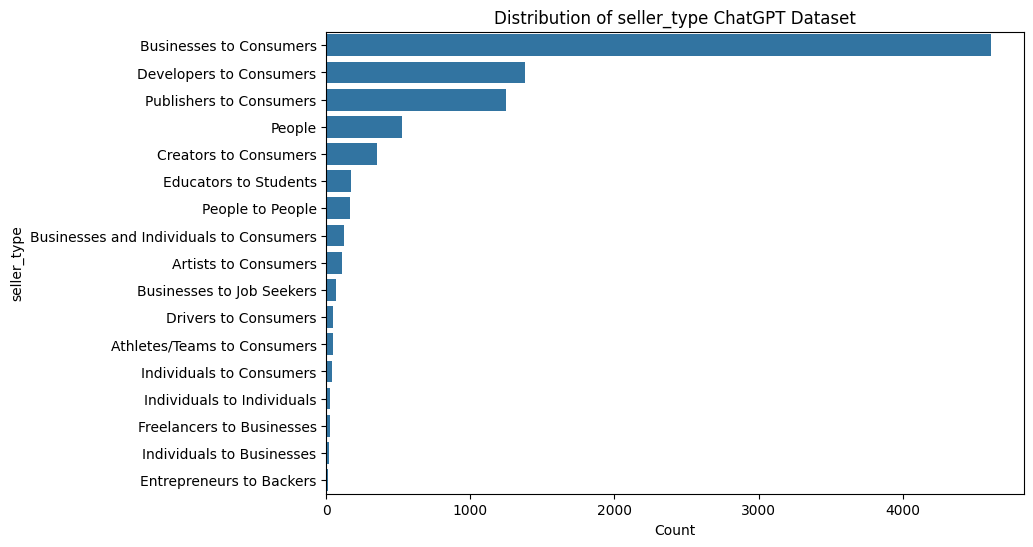

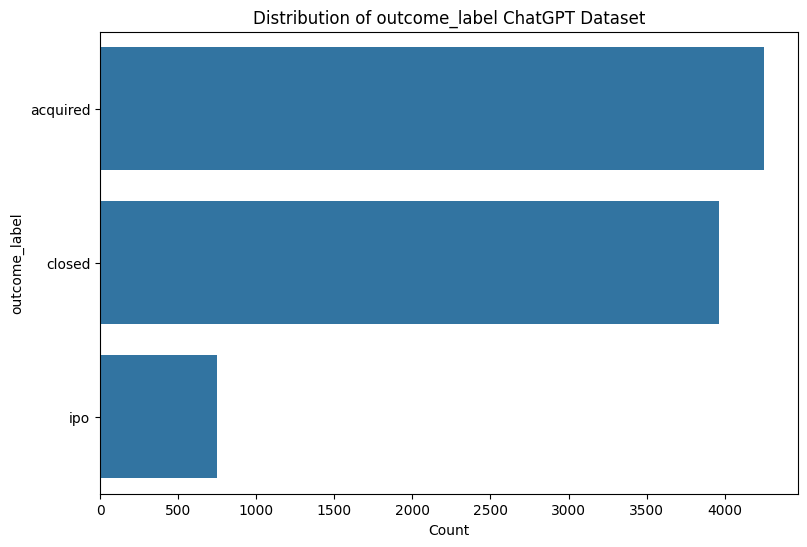

In [ ]:
#Create a list of the categorical columns we want to make bar charts for.
categorical_cols = ['platform_type', 'seller_type', 'outcome_label']

#Initialize a big plt figure for the
#bar charts.
plt.figure(figsize=(18, 15))


#Loop through each cateogircal column and create
#a bar chart showing the distribution of the column.
for col in categorical_cols:

    #Initialize a smaller figure for each visual.
    plt.figure(figsize=(9, 6))

    #Plot the column information.
    sns.countplot(data=chatgpt_startup_df, y=col,
                  order=chatgpt_startup_df[col].value_counts().index)

    #Define the title, labels, and show the plot.
    plt.title(f'Distribution of {col} ChatGPT Dataset')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

The next couple of graphs showcase geograhic distributions of the data. Unsurprisingly, the US has the most number of startups, possibly due to the entrepreneurship culture and more opportunities. Suprisingly, most of the startup's cities are unkown which could be due to the limitations in the data collection process, but from the known ones San Francisco California has the most number of platform startups.

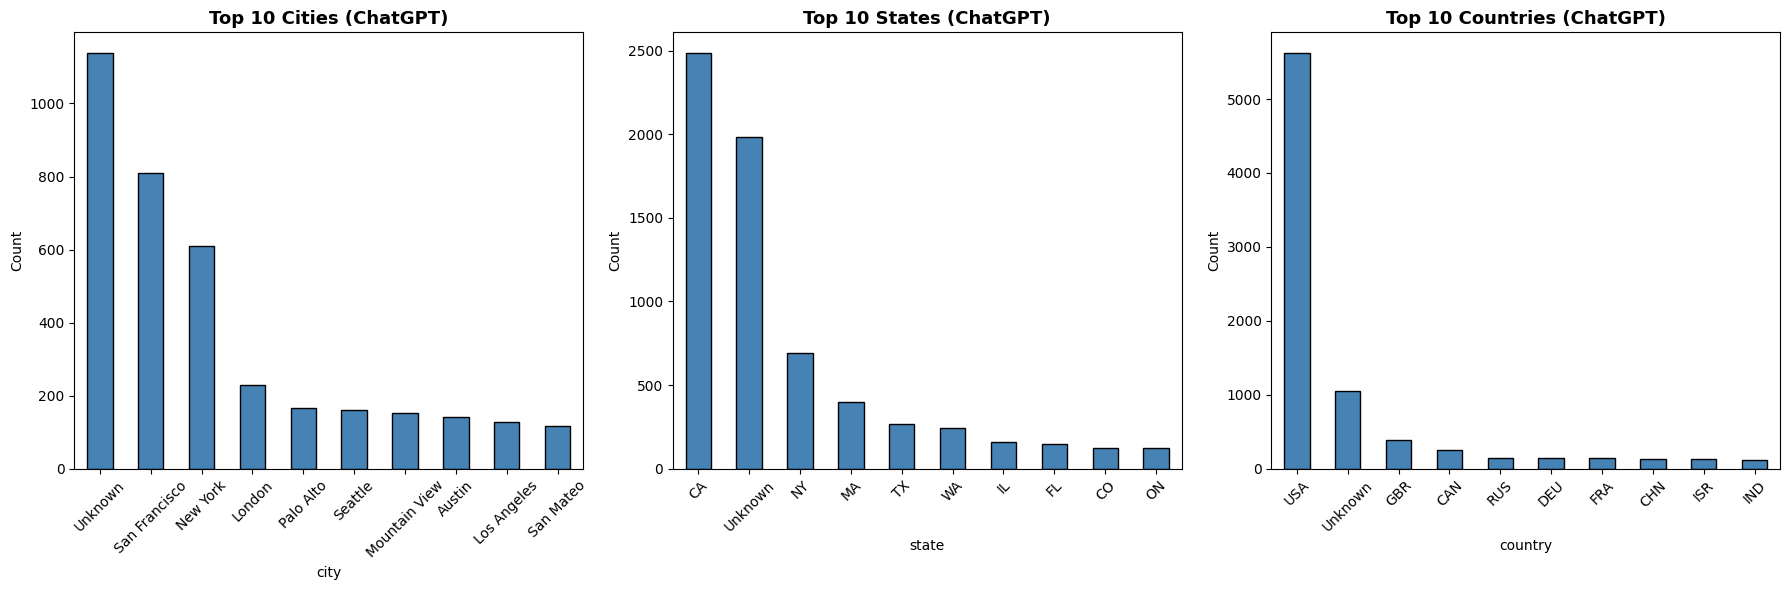

In [ ]:
#Creating visuals to represent the geographic columns of
#the dataset.

#Define a function which we could reause to plot our
#georgaphic categorical columns onto a plot.
def plot_top10_bar(df, col, ax, title):

    #Take the top 10 most frequent values in the
    #column.
    top10 = df[col].value_counts().nlargest(10).index

    #Define a variable to store the values.
    series = df[col].where(df[col].isin(top10))

    #Count the vlaues.
    counts = series.value_counts()

    #Plot the bar chart.
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

    #Set the title, labels, and tick the x axis for readability.
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

#Create subplots so we can see all the plot side by side.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#Call our function to plot all of our cateogircal columns.
plot_top10_bar(chatgpt_startup_df, 'city', axes[0], 'Top 10 Cities (ChatGPT)')
plot_top10_bar(chatgpt_startup_df, 'state', axes[1], 'Top 10 States (ChatGPT)')
plot_top10_bar(chatgpt_startup_df, 'country', axes[2], 'Top 10 Countries (ChatGPT)')

#Tight layout to prevent overflow between the visuals and
#show the plots.
plt.tight_layout()
plt.show()

In [ ]:
#Create a choropleth map to show the startups in each country.

#Variable to count how many startups are in each country.
country_counts = chatgpt_startup_df['country'].value_counts().reset_index()

#Display the resulting table
display(country_counts.head())

#Filter only for companies that have known countries.
country_counts_filtered = country_counts[country_counts['country'] != 'Unknown']

#Create the choropleth map.
fig = px.choropleth(
    country_counts_filtered,
    locations='country',
    color='count',
    title='Global Distribution of Platform Startups (ChatGPT Dataset)',
    color_continuous_scale='Viridis',
    labels={'count': 'Number of Startups'}
)

#Show the figure.
fig.show()

,country,count
0,USA,5621
1,Unknown,1045
2,GBR,388
3,CAN,248
4,RUS,146


In [ ]:
#Create a choropleth map showing how many startups are in each US state.

#Filter for only us startups and known states.
us_startups = chatgpt_startup_df[(chatgpt_startup_df['country'] == 'USA')  \
                  & (chatgpt_startup_df['state'] != 'Unknown')]


#Count how many startups were for each state.
state_counts = us_startups['state'].value_counts().reset_index()

#Display the table.
display(state_counts.head())

#Create the chropleth map.
fig_us = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    title='Distribution of Platform Startups Across US States (ChatGPT Dataset)',
    color_continuous_scale='Viridis',
    labels={'count': 'Number of Startups'}
)

#Show the figure.
fig_us.show()


,state,count
0,CA,2486
1,NY,693
2,MA,396
3,TX,267
4,WA,242


In [ ]:
#Create a choropleth map for startups in California.

#Filter for startups that are specifically in California.
ca_startups = us_startups[us_startups['state'] == 'CA']


#Create a counts dataframe for keeping track
#of each city and their corresponding
#number of startups.
ca_city_counts = ca_startups['city'] \
                      .value_counts() \
                      .reset_index()

#Define the columns of the dataset, and
#show the output.
ca_city_counts.columns = ['city', 'count']
display(ca_city_counts.head())

#Make some space for the other outputs.
print('\n')



#Convert the city names into lattitude and longitude
#coordinates so we can visualize them.


# Initialize Nominatim geolocator
geolocator = Nominatim(user_agent='startup_mapper')

# Helper function to geocode cities
def geocode_city(city_name):
    try:
        #Forces the search query to be only in California.
        query = f"{city_name}, California, USA"

        #Send the request to geolocator, to get latitude,
        #and longitude.
        location = geolocator.geocode(query, timeout=10)

        # Add delay to avoid rate limiting
        time.sleep(1)

        #If the location is found, we return
        #the latitude and longitude.
        if location:
            return location.latitude, location.longitude

        #If it does not find anything, return none.
        else:
            return None, None

    #Prevent the script from crashing if an exception
    #is thrown.
    except Exception as e:
        print(f"Error geocoding {city_name}: {e}")
        return None, None


# Create new latitude and longitude columns by using
#the newly created function.
ca_city_counts['latitude'], ca_city_counts['longitude'] =  \
              zip(*ca_city_counts['city'] \
              .apply(geocode_city))


# Display the first few rows to verify.
display(ca_city_counts.head())
print('\n')




# Drop rows with missing coordinates just in case
ca_city_counts_mapped = ca_city_counts.dropna(
                          subset=['latitude', 'longitude'])

#Makes each city in CA a dot on the map.
fig_ca = px.scatter_mapbox(
    #Input our dataset.
    ca_city_counts_mapped,

    #Where to place each point.
    lat='latitude',
    lon='longitude',

    #Adjust bubble size.
    size='count',
    color='count',

    #Information to show when
    #hovering over a point on the
    #map.
    hover_name='city',
    hover_data={'latitude': False,
                'longitude': False,
                'count': True},

    #Set the color-gradient,based on
    #number of startups.
    color_continuous_scale='Viridis',

    #Maximum size for hte dots.
    size_max=30,

    #Zoom in the map.
    zoom=5,

    #Center the map on California.
    center={'lat': 36.7783,
            'lon': -119.4179},

    #Adjust the style of the map.
    mapbox_style='carto-positron',

    #Add the title of the dataset.
    title='Distribution of Startups Across California Cities'
)

#Show the figure.
fig_ca.show()

,city,count
0,San Francisco,809
1,Palo Alto,165
2,Mountain View,153
3,Los Angeles,128
4,San Mateo,117


,city,count,latitude,longitude
0,San Francisco,809,37.787936,-122.407520
1,Palo Alto,165,37.444329,-122.159847
2,Mountain View,153,37.389389,-122.083210
3,Los Angeles,128,34.053691,-118.242766
4,San Mateo,117,37.496904,-122.333057


As expected even the Chatgpt dataset has a lot more successful companies that not successful ones due to them being more well-known and their information being easier to retrieve.

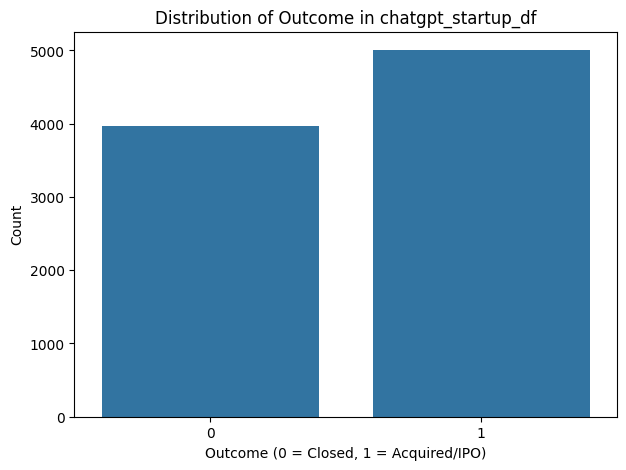

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=chatgpt_startup_df, x='outcome')
plt.title('Distribution of Outcome in chatgpt_startup_df')
plt.xlabel('Outcome (0 = Closed, 1 = Acquired/IPO)')
plt.ylabel('Count')
plt.show()

###Data Cleaning

For the Data cleaning, I first tried to drop any null values in my textual columns that ChatGPT may have failed to fill out. I then feature engineered a years without vc column, to capture how long the company survived iwthout funding, and dropped the null values in the associated columns. Then for the dummies, I only kept the top 10 most frequent classes in each categorical column and labeled everything else as other.

In [ ]:
#Drop rows with no about_text. Note we define it in a different
#dataframe because we are going to manipulate chatgpt_df and
#do not want it to affect the original dataframe.
chatgpt_df = chatgpt_startup_df.dropna(
    subset=['about_text','founder_background'])


# Feature engineer years_without_vc
chatgpt_df['years_without_vc'] = chatgpt_df['first_funding_year'] - chatgpt_df['founded_year']
chatgpt_df = chatgpt_df.dropna(subset=['years_without_vc', 'founded_year', 'first_funding_year'])


#Show the shape of the dataset, after we drop the null values.
print(f"ChatGPT dataset shape after cleaning: {chatgpt_df.shape}")

ChatGPT dataset shape after cleaning: (6877, 20)


In [ ]:
#Do One hot encoding for categorical columns, leaving the top 10 as
#dummy columns while categorizing the rest as Other.

#Define a list of categorical columns.
cols_to_process_cg = ['platform_type', 'seller_type', 'state', 'country', 'city']



#Loop through each column in the list.
for col in cols_to_process_cg:

    #Store the top 10 largest values in each categorical
    #column.
    top_10 = chatgpt_df[col].value_counts().nlargest(10).index

    #Change the respective chatgpt_df column to either feature
    #the top value or the other value.
    chatgpt_df[col] = chatgpt_df[col].apply(
        lambda x: x if x in top_10 else 'Other'
    )

#Create a new dataframe with dumies genegrated,
#after we have transformed the dataset.
chatgpt_df_w_dummies = pd.get_dummies(
    chatgpt_df.drop(columns=['company_name', 'id',
                                     'source', 'text_source'],
                            errors='ignore'),
    columns=cols_to_process_cg,
    drop_first=True
)

#Show the shape of the dataset with dummies.
print(f"Shape with dummies: {chatgpt_df_w_dummies.shape}")

Shape with dummies: (6877, 61)


###Model Performance on Chatgpt Dataset.

###Splitting the Dataset

Here, I first shuffled the data to avoid any ordering patterns that ChatGPT may have caused, then split my dataset into X_cg and y_cg(note the _cg is to represent that these are the chatgpt splits). I then proceeded to split the data into train, validation, and test. Finally, I extracted my textual columns(about text and founder information) into separate variables because they will be used as separate branch inputs in my nueral network models.

In [ ]:
#The code below shuffles the dataset.
chatgpt_df_w_dummies = chatgpt_df_w_dummies \
                         .sample(frac=1, random_state=42) \
                         .reset_index(drop=True)

#Define X y with the _cg representing that they are using the chatpgt,
#dataset.
X_cg = chatgpt_df_w_dummies.drop(['outcome', 'outcome_label'], axis=1)
y_cg = chatgpt_df_w_dummies['outcome']

#Split it to  temprorary x and y(which will beused to further
#split to train and validation) and test x and y.
X_cg_temp, X_cg_test, y_cg_temp, y_cg_test = train_test_split(
    X_cg, y_cg, test_size=0.2, random_state=42, stratify=y_cg
)

#Split the dataset to train and validation from the temporary
#x and y.
X_cg_train, X_cg_val, y_cg_train, y_cg_val = train_test_split(
    X_cg_temp, y_cg_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_cg_temp
)

#Separate about text from the structured columns.
X_cg_train_about = X_cg_train['about_text']
X_cg_val_about  = X_cg_val['about_text']
X_cg_test_about = X_cg_test['about_text']

#Separate the founder text from the structured columns.
X_cg_train_founder = X_cg_train['founder_background']
X_cg_val_founder  = X_cg_val['founder_background']
X_cg_test_founder = X_cg_test['founder_background']

#Remove the about text and founder_background columns from the datasets.
X_cg_train_structured = X_cg_train.drop(['about_text','founder_background'], axis=1).astype(float)
X_cg_val_structured   = X_cg_val.drop(['about_text','founder_background'], axis=1).astype(float)
X_cg_test_structured  = X_cg_test.drop(['about_text','founder_background'], axis=1).astype(float)

#Show how many observations are in each dataset.
print(f"Train: {len(y_cg_train)} | Val: {len(y_cg_val)} | Test: {len(y_cg_test)}")

Train: 4125 | Val: 1376 | Test: 1376


###Binary: Dummy Classifier

In this section, I checked how well the majority rule would apply to the ChatGPT dataset, and it yielded an accuracy of 56.76%.

In [ ]:
#Determine the most common class in y_cg_train
majority_class_cg = y_cg_train.value_counts().idxmax()
print(f"Majority Class in y_cg_train: {majority_class_cg}")

#Predict all classes in y_cg_test as that most common class
y_pred_dummy_cg = np.full(shape=y_cg_test.shape, fill_value=majority_class_cg)

#Calculate its accuracy
majority_class_proportion_cg = accuracy_score(y_cg_test, y_pred_dummy_cg)
print(f"Dummy Classifier (ChatGPT) Accuracy: {majority_class_proportion_cg:.4f}")

Majority Class in y_cg_train: 1
Dummy Classifier (ChatGPT) Accuracy: 0.5676


###Binary: Simple Model, Just using vectorization.

Here, the text vectorizer performed significantly better than the benchmark, with an accuracy of 67.88%.

In [ ]:
#Initialize separate vectorizers for each text
#column so they learn their own vocabularies independently.
text_vec_about_simple = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="multi_hot"
)
text_vec_about_simple.adapt(X_cg_train_about)


text_vec_founder_simple = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="multi_hot"
)
text_vec_founder_simple.adapt(X_cg_train_founder)

#Vectorize the about column.
X_cg_train_about_vec   = text_vec_about_simple(X_cg_train_about.values)
X_cg_val_about_vec     = text_vec_about_simple(X_cg_val_about.values)
X_cg_test_about_vec    = text_vec_about_simple(X_cg_test_about.values)

#Vectorize the founder column.
X_cg_train_founder_vec = text_vec_founder_simple(X_cg_train_founder.values)
X_cg_val_founder_vec   = text_vec_founder_simple(X_cg_val_founder.values)
X_cg_test_founder_vec  = text_vec_founder_simple(X_cg_test_founder.values)

#Extract the number of structured columns
n_structured_cg = X_cg_train_structured.shape[1]

#Get the actual vocabulary sizes after adaptation
about_vocab_size = text_vec_about_simple.vocabulary_size()
founder_vocab_size = text_vec_founder_simple.vocabulary_size()

#About text branch
about_input_s = keras.Input(shape=(about_vocab_size,), name="about_input")
x_a = keras.layers.Dense(16, activation="relu")(about_input_s)

#Founder branch
founder_input_s = keras.Input(shape=(founder_vocab_size,), name="founder_input")
x_f = keras.layers.Dense(16, activation="relu")(founder_input_s)

#Structured branch
struct_input_s = keras.Input(shape=(n_structured_cg,), name="struct_input")
x_s = keras.layers.Dense(16, activation="relu")(struct_input_s)

#Merge all three branches
merged_s = keras.layers.Concatenate()([x_a, x_f, x_s])
merged_s = keras.layers.Dropout(0.5)(merged_s)
output_s = keras.layers.Dense(1, activation="sigmoid")(merged_s)


#Initialize the model blueprint.
simple_model_cg = keras.Model(
    inputs=[about_input_s, founder_input_s, struct_input_s],
    outputs=output_s
)

#Compile the model.
simple_model_cg.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"])

#Fit the model to our dataset.
history_simple_cg = simple_model_cg.fit(
    (X_cg_train_about_vec.numpy(),
     X_cg_train_founder_vec.numpy(),
     X_cg_train_structured.values.astype('float32')),
    y_cg_train.values,
    validation_data=(
        (X_cg_val_about_vec.numpy(),
         X_cg_val_founder_vec.numpy(),
         X_cg_val_structured.values.astype('float32')),
        y_cg_val.values
    ),
    epochs=10,
    batch_size=32
)

#Evaluate the model perforamnce.
test_loss_cg, test_acc_cg = simple_model_cg.evaluate(
    (X_cg_test_about_vec.numpy(),
     X_cg_test_founder_vec.numpy(),
     X_cg_test_structured.values.astype('float32')),
    y_cg_test.values
)

print(f"\nSimple Model — Test Accuracy: {test_acc_cg:.4f} | Test Loss: {test_loss_cg:.4f}")

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5108 - loss: 22.6918 - val_accuracy: 0.6483 - val_loss: 0.6433
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5978 - loss: 0.7062 - val_accuracy: 0.6301 - val_loss: 0.6467
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6621 - loss: 0.6166 - val_accuracy: 0.6730 - val_loss: 0.6101
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6844 - loss: 0.6048 - val_accuracy: 0.6344 - val_loss: 0.6353
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7122 - loss: 0.5603 - val_accuracy: 0.6817 - val_loss: 0.5968
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7508 - loss: 0.5163 - val_accuracy: 0.6897 - val_loss: 0.5881
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7765 - loss: 0.4891 - val_accuracy: 0.6788 - val_loss: 0.6091
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7973 - loss: 0.4582 - val_accuracy: 

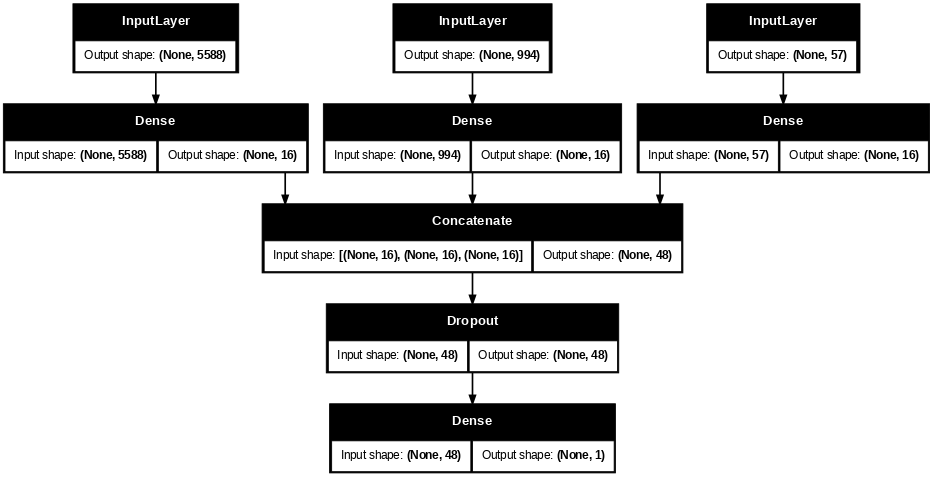

In [ ]:
#Create a visual for the simple model.
keras.utils.plot_model(simple_model_cg,show_shapes=True,dpi=60)

###Binary: Embedding Model

Here, the Embeding Model performed significantly better than the benchmark, with an accuracy of 68.1%.

In [ ]:

# Compute 95th percentile lengths to use as sequence lengths
about_lengths   = X_cg_train_about.str.split().str.len()
founder_lengths = X_cg_train_founder.str.split().str.len()
max_len_about   = int(about_lengths.quantile(0.95))
max_len_founder = int(founder_lengths.quantile(0.95))

n_structured_cg = X_cg_train_structured.shape[1]

# output_mode='int' gives each word an integer ID,
# which is what the Embedding layer expects as input
text_vec_about_emb = keras.layers.TextVectorization(
    max_tokens=20_000,
    output_mode='int',
    output_sequence_length=max_len_about
)
text_vec_about_emb.adapt(X_cg_train_about.values)

text_vec_founder_emb = keras.layers.TextVectorization(
    max_tokens=20_000,
    output_mode='int',
    output_sequence_length=max_len_founder
)
text_vec_founder_emb.adapt(X_cg_train_founder.values)

# Vectorize all splits
X_cg_train_about_int   = text_vec_about_emb(X_cg_train_about.values)
X_cg_val_about_int     = text_vec_about_emb(X_cg_val_about.values)
X_cg_test_about_int    = text_vec_about_emb(X_cg_test_about.values)

X_cg_train_founder_int = text_vec_founder_emb(X_cg_train_founder.values)
X_cg_val_founder_int   = text_vec_founder_emb(X_cg_val_founder.values)
X_cg_test_founder_int  = text_vec_founder_emb(X_cg_test_founder.values)

# About text branch
# Input is a sequence of integer IDs, one per token
about_input_e = keras.Input(shape=(max_len_about,), name="about_input")
# Embedding converts each integer ID into a 64-dimensional vector
x_a = keras.layers.Embedding(20_000, 64, name="emb_about")(about_input_e)
# GlobalAveragePooling1D averages across all token vectors
# to produce one single vector representing the whole text
x_a = keras.layers.GlobalAveragePooling1D()(x_a)
x_a = keras.layers.Dense(64, activation="relu")(x_a)
x_a = keras.layers.Dropout(0.3)(x_a)

#Founder background branch
founder_input_e = keras.Input(shape=(max_len_founder,), name="founder_input")
x_f = keras.layers.Embedding(20_000, 64, name="emb_founder")(founder_input_e)
x_f = keras.layers.GlobalAveragePooling1D()(x_f)
x_f = keras.layers.Dense(64, activation="relu")(x_f)
x_f = keras.layers.Dropout(0.3)(x_f)

#Structured branch
struct_input_e = keras.Input(shape=(n_structured_cg,), name="struct_input")
x_s = keras.layers.Dense(32, activation="relu")(struct_input_e)
x_s = keras.layers.Dropout(0.3)(x_s)

#Merge all three branches
combined_e = keras.layers.Concatenate()([x_a, x_f, x_s])
x_e = keras.layers.Dense(32, activation="relu")(combined_e)
output_e = keras.layers.Dense(1, activation="sigmoid")(x_e)

#Create a blueprint for the model.
embedding_model_cg = keras.Model(
    inputs=[about_input_e, founder_input_e, struct_input_e],
    outputs=output_e
)

#Compile the model.
embedding_model_cg.compile(optimizer="rmsprop",
                             loss="binary_crossentropy",
                             metrics=["accuracy"])

#Fit the model to our data.
history_emb_cg = embedding_model_cg.fit(
    (X_cg_train_about_int.numpy(),
     X_cg_train_founder_int.numpy(),
     X_cg_train_structured.values.astype('float32')),
    y_cg_train.values,
    validation_data=(
        (X_cg_val_about_int.numpy(),
         X_cg_val_founder_int.numpy(),
         X_cg_val_structured.values.astype('float32')),
        y_cg_val.values
    ),
    epochs=10, batch_size=32
)

#Evaluate the model's performance.
test_loss_emb_cg, test_acc_emb_cg = embedding_model_cg.evaluate(
    (X_cg_test_about_int.numpy(),
     X_cg_test_founder_int.numpy(),
     X_cg_test_structured.values.astype('float32')),
    y_cg_test.values
)

print(f"\nEmbedding Model — Test Accuracy: {test_acc_emb_cg:.4f} | Test Loss: {test_loss_emb_cg:.4f}")

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.4972 - loss: 15.0069 - val_accuracy: 0.4382 - val_loss: 1.0191
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5139 - loss: 5.4615 - val_accuracy: 0.5676 - val_loss: 4.5853
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5103 - loss: 2.8492 - val_accuracy: 0.5676 - val_loss: 1.5819
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5345 - loss: 1.4462 - val_accuracy: 0.5676 - val_loss: 1.7798
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5821 - loss: 0.9320 - val_accuracy: 0.6715 - val_loss: 0.6137
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6162 - loss: 0.7362 - val_accuracy: 0.6250 - val_loss: 0.7726
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6708 - loss: 0.6402 - val_accuracy: 0.6453 - val_loss: 0.6254
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7038 - loss: 0.5787 - val_accuracy:

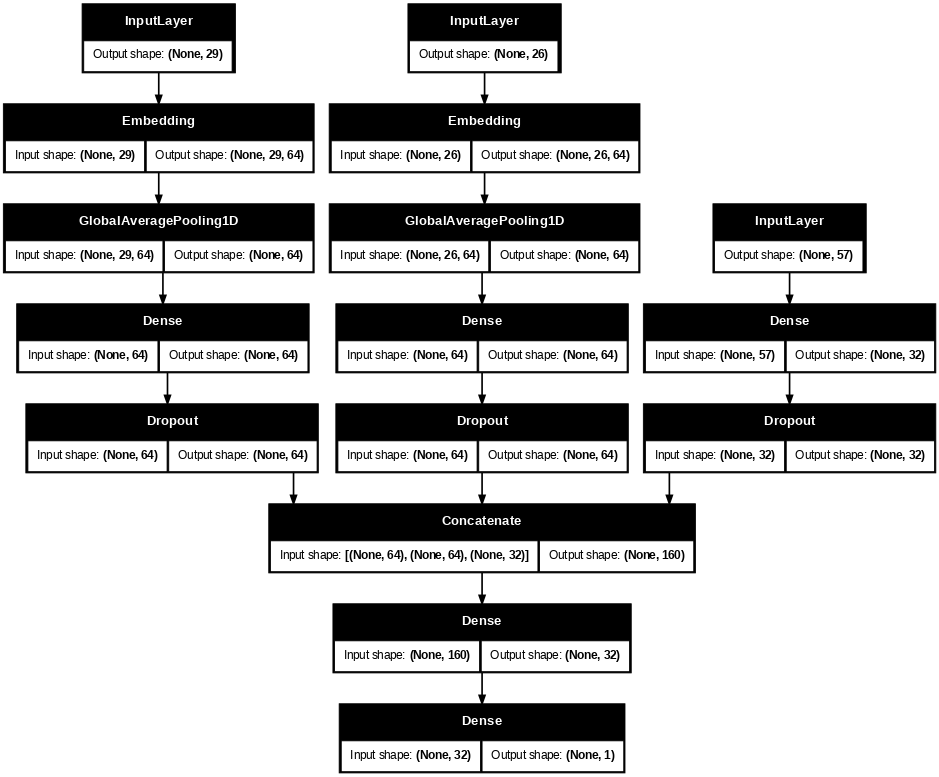

In [ ]:
#Create a visual for the embedings model.
keras.utils.plot_model(embedding_model_cg,show_shapes=True,dpi=60)

###Binary: Testing out RNN-s with embedings

All of the RNN models outperformed the benchmark, with the LSTM model having the highest accuracy of 65.26%.

In [ ]:
#Define a function so we can test out iteratively
#many RNN models.
def build_rnn_model_cg(rnn_layer):

    #Compute 95th percentile length separately for each text column
    about_lengths   = X_cg_train_about.str.split().str.len()
    founder_lengths = X_cg_train_founder.str.split().str.len()
    max_len_about   = int(about_lengths.quantile(0.95))
    max_len_founder = int(founder_lengths.quantile(0.95))

    #Count the number of structured features for the input layer.
    n_struct_cg = X_cg_train_structured.shape[1]

    #Vectorize the about text column.
    text_vec_about_rnn = keras.layers.TextVectorization(
        max_tokens=20_000,
        output_mode='int',
        output_sequence_length=max_len_about
    )

    text_vec_about_rnn.adapt(X_cg_train_about.values)

    #Vectorize the founder column.
    text_vec_founder_rnn = keras.layers.TextVectorization(
        max_tokens=20_000,
        output_mode='int',
        output_sequence_length=max_len_founder
    )

    text_vec_founder_rnn.adapt(X_cg_train_founder.values)

    #Create a copy of the rnn_layer name so we can
    #name the founder's RNN layer name something else.
    base_name = rnn_layer.name.split("_")[0]

    #Create a fresh copy of the RNN layer for the founder branch
    #with a unique name so Keras does not complain about duplicates
    config = rnn_layer.get_config()
    config['name'] = f"{base_name}_founder"
    founder_rnn_layer = type(rnn_layer).from_config(config)

    #Handle Bidirectional RNN naming issues.
    if isinstance(rnn_layer, keras.layers.Bidirectional):

        #Retrives the inner layer in the bideretional RNN.
        inner_layer  = rnn_layer.forward_layer

        #Receives its conifguraionts.
        inner_config = inner_layer.get_config()

        #Define the new layer's name.
        inner_name   = inner_layer.name.split("_")[0]

        #Redefine the new layer name.
        inner_config['name'] = f"{inner_name}_founder_inner"

        #Initialize a new layer with the updated configuration.
        new_inner    = type(inner_layer).from_config(inner_config)

        #Run the bidrectional rnn layer.
        founder_rnn_layer = keras.layers.Bidirectional(
            new_inner, name="bidirectional_founder"
        )

    #About text branch
    about_input = keras.Input(shape=(1,), dtype=tf.string, name="about_input")
    x_a = text_vec_about_rnn(about_input)
    x_a = keras.layers.Embedding(20_000, 64, name="emb_about")(x_a)
    x_a = rnn_layer(x_a)
    x_a = keras.layers.Dropout(0.3)(x_a)

    #Founder background branch
    founder_input = keras.Input(shape=(1,), dtype=tf.string, name="founder_input")
    x_f = text_vec_founder_rnn(founder_input)
    x_f = keras.layers.Embedding(20_000, 64, name="emb_founder")(x_f)
    x_f = founder_rnn_layer(x_f)
    x_f = keras.layers.Dropout(0.3)(x_f)

    #Structured branch
    struct_input = keras.Input(shape=(n_struct_cg,), name="struct_input")
    x_s = keras.layers.Dense(32, activation="relu")(struct_input)
    x_s = keras.layers.Dropout(0.3)(x_s)

    #Merge all three
    combined = keras.layers.Concatenate()([x_a, x_f, x_s])
    out = keras.layers.Dense(32, activation="relu")(combined)
    out = keras.layers.Dense(1, activation="sigmoid")(out)

    #Define the model blueprints.
    model = keras.Model(
        inputs=[about_input, founder_input, struct_input],
        outputs=out
    )

    #Compile the model.
    model.compile(optimizer="rmsprop",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

    # Plot the model architecture
    print(keras.utils.plot_model(model,
                                 show_shapes=True,
                                 dpi=60))

    #Return the model.
    return model

#Define a dictionary with the respective
#RNN's we want to use and their layers.
rnn_models_cg = {
    "SimpleRNN":    keras.layers.SimpleRNN(64),
    "LSTM":         keras.layers.LSTM(64),
    "GRU":          keras.layers.GRU(64),
    "Bi-SimpleRNN": keras.layers.Bidirectional(keras.layers.SimpleRNN(64)),
    "Bi-LSTM":      keras.layers.Bidirectional(keras.layers.LSTM(64)),
    "Bi-GRU":       keras.layers.Bidirectional(keras.layers.GRU(64)),
}

#Define an empty list to store our results.
results_cg = []

#Loop through the dictionary, showing pretty formatting
#and fitting the model using our respective RNN layers.
for model_name, rnn_layer in rnn_models_cg.items():
    print(f"\n{'='*50}")
    print(f"Training (ChatGPT dataset): {model_name}")
    print(f"{'='*50}")

    #Call our rnn function with the current layer.
    model = build_rnn_model_cg(rnn_layer)

    #Fit the model to our current dataset.
    history = model.fit(
        (X_cg_train_about.values,
         X_cg_train_founder.values,
         X_cg_train_structured.values.astype('float32')),
        y_cg_train.values,
        validation_data=(
            (X_cg_val_about.values,
             X_cg_val_founder.values,
             X_cg_val_structured.values.astype('float32')),
            y_cg_val.values
        ),
        epochs=10, batch_size=32
    )

    #Calculate the average validation and loss across epochs.
    avg_val_acc  = sum(history.history['val_accuracy']) / len(history.history['val_accuracy'])
    avg_val_loss = sum(history.history['val_loss'])     / len(history.history['val_loss'])

    #Evaluate the models perforamnce on the test data.
    test_loss, test_acc = model.evaluate(
        (X_cg_test_about.values,
         X_cg_test_founder.values,
         X_cg_test_structured.values.astype('float32')),
        y_cg_test.values, verbose=0
    )

    #Add the results to our previously defined list, and
    #show the test accuracy.
    results_cg.append({
        "Model":            model_name,
        "Avg Val Accuracy": round(avg_val_acc,  4),
        "Avg Val Loss":     round(avg_val_loss,  4),
        "Test Accuracy":    round(test_acc,  4),
        "Test Loss":        round(test_loss, 4),
    })
    print(f"Done! Test Accuracy: {test_acc:.4f}")


#Show the summary of each model's perforamnce.
results_cg_df = pd.DataFrame(results_cg).set_index("Model")
print("\n\n===== CHATGPT DATASET — RNN SUMMARY =====")
print(results_cg_df.to_string())


Training (ChatGPT dataset): SimpleRNN
<IPython.core.display.Image object>
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.5047 - loss: 14.2278 - val_accuracy: 0.5676 - val_loss: 3.1953
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5130 - loss: 3.9124 - val_accuracy: 0.5676 - val_loss: 2.6723
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.5653 - loss: 1.8044 - val_accuracy: 0.6483 - val_loss: 0.7584
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.6364 - loss: 1.0108 - val_accuracy: 0.6330 - val_loss: 0.7614
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7966 - loss: 0.5335 - val_accuracy: 0.6548 - val_loss: 0.8529
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.8962 - loss: 0.2834 - val_accuracy: 0.5981 - val_loss: 1.7076
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9411 - loss: 0.1695 - val_accuracy: 0.6403 - val_loss: 0.9928
Epoch 8/10
129/129 ━━

###Binary: Using Attention With QKV weights

Here, the Simple Attention model significantly better than the benchmark, with an accuracy of 68.75%.

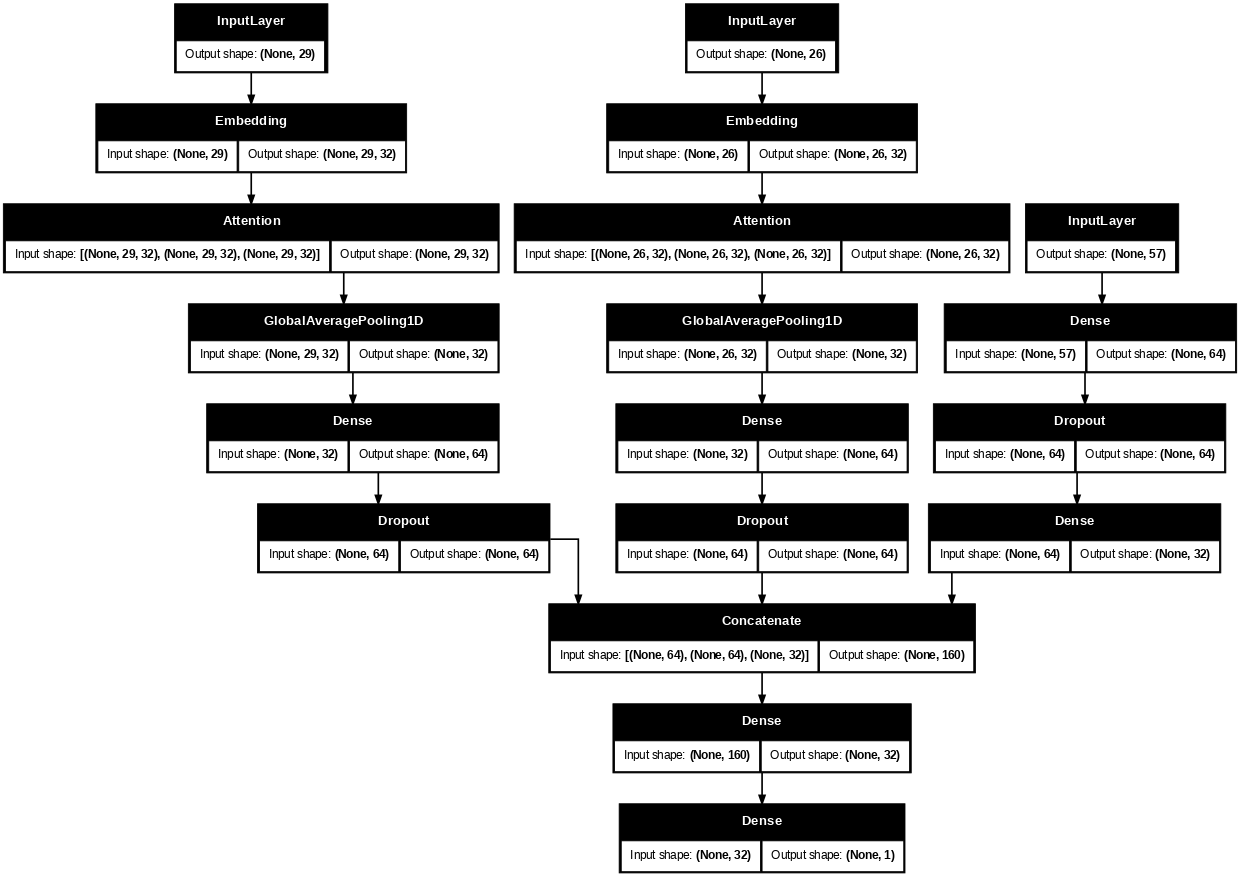

In [ ]:
#Get the text length, and define the maximum length to be used by our network.
about_lengths   = X_cg_train_about.str.split().str.len()
founder_lengths = X_cg_train_founder.str.split().str.len()
max_len_about   = int(about_lengths.quantile(0.95))
max_len_founder = int(founder_lengths.quantile(0.95))

#Define the structured columns input size to be used.
n_structured_cg = X_cg_train_structured.shape[1]

# Separate vectorizers for each text column
text_vec_about_qkv = keras.layers.TextVectorization(
    output_mode="int",
    max_tokens=20_000,
    output_sequence_length=max_len_about
)
text_vec_about_qkv.adapt(X_cg_train_about.values)

text_vec_founder_qkv = keras.layers.TextVectorization(
    output_mode="int",
    max_tokens=20_000,
    output_sequence_length=max_len_founder
)
text_vec_founder_qkv.adapt(X_cg_train_founder.values)

#Vectorize all splits
X_cg_train_about_qkv   = text_vec_about_qkv(X_cg_train_about.values)
X_cg_val_about_qkv     = text_vec_about_qkv(X_cg_val_about.values)
X_cg_test_about_qkv    = text_vec_about_qkv(X_cg_test_about.values)

X_cg_train_founder_qkv = text_vec_founder_qkv(X_cg_train_founder.values)
X_cg_val_founder_qkv   = text_vec_founder_qkv(X_cg_val_founder.values)
X_cg_test_founder_qkv  = text_vec_founder_qkv(X_cg_test_founder.values)

VOCAB_SIZE_CG = 20_001
EMBED_DIM_CG  = 32

#About text branch
about_input_qkv = keras.Input(shape=(max_len_about,), name="about_input")
about_emb       = layers.Embedding(VOCAB_SIZE_CG, EMBED_DIM_CG,
                                   name="emb_about")(about_input_qkv)
attended_a      = layers.Attention()([about_emb, about_emb, about_emb])
x_a             = layers.GlobalAveragePooling1D()(attended_a)
x_a             = layers.Dense(64, activation="relu")(x_a)
x_a             = layers.Dropout(0.3)(x_a)

#Founder background branch
founder_input_qkv = keras.Input(shape=(max_len_founder,), name="founder_input")
founder_emb       = layers.Embedding(VOCAB_SIZE_CG, EMBED_DIM_CG,
                                     name="emb_founder")(founder_input_qkv)
attended_f        = layers.Attention()([founder_emb, founder_emb, founder_emb])
x_f               = layers.GlobalAveragePooling1D()(attended_f)
x_f               = layers.Dense(64, activation="relu")(x_f)
x_f               = layers.Dropout(0.3)(x_f)

#Structured branch
struct_input_qkv = keras.Input(shape=(n_structured_cg,), name="struct_input")
x_s              = layers.Dense(64, activation="relu")(struct_input_qkv)
x_s              = layers.Dropout(0.3)(x_s)
x_s              = layers.Dense(32, activation="relu")(x_s)

# Merge all three branches
merged_qkv = layers.Concatenate()([x_a, x_f, x_s])
merged_qkv = layers.Dense(32, activation="relu")(merged_qkv)
output_qkv = layers.Dense(1, activation="sigmoid")(merged_qkv)




#Create the model and compile it.
simple_qkv_model_cg = keras.Model(
    inputs=[about_input_qkv, founder_input_qkv, struct_input_qkv],
    outputs=output_qkv
)
simple_qkv_model_cg.compile(optimizer="rmsprop",
                              loss="binary_crossentropy",
                              metrics=["accuracy"])

#Visualize the Model.
keras.utils.plot_model(simple_qkv_model_cg, show_shapes=True, dpi=60)

In [ ]:
#Fit the simple QKV model
history_qkv_cg = simple_qkv_model_cg.fit(
    x=[X_cg_train_about_qkv.numpy(),
       X_cg_train_founder_qkv.numpy(),
       X_cg_train_structured.values.astype("float32")],
    y=y_cg_train.values,
    validation_data=(
        [X_cg_val_about_qkv.numpy(),
         X_cg_val_founder_qkv.numpy(),
         X_cg_val_structured.values.astype("float32")],
        y_cg_val.values
    ),
    epochs=20,
    batch_size=16,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                      patience=3,
                                      restore_best_weights=True)
    ]
)


#Evaluate the model's performance on the test set.
test_loss_qkv_cg, test_acc_qkv_cg = simple_qkv_model_cg.evaluate(
    [X_cg_test_about_qkv.numpy(),
     X_cg_test_founder_qkv.numpy(),
     X_cg_test_structured.values.astype("float32")],
    y_cg_test.values
)
print(f"Test Loss:     {test_loss_qkv_cg:.4f}")
print(f"Test Accuracy: {test_acc_qkv_cg:.4f}")

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.5144 - loss: 4.5560 - val_accuracy: 0.4324 - val_loss: 1.2892
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5217 - loss: 0.9872 - val_accuracy: 0.6206 - val_loss: 0.6627
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6027 - loss: 0.6762 - val_accuracy: 0.6672 - val_loss: 0.6196
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6621 - loss: 0.6218 - val_accuracy: 0.6541 - val_loss: 0.6220
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6975 - loss: 0.5867 - val_accuracy: 0.6962 - val_loss: 0.5919
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7115 - loss: 0.5609 - val_accuracy: 0.6911 - val_loss: 0.5877
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7258 - loss: 0.5434 - val_accuracy: 0.6802 - val_loss: 0.5893
Epoch 8/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7413 - loss: 0.5301 - val_accuracy: 

###Binary: MultiHead Attention Model

Here, the MultiHead Attention Model performed significantly better than the benchmark, with an accuracy of 68.46%.

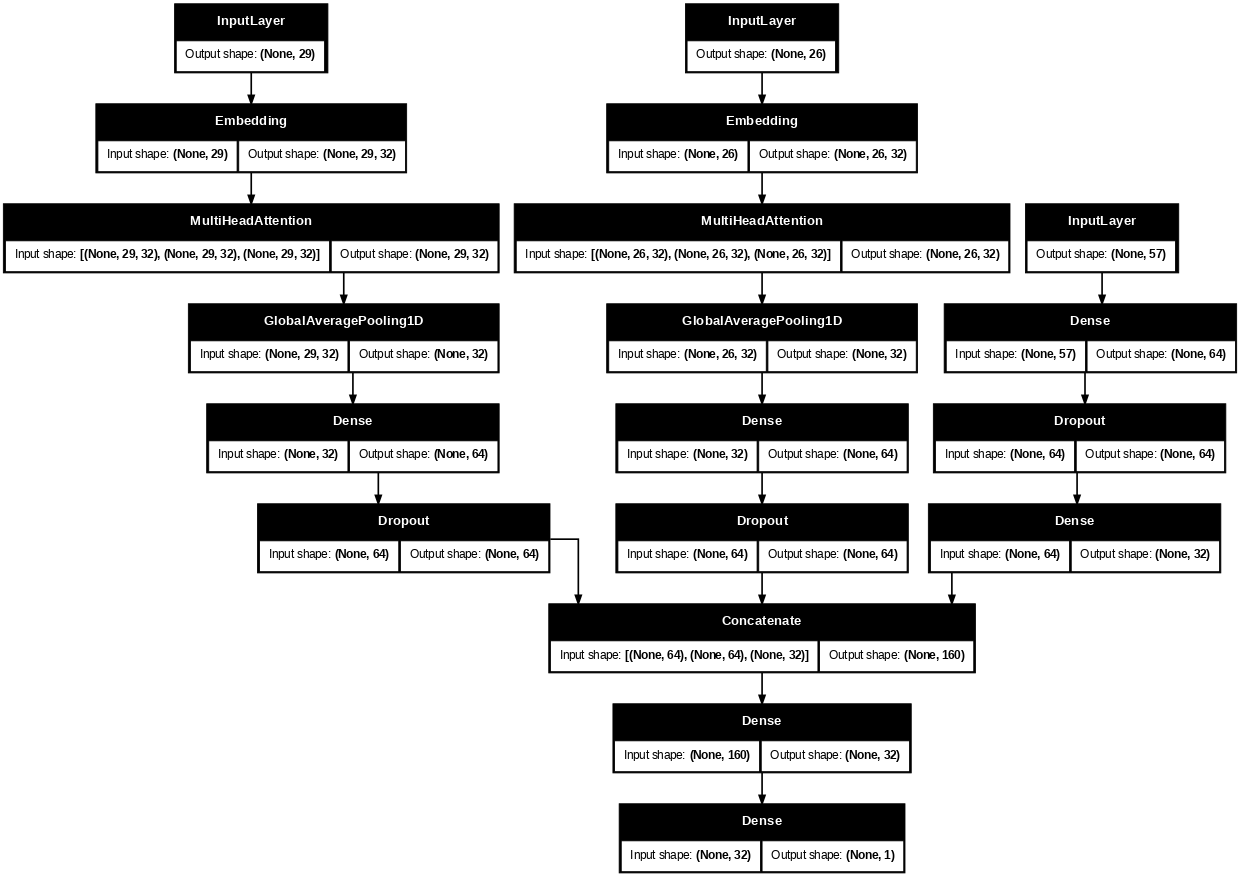

In [ ]:
#Initialize parameters to be used as inputs.
MAX_LENGTH_ABOUT_CG   = max_len_about
MAX_LENGTH_FOUNDER_CG = max_len_founder
VOCAB_SIZE_CG         = 10_001
EMBED_DIM_CG          = 32
NUM_HEADS_CG          = 2


#Vectorize the about text column and adapt it to our column..
text_vec_about_mha = keras.layers.TextVectorization(
    max_tokens=10_000,
    output_mode="int",
    output_sequence_length=MAX_LENGTH_ABOUT_CG
)


text_vec_about_mha.adapt(X_cg_train_about.values)


#Vectorize the founder column and adapt it to our column.
text_vec_founder_mha = keras.layers.TextVectorization(
    max_tokens=10_000,
    output_mode="int",
    output_sequence_length=MAX_LENGTH_FOUNDER_CG
)

text_vec_founder_mha.adapt(X_cg_train_founder.values)

#Apply the vectorization for our splits for about text column.
X_cg_train_about_mha   = text_vec_about_mha(X_cg_train_about.values)
X_cg_val_about_mha     = text_vec_about_mha(X_cg_val_about.values)
X_cg_test_about_mha    = text_vec_about_mha(X_cg_test_about.values)


#Apply the vectorization for our splits for founder column.
X_cg_train_founder_mha = text_vec_founder_mha(X_cg_train_founder.values)
X_cg_val_founder_mha   = text_vec_founder_mha(X_cg_val_founder.values)
X_cg_test_founder_mha  = text_vec_founder_mha(X_cg_test_founder.values)

#About text branch

#Input layer.
about_input_mha = keras.Input(shape=(MAX_LENGTH_ABOUT_CG,), name="about_input")

#Create embedings for the model.
about_emb_mha   = layers.Embedding(VOCAB_SIZE_CG, EMBED_DIM_CG,
                                   name="emb_about")(about_input_mha)

#Apply the MultiHeadAttention to our model.
#The num_heads represents how many heads we
#want to run in parallel, and key_dimension
#represents the dimensionality of each heads
#working space.
attended_a_mha  = layers.MultiHeadAttention(
    num_heads=NUM_HEADS_CG,
    key_dim=EMBED_DIM_CG // NUM_HEADS_CG
)(about_emb_mha, about_emb_mha, about_emb_mha) #The Query, Key, Value, all of them are the same in thsi case because we want self-attention here.

#Apply a 1d convulution to help align the dimensions for
#the other layers in the model.
x_a_mha  = layers.GlobalAveragePooling1D()(attended_a_mha)

#Apply a relu and dropout layer.
x_a_mha  = layers.Dense(64, activation="relu")(x_a_mha)
x_a_mha  = layers.Dropout(0.3)(x_a_mha)

#Founder background branch.

#Input layer.
founder_input_mha = keras.Input(shape=(MAX_LENGTH_FOUNDER_CG,), name="founder_input")

#Create the embedings for the foundre column.
founder_emb_mha   = layers.Embedding(VOCAB_SIZE_CG, EMBED_DIM_CG,
                                     name="emb_founder")(founder_input_mha)

#Apply multihead attention to the founder column.
#With the number of heads equal to our predefined parameter
#and their dimensions also regulated from the parameters
#defined.
attended_f_mha    = layers.MultiHeadAttention(
    num_heads=NUM_HEADS_CG,
    key_dim=EMBED_DIM_CG // NUM_HEADS_CG
)(founder_emb_mha, founder_emb_mha, founder_emb_mha) #The Query, Key, Value, all of them are the same in thsi case because we want self-attention here.


#Apply a 1d convulution to help align the dimensions for
#the other layers in the model.
x_f_mha = layers.GlobalAveragePooling1D()(attended_f_mha)

#Apply a relu and dropout layer.
x_f_mha = layers.Dense(64, activation="relu")(x_f_mha)
x_f_mha = layers.Dropout(0.3)(x_f_mha)

#Structured branch.
struct_input_mha = keras.Input(shape=(n_structured_cg,), name="struct_input")
x_s_mha  = layers.Dense(64, activation="relu")(struct_input_mha)
x_s_mha  = layers.Dropout(0.3)(x_s_mha)
x_s_mha  = layers.Dense(32, activation="relu")(x_s_mha)

#Merge all three branches.
merged_mha = layers.Concatenate()([x_a_mha, x_f_mha, x_s_mha])
merged_mha = layers.Dense(32, activation="relu")(merged_mha)
output_mha = layers.Dense(1, activation="sigmoid")(merged_mha)

#Define the model blueprint.
mha_model_cg = keras.Model(
    inputs=[about_input_mha, founder_input_mha, struct_input_mha],
    outputs=output_mha
)

#Compile the model.
mha_model_cg.compile(optimizer="adam",
                      loss="binary_crossentropy",
                      metrics=["accuracy"])

#Visualize the model.
keras.utils.plot_model(mha_model_cg, show_shapes=True, dpi=60)

In [ ]:
#Fit the MultiHead Attention model
history_mha_cg = mha_model_cg.fit(
    x=[X_cg_train_about_mha.numpy(),
       X_cg_train_founder_mha.numpy(),
       X_cg_train_structured.values.astype("float32")],
    y=y_cg_train.values,
    validation_data=(
        [X_cg_val_about_mha.numpy(),
         X_cg_val_founder_mha.numpy(),
         X_cg_val_structured.values.astype("float32")],
        y_cg_val.values
    ),
    epochs=20,
    batch_size=16,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                      patience=3,
                                      restore_best_weights=True)
    ]
)

#Evalute the model.
test_loss_mha_cg, test_acc_mha_cg = mha_model_cg.evaluate(
    [X_cg_test_about_mha.numpy(),
     X_cg_test_founder_mha.numpy(),
     X_cg_test_structured.values.astype("float32")],
    y_cg_test.values
)

#Print the Loss on the test dataset.
print(f"Test Loss:     {test_loss_mha_cg:.4f}")
print(f"Test Accuracy: {test_acc_mha_cg:.4f}")

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.5096 - loss: 8.7587 - val_accuracy: 0.6228 - val_loss: 1.2628
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5935 - loss: 1.7621 - val_accuracy: 0.6911 - val_loss: 0.6913
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6817 - loss: 0.7925 - val_accuracy: 0.6882 - val_loss: 0.6208
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7421 - loss: 0.6692 - val_accuracy: 0.6533 - val_loss: 0.7347
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8531 - loss: 0.3713 - val_accuracy: 0.6570 - val_loss: 0.8327
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6846 - loss: 0.6840
Test Loss:     0.6840
Test Accuracy: 0.6846


###Multi-class Testing

In this section, I tested the same ChatGPT dataset, but this time for a multiclass situation. Most of the models here have the same architecture except for the actiavtion function being Softmax and the loss function changing from binary cross entropy to sparse categorical cross entropy.

In [ ]:
#Map string labels to integers.
label_map_cg = {'closed': 0, 'acquired': 1, 'ipo': 2}


#Use multiclass labels.
y_cm= chatgpt_df_w_dummies['outcome_label'].map(label_map_cg)

X_cg_temp_cm, X_cg_test_cm, y_cg_temp_cm, y_cg_test_cm = train_test_split(
    X_cg, y_cm, test_size=0.2, random_state=42, stratify=y_cm
)
X_cg_train_cm, X_cg_val_cm, y_cg_train_cm, y_cg_val_cm = train_test_split(
    X_cg_temp_cm, y_cg_temp_cm,
    test_size=0.25, random_state=42, stratify=y_cg_temp_cm
)

#Separate text columns from structured.
X_cg_train_about_cm    = X_cg_train_cm['about_text']
X_cg_val_about_cm      = X_cg_val_cm['about_text']
X_cg_test_about_cm     = X_cg_test_cm['about_text']

X_cg_train_founder_cm  = X_cg_train_cm['founder_background']
X_cg_val_founder_cm    = X_cg_val_cm['founder_background']
X_cg_test_founder_cm   = X_cg_test_cm['founder_background']

X_cg_train_struct_cm   = X_cg_train_cm.drop(['about_text','founder_background'], axis=1).astype(float)
X_cg_val_struct_cm     = X_cg_val_cm.drop(['about_text','founder_background'], axis=1).astype(float)
X_cg_test_struct_cm    = X_cg_test_cm.drop(['about_text','founder_background'], axis=1).astype(float)


#Apply class weights to motivate the model to not just predict the most
#common class.
class_weights_cm     = compute_class_weight('balanced',
                                             classes=np.unique(y_cg_train_cm),
                                             y=y_cg_train_cm)
class_weight_dict_cm = dict(enumerate(class_weights_cm))
print("Class weights (ChatGPT Multiclass):", class_weight_dict_cm)

Class weights (ChatGPT Multiclass): {0: np.float64(0.7711721817162086), 1: np.float64(0.6820436507936508), 2: np.float64(4.217791411042945)}


####Multi-Class: Dummy Classifier

As before, I applied a majority and random guess dummy clasisfier to set up a benchmark. The Dummy Classifier yielded an accuracy of 48.84%.

In [ ]:
#Check the class distribution in the ChatGPT dataset.
label_counts_cm = y_cm.value_counts().sort_index()
label_names_cm  = {0: 'closed', 1: 'acquired', 2: 'ipo'}


#Fancy output of the class distributions.
print("=== Class Distribution (ChatGPT Multiclass) ===")
for label, count in label_counts_cm.items():
    print(f"  {label_names_cm[label]:>10}: {count:>4} ({count/len(y_cm):.1%})")

print()


#Benchmark 1: Always predict the majority class.
#Determine the most common class in y_cg_train_cm
majority_class_cm = y_cg_train_cm.value_counts().idxmax()
print(f"Majority Class in y_cg_train_cm: {majority_class_cm} ({label_names_cm[majority_class_cm]})")

#Predict all classes in y_cg_test_cm as that most common class
y_pred_dummy_cm = np.full(shape=y_cg_test_cm.shape, fill_value=majority_class_cm)

#Calculate its accuracy
majority_class_acc_cm = accuracy_score(y_cg_test_cm, y_pred_dummy_cm)
print(f"Dummy Classifier (ChatGPT Multiclass) Test Accuracy: {majority_class_acc_cm:.4f}")

#Benchmark 2: Random guessing (1/3 since there are 3 classes).
print(f"Random Guess Benchmark:   {1/3:.4f} ({1/3:.1%})")

=== Class Distribution (ChatGPT Multiclass) ===
      closed: 2973 (43.2%)
    acquired: 3360 (48.9%)
         ipo:  544 (7.9%)

Majority Class in y_cg_train_cm: 1 (acquired)
Dummy Classifier (ChatGPT Multiclass) Test Accuracy: 0.4884
Random Guess Benchmark:   0.3333 (33.3%)


####Multi-Class: Just Text Vectorization

The text vectorization model was able to beat the benchmark, reaching an accuracy of 59%.

In [ ]:
#Create a vectorizer and adapt it to our
#about text column.
text_vec_about_s_cm =  \
          keras.layers.TextVectorization(max_tokens=20_000,
                                          output_mode='multi_hot')

text_vec_about_s_cm.adapt(X_cg_train_about_cm.values)


#Create a vectorize and adapt it to our founder
#text column.
text_vec_founder_s_cm =  \
        keras.layers.TextVectorization(max_tokens=20_000,
                                       output_mode='multi_hot')

text_vec_founder_s_cm.adapt(X_cg_train_founder_cm.values)


#Vectorize both of our text columns for each split.
X_cg_train_about_s_cm = text_vec_about_s_cm(X_cg_train_about_cm.values).numpy()
X_cg_val_about_s_cm  = text_vec_about_s_cm(X_cg_val_about_cm.values).numpy()
X_cg_test_about_s_cm  = text_vec_about_s_cm(X_cg_test_about_cm.values).numpy()

X_cg_train_founder_s_cm  = text_vec_founder_s_cm(X_cg_train_founder_cm.values).numpy()
X_cg_val_founder_s_cm    = text_vec_founder_s_cm(X_cg_val_founder_cm.values).numpy()
X_cg_test_founder_s_cm   = text_vec_founder_s_cm(X_cg_test_founder_cm.values).numpy()


#Define Parameters to be used for the input layers.
n_struct_cm      = X_cg_train_struct_cm.shape[1]
about_vocab_cm   = text_vec_about_s_cm.vocabulary_size()
founder_vocab_cm = text_vec_founder_s_cm.vocabulary_size()


#Use the defined parameters for our input layers.
about_input_s_cm   = keras.Input(shape=(about_vocab_cm,),   name="about_input")
founder_input_s_cm = keras.Input(shape=(founder_vocab_cm,), name="founder_input")
struct_input_s_cm  = keras.Input(shape=(n_struct_cm,),       name="struct_input")


#Apply a RELU activation.
x_a_cm = keras.layers.Dense(16, activation='relu')(about_input_s_cm)
x_f_cm = keras.layers.Dense(16, activation='relu')(founder_input_s_cm)
x_s_cm = keras.layers.Dense(16, activation='relu')(struct_input_s_cm)


#Merge the branhces.
merged_s_cm  = keras.layers.Concatenate()([x_a_cm, x_f_cm, x_s_cm])
merged_s_cm  = keras.layers.Dropout(0.5)(merged_s_cm)
output_s_cm  = keras.layers.Dense(3, activation='softmax')(merged_s_cm)  # 3 classes


#Create the model and compile it.
simple_model_cm = keras.Model(
    inputs=[about_input_s_cm, founder_input_s_cm, struct_input_s_cm],
    outputs=output_s_cm
)

simple_model_cm.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])


#Fit the model to our data.
history_simple_cm = simple_model_cm.fit(
    (X_cg_train_about_s_cm, X_cg_train_founder_s_cm,
     X_cg_train_struct_cm.values.astype('float32')),
    y_cg_train_cm.values,
    validation_data=(
        (X_cg_val_about_s_cm, X_cg_val_founder_s_cm,
         X_cg_val_struct_cm.values.astype('float32')),
        y_cg_val_cm.values
    ),
    epochs=10, batch_size=32, class_weight=class_weight_dict_cm
)


#Evaluate the model performance on the test data.
test_loss_s_cm, test_acc_s_cm = simple_model_cm.evaluate(
    (X_cg_test_about_s_cm, X_cg_test_founder_s_cm,
     X_cg_test_struct_cm.values.astype('float32')),
    y_cg_test_cm.values, verbose=0
)

print(f"Simple Model CG (Multiclass) — Test Accuracy: {test_acc_s_cm:.4f} | Loss: {test_loss_s_cm:.4f}")

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.2970 - loss: 122.5431 - val_accuracy: 0.0792 - val_loss: 3.3941
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3750 - loss: 18.2550 - val_accuracy: 0.5494 - val_loss: 1.0212
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4778 - loss: 1.1018 - val_accuracy: 0.5763 - val_loss: 1.0009
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4984 - loss: 1.0625 - val_accuracy: 0.6083 - val_loss: 0.9568
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5442 - loss: 0.9780 - val_accuracy: 0.4179 - val_loss: 1.0530
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5678 - loss: 0.9351 - val_accuracy: 0.4404 - val_loss: 1.0346
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5842 - loss: 0.9036 - val_accuracy: 0.5887 - val_loss: 0.9271
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5981 - loss: 0.8652 - val_accuracy

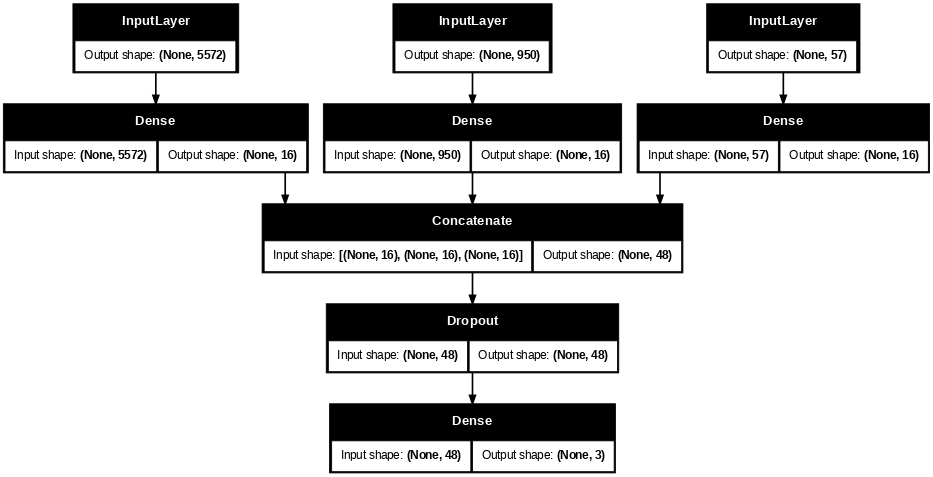

In [ ]:
#Visualize the model.
keras.utils.plot_model(simple_model_cm, show_shapes=True, dpi=60)

####Multi-Class: Embeding Model

The embeding model performed slightly worse then the becnmark, reaching an accuracy of 47.82%.

In [ ]:
#Define our text column lengths and define the maximum
#length for our input layers and vectorizers.
about_lengths_cm   = X_cg_train_about_cm.str.split().str.len()
founder_lengths_cm = X_cg_train_founder_cm.str.split().str.len()
max_len_about_cm   = int(about_lengths_cm.quantile(0.95))
max_len_founder_cm = int(founder_lengths_cm.quantile(0.95))


#Create vectorizers for both of our text columns.
text_vec_about_emb_cm = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode='int', output_sequence_length=max_len_about_cm)
text_vec_about_emb_cm.adapt(X_cg_train_about_cm.values)

text_vec_founder_emb_cm = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode='int', output_sequence_length=max_len_founder_cm)
text_vec_founder_emb_cm.adapt(X_cg_train_founder_cm.values)


#Vectorize both of our text columns in each split.
X_cg_train_about_int_cm   = text_vec_about_emb_cm(X_cg_train_about_cm.values).numpy()
X_cg_val_about_int_cm     = text_vec_about_emb_cm(X_cg_val_about_cm.values).numpy()
X_cg_test_about_int_cm    = text_vec_about_emb_cm(X_cg_test_about_cm.values).numpy()

X_cg_train_founder_int_cm = text_vec_founder_emb_cm(X_cg_train_founder_cm.values).numpy()
X_cg_val_founder_int_cm   = text_vec_founder_emb_cm(X_cg_val_founder_cm.values).numpy()
X_cg_test_founder_int_cm  = text_vec_founder_emb_cm(X_cg_test_founder_cm.values).numpy()

#Define the input shape for our structured branch.
n_struct_cm = X_cg_train_struct_cm.shape[1]


#Define the input layers.
about_input_e_cm   = keras.Input(shape=(max_len_about_cm,),   name="about_input")
founder_input_e_cm = keras.Input(shape=(max_len_founder_cm,), name="founder_input")
struct_input_e_cm  = keras.Input(shape=(n_struct_cm,),         name="struct_input")


#Apply the Layeres for each of our separate branches.
x_a_cm = keras.layers.Embedding(20_000, 64, name="emb_about")(about_input_e_cm)
x_a_cm = keras.layers.GlobalAveragePooling1D()(x_a_cm)
x_a_cm = keras.layers.Dense(64, activation='relu')(x_a_cm)
x_a_cm = keras.layers.Dropout(0.3)(x_a_cm)

x_f_cm = keras.layers.Embedding(20_000, 64, name="emb_founder")(founder_input_e_cm)
x_f_cm = keras.layers.GlobalAveragePooling1D()(x_f_cm)
x_f_cm = keras.layers.Dense(64, activation='relu')(x_f_cm)
x_f_cm = keras.layers.Dropout(0.3)(x_f_cm)

x_s_cm = keras.layers.Dense(32, activation='relu')(struct_input_e_cm)
x_s_cm = keras.layers.Dropout(0.3)(x_s_cm)

#Merge the branches.
combined_e_cm = keras.layers.Concatenate()([x_a_cm, x_f_cm, x_s_cm])
x_e_cm        = keras.layers.Dense(32, activation='relu')(combined_e_cm)
output_e_cm   = keras.layers.Dense(3, activation='softmax')(x_e_cm)  # 3 classes


#Create the model and compile it.
embedding_model_cm = keras.Model(
    inputs=[about_input_e_cm, founder_input_e_cm, struct_input_e_cm],
    outputs=output_e_cm
)
embedding_model_cm.compile(optimizer='rmsprop',
                             loss='sparse_categorical_crossentropy',
                             metrics=['accuracy'])


#Fit the model to our dataset.
history_emb_cm = embedding_model_cm.fit(
    (X_cg_train_about_int_cm, X_cg_train_founder_int_cm,
     X_cg_train_struct_cm.values.astype('float32')),
    y_cg_train_cm.values,
    validation_data=(
        (X_cg_val_about_int_cm, X_cg_val_founder_int_cm,
         X_cg_val_struct_cm.values.astype('float32')),
        y_cg_val_cm.values
    ),
    epochs=10, batch_size=32, class_weight=class_weight_dict_cm
)


#Evaluate the model performance on our test data.
test_loss_emb_cm, test_acc_emb_cm = embedding_model_cm.evaluate(
    (X_cg_test_about_int_cm, X_cg_test_founder_int_cm,
     X_cg_test_struct_cm.values.astype('float32')),
    y_cg_test_cm.values, verbose=0
)

print(f"Embedding Model CG (Multiclass) — Test Accuracy: {test_acc_emb_cm:.4f} | Loss: {test_loss_emb_cm:.4f}")

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.3324 - loss: 36.7727 - val_accuracy: 0.4324 - val_loss: 8.2245
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3355 - loss: 9.4106 - val_accuracy: 0.3728 - val_loss: 2.4018
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3503 - loss: 4.7067 - val_accuracy: 0.4324 - val_loss: 3.6013
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3542 - loss: 2.8801 - val_accuracy: 0.4331 - val_loss: 1.6917
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3789 - loss: 1.8396 - val_accuracy: 0.4876 - val_loss: 1.2003
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4116 - loss: 1.3307 - val_accuracy: 0.5422 - val_loss: 0.9063
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4439 - loss: 1.0931 - val_accuracy: 0.5044 - val_loss: 0.9472
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4764 - loss: 0.9801 - val_accuracy:

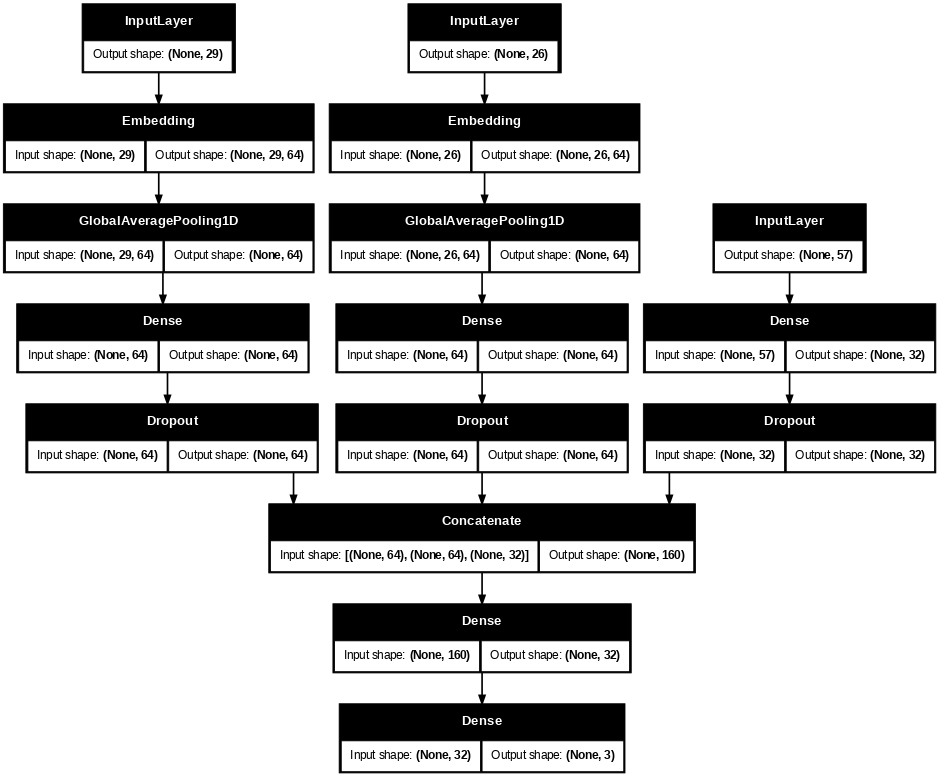

In [ ]:
#Visualize the model.
keras.utils.plot_model(embedding_model_cm, show_shapes=True, dpi=60)

####Multi-Class: RNNs with Embedings

The best performing RNN model was BI-LSTM, reaching an accuracy of 59.81%, beating the benchmark.

In [ ]:
#Define the aggreagte model to be
#used so that we can test out a variety
#RNN architectures.
def build_rnn_model_cm(rnn_layer):
    '''Multiclass three-branch RNN for the ChatGPT dataset.'''


    #Split the text columns to get their length and define
    #the maximum length for the input layers.
    about_lengths_cm   = X_cg_train_about_cm.str.split().str.len()
    founder_lengths_cm = X_cg_train_founder_cm.str.split().str.len()
    max_len_about_cm   = int(about_lengths_cm.quantile(0.95))
    max_len_founder_cm = int(founder_lengths_cm.quantile(0.95))

    #Define the size of the input for the structured branch.
    n_struct_cm = X_cg_train_struct_cm.shape[1]

    #Define the vectorizers for both of our text columns.
    text_vec_about_rnn_cm = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode='int',
        output_sequence_length=max_len_about_cm)
    text_vec_about_rnn_cm.adapt(X_cg_train_about_cm.values)

    text_vec_founder_rnn_cm = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode='int',
        output_sequence_length=max_len_founder_cm)
    text_vec_founder_rnn_cm.adapt(X_cg_train_founder_cm.values)

    #Create a renamed copy of the RNN layer for the founder branch.
    base_name = rnn_layer.name.split("_")[0]
    config = rnn_layer.get_config()
    config['name'] = f"{base_name}_founder_cm"
    founder_rnn_cm = type(rnn_layer).from_config(config)

    if isinstance(rnn_layer, keras.layers.Bidirectional):
        inner_layer  = rnn_layer.forward_layer
        inner_config = inner_layer.get_config()
        inner_config['name'] = f"{inner_layer.name.split('_')[0]}_founder_cm_inner"
        new_inner    = type(inner_layer).from_config(inner_config)
        founder_rnn_cm = keras.layers.Bidirectional(new_inner, name="bidirectional_founder_cm")

    #About text branch.
    about_input_cm = keras.Input(shape=(1,), dtype=tf.string, name="about_input")
    x_a_cm         = text_vec_about_rnn_cm(about_input_cm)
    x_a_cm         = keras.layers.Embedding(20_000, 64, name="emb_about")(x_a_cm)
    x_a_cm         = rnn_layer(x_a_cm)
    x_a_cm         = keras.layers.Dropout(0.3)(x_a_cm)

    #Founder background branch.
    founder_input_cm = keras.Input(shape=(1,), dtype=tf.string, name="founder_input")
    x_f_cm           = text_vec_founder_rnn_cm(founder_input_cm)
    x_f_cm           = keras.layers.Embedding(20_000, 64, name="emb_founder")(x_f_cm)
    x_f_cm           = founder_rnn_cm(x_f_cm)
    x_f_cm           = keras.layers.Dropout(0.3)(x_f_cm)

    #Structured branch.
    struct_input_cm = keras.Input(shape=(n_struct_cm,), name="struct_input")
    x_s_cm          = keras.layers.Dense(32, activation='relu')(struct_input_cm)
    x_s_cm          = keras.layers.Dropout(0.3)(x_s_cm)

    #Merge all three.
    combined_cm = keras.layers.Concatenate()([x_a_cm, x_f_cm, x_s_cm])
    x_cm        = keras.layers.Dense(32, activation='relu')(combined_cm)
    output_cm   = keras.layers.Dense(3, activation='softmax')(x_cm)  # 3 classes


    #Create the RNN model and compile it.
    rnn_model_cm = keras.Model(
        inputs=[about_input_cm, founder_input_cm, struct_input_cm],
        outputs=output_cm
    )
    rnn_model_cm.compile(optimizer='rmsprop',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])


    #Return the specific RNN model.
    return rnn_model_cm


#Run all 6 RNN variants.
rnn_models_cm = {
    "SimpleRNN":    keras.layers.SimpleRNN(64),
    "LSTM":         keras.layers.LSTM(64),
    "GRU":          keras.layers.GRU(64),
    "Bi-SimpleRNN": keras.layers.Bidirectional(keras.layers.SimpleRNN(64)),
    "Bi-LSTM":      keras.layers.Bidirectional(keras.layers.LSTM(64)),
    "Bi-GRU":       keras.layers.Bidirectional(keras.layers.GRU(64)),
}


#Defnie a list to store our RNN results.
results_cm = []

#For loop to fit our models and fill our results list
#with the average of metrics across epochs.
for model_name, rnn_layer in rnn_models_cm.items():

    #Fancy output print statements.
    print(f"\n{'='*50}")
    print(f"Training CG (Multiclass): {model_name}")
    print(f"{'='*50}")


    #Apply our RNN function for the current rnn_layer.
    model_cm = build_rnn_model_cm(rnn_layer)


    #Fit the model to our data.
    history_cm = model_cm.fit(
        (X_cg_train_about_cm.values, X_cg_train_founder_cm.values,
         X_cg_train_struct_cm.values.astype('float32')),
        y_cg_train_cm.values,
        validation_data=(
            (X_cg_val_about_cm.values, X_cg_val_founder_cm.values,
             X_cg_val_struct_cm.values.astype('float32')),
            y_cg_val_cm.values
        ),
        epochs=10, batch_size=32, class_weight=class_weight_dict_cm
    )


    #Get the average validation accuracy and loss across epochs.
    avg_val_acc_cm  = sum(history_cm.history['val_accuracy']) / len(history_cm.history['val_accuracy'])
    avg_val_loss_cm = sum(history_cm.history['val_loss'])     / len(history_cm.history['val_loss'])


    #Evaluate model performance on the test data.
    test_loss_cm, test_acc_cm = model_cm.evaluate(
        (X_cg_test_about_cm.values, X_cg_test_founder_cm.values,
         X_cg_test_struct_cm.values.astype('float32')),
        y_cg_test_cm.values, verbose=0
    )


    #Add the results to our list.
    results_cm.append({
        "Model":            model_name,
        "Avg Val Accuracy": round(avg_val_acc_cm,  4),
        "Avg Val Loss":     round(avg_val_loss_cm, 4),
        "Test Accuracy":    round(test_acc_cm,     4),
        "Test Loss":        round(test_loss_cm,    4),
    })

    print(f"Done! Test Accuracy: {test_acc_cm:.4f}")

#Fancy print statements for a pretty table.
results_df_cm = pd.DataFrame(results_cm).set_index("Model")
print("\n\n===== SUMMARY TABLE (ChatGPT Multiclass) =====")
print(results_df_cm.to_string())


Training CG (Multiclass): SimpleRNN
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.3365 - loss: 35.2180 - val_accuracy: 0.4324 - val_loss: 5.2277
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3520 - loss: 7.7557 - val_accuracy: 0.0792 - val_loss: 8.5245
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3433 - loss: 3.2562 - val_accuracy: 0.4324 - val_loss: 1.2258
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.3416 - loss: 2.1067 - val_accuracy: 0.2522 - val_loss: 1.3555
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3581 - loss: 1.5391 - val_accuracy: 0.2515 - val_loss: 1.2990
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.4036 - loss: 1.2660 - val_accuracy: 0.0792 - val_loss: 2.0301
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.4070 - loss: 1.1651 - val_accuracy: 0.3728 - val_loss: 1.1229
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accu

####Multi-Class: Attention Weights with Simple QKV

The Simple Attention Model performed worse than the benchmark, reaching an accuracy of 43.24%.

In [ ]:
#Find the lenghts for each of our text columns and define the maximum
#lenghts for our input layers.
about_lengths_cm   = X_cg_train_about_cm.str.split().str.len()
founder_lengths_cm = X_cg_train_founder_cm.str.split().str.len()
max_len_about_cm   = int(about_lengths_cm.quantile(0.95))
max_len_founder_cm = int(founder_lengths_cm.quantile(0.95))

#Define the size of the input for our structured branch.
n_struct_cm = X_cg_train_struct_cm.shape[1]


#Initialize the vectorizers for each of our text columns.
text_vec_about_qkv_cm = keras.layers.TextVectorization(
    output_mode='int', max_tokens=20_000, output_sequence_length=max_len_about_cm)
text_vec_about_qkv_cm.adapt(X_cg_train_about_cm.values)

text_vec_founder_qkv_cm = keras.layers.TextVectorization(
    output_mode='int', max_tokens=20_000, output_sequence_length=max_len_founder_cm)
text_vec_founder_qkv_cm.adapt(X_cg_train_founder_cm.values)


#Vectorize the tex  columns.
X_cg_train_about_qkv_cm   = text_vec_about_qkv_cm(X_cg_train_about_cm.values)
X_cg_val_about_qkv_cm     = text_vec_about_qkv_cm(X_cg_val_about_cm.values)
X_cg_test_about_qkv_cm    = text_vec_about_qkv_cm(X_cg_test_about_cm.values)

X_cg_train_founder_qkv_cm = text_vec_founder_qkv_cm(X_cg_train_founder_cm.values)
X_cg_val_founder_qkv_cm   = text_vec_founder_qkv_cm(X_cg_val_founder_cm.values)
X_cg_test_founder_qkv_cm  = text_vec_founder_qkv_cm(X_cg_test_founder_cm.values)


#Define the Vocabulary size and embeding dimensions for the embedings.
VOCAB_SIZE_QKV_CM = 20_001
EMBED_DIM_QKV_CM  = 32

about_input_qkv_cm   = keras.Input(shape=(max_len_about_cm,),   name="about_input")
founder_input_qkv_cm = keras.Input(shape=(max_len_founder_cm,), name="founder_input")
struct_input_qkv_cm  = keras.Input(shape=(n_struct_cm,),         name="struct_input")


#About text branch.
about_emb_cm  = layers.Embedding(VOCAB_SIZE_QKV_CM, EMBED_DIM_QKV_CM, name="emb_about")(about_input_qkv_cm)
attended_a_cm = layers.Attention()([about_emb_cm, about_emb_cm, about_emb_cm])
x_a_cm = layers.GlobalAveragePooling1D()(attended_a_cm)
x_a_cm = layers.Dense(64, activation='relu')(x_a_cm)
x_a_cm = layers.Dropout(0.3)(x_a_cm)


#Founder branch.
founder_emb_cm = layers.Embedding(VOCAB_SIZE_QKV_CM, EMBED_DIM_QKV_CM, name="emb_founder")(founder_input_qkv_cm)
attended_f_cm  = layers.Attention()([founder_emb_cm, founder_emb_cm, founder_emb_cm])
x_f_cm         = layers.GlobalAveragePooling1D()(attended_f_cm)
x_f_cm         = layers.Dense(64, activation='relu')(x_f_cm)
x_f_cm         = layers.Dropout(0.3)(x_f_cm)


#Structured branch.
x_s_cm = layers.Dense(64, activation='relu')(struct_input_qkv_cm)
x_s_cm = layers.Dropout(0.3)(x_s_cm)
x_s_cm = layers.Dense(32, activation='relu')(x_s_cm)


#Merge all three.
merged_qkv_cm = layers.Concatenate()([x_a_cm, x_f_cm, x_s_cm])
merged_qkv_cm = layers.Dense(32, activation='relu')(merged_qkv_cm)
output_qkv_cm = layers.Dense(3, activation='softmax')(merged_qkv_cm)  # 3 classes


#Create the model and compile it.
simple_qkv_model_cm = keras.Model(
    inputs=[about_input_qkv_cm, founder_input_qkv_cm, struct_input_qkv_cm],
    outputs=output_qkv_cm
)

simple_qkv_model_cm.compile(optimizer='rmsprop',
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

#Fit the model ot our dataset.
history_qkv_cm = simple_qkv_model_cm.fit(
    x=[X_cg_train_about_qkv_cm.numpy(), X_cg_train_founder_qkv_cm.numpy(),
       X_cg_train_struct_cm.values.astype('float32')],
    y=y_cg_train_cm.values,
    validation_data=(
        [X_cg_val_about_qkv_cm.numpy(), X_cg_val_founder_qkv_cm.numpy(),
         X_cg_val_struct_cm.values.astype('float32')],
        y_cg_val_cm.values
    ),
    epochs=20, batch_size=16, class_weight=class_weight_dict_cm,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                                              restore_best_weights=True)]
)



#Evaluate the model's performance on the test data.
test_loss_qkv_cm, test_acc_qkv_cm = simple_qkv_model_cm.evaluate(
    [X_cg_test_about_qkv_cm.numpy(), X_cg_test_founder_qkv_cm.numpy(),
     X_cg_test_struct_cm.values.astype('float32')],
    y_cg_test_cm.values
)
print(f"QKV Attention CG (Multiclass) — Test Accuracy: {test_acc_qkv_cm:.4f} | Loss: {test_loss_qkv_cm:.4f}")

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.3503 - loss: 14.8164 - val_accuracy: 0.0792 - val_loss: 3.8687
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3578 - loss: 2.9843 - val_accuracy: 0.0792 - val_loss: 3.6646
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3307 - loss: 1.5835 - val_accuracy: 0.4324 - val_loss: 1.2051
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3428 - loss: 1.2428 - val_accuracy: 0.1817 - val_loss: 1.1835
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3939 - loss: 1.1493 - val_accuracy: 0.2108 - val_loss: 1.1590
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4264 - loss: 1.0854 - val_accuracy: 0.3496 - val_loss: 1.0683
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4324 - loss: 1.2061
QKV Attention CG (Multiclass) — Test Accuracy: 0.4324 | Loss: 1.2061


In [ ]:
#Visualize the model.
keras.utils.plot_model(simple_qkv_model_cm, show_shapes=True, dpi=60)

####Multi-Class: Multi-Head Attention

The Multi-Head Attention model was able to beat the benchmark, reaching an accuracy of 59%.

In [ ]:
#Determine the lengths of the text columns and define a maximum legnth
#for the input layers.
about_lengths_cm   = X_cg_train_about_cm.str.split().str.len()
founder_lengths_cm = X_cg_train_founder_cm.str.split().str.len()
max_len_about_cm   = int(about_lengths_cm.quantile(0.95))
max_len_founder_cm = int(founder_lengths_cm.quantile(0.95))

#Deifne the Vocabulary size, Embeding Dimensions, and the
#number of heads for the multi-head attention.
VOCAB_SIZE_MHA_CM = 10_001
EMBED_DIM_MHA_CM  = 32
NUM_HEADS_MHA_CM  = 2

#Determine the size of the input for the structured
#branch.
n_struct_cm = X_cg_train_struct_cm.shape[1]


#Create vectorizers for both of our text columns.
text_vec_about_mha_cm = keras.layers.TextVectorization(
    max_tokens=10_000, output_mode='int', output_sequence_length=max_len_about_cm)
text_vec_about_mha_cm.adapt(X_cg_train_about_cm.values)

text_vec_founder_mha_cm = keras.layers.TextVectorization(
    max_tokens=10_000, output_mode='int', output_sequence_length=max_len_founder_cm)
text_vec_founder_mha_cm.adapt(X_cg_train_founder_cm.values)


#Vectorize both of our text columns.
X_cg_train_about_mha_cm   = text_vec_about_mha_cm(X_cg_train_about_cm.values)
X_cg_val_about_mha_cm     = text_vec_about_mha_cm(X_cg_val_about_cm.values)
X_cg_test_about_mha_cm    = text_vec_about_mha_cm(X_cg_test_about_cm.values)

X_cg_train_founder_mha_cm = text_vec_founder_mha_cm(X_cg_train_founder_cm.values)
X_cg_val_founder_mha_cm   = text_vec_founder_mha_cm(X_cg_val_founder_cm.values)
X_cg_test_founder_mha_cm  = text_vec_founder_mha_cm(X_cg_test_founder_cm.values)


#Input layers for each of our branches.
about_input_mha_cm   = keras.Input(shape=(max_len_about_cm,),   name="about_input")
founder_input_mha_cm = keras.Input(shape=(max_len_founder_cm,), name="founder_input")
struct_input_mha_cm  = keras.Input(shape=(n_struct_cm,),         name="struct_input")


#The About Text branch.
about_emb_mha_cm  = layers.Embedding(VOCAB_SIZE_MHA_CM, EMBED_DIM_MHA_CM, name="emb_about")(about_input_mha_cm)
attended_a_mha_cm = layers.MultiHeadAttention(
    num_heads=NUM_HEADS_MHA_CM, key_dim=EMBED_DIM_MHA_CM // NUM_HEADS_MHA_CM
)(about_emb_mha_cm, about_emb_mha_cm, about_emb_mha_cm)
x_a_mha_cm = layers.GlobalAveragePooling1D()(attended_a_mha_cm)
x_a_mha_cm = layers.Dense(64, activation='relu')(x_a_mha_cm)
x_a_mha_cm = layers.Dropout(0.3)(x_a_mha_cm)


#The Founder branch.
founder_emb_mha_cm  = layers.Embedding(VOCAB_SIZE_MHA_CM, EMBED_DIM_MHA_CM, name="emb_founder")(founder_input_mha_cm)
attended_f_mha_cm   = layers.MultiHeadAttention(
    num_heads=NUM_HEADS_MHA_CM, key_dim=EMBED_DIM_MHA_CM // NUM_HEADS_MHA_CM
)(founder_emb_mha_cm, founder_emb_mha_cm, founder_emb_mha_cm)
x_f_mha_cm = layers.GlobalAveragePooling1D()(attended_f_mha_cm)
x_f_mha_cm = layers.Dense(64, activation='relu')(x_f_mha_cm)
x_f_mha_cm = layers.Dropout(0.3)(x_f_mha_cm)

#The Structured branch.
x_s_mha_cm = layers.Dense(64, activation='relu')(struct_input_mha_cm)
x_s_mha_cm = layers.Dropout(0.3)(x_s_mha_cm)
x_s_mha_cm = layers.Dense(32, activation='relu')(x_s_mha_cm)


#Merge all three.
merged_mha_cm = layers.Concatenate()([x_a_mha_cm, x_f_mha_cm, x_s_mha_cm])
merged_mha_cm = layers.Dense(32, activation='relu')(merged_mha_cm)
output_mha_cm = layers.Dense(3, activation='softmax')(merged_mha_cm)  # 3 classes


#Createa the model and compile it.
mha_model_cm = keras.Model(
    inputs=[about_input_mha_cm, founder_input_mha_cm, struct_input_mha_cm],
    outputs=output_mha_cm
)

mha_model_cm.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

#Fit the model to our data.
history_mha_cm = mha_model_cm.fit(
    x=[X_cg_train_about_mha_cm.numpy(), X_cg_train_founder_mha_cm.numpy(),
       X_cg_train_struct_cm.values.astype('float32')],
    y=y_cg_train_cm.values,
    validation_data=(
        [X_cg_val_about_mha_cm.numpy(), X_cg_val_founder_mha_cm.numpy(),
         X_cg_val_struct_cm.values.astype('float32')],
        y_cg_val_cm.values
    ),
    epochs=20, batch_size=16, class_weight=class_weight_dict_cm,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                                              restore_best_weights=True)]
)


#Evaluate the model to the test data.
test_loss_mha_cm, test_acc_mha_cm = mha_model_cm.evaluate(
    [X_cg_test_about_mha_cm.numpy(), X_cg_test_founder_mha_cm.numpy(),
     X_cg_test_struct_cm.values.astype('float32')],
    y_cg_test_cm.values
)
print(f"MultiHead Attention CG (Multiclass) — Test Accuracy: {test_acc_mha_cm:.4f} | Loss: {test_loss_mha_cm:.4f}")

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3353 - loss: 14.8349 - val_accuracy: 0.4884 - val_loss: 1.1398
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3716 - loss: 2.3595 - val_accuracy: 0.5625 - val_loss: 1.1631
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4594 - loss: 1.3955 - val_accuracy: 0.3852 - val_loss: 1.2190
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4926 - loss: 1.1274 - val_accuracy: 0.6221 - val_loss: 0.8900
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5825 - loss: 0.8987 - val_accuracy: 0.4266 - val_loss: 1.2935
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6468 - loss: 0.7300 - val_accuracy: 0.4782 - val_loss: 1.2194
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7518 - loss: 0.5477 - val_accuracy: 0.5363 - val_loss: 1.3062
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5908 - loss: 0.8807
MultiHead Attention CG (Mult

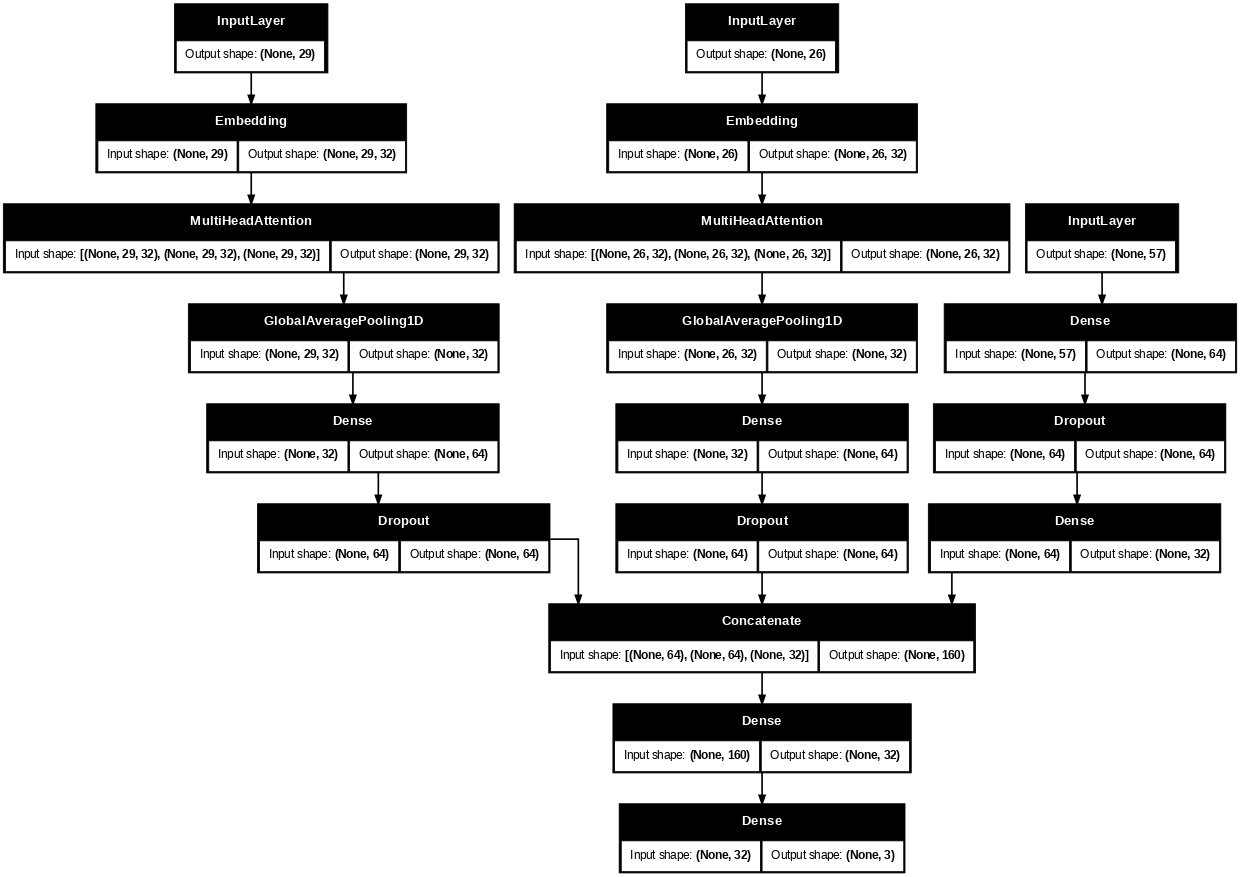

In [ ]:
#Visualize the model.
keras.utils.plot_model(mha_model_cm, show_shapes=True, dpi=60)

##Logo Images Trials

In this seciton, I apply my folder with company Logos into the datasets to check if that improves their performance. In the code block below I have introduced some helper functions:

* load_logo(company_name) looks for the specific logo with the same company name.

* build_image_arrays(company_names), repeatedly calls the previous function to build the image arrays.

* filter_split is here so that we can filter out the rows that do not have corresponding images.

* build_image_branch builds the image branch that will be used in our Neural Network models.

The _f represents that those splits are filtered, and the _m represents that they are for multiclass.

In [ ]:
#Path to verified logos folder in Google Drive.
LOGO_DIR = "/content/drive/MyDrive/Spring 2026/BA510/Project/Data/Phase 1/verified_logos"

#Every logo gets resized to this fixed size
#before entering the CNN. A neural network
#requires all inputs to be the same shape.
IMG_SIZE  = (64, 64)


def load_logo(company_name: str):
    """Load one logo as a (64,64,3) float32 array.
    Returns None if no logo file is found."""

    #Normalize the company name into a filename
    #slug so it matches files in the logo folder.
    #e.g. "My Company!" becomes "my_company"
    slug = company_name.strip().replace(" ", "_").replace("-", "_")
    slug = "".join(c for c in slug if c.isalnum() or c == "_")

    #Try three common image extensions in order,
    #stopping as soon as we find a match.
    for ext in [".png", ".jpg", ".jpeg"]:
        path = os.path.join(LOGO_DIR, slug + ext)

        #If the file exists, load it, resize it
        #to 64x64, and normalise pixel values
        #from 0-255 down to 0.0-1.0 so the CNN
        #trains more stably.
        if os.path.exists(path):
            img = tf.io.read_file(path)
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            img = tf.image.resize(img, IMG_SIZE)
            img = tf.cast(img, tf.float32) / 255.0
            return img.numpy()

    #No logo file found — return None so the
    #caller knows to drop this row.
    return None


def build_image_arrays(company_names, label=""):
    """Build a (n_kept, 64, 64, 3) image array
    and a boolean keep-mask for one data split.
    Rows with no logo file are excluded.

    Returns:
        images   : float32 array (n_kept, 64, 64, 3)
        keep_mask: bool array (n_total,)
                   True  = logo found, row kept
                   False = no logo, row dropped
    """

    #Attempt to load a logo for every company,
    #storing None where no file was found.
    raw = [load_logo(str(n)) for n in company_names]

    #Build a boolean mask — True wherever we
    #got a real image back from load_logo.
    keep_mask = np.array([img is not None for img in raw])

    #Stack only the real images into one array.
    images = np.array([img for img in raw if img is not None],
                      dtype=np.float32)

    #Print a diagnostic summary so we know
    #how many logos were found vs dropped.
    n_total   = len(raw)
    n_kept    = keep_mask.sum()
    n_dropped = n_total - n_kept
    print(f"  {label}: {n_kept}/{n_total} kept, "
          f"{n_dropped} dropped ({100*n_dropped/n_total:.1f}%)")

    return images, keep_mask


def filter_split(mask, *arrays):
    """Apply a boolean mask to any number of
    numpy arrays or pandas Series, returning
    only the rows where mask is True."""
    return [a[mask] if isinstance(a, np.ndarray) else a.values[mask]
            for a in arrays]


def build_image_branch(name_prefix):
    """Build and return a small CNN image branch
    ready to plug into Concatenate() alongside
    the text and structured branches.

    Architecture:
        Input (64,64,3)
        Conv2D(32, 3x3, relu) — detects basic shapes
        MaxPool(2x2)
        Conv2D(64, 3x3, relu) — detects complex patterns
        MaxPool(2x2)
        Flatten → Dense(64, relu) → Dropout(0.3)

    Returns img_input and x_img tensors.
    """

    #Input layer expecting a 64x64 RGB image.
    img_input = keras.Input(shape=(64, 64, 3), name=f"{name_prefix}_input")

    #First convolutional block — learns to detect
    #edges, colors, and basic shapes in the logo.
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      name=f"{name_prefix}_conv1")(img_input)
    x = layers.MaxPooling2D((2,2), name=f"{name_prefix}_pool1")(x)

    #Second convolutional block — learns more
    #complex combinations of the simpler patterns.
    x = layers.Conv2D(64, (3,3), activation="relu", padding="same",
                      name=f"{name_prefix}_conv2")(x)
    x = layers.MaxPooling2D((2,2), name=f"{name_prefix}_pool2")(x)

    #Flatten the 2D feature maps into a 1D vector
    #so we can merge with the text branches.
    x = layers.Flatten(name=f"{name_prefix}_flatten")(x)

    #A dense layer to compress the CNN output
    #to a fixed size before the merge.
    x = layers.Dense(64, activation="relu", name=f"{name_prefix}_dense")(x)
    x = layers.Dropout(0.3, name=f"{name_prefix}_dropout")(x)

    #Return both the input and the final layer
    #so the caller can wire them into the model.
    return img_input, x


# ─────────────────────────────────────────────────────────────────────────────
# Load logo arrays for every split of both datasets.
# NOTE: change "company_name" below if your company
#       name column is called something different.
# ─────────────────────────────────────────────────────────────────────────────

#Build a lookup Series that maps the shuffled
#integer index back to each company's name.
#startup_df still has company_name intact.
print("=== Loading logos — original dataset ===")
name_lookup = startup_df["company_name"].reset_index(drop=True)

#Load and filter each split, getting back both
#the image array and the boolean keep mask.
X_train_logos, mask_train = build_image_arrays(name_lookup.iloc[X_train_m.index], "train")
X_val_logos,   mask_val   = build_image_arrays(name_lookup.iloc[X_val_m.index],   "val")
X_test_logos,  mask_test  = build_image_arrays(name_lookup.iloc[X_test_m.index],  "test")

#Apply the same mask to the binary text,
#structured, and y splits so all arrays
#stay aligned row-for-row with the images.
X_train_text_f, X_train_structured_f, y_train_f = filter_split(
    mask_train, X_train_text, X_train_structured.astype("float32"), y_train)

X_val_text_f,   X_val_structured_f,   y_val_f   = filter_split(
    mask_val,   X_val_text,   X_val_structured.astype("float32"),   y_val)

X_test_text_f,  X_test_structured_f,  y_test_f  = filter_split(
    mask_test,  X_test_text,  X_test_structured.astype("float32"),  y_test)

#Apply the same mask to the multiclass splits.
X_train_text_m_f, X_train_structured_m_f, y_train_m_f = filter_split(
    mask_train, X_train_text_m, X_train_structured_m.astype("float32"), y_train_m)

X_val_text_m_f,   X_val_structured_m_f,   y_val_m_f   = filter_split(
    mask_val,   X_val_text_m,   X_val_structured_m.astype("float32"),   y_val_m)

X_test_text_m_f,  X_test_structured_m_f,  y_test_m_f  = filter_split(
    mask_test,  X_test_text_m,  X_test_structured_m.astype("float32"),  y_test_m)


print("\n=== Loading logos — ChatGPT dataset ===")
cg_name_lookup = chatgpt_df["company_name"].reset_index(drop=True)

X_cg_train_logos, mask_cg_train = build_image_arrays(cg_name_lookup.iloc[X_cg_train_cm.index], "train")
X_cg_val_logos,   mask_cg_val   = build_image_arrays(cg_name_lookup.iloc[X_cg_val_cm.index],   "val")
X_cg_test_logos,  mask_cg_test  = build_image_arrays(cg_name_lookup.iloc[X_cg_test_cm.index],  "test")

#Apply the mask to the ChatGPT binary splits.
X_cg_train_about_f, X_cg_train_founder_f, X_cg_train_structured_f, y_cg_train_f = filter_split(
    mask_cg_train, X_cg_train_about, X_cg_train_founder,
    X_cg_train_structured.astype("float32"), y_cg_train)

X_cg_val_about_f,   X_cg_val_founder_f,   X_cg_val_structured_f,   y_cg_val_f   = filter_split(
    mask_cg_val,   X_cg_val_about,   X_cg_val_founder,
    X_cg_val_structured.astype("float32"),   y_cg_val)

X_cg_test_about_f,  X_cg_test_founder_f,  X_cg_test_structured_f,  y_cg_test_f  = filter_split(
    mask_cg_test,  X_cg_test_about,  X_cg_test_founder,
    X_cg_test_structured.astype("float32"),  y_cg_test)

#Apply the mask to the ChatGPT multiclass splits.
X_cg_train_about_cm_f, X_cg_train_founder_cm_f, X_cg_train_struct_cm_f, y_cg_train_cm_f = filter_split(
    mask_cg_train, X_cg_train_about_cm, X_cg_train_founder_cm,
    X_cg_train_struct_cm.astype("float32"), y_cg_train_cm)

X_cg_val_about_cm_f,   X_cg_val_founder_cm_f,   X_cg_val_struct_cm_f,   y_cg_val_cm_f   = filter_split(
    mask_cg_val,   X_cg_val_about_cm,   X_cg_val_founder_cm,
    X_cg_val_struct_cm.astype("float32"),   y_cg_val_cm)

X_cg_test_about_cm_f,  X_cg_test_founder_cm_f,  X_cg_test_struct_cm_f,  y_cg_test_cm_f  = filter_split(
    mask_cg_test,  X_cg_test_about_cm,  X_cg_test_founder_cm,
    X_cg_test_struct_cm.astype("float32"),  y_cg_test_cm)


#Recompute class weights on the filtered training
#labels because dropping rows may shift the class
#distribution slightly from the original weights.
from sklearn.utils.class_weight import compute_class_weight

class_weights_m_f = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_m_f), y=y_train_m_f)
class_weight_dict_m_f = dict(enumerate(class_weights_m_f))

class_weights_cm_f = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_cg_train_cm_f), y=y_cg_train_cm_f)
class_weight_dict_cm_f = dict(enumerate(class_weights_cm_f))

print(f"\nOriginal multiclass weights (filtered): {class_weight_dict_m_f}")
print(f"ChatGPT multiclass weights (filtered):  {class_weight_dict_cm_f}")

=== Loading logos — original dataset ===
  train: 415/654 kept, 239 dropped (36.5%)
  val: 135/218 kept, 83 dropped (38.1%)
  test: 145/218 kept, 73 dropped (33.5%)

=== Loading logos — ChatGPT dataset ===
  train: 2337/4125 kept, 1788 dropped (43.3%)
  val: 778/1376 kept, 598 dropped (43.5%)
  test: 772/1376 kept, 604 dropped (43.9%)

Original multiclass weights (filtered): {0: np.float64(0.8755274261603375), 1: np.float64(0.6747967479674797), 2: np.float64(2.66025641025641)}
ChatGPT multiclass weights (filtered):  {0: np.float64(0.7876643073811931), 1: np.float64(0.6738754325259516), 2: np.float64(4.057291666666667)}


###Wayback Machine Dataset

####Logo: Simple Text Vectorization Binary

The text vectorizer with logos, performed pretty well when compared to the benchmark, reaching an accuracy of 63.45%.

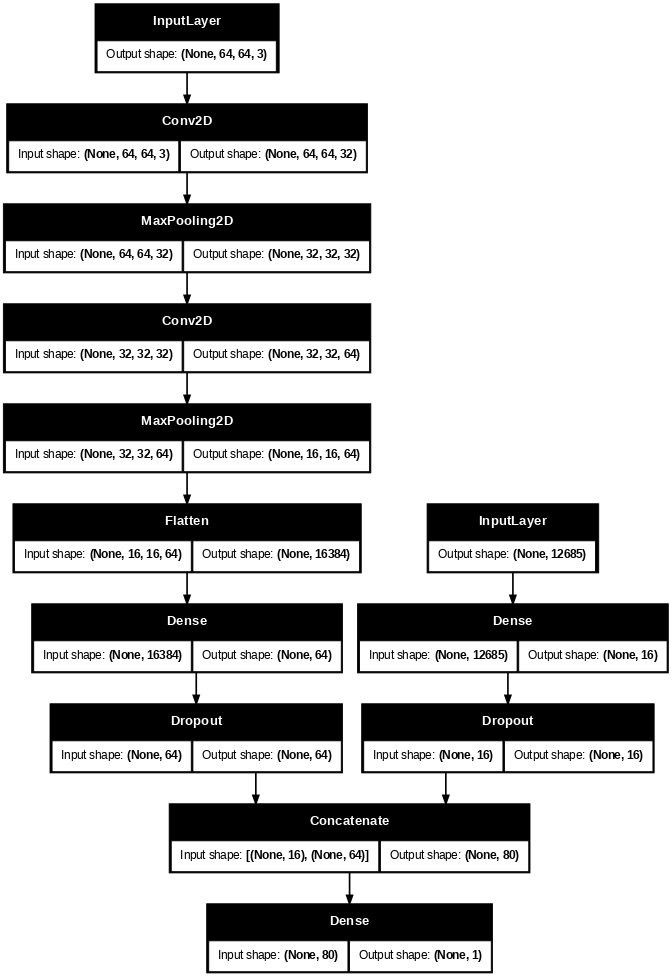

In [ ]:
#Create and adapt a multi-hot vectorizer on
#filtered training text only, so the vocabulary
#is learned only from logo-matched rows.
text_vec_simple_logo_bin = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="multi_hot"
)
text_vec_simple_logo_bin.adapt(X_train_text_f)

#Apply the vectorizer to each filtered split.
X_train_text_vec_slb = text_vec_simple_logo_bin(X_train_text_f).numpy()
X_val_text_vec_slb   = text_vec_simple_logo_bin(X_val_text_f).numpy()
X_test_text_vec_slb  = text_vec_simple_logo_bin(X_test_text_f).numpy()

#Concatenate the vectorized text with the filtered
#structured features into one flat input vector,
#mirroring what the original simple model does.
X_train_comb_slb = np.concatenate(
    [X_train_text_vec_slb, X_train_structured_f], axis=1)
X_val_comb_slb   = np.concatenate(
    [X_val_text_vec_slb,   X_val_structured_f], axis=1)
X_test_comb_slb  = np.concatenate(
    [X_test_text_vec_slb,  X_test_structured_f], axis=1)

#Text + structured flat branch — a single Dense
#layer processes the combined input vector.
flat_input_slb = keras.Input(shape=(X_train_comb_slb.shape[1],),
                              name="flat_input")
x_flat_slb = keras.layers.Dense(16, activation="relu")(flat_input_slb)
x_flat_slb = keras.layers.Dropout(0.5)(x_flat_slb)

#Image (CNN) branch.
img_input_slb, x_img_slb = build_image_branch("logo_slb")

#Merge the flat branch and the image branch
#into a single output neuron with sigmoid.
combined_slb = keras.layers.Concatenate()([x_flat_slb, x_img_slb])
output_slb   = keras.layers.Dense(1, activation="sigmoid")(combined_slb)

#Define the model blueprint and compile it.
simple_logo_model_bin = keras.Model(
    inputs=[flat_input_slb, img_input_slb], outputs=output_slb)
simple_logo_model_bin.compile(
    optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(simple_logo_model_bin, show_shapes=True, dpi=60)

In [ ]:
#Fit the model using the filtered splits so that
#every row in the batch has a corresponding logo.
history_simple_logo_bin = simple_logo_model_bin.fit(
    x=[X_train_comb_slb, X_train_logos],
    y=y_train_f,
    validation_data=([X_val_comb_slb, X_val_logos], y_val_f),
    epochs=10, batch_size=32
)

#Evaluate the model on the filtered test set.
test_loss_slb, test_acc_slb = simple_logo_model_bin.evaluate(
    [X_test_comb_slb, X_test_logos], y_test_f)
print(f"\nSimple + Logo (Binary) — Test Accuracy: {test_acc_slb:.4f} | Loss: {test_loss_slb:.4f}")

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step - accuracy: 0.4892 - loss: 8.1016 - val_accuracy: 0.4889 - val_loss: 1.1687
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5687 - loss: 1.9537 - val_accuracy: 0.6148 - val_loss: 0.6842
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6000 - loss: 0.7488 - val_accuracy: 0.6296 - val_loss: 0.6548
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6530 - loss: 0.6466 - val_accuracy: 0.6370 - val_loss: 0.6578
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6506 - loss: 0.6333 - val_accuracy: 0.6370 - val_loss: 0.6603
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6578 - loss: 0.6690 - val_accuracy: 0.6222 - val_loss: 0.6795
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6819 - loss: 0.6120 - val_accuracy: 0.6370 - val_loss: 0.6604
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6723 - loss: 0.5844 - val_accuracy: 0.6370 - 

####Logo: Embeding Model Binary

The Embeding Model with logos, performed poorly when compared to the benchmark, reaching an accuracy of 34.48%.

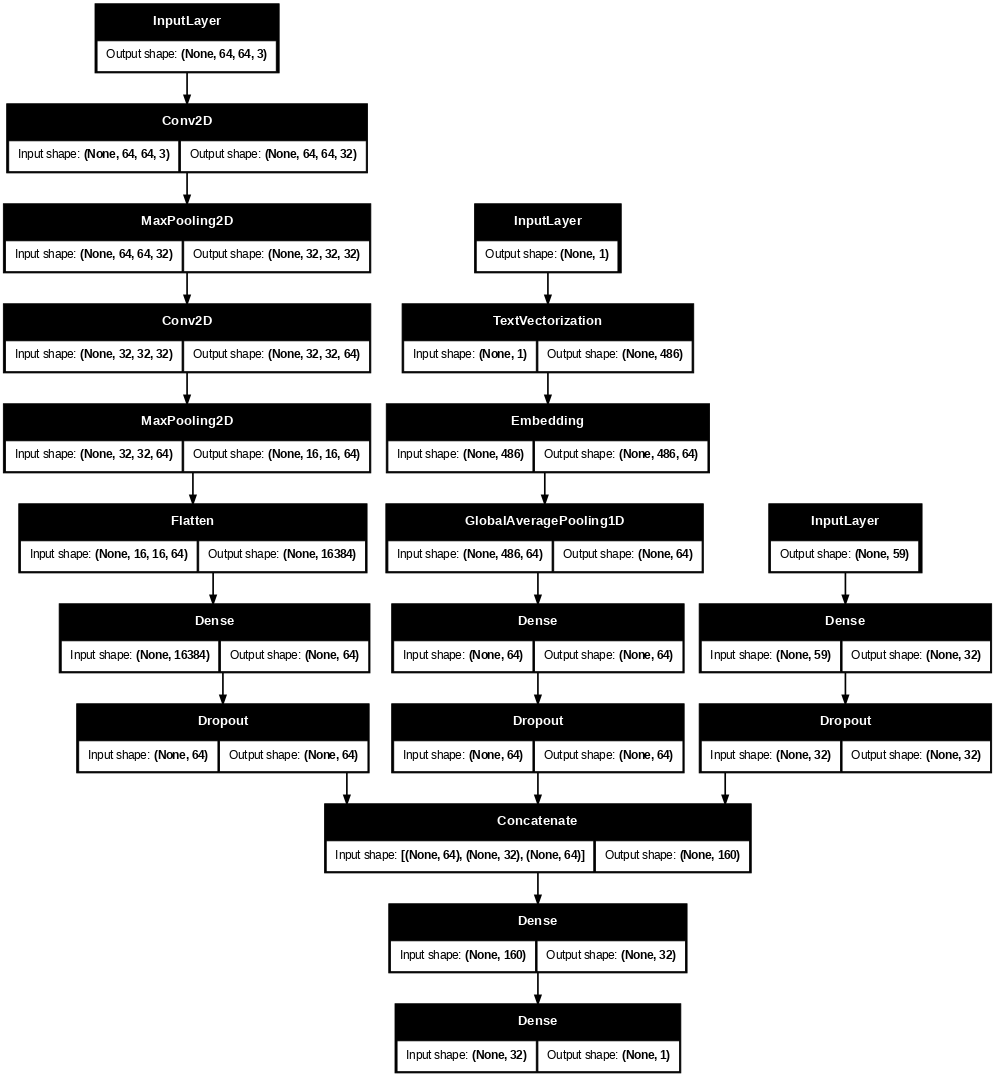

In [ ]:
#Create a vectorizer using output_mode="int" so
#each word gets an integer ID for the Embedding
#layer. Adapt it only on filtered training text.
text_vec_emb_logo_bin = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="int",
    output_sequence_length=int(
        pd.Series(X_train_text_f).str.split().str.len().quantile(0.95))
)
text_vec_emb_logo_bin.adapt(X_train_text_f)

#Get the number of structured columns for
#the structured branch input layer.
n_structured_elb = X_train_structured_f.shape[1]

#Text branch — vectorize, embed, pool, dense.
text_input_elb = keras.Input(shape=(1,), dtype=tf.string, name="text_input")
x_t_elb = text_vec_emb_logo_bin(text_input_elb)
x_t_elb = keras.layers.Embedding(20_000, 64, name="emb_elb")(x_t_elb)
x_t_elb = keras.layers.GlobalAveragePooling1D()(x_t_elb)
x_t_elb = keras.layers.Dense(64, activation="relu")(x_t_elb)
x_t_elb = keras.layers.Dropout(0.3)(x_t_elb)

#Structured branch.
struct_input_elb = keras.Input(shape=(n_structured_elb,), name="struct_input")
x_s_elb = keras.layers.Dense(32, activation="relu")(struct_input_elb)
x_s_elb = keras.layers.Dropout(0.3)(x_s_elb)

#Image (CNN) branch.
img_input_elb, x_img_elb = build_image_branch("logo_elb")

#Merge all three branches and output a
#single sigmoid prediction.
combined_elb = keras.layers.Concatenate()([x_t_elb, x_s_elb, x_img_elb])
x_elb        = keras.layers.Dense(32, activation="relu")(combined_elb)
output_elb   = keras.layers.Dense(1, activation="sigmoid")(x_elb)

#Define the model blueprint and compile it.
emb_logo_model_bin = keras.Model(
    inputs=[text_input_elb, struct_input_elb, img_input_elb], outputs=output_elb)
emb_logo_model_bin.compile(
    optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(emb_logo_model_bin, show_shapes=True, dpi=60)

In [ ]:
#Fit the model using the filtered splits.
history_emb_logo_bin = emb_logo_model_bin.fit(
    x=[X_train_text_f, X_train_structured_f, X_train_logos],
    y=y_train_f,
    validation_data=(
        [X_val_text_f, X_val_structured_f, X_val_logos],
        y_val_f),
    epochs=10, batch_size=32
)

#Evaluate the model on the filtered test set.
test_loss_elb, test_acc_elb = emb_logo_model_bin.evaluate(
    [X_test_text_f, X_test_structured_f, X_test_logos],
    y_test_f)
print(f"\nEmbedding + Logo (Binary) — Test Accuracy: {test_acc_elb:.4f} | Loss: {test_loss_elb:.4f}")

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5012 - loss: 29.4775 - val_accuracy: 0.6074 - val_loss: 11.2611
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5470 - loss: 16.6815 - val_accuracy: 0.6444 - val_loss: 9.2545
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5133 - loss: 13.2320 - val_accuracy: 0.6000 - val_loss: 4.6675
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5807 - loss: 8.9224 - val_accuracy: 0.6370 - val_loss: 5.0799
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5205 - loss: 7.2214 - val_accuracy: 0.6370 - val_loss: 3.9903
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5422 - loss: 6.5912 - val_accuracy: 0.6370 - val_loss: 6.0772
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5639 - loss: 5.0464 - val_accuracy: 0.6370 - val_loss: 4.3323
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6024 - loss: 3.5441 - val_accuracy: 0.3630

####Logo: RNN Models Binary

Out of all the RNN models here, the Bi-LSTM model performed the best with an Accuracy of 62.07%.

In [ ]:
#Builder function that constructs a binary RNN
#model with a CNN image branch added, mirroring
#build_rnn_model() but using filtered splits and
#an extra image input.
def build_rnn_logo_model_bin(rnn_layer):
    """Binary RNN + logo CNN for the original dataset."""

    #Compute the 95th percentile text length on
    #filtered training text to set the sequence
    #length for the vectorizer.
    max_len   = int(pd.Series(X_train_text_f).str.split().str.len().quantile(0.95))

    #Get the number of structured columns.
    n_struct  = X_train_structured_f.shape[1]

    #Extract the base RNN layer name for use in
    #unique layer name prefixes.
    base_name = rnn_layer.name.split("_")[0]

    #Adapt the text vectorizer on filtered
    #training text only.
    tv = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode="int",
        output_sequence_length=max_len)
    tv.adapt(X_train_text_f)

    #Text branch.
    text_input = keras.Input(shape=(1,), dtype=tf.string, name="text_input")
    x_t = tv(text_input)
    x_t = keras.layers.Embedding(20_000, 64, name=f"emb_{base_name}_lb")(x_t)
    x_t = rnn_layer(x_t) #The only part that changes across RNN variants.
    x_t = keras.layers.Dropout(0.3)(x_t)

    #Structured branch.
    struct_input = keras.Input(shape=(n_struct,), name="struct_input")
    x_s = keras.layers.Dense(32, activation="relu")(struct_input)
    x_s = keras.layers.Dropout(0.3)(x_s)

    #Image (CNN) branch.
    img_input, x_img = build_image_branch(f"logo_{base_name}_lb")

    #Merge all three branches and output a
    #single sigmoid prediction.
    combined = keras.layers.Concatenate()([x_t, x_s, x_img])
    x        = keras.layers.Dense(32, activation="relu")(combined)
    output   = keras.layers.Dense(1, activation="sigmoid")(x)

    #Define the model and compile it.
    model = keras.Model(inputs=[text_input, struct_input, img_input], outputs=output)
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model


#Dictionary of the six RNN variants to test.
rnn_logo_models_bin = {
    "SimpleRNN":    keras.layers.SimpleRNN(64),
    "LSTM":         keras.layers.LSTM(64),
    "GRU":          keras.layers.GRU(64),
    "Bi-SimpleRNN": keras.layers.Bidirectional(keras.layers.SimpleRNN(64)),
    "Bi-LSTM":      keras.layers.Bidirectional(keras.layers.LSTM(64)),
    "Bi-GRU":       keras.layers.Bidirectional(keras.layers.GRU(64)),
}

#Empty list to store results across all variants.
results_rnn_logo_bin = []

#Loop through each RNN variant, train it,
#and record its performance.
for model_name, rnn_layer in rnn_logo_models_bin.items():
    print(f"\n{'='*50}")
    print(f"Training (Original Binary + Logo): {model_name}")
    print(f"{'='*50}")

    #Build the model with the current RNN layer.
    model = build_rnn_logo_model_bin(rnn_layer)

    #Fit the model using the filtered splits.
    history = model.fit(
        x=[X_train_text_f, X_train_structured_f, X_train_logos],
        y=y_train_f,
        validation_data=(
            [X_val_text_f, X_val_structured_f, X_val_logos],
            y_val_f),
        epochs=10, batch_size=16
    )

    #Calculate the average validation accuracy
    #and loss across all epochs.
    avg_val_acc  = sum(history.history["val_accuracy"]) / len(history.history["val_accuracy"])
    avg_val_loss = sum(history.history["val_loss"])     / len(history.history["val_loss"])

    #Evaluate on the filtered test set.
    test_loss, test_acc = model.evaluate(
        [X_test_text_f, X_test_structured_f, X_test_logos],
        y_test_f, verbose=0)

    #Store the results for the summary table.
    results_rnn_logo_bin.append({
        "Model":            model_name,
        "Avg Val Accuracy": round(avg_val_acc,  4),
        "Avg Val Loss":     round(avg_val_loss,  4),
        "Test Accuracy":    round(test_acc,  4),
        "Test Loss":        round(test_loss, 4),
    })
    print(f"Done! Test Accuracy: {test_acc:.4f}")

#Print a summary table of all RNN results.
results_rnn_logo_bin_df = pd.DataFrame(results_rnn_logo_bin).set_index("Model")
print("\n\n===== ORIGINAL BINARY + LOGO — RNN SUMMARY =====")
print(results_rnn_logo_bin_df.to_string())


Training (Original Binary + Logo): SimpleRNN
Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 476ms/step - accuracy: 0.5446 - loss: 14.7682 - val_accuracy: 0.6370 - val_loss: 11.6648
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 451ms/step - accuracy: 0.5253 - loss: 8.3545 - val_accuracy: 0.6370 - val_loss: 8.5662
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 461ms/step - accuracy: 0.5831 - loss: 5.8288 - val_accuracy: 0.6370 - val_loss: 3.9444
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 477ms/step - accuracy: 0.5398 - loss: 4.8456 - val_accuracy: 0.6370 - val_loss: 1.7482
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 448ms/step - accuracy: 0.5470 - loss: 3.5604 - val_accuracy: 0.6370 - val_loss: 2.3810
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 458ms/step - accuracy: 0.5518 - loss: 3.7568 - val_accuracy: 0.3630 - val_loss: 0.8617
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 465ms/step - accuracy: 0.5494 - loss: 2.9200 - val_accuracy: 0.6370 - val_loss: 3.6232
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 447ms/s

Logo: QKV Attention Binary

The simple attention model with logos, performed pretty well when compared to the benchmark, reaching an accuracy of 65.52%.

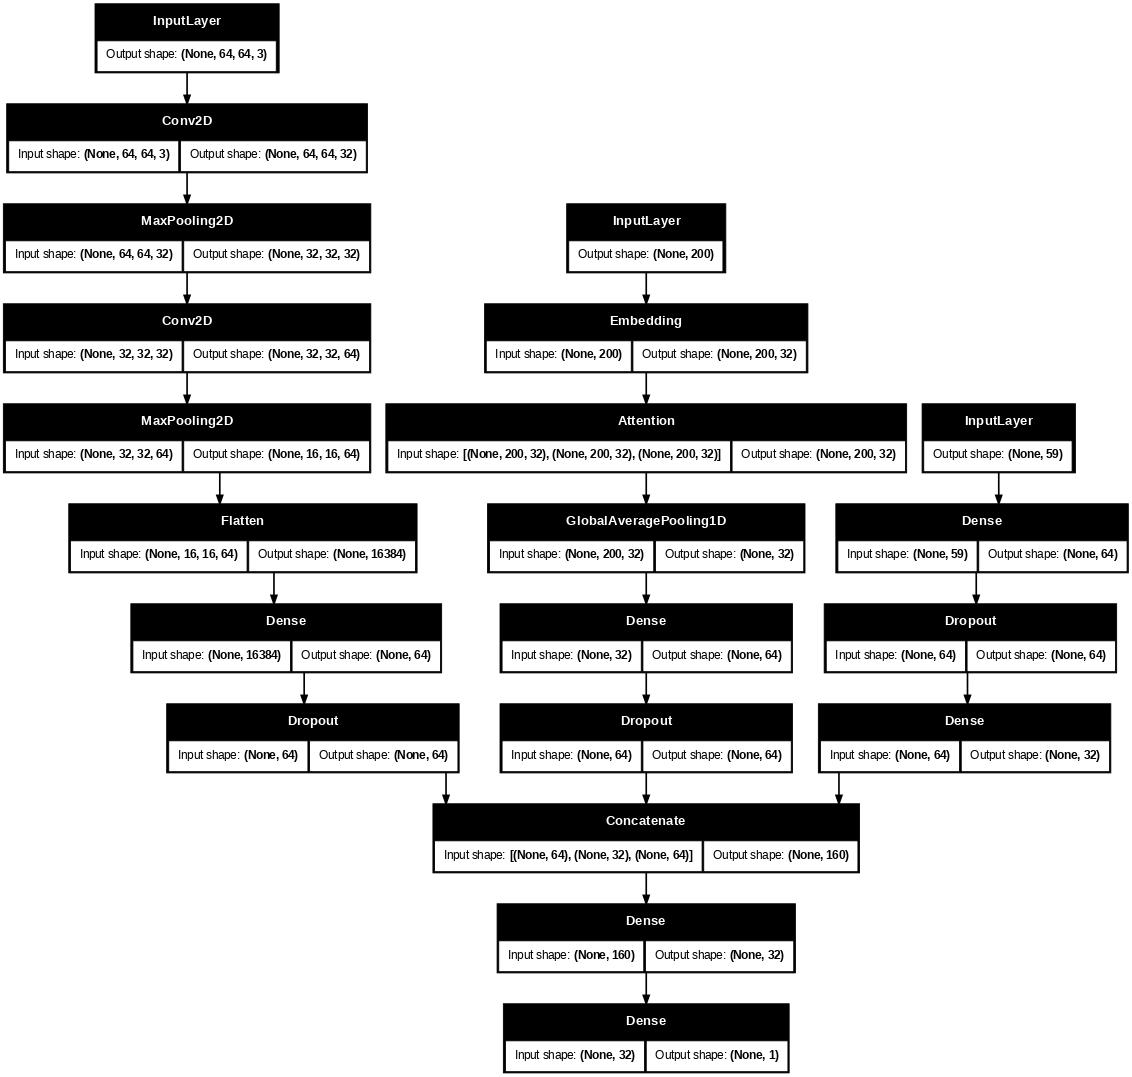

In [ ]:
#Create and adapt the QKV vectorizer on filtered
#training text, using the same sequence length
#as the original QKV model.
text_vec_qkv_logo_bin = keras.layers.TextVectorization(
    output_mode="int", max_tokens=20_000, output_sequence_length=200)
text_vec_qkv_logo_bin.adapt(X_train_text_f)

#Vectorize all filtered splits.
X_train_qkv_lb = text_vec_qkv_logo_bin(X_train_text_f)
X_val_qkv_lb   = text_vec_qkv_logo_bin(X_val_text_f)
X_test_qkv_lb  = text_vec_qkv_logo_bin(X_test_text_f)

#Get the number of structured columns.
n_struct_qkv_lb = X_train_structured_f.shape[1]

#Text branch — embed the tokens then apply
#self-attention (Query = Key = Value = same
#embedding) before pooling.
about_input_qkv_lb = keras.Input(shape=(200,), name="about_input")
about_emb_qkv_lb   = layers.Embedding(20_001, 32)(about_input_qkv_lb)
attended_qkv_lb    = layers.Attention()([about_emb_qkv_lb,
                                          about_emb_qkv_lb,
                                          about_emb_qkv_lb])
x_t_qkv_lb = layers.GlobalAveragePooling1D()(attended_qkv_lb)
x_t_qkv_lb = layers.Dense(64, activation="relu")(x_t_qkv_lb)
x_t_qkv_lb = layers.Dropout(0.3)(x_t_qkv_lb)

#Structured branch.
struct_input_qkv_lb = keras.Input(shape=(n_struct_qkv_lb,), name="struct_input")
x_s_qkv_lb = layers.Dense(64, activation="relu")(struct_input_qkv_lb)
x_s_qkv_lb = layers.Dropout(0.3)(x_s_qkv_lb)
x_s_qkv_lb = layers.Dense(32, activation="relu")(x_s_qkv_lb)

#Image (CNN) branch.
img_input_qkv_lb, x_img_qkv_lb = build_image_branch("logo_qkv_lb")

#Merge all three branches and output a
#single sigmoid prediction.
merged_qkv_lb = layers.Concatenate()([x_t_qkv_lb, x_s_qkv_lb, x_img_qkv_lb])
merged_qkv_lb = layers.Dense(32, activation="relu")(merged_qkv_lb)
output_qkv_lb = layers.Dense(1, activation="sigmoid")(merged_qkv_lb)

#Define the model blueprint and compile it.
qkv_logo_model_bin = keras.Model(
    inputs=[about_input_qkv_lb, struct_input_qkv_lb, img_input_qkv_lb],
    outputs=output_qkv_lb)
qkv_logo_model_bin.compile(
    optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(qkv_logo_model_bin, show_shapes=True, dpi=60)

In [ ]:
#Fit the QKV model using the filtered splits.
#EarlyStopping monitors validation accuracy
#and restores the best weights.
history_qkv_logo_bin = qkv_logo_model_bin.fit(
    x=[X_train_qkv_lb.numpy(), X_train_structured_f, X_train_logos],
    y=y_train_f,
    validation_data=(
        [X_val_qkv_lb.numpy(), X_val_structured_f, X_val_logos],
        y_val_f),
    epochs=20, batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)]
)

#Evaluate on the filtered test set.
test_loss_qkv_lb, test_acc_qkv_lb = qkv_logo_model_bin.evaluate(
    [X_test_qkv_lb.numpy(), X_test_structured_f, X_test_logos],
    y_test_f)
print(f"\nQKV + Logo (Binary) — Test Accuracy: {test_acc_qkv_lb:.4f} | Loss: {test_loss_qkv_lb:.4f}")

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 291ms/step - accuracy: 0.5614 - loss: 9.1843 - val_accuracy: 0.3630 - val_loss: 1.5356
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5663 - loss: 6.1194 - val_accuracy: 0.3630 - val_loss: 0.7827
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5614 - loss: 4.3250 - val_accuracy: 0.3630 - val_loss: 1.5393
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5735 - loss: 3.5450 - val_accuracy: 0.6370 - val_loss: 0.8747
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5687 - loss: 3.0784 - val_accuracy: 0.3630 - val_loss: 2.3409
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5373 - loss: 2.4943 - val_accuracy: 0.3630 - val_loss: 1.9443
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5036 - loss: 2.4760 - val_accuracy: 0.6370 - val_loss: 1.2036
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.6552 - loss: 0.8264

QKV + Logo (Binary) — Test Accuracy

####Logo: MultiHeadAttention Binary

The MultiHeadAttention model with logos, performed poorly  when compared to the benchmark, reaching an accuracy of 34.48%.

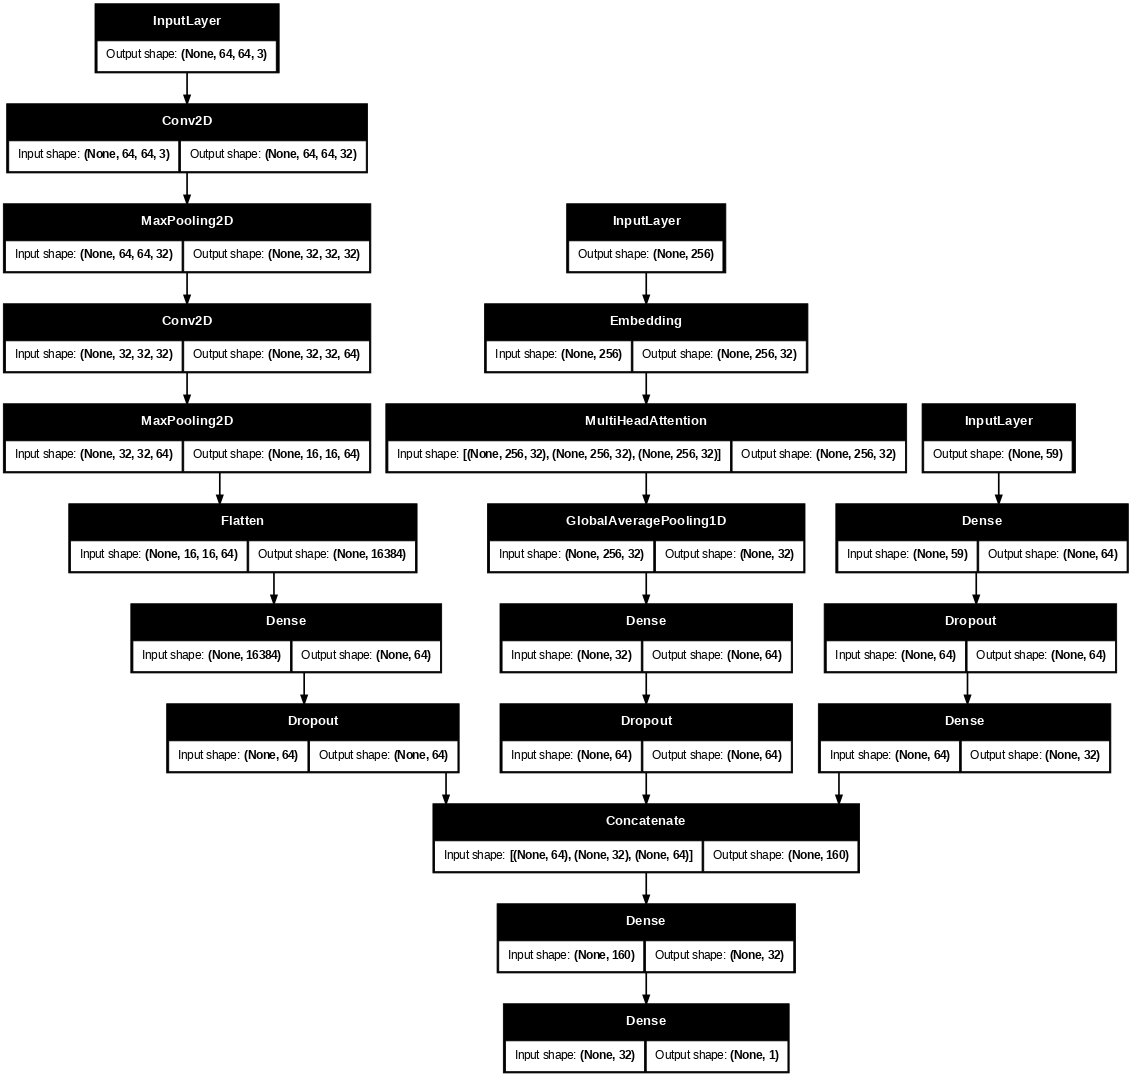

In [ ]:
#Define the same hyperparameters used in the
#original binary MultiHead Attention model.
MAX_LEN_MHA_LB  = 256
VOCAB_MHA_LB    = 10_001
EMBED_MHA_LB    = 32
HEADS_MHA_LB    = 2

#Get the number of structured columns.
n_struct_mha_lb = X_train_structured_f.shape[1]

#Create and adapt the MHA vectorizer on
#filtered training text only.
text_vec_mha_lb = keras.layers.TextVectorization(
    max_tokens=10_000, output_mode="int",
    output_sequence_length=MAX_LEN_MHA_LB)
text_vec_mha_lb.adapt(X_train_text_f)

#Vectorize all filtered splits.
X_train_mha_lb = text_vec_mha_lb(X_train_text_f)
X_val_mha_lb   = text_vec_mha_lb(X_val_text_f)
X_test_mha_lb  = text_vec_mha_lb(X_test_text_f)

#Text branch — embed the tokens, apply
#multi-head self-attention, then pool.
#num_heads runs attention in parallel;
#key_dim is each head's working dimension.
about_input_mha_lb = keras.Input(shape=(MAX_LEN_MHA_LB,), name="about_input")
about_emb_mha_lb   = layers.Embedding(VOCAB_MHA_LB, EMBED_MHA_LB,
                                       name="emb_mha_lb")(about_input_mha_lb)
attended_mha_lb    = layers.MultiHeadAttention(
    num_heads=HEADS_MHA_LB, key_dim=EMBED_MHA_LB // HEADS_MHA_LB
)(about_emb_mha_lb, about_emb_mha_lb, about_emb_mha_lb) #Q=K=V for self-attention.
x_t_mha_lb = layers.GlobalAveragePooling1D()(attended_mha_lb)
x_t_mha_lb = layers.Dense(64, activation="relu")(x_t_mha_lb)
x_t_mha_lb = layers.Dropout(0.3)(x_t_mha_lb)

#Structured branch.
struct_input_mha_lb = keras.Input(shape=(n_struct_mha_lb,), name="struct_input")
x_s_mha_lb = layers.Dense(64, activation="relu")(struct_input_mha_lb)
x_s_mha_lb = layers.Dropout(0.3)(x_s_mha_lb)
x_s_mha_lb = layers.Dense(32, activation="relu")(x_s_mha_lb)

#Image (CNN) branch.
img_input_mha_lb, x_img_mha_lb = build_image_branch("logo_mha_lb")

#Merge all three branches and output a
#single sigmoid prediction.
merged_mha_lb = layers.Concatenate()([x_t_mha_lb, x_s_mha_lb, x_img_mha_lb])
merged_mha_lb = layers.Dense(32, activation="relu")(merged_mha_lb)
output_mha_lb = layers.Dense(1, activation="sigmoid")(merged_mha_lb)

#Define the model blueprint and compile it.
mha_logo_model_bin = keras.Model(
    inputs=[about_input_mha_lb, struct_input_mha_lb, img_input_mha_lb],
    outputs=output_mha_lb)
mha_logo_model_bin.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(mha_logo_model_bin, show_shapes=True, dpi=60)

In [ ]:
#Fit the MHA model using the filtered splits.
history_mha_logo_bin = mha_logo_model_bin.fit(
    x=[X_train_mha_lb.numpy(), X_train_structured_f, X_train_logos],
    y=y_train_f,
    validation_data=(
        [X_val_mha_lb.numpy(), X_val_structured_f, X_val_logos],
        y_val_f),
    epochs=20, batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)]
)

#Evaluate on the filtered test set.
test_loss_mha_lb, test_acc_mha_lb = mha_logo_model_bin.evaluate(
    [X_test_mha_lb.numpy(), X_test_structured_f, X_test_logos],
    y_test_f)
print(f"\nMHA + Logo (Binary) — Test Accuracy: {test_acc_mha_lb:.4f} | Loss: {test_loss_mha_lb:.4f}")

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 237ms/step - accuracy: 0.5205 - loss: 14.0270 - val_accuracy: 0.3630 - val_loss: 2.5806
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5470 - loss: 6.4622 - val_accuracy: 0.3630 - val_loss: 6.5732
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5807 - loss: 4.3224 - val_accuracy: 0.3630 - val_loss: 1.3318
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5470 - loss: 3.4243 - val_accuracy: 0.3630 - val_loss: 3.4416
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.3448 - loss: 2.6668

MHA + Logo (Binary) — Test Accuracy: 0.3448 | Loss: 2.6668


####Logo: Simple Model Multi-Class

The simple model performed poorly when compared to the multi-class benchmark, reaching an accuracy of 28.97%.

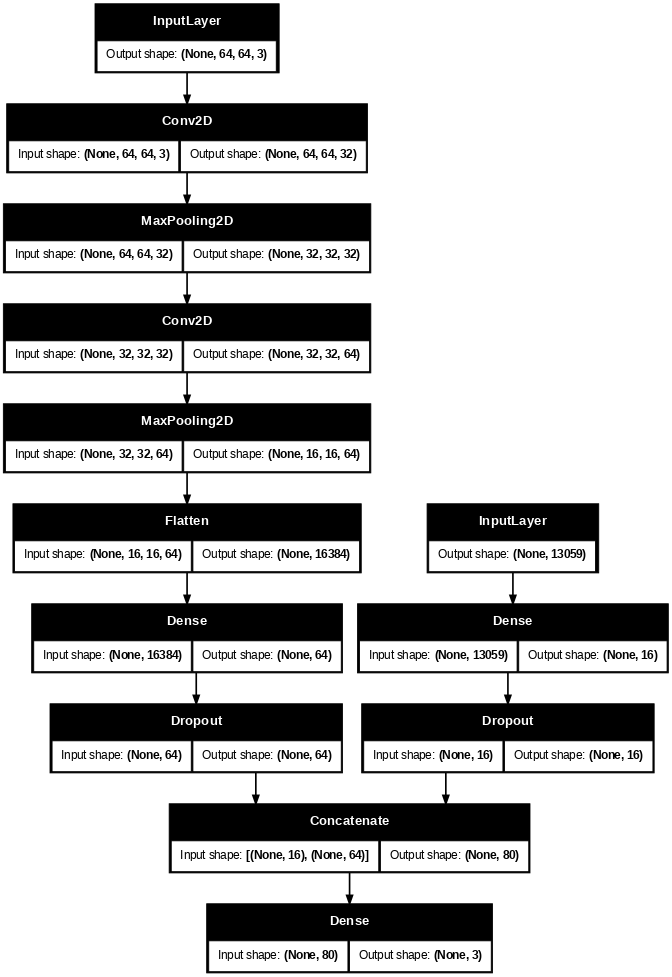

In [ ]:
#Create and adapt a multi-hot vectorizer on
#filtered multiclass training text.
text_vec_simple_logo_m = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="multi_hot"
)
text_vec_simple_logo_m.adapt(X_train_text_m_f)

#Vectorize all filtered multiclass splits.
X_train_text_vec_slm = text_vec_simple_logo_m(X_train_text_m_f).numpy()
X_val_text_vec_slm   = text_vec_simple_logo_m(X_val_text_m_f).numpy()
X_test_text_vec_slm  = text_vec_simple_logo_m(X_test_text_m_f).numpy()

#Concatenate vectorized text with filtered
#structured features into one flat input.
X_train_comb_slm = np.concatenate(
    [X_train_text_vec_slm, X_train_structured_m_f], axis=1)
X_val_comb_slm   = np.concatenate(
    [X_val_text_vec_slm,   X_val_structured_m_f], axis=1)
X_test_comb_slm  = np.concatenate(
    [X_test_text_vec_slm,  X_test_structured_m_f], axis=1)

#Text + structured flat branch.
flat_input_slm = keras.Input(shape=(X_train_comb_slm.shape[1],), name="flat_input")
x_flat_slm = keras.layers.Dense(16, activation="relu")(flat_input_slm)
x_flat_slm = keras.layers.Dropout(0.5)(x_flat_slm)

#Image (CNN) branch.
img_input_slm, x_img_slm = build_image_branch("logo_slm")

#Merge and output 3 classes via softmax.
combined_slm = keras.layers.Concatenate()([x_flat_slm, x_img_slm])
output_slm   = keras.layers.Dense(3, activation="softmax")(combined_slm)

#Define the model blueprint and compile it.
simple_logo_model_m = keras.Model(
    inputs=[flat_input_slm, img_input_slm], outputs=output_slm)
simple_logo_model_m.compile(
    optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(simple_logo_model_m, show_shapes=True, dpi=60)

In [ ]:
#Fit the model using filtered multiclass splits.
#class_weight_dict_m_f is recomputed on filtered
#training labels to handle IPO class imbalance.
history_simple_logo_m = simple_logo_model_m.fit(
    x=[X_train_comb_slm, X_train_logos],
    y=y_train_m_f,
    validation_data=([X_val_comb_slm, X_val_logos], y_val_m_f),
    epochs=10, batch_size=32, class_weight=class_weight_dict_m_f
)

#Evaluate on the filtered test set.
test_loss_slm, test_acc_slm = simple_logo_model_m.evaluate(
    [X_test_comb_slm, X_test_logos], y_test_m_f)
print(f"\nSimple + Logo (Multiclass) — Test Accuracy: {test_acc_slm:.4f} | Loss: {test_loss_slm:.4f}")

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.3398 - loss: 9.7153 - val_accuracy: 0.5037 - val_loss: 1.0586
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4072 - loss: 1.1651 - val_accuracy: 0.3704 - val_loss: 1.0809
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4241 - loss: 1.1366 - val_accuracy: 0.3259 - val_loss: 1.0906
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4169 - loss: 1.0742 - val_accuracy: 0.2741 - val_loss: 1.1178
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4506 - loss: 1.0843 - val_accuracy: 0.2519 - val_loss: 1.1251
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4747 - loss: 1.0172 - val_accuracy: 0.3704 - val_loss: 1.1288
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4988 - loss: 0.9747 - val_accuracy: 0.4148 - val_loss: 1.1032
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4940 - loss: 0.9657 - val_accuracy: 0.2963 - 

####Logo: Embeding Model Multi-class

The Embeding Model with Logos performs relatively the same as the multiclass benchmark model with an accuracy of 50.34%.

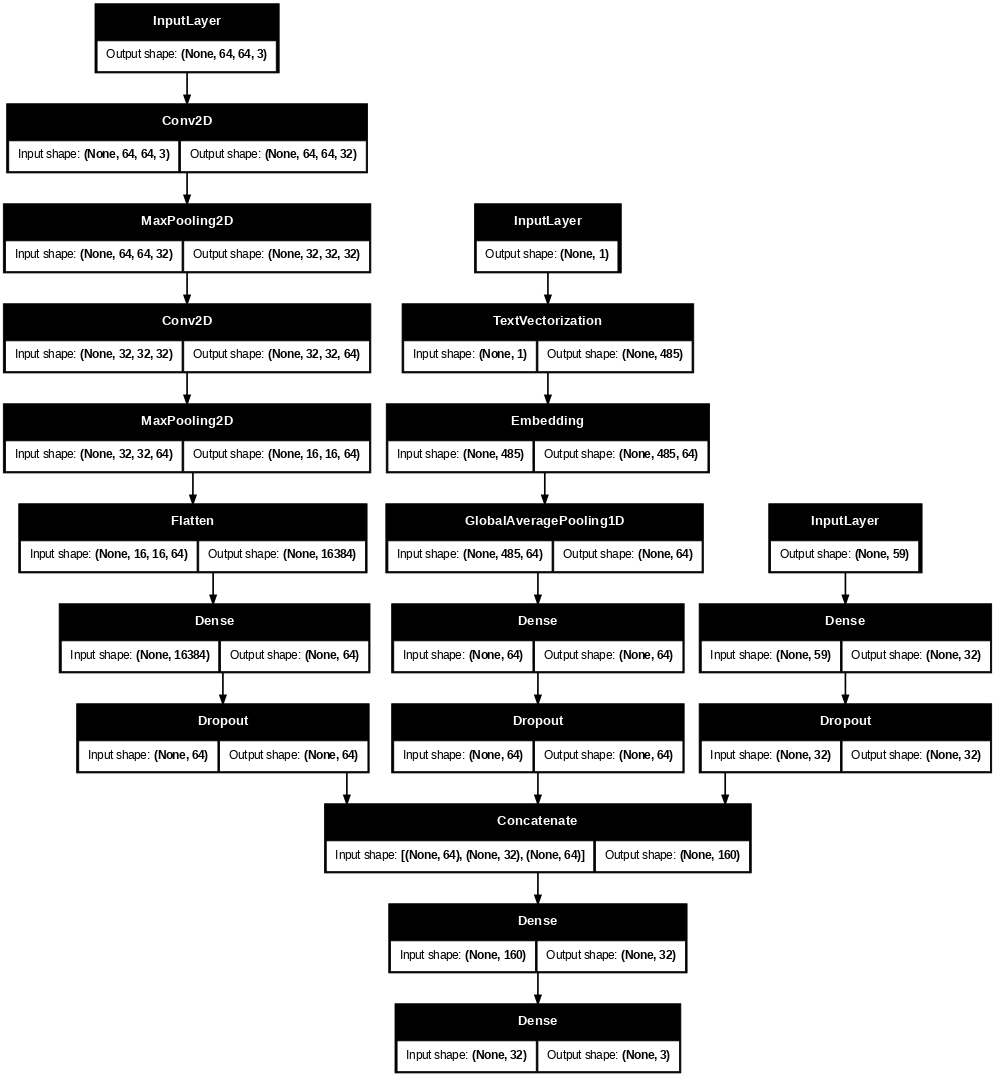

In [ ]:
#Create and adapt the vectorizer on filtered
#multiclass training text only.
text_vec_emb_logo_m = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="int",
    output_sequence_length=int(
        pd.Series(X_train_text_m_f).str.split().str.len().quantile(0.95))
)
text_vec_emb_logo_m.adapt(X_train_text_m_f)

#Get the number of structured columns.
n_structured_elm = X_train_structured_m_f.shape[1]

#Text branch.
text_input_elm = keras.Input(shape=(1,), dtype=tf.string, name="text_input")
x_t_elm = text_vec_emb_logo_m(text_input_elm)
x_t_elm = keras.layers.Embedding(20_000, 64, name="emb_elm")(x_t_elm)
x_t_elm = keras.layers.GlobalAveragePooling1D()(x_t_elm)
x_t_elm = keras.layers.Dense(64, activation="relu")(x_t_elm)
x_t_elm = keras.layers.Dropout(0.3)(x_t_elm)

#Structured branch.
struct_input_elm = keras.Input(shape=(n_structured_elm,), name="struct_input")
x_s_elm = keras.layers.Dense(32, activation="relu")(struct_input_elm)
x_s_elm = keras.layers.Dropout(0.3)(x_s_elm)

#Image (CNN) branch.
img_input_elm, x_img_elm = build_image_branch("logo_elm")

#Merge all three branches and output 3
#classes via softmax.
combined_elm = keras.layers.Concatenate()([x_t_elm, x_s_elm, x_img_elm])
x_elm        = keras.layers.Dense(32, activation="relu")(combined_elm)
output_elm   = keras.layers.Dense(3, activation="softmax")(x_elm)

#Define the model blueprint and compile it.
emb_logo_model_m = keras.Model(
    inputs=[text_input_elm, struct_input_elm, img_input_elm], outputs=output_elm)
emb_logo_model_m.compile(
    optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(emb_logo_model_m, show_shapes=True, dpi=60)

In [ ]:
#Fit the model using filtered multiclass splits.
history_emb_logo_m = emb_logo_model_m.fit(
    x=[X_train_text_m_f, X_train_structured_m_f, X_train_logos],
    y=y_train_m_f,
    validation_data=(
        [X_val_text_m_f, X_val_structured_m_f, X_val_logos],
        y_val_m_f),
    epochs=10, batch_size=32, class_weight=class_weight_dict_m_f
)

#Evaluate on the filtered test set.
test_loss_elm, test_acc_elm = emb_logo_model_m.evaluate(
    [X_test_text_m_f, X_test_structured_m_f, X_test_logos],
    y_test_m_f)
print(f"\nEmbedding + Logo (Multiclass) — Test Accuracy: {test_acc_elm:.4f} | Loss: {test_loss_elm:.4f}")

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3759 - loss: 57.1231 - val_accuracy: 0.1259 - val_loss: 40.0472
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3084 - loss: 33.3105 - val_accuracy: 0.3704 - val_loss: 14.2495
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3398 - loss: 23.8669 - val_accuracy: 0.1259 - val_loss: 9.3559
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3590 - loss: 19.2764 - val_accuracy: 0.1259 - val_loss: 8.7866
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3325 - loss: 17.4161 - val_accuracy: 0.1259 - val_loss: 5.8252
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3181 - loss: 15.1265 - val_accuracy: 0.1259 - val_loss: 5.2862
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2843 - loss: 11.0442 - val_accuracy: 0.1333 - val_loss: 5.0902
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3518 - loss: 9.2897 - val_accuracy: 0

####Logo: RNN Multi-class

Here, the simple RNN model perofrmed the best, reaching about the same as the multiclass benchmark with an accuracy of 50.34%.

In [ ]:
#Builder function for the multiclass RNN + logo
#model, mirroring build_rnn_model_m() but using
#filtered splits and adding the image branch.
def build_rnn_logo_model_m(rnn_layer):
    """Multiclass RNN + logo CNN for the original dataset."""

    #Compute the 95th percentile text length on
    #filtered multiclass training text.
    max_len   = int(pd.Series(X_train_text_m_f).str.split().str.len().quantile(0.95))

    #Get the number of structured columns.
    n_struct  = X_train_structured_m_f.shape[1]
    base_name = rnn_layer.name.split("_")[0]

    #Adapt the vectorizer on filtered training text.
    tv = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode="int", output_sequence_length=max_len)
    tv.adapt(X_train_text_m_f)

    #Text branch.
    text_input = keras.Input(shape=(1,), dtype=tf.string, name="text_input")
    x_t = tv(text_input)
    x_t = keras.layers.Embedding(20_000, 64, name=f"emb_{base_name}_lm")(x_t)
    x_t = rnn_layer(x_t) #The only part that changes across RNN variants.
    x_t = keras.layers.Dropout(0.3)(x_t)

    #Structured branch.
    struct_input = keras.Input(shape=(n_struct,), name="struct_input")
    x_s = keras.layers.Dense(32, activation="relu")(struct_input)
    x_s = keras.layers.Dropout(0.3)(x_s)

    #Image (CNN) branch.
    img_input, x_img = build_image_branch(f"logo_{base_name}_lm")

    #Merge all three branches and output 3
    #classes via softmax.
    combined = keras.layers.Concatenate()([x_t, x_s, x_img])
    x        = keras.layers.Dense(32, activation="relu")(combined)
    output   = keras.layers.Dense(3, activation="softmax")(x)

    #Define the model and compile it.
    model = keras.Model(inputs=[text_input, struct_input, img_input], outputs=output)
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


#Dictionary of the six RNN variants to test.
rnn_logo_models_m = {
    "SimpleRNN":    keras.layers.SimpleRNN(64),
    "LSTM":         keras.layers.LSTM(64),
    "GRU":          keras.layers.GRU(64),
    "Bi-SimpleRNN": keras.layers.Bidirectional(keras.layers.SimpleRNN(64)),
    "Bi-LSTM":      keras.layers.Bidirectional(keras.layers.LSTM(64)),
    "Bi-GRU":       keras.layers.Bidirectional(keras.layers.GRU(64)),
}

#Empty list to store results.
results_rnn_logo_m = []

#Loop through each RNN variant and record results.
for model_name, rnn_layer in rnn_logo_models_m.items():
    print(f"\n{'='*50}")
    print(f"Training (Original Multiclass + Logo): {model_name}")
    print(f"{'='*50}")

    #Build the model with the current RNN layer.
    model = build_rnn_logo_model_m(rnn_layer)

    #Fit the model using filtered multiclass splits.
    history = model.fit(
        x=[X_train_text_m_f, X_train_structured_m_f, X_train_logos],
        y=y_train_m_f,
        validation_data=(
            [X_val_text_m_f, X_val_structured_m_f, X_val_logos],
            y_val_m_f),
        epochs=10, batch_size=16, class_weight=class_weight_dict_m_f
    )

    #Calculate average validation accuracy and loss.
    avg_val_acc  = sum(history.history["val_accuracy"]) / len(history.history["val_accuracy"])
    avg_val_loss = sum(history.history["val_loss"])     / len(history.history["val_loss"])

    #Evaluate on the filtered test set.
    test_loss, test_acc = model.evaluate(
        [X_test_text_m_f, X_test_structured_m_f, X_test_logos],
        y_test_m_f, verbose=0)

    #Store the results for the summary table.
    results_rnn_logo_m.append({
        "Model":            model_name,
        "Avg Val Accuracy": round(avg_val_acc,  4),
        "Avg Val Loss":     round(avg_val_loss,  4),
        "Test Accuracy":    round(test_acc,  4),
        "Test Loss":        round(test_loss, 4),
    })
    print(f"Done! Test Accuracy: {test_acc:.4f}")

#Print a summary table of all RNN results.
results_rnn_logo_m_df = pd.DataFrame(results_rnn_logo_m).set_index("Model")
print("\n\n===== ORIGINAL MULTICLASS + LOGO — RNN SUMMARY =====")
print(results_rnn_logo_m_df.to_string())


Training (Original Multiclass + Logo): SimpleRNN
Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 463ms/step - accuracy: 0.3614 - loss: 57.4377 - val_accuracy: 0.1259 - val_loss: 40.7368
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 455ms/step - accuracy: 0.3012 - loss: 35.5845 - val_accuracy: 0.3704 - val_loss: 21.8398
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step - accuracy: 0.3470 - loss: 23.1794 - val_accuracy: 0.1259 - val_loss: 9.4127
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 444ms/step - accuracy: 0.2988 - loss: 22.4364 - val_accuracy: 0.3704 - val_loss: 2.3152
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 449ms/step - accuracy: 0.2940 - loss: 15.6880 - val_accuracy: 0.5037 - val_loss: 6.9708
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 426ms/step - accuracy: 0.4000 - loss: 11.9522 - val_accuracy: 0.3185 - val_loss: 3.4428
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 439ms/step - accuracy: 0.3205 - loss: 11.5433 - val_accuracy: 0.1259 - val_loss: 5.8524
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 

####Logo QKV Multi-class

The simple model with Logos performed poorly on multiclass, with an accuracy of 27%.

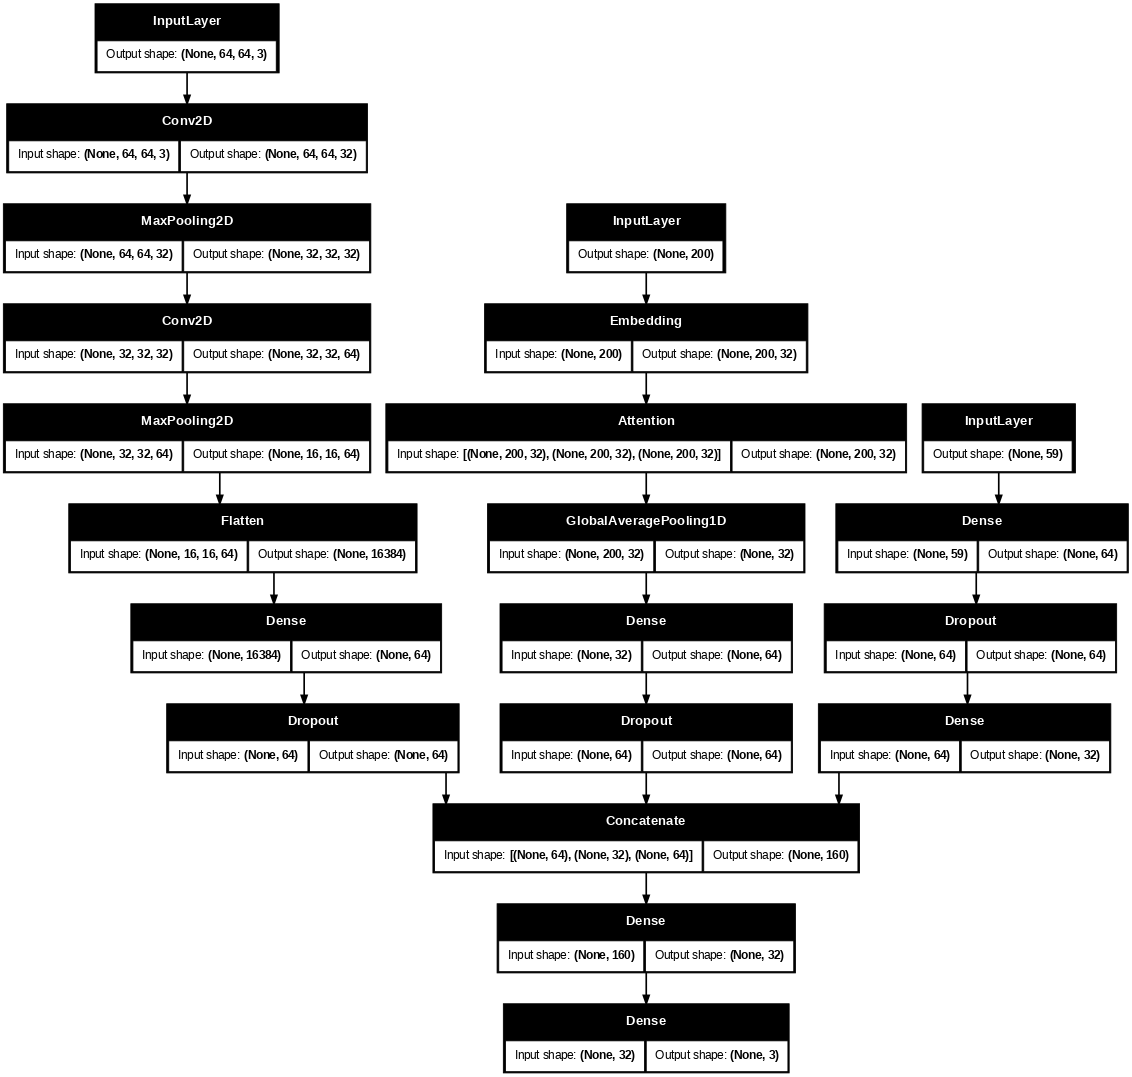

In [ ]:
#Adapt the QKV vectorizer on filtered multiclass
#training text only.
text_vec_qkv_logo_m = keras.layers.TextVectorization(
    output_mode="int", max_tokens=20_000, output_sequence_length=200)
text_vec_qkv_logo_m.adapt(X_train_text_m_f)

#Vectorize all filtered multiclass splits.
X_train_qkv_lm = text_vec_qkv_logo_m(X_train_text_m_f)
X_val_qkv_lm   = text_vec_qkv_logo_m(X_val_text_m_f)
X_test_qkv_lm  = text_vec_qkv_logo_m(X_test_text_m_f)

#Get the number of structured columns.
n_struct_qkv_lm = X_train_structured_m_f.shape[1]

#Text branch with QKV self-attention.
about_input_qkv_lm = keras.Input(shape=(200,), name="about_input")
about_emb_qkv_lm   = layers.Embedding(20_001, 32)(about_input_qkv_lm)
attended_qkv_lm    = layers.Attention()([about_emb_qkv_lm,
                                          about_emb_qkv_lm,
                                          about_emb_qkv_lm])
x_t_qkv_lm = layers.GlobalAveragePooling1D()(attended_qkv_lm)
x_t_qkv_lm = layers.Dense(64, activation="relu")(x_t_qkv_lm)
x_t_qkv_lm = layers.Dropout(0.3)(x_t_qkv_lm)

#Structured branch.
struct_input_qkv_lm = keras.Input(shape=(n_struct_qkv_lm,), name="struct_input")
x_s_qkv_lm = layers.Dense(64, activation="relu")(struct_input_qkv_lm)
x_s_qkv_lm = layers.Dropout(0.3)(x_s_qkv_lm)
x_s_qkv_lm = layers.Dense(32, activation="relu")(x_s_qkv_lm)

#Image (CNN) branch.
img_input_qkv_lm, x_img_qkv_lm = build_image_branch("logo_qkv_lm")

#Merge all three and output 3 classes.
merged_qkv_lm = layers.Concatenate()([x_t_qkv_lm, x_s_qkv_lm, x_img_qkv_lm])
merged_qkv_lm = layers.Dense(32, activation="relu")(merged_qkv_lm)
output_qkv_lm = layers.Dense(3, activation="softmax")(merged_qkv_lm)

#Define the model blueprint and compile it.
qkv_logo_model_m = keras.Model(
    inputs=[about_input_qkv_lm, struct_input_qkv_lm, img_input_qkv_lm],
    outputs=output_qkv_lm)
qkv_logo_model_m.compile(
    optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(qkv_logo_model_m, show_shapes=True, dpi=60)

In [ ]:
#Fit the QKV model using filtered multiclass splits.
history_qkv_logo_m = qkv_logo_model_m.fit(
    x=[X_train_qkv_lm.numpy(), X_train_structured_m_f, X_train_logos],
    y=y_train_m_f,
    validation_data=(
        [X_val_qkv_lm.numpy(), X_val_structured_m_f, X_val_logos],
        y_val_m_f),
    epochs=20, batch_size=16, class_weight=class_weight_dict_m_f,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)]
)

#Evaluate on the filtered test set.
test_loss_qkv_lm, test_acc_qkv_lm = qkv_logo_model_m.evaluate(
    [X_test_qkv_lm.numpy(), X_test_structured_m_f, X_test_logos],
    y_test_m_f)
print(f"\nQKV + Logo (Multiclass) — Test Accuracy: {test_acc_qkv_lm:.4f} | Loss: {test_loss_qkv_lm:.4f}")

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - accuracy: 0.3494 - loss: 39.2553 - val_accuracy: 0.1259 - val_loss: 23.4058
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2916 - loss: 23.8098 - val_accuracy: 0.2148 - val_loss: 6.2358
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3012 - loss: 19.2823 - val_accuracy: 0.1259 - val_loss: 20.9394
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3470 - loss: 15.5217 - val_accuracy: 0.1259 - val_loss: 18.2174
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3398 - loss: 11.8337 - val_accuracy: 0.1259 - val_loss: 8.8788
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.2690 - loss: 6.8922

QKV + Logo (Multiclass) — Test Accuracy: 0.2690 | Loss: 6.8922


####Logo: MultiHead Multi-class

The MutliHead with Logos also performed poorly in multiclass with an accuracy of 38.62%.

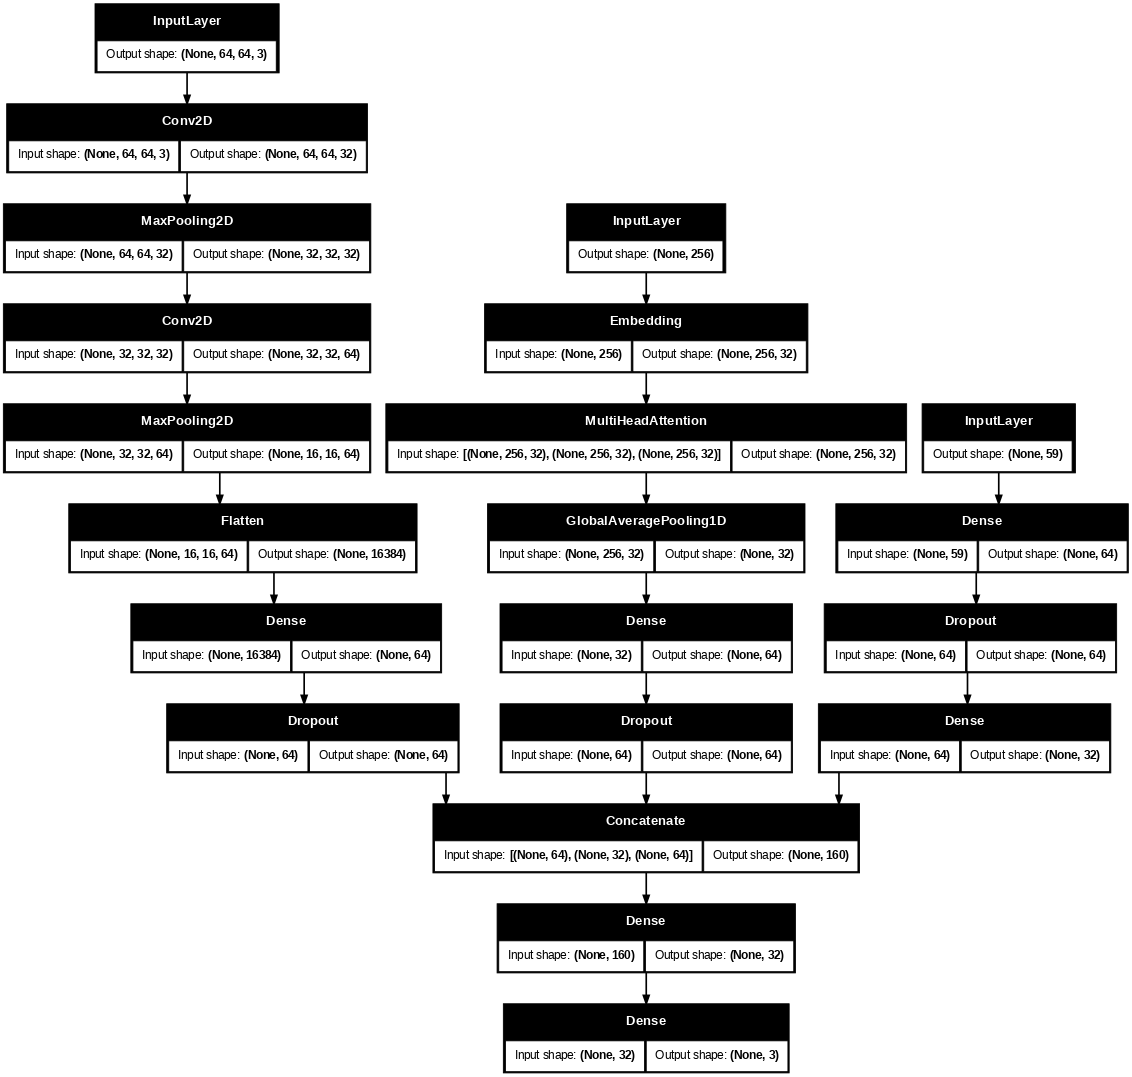

In [ ]:
#Define the same hyperparameters as the original
#multiclass MHA model.
MAX_LEN_MHA_LM  = 256
VOCAB_MHA_LM    = 10_001
EMBED_MHA_LM    = 32
HEADS_MHA_LM    = 2

#Get the number of structured columns.
n_struct_mha_lm = X_train_structured_m_f.shape[1]

#Adapt the MHA vectorizer on filtered multiclass
#training text only.
text_vec_mha_lm = keras.layers.TextVectorization(
    max_tokens=10_000, output_mode="int", output_sequence_length=MAX_LEN_MHA_LM)
text_vec_mha_lm.adapt(X_train_text_m_f)

#Vectorize all filtered multiclass splits.
X_train_mha_lm = text_vec_mha_lm(X_train_text_m_f)
X_val_mha_lm   = text_vec_mha_lm(X_val_text_m_f)
X_test_mha_lm  = text_vec_mha_lm(X_test_text_m_f)

#Text branch with multi-head self-attention.
about_input_mha_lm = keras.Input(shape=(MAX_LEN_MHA_LM,), name="about_input")
about_emb_mha_lm   = layers.Embedding(VOCAB_MHA_LM, EMBED_MHA_LM,
                                       name="emb_mha_lm")(about_input_mha_lm)
attended_mha_lm    = layers.MultiHeadAttention(
    num_heads=HEADS_MHA_LM, key_dim=EMBED_MHA_LM // HEADS_MHA_LM
)(about_emb_mha_lm, about_emb_mha_lm, about_emb_mha_lm) #Q=K=V for self-attention.
x_t_mha_lm = layers.GlobalAveragePooling1D()(attended_mha_lm)
x_t_mha_lm = layers.Dense(64, activation="relu")(x_t_mha_lm)
x_t_mha_lm = layers.Dropout(0.3)(x_t_mha_lm)

#Structured branch.
struct_input_mha_lm = keras.Input(shape=(n_struct_mha_lm,), name="struct_input")
x_s_mha_lm = layers.Dense(64, activation="relu")(struct_input_mha_lm)
x_s_mha_lm = layers.Dropout(0.3)(x_s_mha_lm)
x_s_mha_lm = layers.Dense(32, activation="relu")(x_s_mha_lm)

#Image (CNN) branch.
img_input_mha_lm, x_img_mha_lm = build_image_branch("logo_mha_lm")

#Merge all three and output 3 classes.
merged_mha_lm = layers.Concatenate()([x_t_mha_lm, x_s_mha_lm, x_img_mha_lm])
merged_mha_lm = layers.Dense(32, activation="relu")(merged_mha_lm)
output_mha_lm = layers.Dense(3, activation="softmax")(merged_mha_lm)

#Define the model blueprint and compile it.
mha_logo_model_m = keras.Model(
    inputs=[about_input_mha_lm, struct_input_mha_lm, img_input_mha_lm],
    outputs=output_mha_lm)
mha_logo_model_m.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(mha_logo_model_m, show_shapes=True, dpi=60)

In [ ]:
#Fit the MHA model using filtered multiclass splits.
history_mha_logo_m = mha_logo_model_m.fit(
    x=[X_train_mha_lm.numpy(), X_train_structured_m_f, X_train_logos],
    y=y_train_m_f,
    validation_data=(
        [X_val_mha_lm.numpy(), X_val_structured_m_f, X_val_logos],
        y_val_m_f),
    epochs=20, batch_size=16, class_weight=class_weight_dict_m_f,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)]
)

#Evaluate on the filtered test set.
test_loss_mha_lm, test_acc_mha_lm = mha_logo_model_m.evaluate(
    [X_test_mha_lm.numpy(), X_test_structured_m_f, X_test_logos],
    y_test_m_f)
print(f"\nMHA + Logo (Multiclass) — Test Accuracy: {test_acc_mha_lm:.4f} | Loss: {test_loss_mha_lm:.4f}")

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 216ms/step - accuracy: 0.3446 - loss: 37.9670 - val_accuracy: 0.1259 - val_loss: 19.0142
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3759 - loss: 22.0274 - val_accuracy: 0.1259 - val_loss: 10.5333
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3253 - loss: 16.9644 - val_accuracy: 0.1259 - val_loss: 5.0570
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3422 - loss: 11.0496 - val_accuracy: 0.3704 - val_loss: 2.8202
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2386 - loss: 11.2839 - val_accuracy: 0.3704 - val_loss: 1.8745
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3157 - loss: 8.3935 - val_accuracy: 0.3407 - val_loss: 1.3472
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2675 - loss: 6.6373 - val_accuracy: 0.1259 - val_loss: 3.8544
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.3862 - loss: 2.8028

MHA + Logo (Multiclass) — Test

###Chatgpt Dataset

####Logo: Simple Model Binary

The simple binary model with Logos performed pretty well, with an accuracy of 64%.

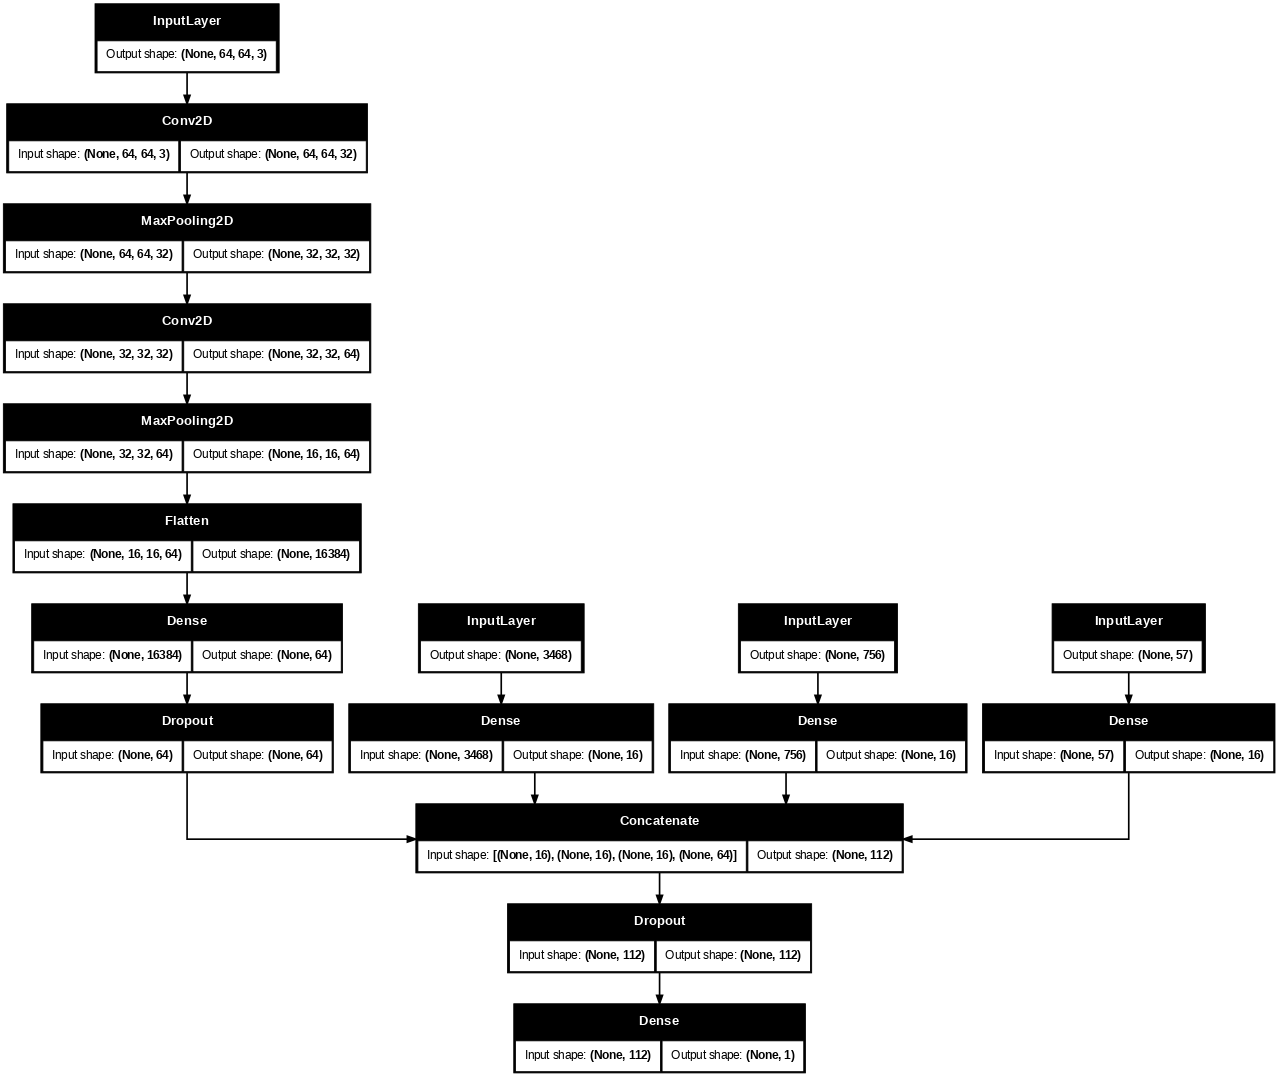

In [ ]:
#Create separate vectorizers for the about text
#and founder background columns. Each learns its
#own vocabulary independently. Both are adapted
#on the filtered ChatGPT binary training splits.
tv_about_s_cgb = keras.layers.TextVectorization(max_tokens=20_000, output_mode="multi_hot")
tv_about_s_cgb.adapt(X_cg_train_about_f)

tv_founder_s_cgb = keras.layers.TextVectorization(max_tokens=20_000, output_mode="multi_hot")
tv_founder_s_cgb.adapt(X_cg_train_founder_f)

#Vectorize all filtered splits for both columns.
X_cg_train_about_s_cgb   = tv_about_s_cgb(X_cg_train_about_f).numpy()
X_cg_val_about_s_cgb     = tv_about_s_cgb(X_cg_val_about_f).numpy()
X_cg_test_about_s_cgb    = tv_about_s_cgb(X_cg_test_about_f).numpy()

X_cg_train_founder_s_cgb = tv_founder_s_cgb(X_cg_train_founder_f).numpy()
X_cg_val_founder_s_cgb   = tv_founder_s_cgb(X_cg_val_founder_f).numpy()
X_cg_test_founder_s_cgb  = tv_founder_s_cgb(X_cg_test_founder_f).numpy()

#Retrieve the vocabulary sizes and structured
#column count for the input layer dimensions.
n_struct_s_cgb    = X_cg_train_structured_f.shape[1]
about_vocab_cgb   = tv_about_s_cgb.vocabulary_size()
founder_vocab_cgb = tv_founder_s_cgb.vocabulary_size()

#About text branch.
about_input_s_cgb   = keras.Input(shape=(about_vocab_cgb,),   name="about_input")
x_a_s_cgb = keras.layers.Dense(16, activation="relu")(about_input_s_cgb)

#Founder background branch.
founder_input_s_cgb = keras.Input(shape=(founder_vocab_cgb,), name="founder_input")
x_f_s_cgb = keras.layers.Dense(16, activation="relu")(founder_input_s_cgb)

#Structured branch.
struct_input_s_cgb  = keras.Input(shape=(n_struct_s_cgb,),    name="struct_input")
x_s_s_cgb = keras.layers.Dense(16, activation="relu")(struct_input_s_cgb)

#Image (CNN) branch.
img_input_s_cgb, x_img_s_cgb = build_image_branch("logo_s_cgb")

#Merge all four branches and output a
#single sigmoid prediction.
merged_s_cgb = keras.layers.Concatenate()([x_a_s_cgb, x_f_s_cgb, x_s_s_cgb, x_img_s_cgb])
merged_s_cgb = keras.layers.Dropout(0.5)(merged_s_cgb)
output_s_cgb = keras.layers.Dense(1, activation="sigmoid")(merged_s_cgb)

#Define the model blueprint and compile it.
simple_logo_model_cgb = keras.Model(
    inputs=[about_input_s_cgb, founder_input_s_cgb, struct_input_s_cgb, img_input_s_cgb],
    outputs=output_s_cgb)
simple_logo_model_cgb.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(simple_logo_model_cgb, show_shapes=True, dpi=60)

In [ ]:
#Fit the model using filtered ChatGPT binary splits.
history_simple_logo_cgb = simple_logo_model_cgb.fit(
    x=[X_cg_train_about_s_cgb, X_cg_train_founder_s_cgb,
       X_cg_train_structured_f, X_cg_train_logos],
    y=y_cg_train_f,
    validation_data=(
        [X_cg_val_about_s_cgb, X_cg_val_founder_s_cgb,
         X_cg_val_structured_f, X_cg_val_logos],
        y_cg_val_f),
    epochs=10, batch_size=32
)

#Evaluate on the filtered test set.
test_loss_s_cgb, test_acc_s_cgb = simple_logo_model_cgb.evaluate(
    [X_cg_test_about_s_cgb, X_cg_test_founder_s_cgb,
     X_cg_test_structured_f, X_cg_test_logos],
    y_cg_test_f)
print(f"\nSimple + Logo CG (Binary) — Test Accuracy: {test_acc_s_cgb:.4f} | Loss: {test_loss_s_cgb:.4f}")

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.5173 - loss: 68.4348 - val_accuracy: 0.5784 - val_loss: 11.6966
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5182 - loss: 24.4401 - val_accuracy: 0.5771 - val_loss: 5.1405
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5058 - loss: 7.3857 - val_accuracy: 0.5643 - val_loss: 1.2297
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5306 - loss: 1.0544 - val_accuracy: 0.6298 - val_loss: 0.6253
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6162 - loss: 0.6725 - val_accuracy: 0.6620 - val_loss: 0.6203
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6316 - loss: 0.6610 - val_accuracy: 0.6350 - val_loss: 0.6568
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6915 - loss: 0.6106 - val_accuracy: 0.6877 - val_loss: 0.6022
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7202 - loss: 0.5655 - val_accuracy: 0.6928 - val_l

####Logo: Embedding Model Binary

The Embeding Model with Logos performed worse than the benchmark, with an accuracy of 44%.

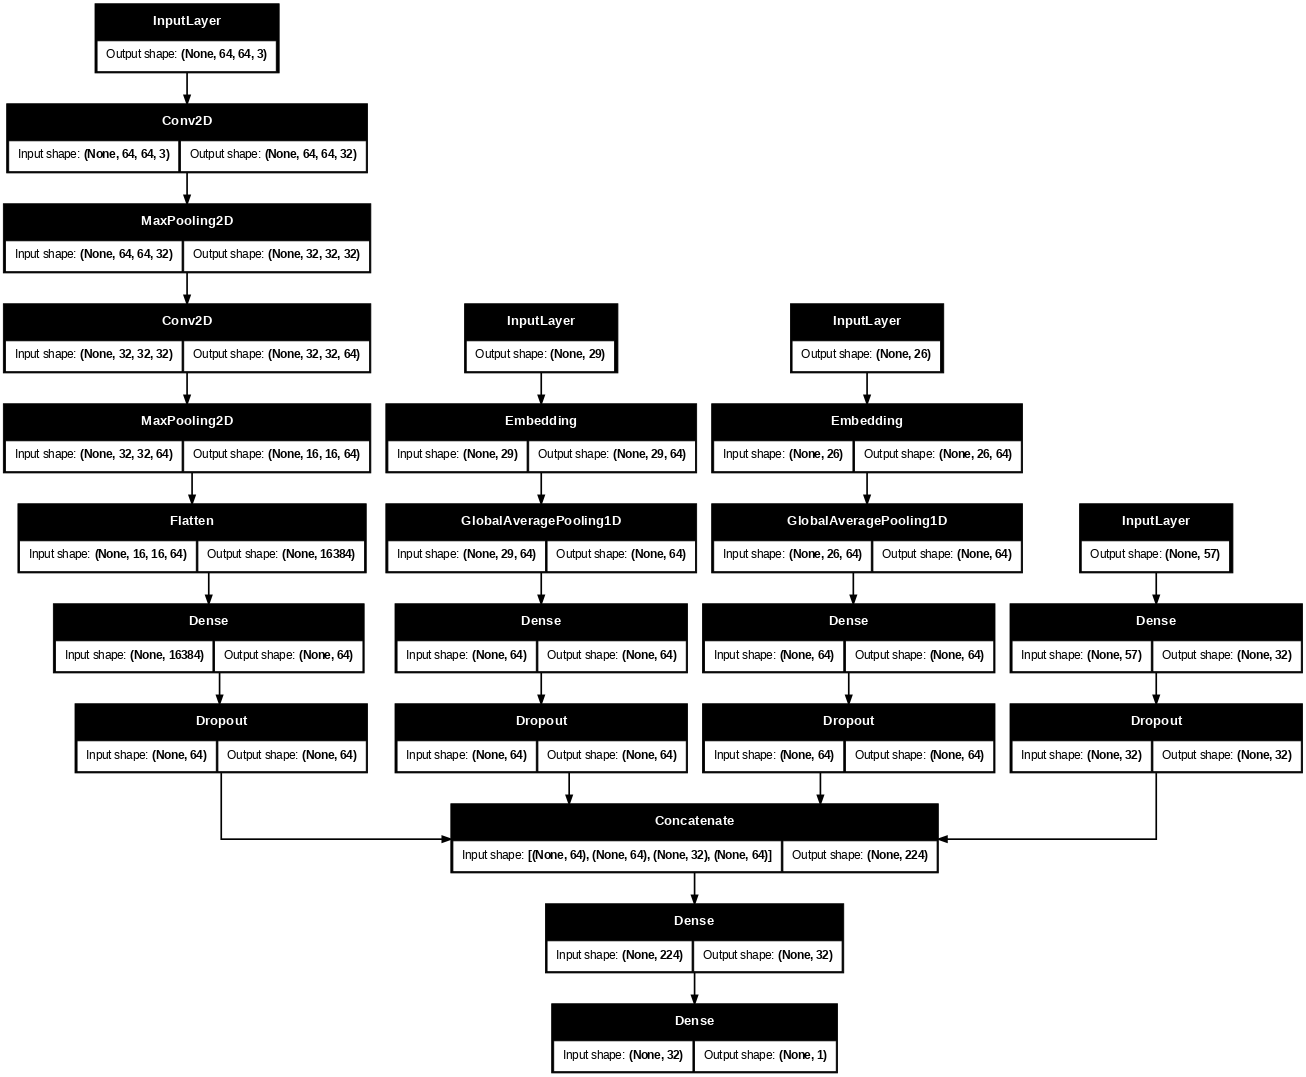

In [ ]:
#Compute the 95th percentile text length for
#each column on filtered training data to set
#the sequence length for each vectorizer.
about_len_e_cgb   = int(pd.Series(X_cg_train_about_f).str.split().str.len().quantile(0.95))
founder_len_e_cgb = int(pd.Series(X_cg_train_founder_f).str.split().str.len().quantile(0.95))

#Get the number of structured columns.
n_struct_e_cgb    = X_cg_train_structured_f.shape[1]

#Create and adapt separate embedding vectorizers
#for each text column on filtered training text.
tv_about_e_cgb = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="int", output_sequence_length=about_len_e_cgb)
tv_about_e_cgb.adapt(X_cg_train_about_f)

tv_founder_e_cgb = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="int", output_sequence_length=founder_len_e_cgb)
tv_founder_e_cgb.adapt(X_cg_train_founder_f)

#Vectorize all filtered splits for both columns.
X_cg_train_about_e_cgb   = tv_about_e_cgb(X_cg_train_about_f).numpy()
X_cg_val_about_e_cgb     = tv_about_e_cgb(X_cg_val_about_f).numpy()
X_cg_test_about_e_cgb    = tv_about_e_cgb(X_cg_test_about_f).numpy()

X_cg_train_founder_e_cgb = tv_founder_e_cgb(X_cg_train_founder_f).numpy()
X_cg_val_founder_e_cgb   = tv_founder_e_cgb(X_cg_val_founder_f).numpy()
X_cg_test_founder_e_cgb  = tv_founder_e_cgb(X_cg_test_founder_f).numpy()

#About text branch — embed, pool, dense.
about_input_e_cgb   = keras.Input(shape=(about_len_e_cgb,),   name="about_input")
x_a_e_cgb = keras.layers.Embedding(20_000, 64, name="emb_about_e_cgb")(about_input_e_cgb)
x_a_e_cgb = keras.layers.GlobalAveragePooling1D()(x_a_e_cgb)
x_a_e_cgb = keras.layers.Dense(64, activation="relu")(x_a_e_cgb)
x_a_e_cgb = keras.layers.Dropout(0.3)(x_a_e_cgb)

#Founder background branch — embed, pool, dense.
founder_input_e_cgb = keras.Input(shape=(founder_len_e_cgb,), name="founder_input")
x_f_e_cgb = keras.layers.Embedding(20_000, 64, name="emb_founder_e_cgb")(founder_input_e_cgb)
x_f_e_cgb = keras.layers.GlobalAveragePooling1D()(x_f_e_cgb)
x_f_e_cgb = keras.layers.Dense(64, activation="relu")(x_f_e_cgb)
x_f_e_cgb = keras.layers.Dropout(0.3)(x_f_e_cgb)

#Structured branch.
struct_input_e_cgb  = keras.Input(shape=(n_struct_e_cgb,), name="struct_input")
x_s_e_cgb = keras.layers.Dense(32, activation="relu")(struct_input_e_cgb)
x_s_e_cgb = keras.layers.Dropout(0.3)(x_s_e_cgb)

#Image (CNN) branch.
img_input_e_cgb, x_img_e_cgb = build_image_branch("logo_e_cgb")

#Merge all four branches and output a
#single sigmoid prediction.
combined_e_cgb = keras.layers.Concatenate()([x_a_e_cgb, x_f_e_cgb, x_s_e_cgb, x_img_e_cgb])
x_e_cgb        = keras.layers.Dense(32, activation="relu")(combined_e_cgb)
output_e_cgb   = keras.layers.Dense(1, activation="sigmoid")(x_e_cgb)

#Define the model blueprint and compile it.
emb_logo_model_cgb = keras.Model(
    inputs=[about_input_e_cgb, founder_input_e_cgb, struct_input_e_cgb, img_input_e_cgb],
    outputs=output_e_cgb)
emb_logo_model_cgb.compile(
    optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(emb_logo_model_cgb, show_shapes=True, dpi=60)

In [ ]:
#Fit the model using filtered ChatGPT binary splits.
history_emb_logo_cgb = emb_logo_model_cgb.fit(
    x=[X_cg_train_about_e_cgb, X_cg_train_founder_e_cgb,
       X_cg_train_structured_f, X_cg_train_logos],
    y=y_cg_train_f,
    validation_data=(
        [X_cg_val_about_e_cgb, X_cg_val_founder_e_cgb,
         X_cg_val_structured_f, X_cg_val_logos],
        y_cg_val_f),
    epochs=10, batch_size=32
)

#Evaluate on the filtered test set.
test_loss_e_cgb, test_acc_e_cgb = emb_logo_model_cgb.evaluate(
    [X_cg_test_about_e_cgb, X_cg_test_founder_e_cgb,
     X_cg_test_structured_f, X_cg_test_logos],
    y_cg_test_f)
print(f"\nEmbedding + Logo CG (Binary) — Test Accuracy: {test_acc_e_cgb:.4f} | Loss: {test_loss_e_cgb:.4f}")

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.5131 - loss: 12.3546 - val_accuracy: 0.4267 - val_loss: 1.1965
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5045 - loss: 4.2155 - val_accuracy: 0.4216 - val_loss: 7.4479
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5032 - loss: 2.3527 - val_accuracy: 0.4216 - val_loss: 5.8075
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5002 - loss: 1.6741 - val_accuracy: 0.4216 - val_loss: 2.9233
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5255 - loss: 1.2227 - val_accuracy: 0.4280 - val_loss: 0.9730
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5233 - loss: 1.1331 - val_accuracy: 0.5784 - val_loss: 0.6714
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5143 - loss: 1.0720 - val_accuracy: 0.4267 - val_loss: 1.1342
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5451 - loss: 0.9623 - val_accuracy: 0.5784 - val_lo

####Logo: RNN Models Binary

Simple RNN was the best model here with an accuracy of 62.44%, beating out the benchmark.

In [ ]:
#Builder function for the ChatGPT binary RNN +
#logo model. It has four branches: about text,
#founder background, structured, and image.
#Mirrors build_rnn_model_cg() but uses filtered
#splits and adds the CNN image branch.
def build_rnn_logo_model_cgb(rnn_layer):
    """Binary 4-branch RNN + logo CNN for the ChatGPT dataset."""

    #Compute 95th percentile lengths for each
    #text column on filtered training data.
    about_len   = int(pd.Series(X_cg_train_about_f).str.split().str.len().quantile(0.95))
    founder_len = int(pd.Series(X_cg_train_founder_f).str.split().str.len().quantile(0.95))

    #Get the number of structured columns.
    n_struct    = X_cg_train_structured_f.shape[1]
    base_name   = rnn_layer.name.split("_")[0]

    #Adapt separate vectorizers for each column
    #on the filtered training text only.
    tv_a = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode="int", output_sequence_length=about_len)
    tv_a.adapt(X_cg_train_about_f)

    tv_f = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode="int", output_sequence_length=founder_len)
    tv_f.adapt(X_cg_train_founder_f)

    #Create a renamed copy of the RNN layer for
    #the founder branch so Keras does not complain
    #about duplicate layer names.
    config = rnn_layer.get_config()
    config["name"] = f"{base_name}_founder_cgb"
    founder_rnn = type(rnn_layer).from_config(config)

    #Handle the Bidirectional case separately
    #because it wraps an inner RNN layer.
    if isinstance(rnn_layer, keras.layers.Bidirectional):
        inner        = rnn_layer.forward_layer
        inner_config = inner.get_config()
        inner_config["name"] = f"{inner.name.split('_')[0]}_founder_cgb_inner"
        founder_rnn  = keras.layers.Bidirectional(
            type(inner).from_config(inner_config), name="bidirectional_founder_cgb")

    #About text branch.
    about_input = keras.Input(shape=(1,), dtype=tf.string, name="about_input")
    x_a = tv_a(about_input)
    x_a = keras.layers.Embedding(20_000, 64, name=f"emb_about_{base_name}_cgb")(x_a)
    x_a = rnn_layer(x_a)
    x_a = keras.layers.Dropout(0.3)(x_a)

    #Founder background branch.
    founder_input = keras.Input(shape=(1,), dtype=tf.string, name="founder_input")
    x_f = tv_f(founder_input)
    x_f = keras.layers.Embedding(20_000, 64, name=f"emb_founder_{base_name}_cgb")(x_f)
    x_f = founder_rnn(x_f)
    x_f = keras.layers.Dropout(0.3)(x_f)

    #Structured branch.
    struct_input = keras.Input(shape=(n_struct,), name="struct_input")
    x_s = keras.layers.Dense(32, activation="relu")(struct_input)
    x_s = keras.layers.Dropout(0.3)(x_s)

    #Image (CNN) branch.
    img_input, x_img = build_image_branch(f"logo_{base_name}_cgb")

    #Merge all four branches and output a
    #single sigmoid prediction.
    combined = keras.layers.Concatenate()([x_a, x_f, x_s, x_img])
    x        = keras.layers.Dense(32, activation="relu")(combined)
    output   = keras.layers.Dense(1, activation="sigmoid")(x)

    #Define the model and compile it.
    model = keras.Model(
        inputs=[about_input, founder_input, struct_input, img_input], outputs=output)
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return model


#Dictionary of the six RNN variants to test.
rnn_logo_models_cgb = {
    "SimpleRNN":    keras.layers.SimpleRNN(64),
    "LSTM":         keras.layers.LSTM(64),
    "GRU":          keras.layers.GRU(64),
    "Bi-SimpleRNN": keras.layers.Bidirectional(keras.layers.SimpleRNN(64)),
    "Bi-LSTM":      keras.layers.Bidirectional(keras.layers.LSTM(64)),
    "Bi-GRU":       keras.layers.Bidirectional(keras.layers.GRU(64)),
}

#Empty list to store results.
results_rnn_logo_cgb = []

#Loop through each RNN variant and record results.
for model_name, rnn_layer in rnn_logo_models_cgb.items():
    print(f"\n{'='*50}")
    print(f"Training (ChatGPT Binary + Logo): {model_name}")
    print(f"{'='*50}")

    #Build the model with the current RNN layer.
    model = build_rnn_logo_model_cgb(rnn_layer)

    #Fit the model using filtered ChatGPT binary splits.
    history = model.fit(
        x=[X_cg_train_about_f, X_cg_train_founder_f,
           X_cg_train_structured_f, X_cg_train_logos],
        y=y_cg_train_f,
        validation_data=(
            [X_cg_val_about_f, X_cg_val_founder_f,
             X_cg_val_structured_f, X_cg_val_logos],
            y_cg_val_f),
        epochs=10, batch_size=32
    )

    #Calculate average validation accuracy and loss.
    avg_val_acc  = sum(history.history["val_accuracy"]) / len(history.history["val_accuracy"])
    avg_val_loss = sum(history.history["val_loss"])     / len(history.history["val_loss"])

    #Evaluate on the filtered test set.
    test_loss, test_acc = model.evaluate(
        [X_cg_test_about_f, X_cg_test_founder_f,
         X_cg_test_structured_f, X_cg_test_logos],
        y_cg_test_f, verbose=0)

    #Store the results for the summary table.
    results_rnn_logo_cgb.append({
        "Model":            model_name,
        "Avg Val Accuracy": round(avg_val_acc,  4),
        "Avg Val Loss":     round(avg_val_loss,  4),
        "Test Accuracy":    round(test_acc,  4),
        "Test Loss":        round(test_loss, 4),
    })
    print(f"Done! Test Accuracy: {test_acc:.4f}")

#Print a summary table of all RNN results.
results_rnn_logo_cgb_df = pd.DataFrame(results_rnn_logo_cgb).set_index("Model")
print("\n\n===== CHATGPT BINARY + LOGO — RNN SUMMARY =====")
print(results_rnn_logo_cgb_df.to_string())


Training (ChatGPT Binary + Logo): SimpleRNN
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.5058 - loss: 18.2732 - val_accuracy: 0.5784 - val_loss: 5.5249
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5178 - loss: 5.8316 - val_accuracy: 0.5784 - val_loss: 1.6897
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5289 - loss: 3.5980 - val_accuracy: 0.4216 - val_loss: 5.2804
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5293 - loss: 2.5929 - val_accuracy: 0.4216 - val_loss: 7.0386
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5392 - loss: 2.0324 - val_accuracy: 0.5810 - val_loss: 1.8137
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5674 - loss: 1.6041 - val_accuracy: 0.6401 - val_loss: 0.7841
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5627 - loss: 1.2920 - val_accuracy: 0.4216 - val_loss: 2.4453
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.

####Logo: QKV Attention Binary

The Simple Attention Model performed slightly worse than the benchmark, with an accuracy of 55.96%.

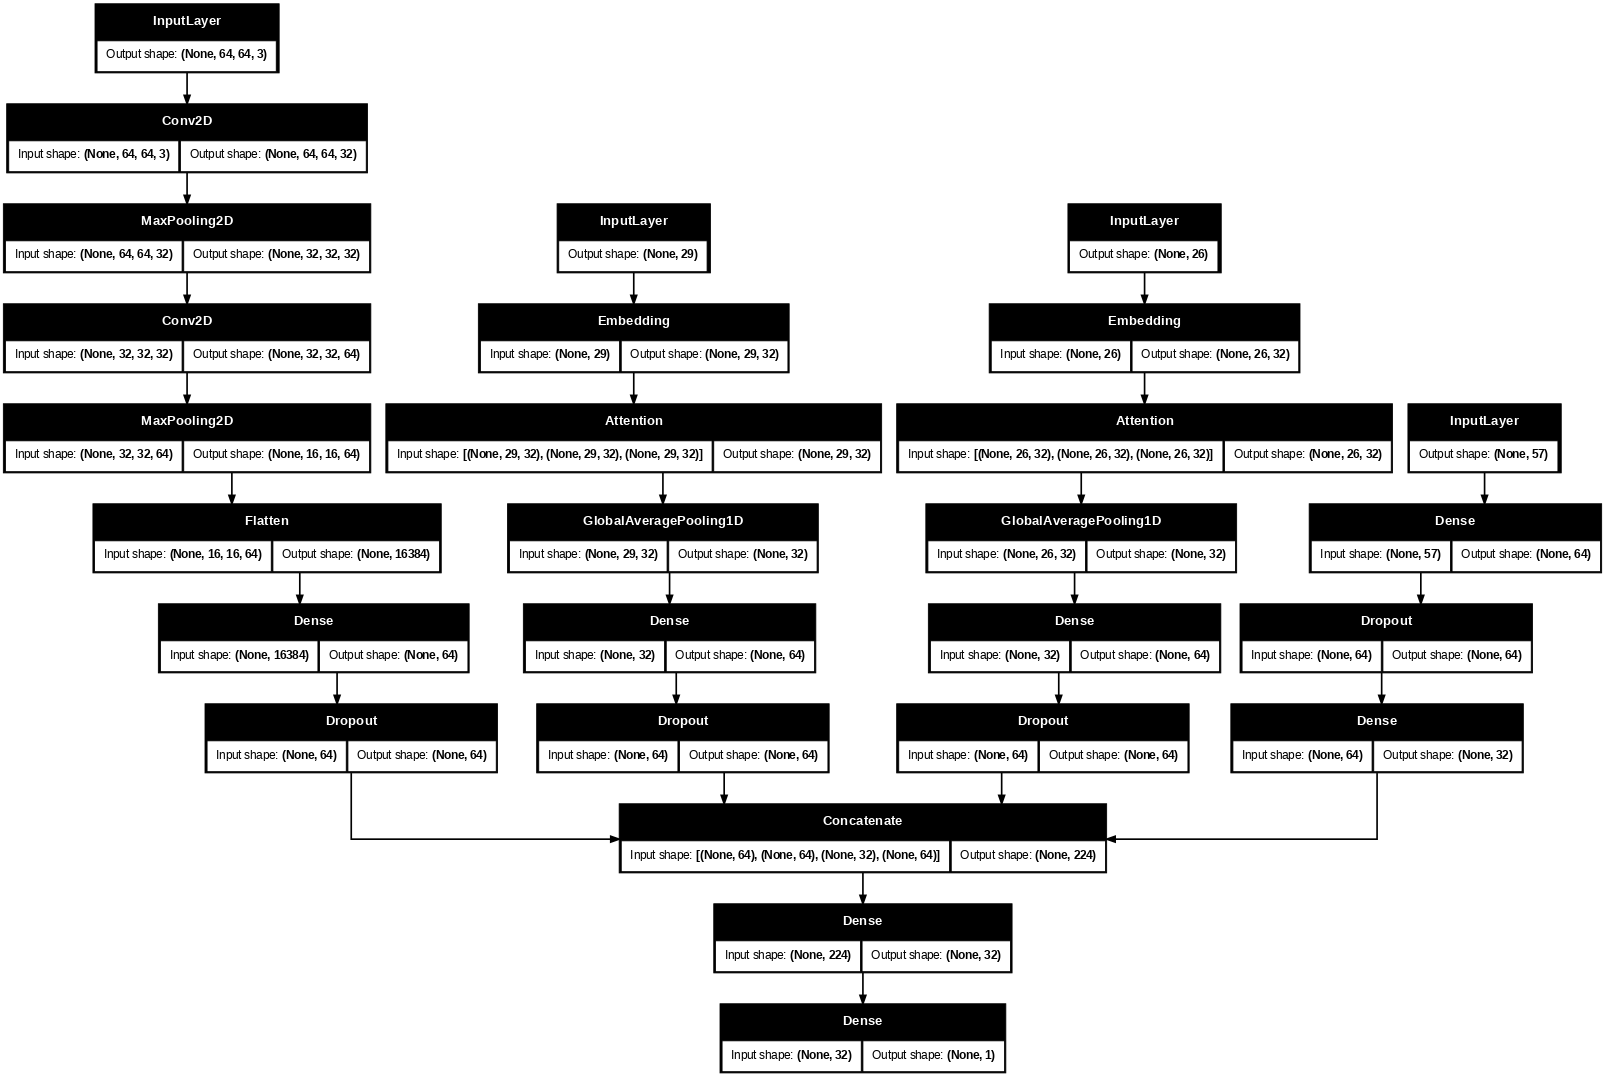

In [ ]:
#Compute 95th percentile lengths for each text
#column on filtered ChatGPT binary training data.
about_len_qkv_cgb   = int(pd.Series(X_cg_train_about_f).str.split().str.len().quantile(0.95))
founder_len_qkv_cgb = int(pd.Series(X_cg_train_founder_f).str.split().str.len().quantile(0.95))

#Get the number of structured columns.
n_struct_qkv_cgb    = X_cg_train_structured_f.shape[1]

#Adapt separate QKV vectorizers for each text
#column on the filtered training data.
tv_about_qkv_cgb = keras.layers.TextVectorization(
    output_mode="int", max_tokens=20_000, output_sequence_length=about_len_qkv_cgb)
tv_about_qkv_cgb.adapt(X_cg_train_about_f)

tv_founder_qkv_cgb = keras.layers.TextVectorization(
    output_mode="int", max_tokens=20_000, output_sequence_length=founder_len_qkv_cgb)
tv_founder_qkv_cgb.adapt(X_cg_train_founder_f)

#Vectorize all filtered splits.
X_cg_train_about_qkv_cgb   = tv_about_qkv_cgb(X_cg_train_about_f)
X_cg_val_about_qkv_cgb     = tv_about_qkv_cgb(X_cg_val_about_f)
X_cg_test_about_qkv_cgb    = tv_about_qkv_cgb(X_cg_test_about_f)

X_cg_train_founder_qkv_cgb = tv_founder_qkv_cgb(X_cg_train_founder_f)
X_cg_val_founder_qkv_cgb   = tv_founder_qkv_cgb(X_cg_val_founder_f)
X_cg_test_founder_qkv_cgb  = tv_founder_qkv_cgb(X_cg_test_founder_f)

#About text branch with QKV self-attention.
about_input_qkv_cgb = keras.Input(shape=(about_len_qkv_cgb,), name="about_input")
about_emb_qkv_cgb   = layers.Embedding(20_001, 32, name="emb_about_qkv_cgb")(about_input_qkv_cgb)
attended_a_qkv_cgb  = layers.Attention()([about_emb_qkv_cgb, about_emb_qkv_cgb, about_emb_qkv_cgb])
x_a_qkv_cgb = layers.GlobalAveragePooling1D()(attended_a_qkv_cgb)
x_a_qkv_cgb = layers.Dense(64, activation="relu")(x_a_qkv_cgb)
x_a_qkv_cgb = layers.Dropout(0.3)(x_a_qkv_cgb)

#Founder background branch with QKV self-attention.
founder_input_qkv_cgb = keras.Input(shape=(founder_len_qkv_cgb,), name="founder_input")
founder_emb_qkv_cgb   = layers.Embedding(20_001, 32, name="emb_founder_qkv_cgb")(founder_input_qkv_cgb)
attended_f_qkv_cgb    = layers.Attention()([founder_emb_qkv_cgb, founder_emb_qkv_cgb, founder_emb_qkv_cgb])
x_f_qkv_cgb = layers.GlobalAveragePooling1D()(attended_f_qkv_cgb)
x_f_qkv_cgb = layers.Dense(64, activation="relu")(x_f_qkv_cgb)
x_f_qkv_cgb = layers.Dropout(0.3)(x_f_qkv_cgb)

#Structured branch.
struct_input_qkv_cgb = keras.Input(shape=(n_struct_qkv_cgb,), name="struct_input")
x_s_qkv_cgb = layers.Dense(64, activation="relu")(struct_input_qkv_cgb)
x_s_qkv_cgb = layers.Dropout(0.3)(x_s_qkv_cgb)
x_s_qkv_cgb = layers.Dense(32, activation="relu")(x_s_qkv_cgb)

#Image (CNN) branch.
img_input_qkv_cgb, x_img_qkv_cgb = build_image_branch("logo_qkv_cgb")

#Merge all four branches and output a
#single sigmoid prediction.
merged_qkv_cgb = layers.Concatenate()([x_a_qkv_cgb, x_f_qkv_cgb, x_s_qkv_cgb, x_img_qkv_cgb])
merged_qkv_cgb = layers.Dense(32, activation="relu")(merged_qkv_cgb)
output_qkv_cgb = layers.Dense(1, activation="sigmoid")(merged_qkv_cgb)

#Define the model blueprint and compile it.
qkv_logo_model_cgb = keras.Model(
    inputs=[about_input_qkv_cgb, founder_input_qkv_cgb, struct_input_qkv_cgb, img_input_qkv_cgb],
    outputs=output_qkv_cgb)
qkv_logo_model_cgb.compile(
    optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(qkv_logo_model_cgb, show_shapes=True, dpi=60)

In [ ]:
#Fit the QKV model using filtered ChatGPT binary splits.
history_qkv_logo_cgb = qkv_logo_model_cgb.fit(
    x=[X_cg_train_about_qkv_cgb.numpy(), X_cg_train_founder_qkv_cgb.numpy(),
       X_cg_train_structured_f, X_cg_train_logos],
    y=y_cg_train_f,
    validation_data=(
        [X_cg_val_about_qkv_cgb.numpy(), X_cg_val_founder_qkv_cgb.numpy(),
         X_cg_val_structured_f, X_cg_val_logos],
        y_cg_val_f),
    epochs=20, batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)]
)

#Evaluate on the filtered test set.
test_loss_qkv_cgb, test_acc_qkv_cgb = qkv_logo_model_cgb.evaluate(
    [X_cg_test_about_qkv_cgb.numpy(), X_cg_test_founder_qkv_cgb.numpy(),
     X_cg_test_structured_f, X_cg_test_logos],
    y_cg_test_f)
print(f"\nQKV + Logo CG (Binary) — Test Accuracy: {test_acc_qkv_cgb:.4f} | Loss: {test_loss_qkv_cgb:.4f}")

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.5053 - loss: 6.5250 - val_accuracy: 0.5784 - val_loss: 4.1464
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4989 - loss: 2.1728 - val_accuracy: 0.4216 - val_loss: 2.2024
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5195 - loss: 1.2076 - val_accuracy: 0.4216 - val_loss: 2.0743
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5486 - loss: 0.8552 - val_accuracy: 0.5784 - val_loss: 0.9400
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5596 - loss: 4.3324

QKV + Logo CG (Binary) — Test Accuracy: 0.5596 | Loss: 4.3324


####Logo: MultiHead Binary

The MultiHead attention model with Logos performed better than the benchmark with an accuracy of 67.49%.

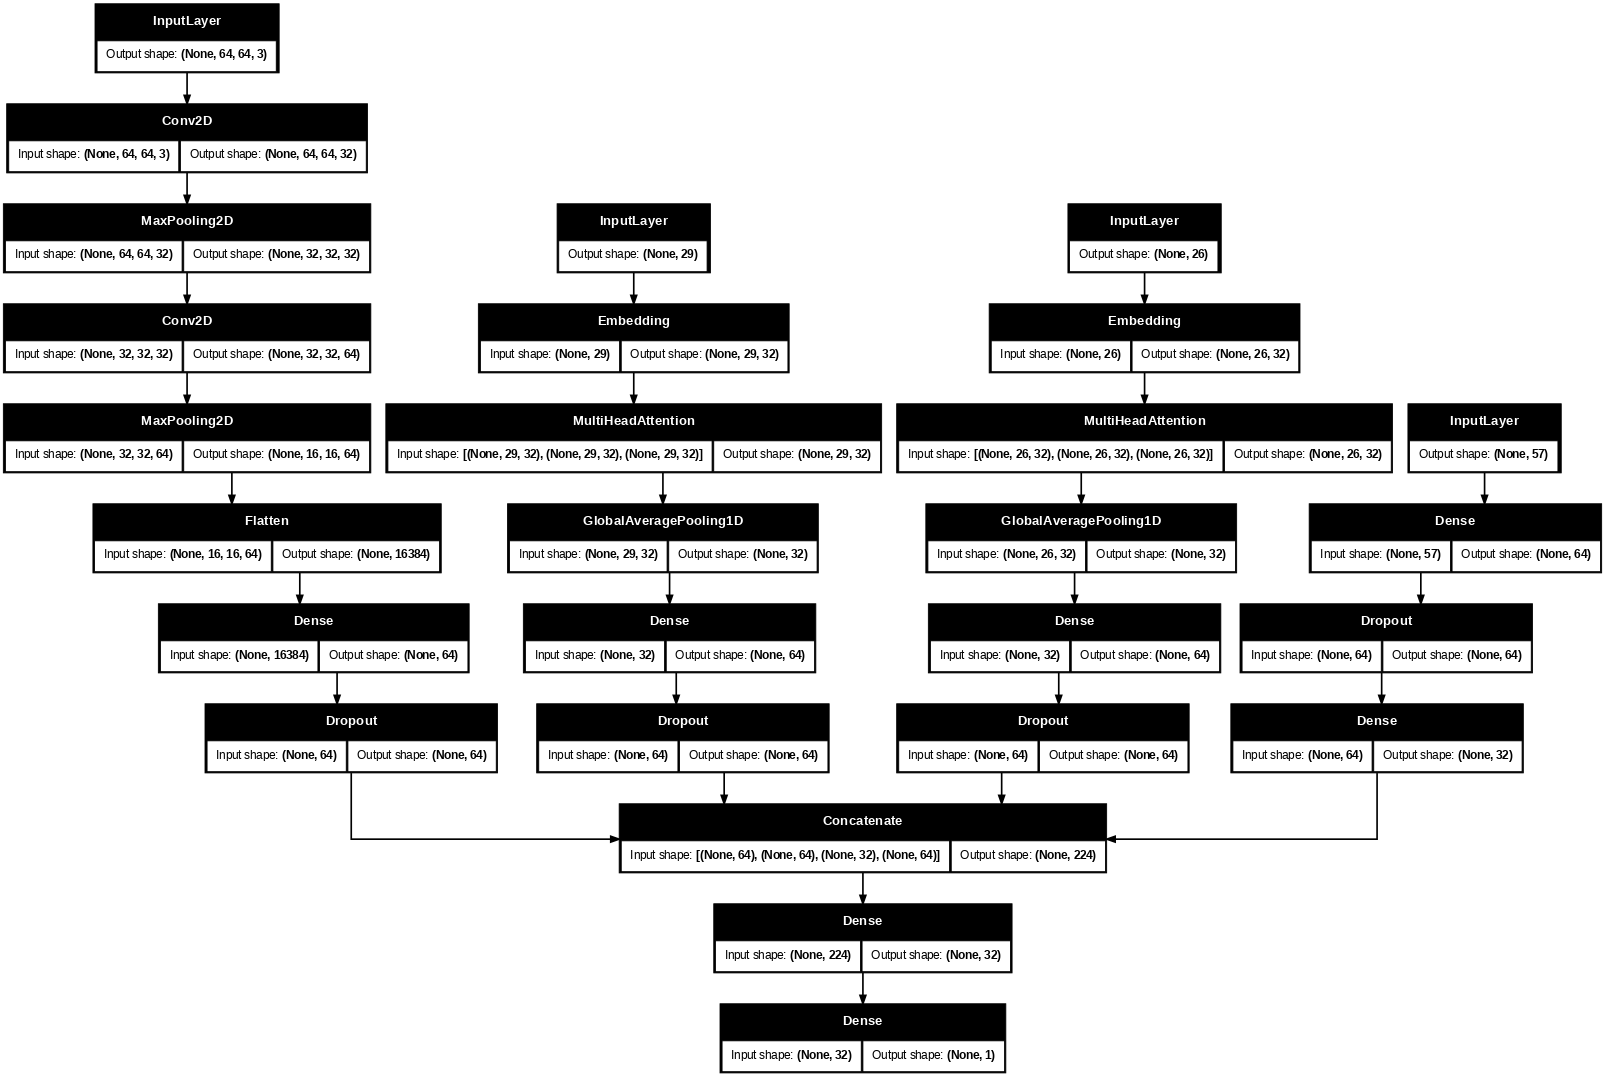

In [ ]:
#Compute 95th percentile lengths for each text
#column on filtered ChatGPT binary training data.
about_len_mha_cgb   = int(pd.Series(X_cg_train_about_f).str.split().str.len().quantile(0.95))
founder_len_mha_cgb = int(pd.Series(X_cg_train_founder_f).str.split().str.len().quantile(0.95))

#Define the same hyperparameters as the original
#ChatGPT binary MHA model.
VOCAB_MHA_CGB  = 10_001
EMBED_MHA_CGB  = 32
HEADS_MHA_CGB  = 2

#Get the number of structured columns.
n_struct_mha_cgb = X_cg_train_structured_f.shape[1]

#Adapt separate MHA vectorizers for each text
#column on the filtered training data.
tv_about_mha_cgb = keras.layers.TextVectorization(
    max_tokens=10_000, output_mode="int", output_sequence_length=about_len_mha_cgb)
tv_about_mha_cgb.adapt(X_cg_train_about_f)

tv_founder_mha_cgb = keras.layers.TextVectorization(
    max_tokens=10_000, output_mode="int", output_sequence_length=founder_len_mha_cgb)
tv_founder_mha_cgb.adapt(X_cg_train_founder_f)

#Vectorize all filtered splits.
X_cg_train_about_mha_cgb   = tv_about_mha_cgb(X_cg_train_about_f)
X_cg_val_about_mha_cgb     = tv_about_mha_cgb(X_cg_val_about_f)
X_cg_test_about_mha_cgb    = tv_about_mha_cgb(X_cg_test_about_f)

X_cg_train_founder_mha_cgb = tv_founder_mha_cgb(X_cg_train_founder_f)
X_cg_val_founder_mha_cgb   = tv_founder_mha_cgb(X_cg_val_founder_f)
X_cg_test_founder_mha_cgb  = tv_founder_mha_cgb(X_cg_test_founder_f)

#About text branch with multi-head self-attention.
about_input_mha_cgb = keras.Input(shape=(about_len_mha_cgb,), name="about_input")
about_emb_mha_cgb   = layers.Embedding(VOCAB_MHA_CGB, EMBED_MHA_CGB,
                                        name="emb_about_mha_cgb")(about_input_mha_cgb)
attended_a_mha_cgb  = layers.MultiHeadAttention(
    num_heads=HEADS_MHA_CGB, key_dim=EMBED_MHA_CGB // HEADS_MHA_CGB
)(about_emb_mha_cgb, about_emb_mha_cgb, about_emb_mha_cgb) #Q=K=V for self-attention.
x_a_mha_cgb = layers.GlobalAveragePooling1D()(attended_a_mha_cgb)
x_a_mha_cgb = layers.Dense(64, activation="relu")(x_a_mha_cgb)
x_a_mha_cgb = layers.Dropout(0.3)(x_a_mha_cgb)

#Founder background branch with multi-head self-attention.
founder_input_mha_cgb = keras.Input(shape=(founder_len_mha_cgb,), name="founder_input")
founder_emb_mha_cgb   = layers.Embedding(VOCAB_MHA_CGB, EMBED_MHA_CGB,
                                          name="emb_founder_mha_cgb")(founder_input_mha_cgb)
attended_f_mha_cgb    = layers.MultiHeadAttention(
    num_heads=HEADS_MHA_CGB, key_dim=EMBED_MHA_CGB // HEADS_MHA_CGB
)(founder_emb_mha_cgb, founder_emb_mha_cgb, founder_emb_mha_cgb) #Q=K=V for self-attention.
x_f_mha_cgb = layers.GlobalAveragePooling1D()(attended_f_mha_cgb)
x_f_mha_cgb = layers.Dense(64, activation="relu")(x_f_mha_cgb)
x_f_mha_cgb = layers.Dropout(0.3)(x_f_mha_cgb)

#Structured branch.
struct_input_mha_cgb = keras.Input(shape=(n_struct_mha_cgb,), name="struct_input")
x_s_mha_cgb = layers.Dense(64, activation="relu")(struct_input_mha_cgb)
x_s_mha_cgb = layers.Dropout(0.3)(x_s_mha_cgb)
x_s_mha_cgb = layers.Dense(32, activation="relu")(x_s_mha_cgb)

#Image (CNN) branch.
img_input_mha_cgb, x_img_mha_cgb = build_image_branch("logo_mha_cgb")

#Merge all four branches and output a
#single sigmoid prediction.
merged_mha_cgb = layers.Concatenate()([x_a_mha_cgb, x_f_mha_cgb, x_s_mha_cgb, x_img_mha_cgb])
merged_mha_cgb = layers.Dense(32, activation="relu")(merged_mha_cgb)
output_mha_cgb = layers.Dense(1, activation="sigmoid")(merged_mha_cgb)

#Define the model blueprint and compile it.
mha_logo_model_cgb = keras.Model(
    inputs=[about_input_mha_cgb, founder_input_mha_cgb, struct_input_mha_cgb, img_input_mha_cgb],
    outputs=output_mha_cgb)
mha_logo_model_cgb.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(mha_logo_model_cgb, show_shapes=True, dpi=60)

In [ ]:
#Fit the MHA model using filtered ChatGPT binary splits.
history_mha_logo_cgb = mha_logo_model_cgb.fit(
    x=[X_cg_train_about_mha_cgb.numpy(), X_cg_train_founder_mha_cgb.numpy(),
       X_cg_train_structured_f, X_cg_train_logos],
    y=y_cg_train_f,
    validation_data=(
        [X_cg_val_about_mha_cgb.numpy(), X_cg_val_founder_mha_cgb.numpy(),
         X_cg_val_structured_f, X_cg_val_logos],
        y_cg_val_f),
    epochs=20, batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)]
)

#Evaluate on the filtered test set.
test_loss_mha_cgb, test_acc_mha_cgb = mha_logo_model_cgb.evaluate(
    [X_cg_test_about_mha_cgb.numpy(), X_cg_test_founder_mha_cgb.numpy(),
     X_cg_test_structured_f, X_cg_test_logos],
    y_cg_test_f)
print(f"\nMHA + Logo CG (Binary) — Test Accuracy: {test_acc_mha_cgb:.4f} | Loss: {test_loss_mha_cgb:.4f}")

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.4968 - loss: 5.9939 - val_accuracy: 0.5784 - val_loss: 1.4867
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5229 - loss: 2.2019 - val_accuracy: 0.6388 - val_loss: 0.6445
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6337 - loss: 1.0745 - val_accuracy: 0.6928 - val_loss: 0.6946
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6923 - loss: 0.7654 - val_accuracy: 0.6697 - val_loss: 0.6773
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7758 - loss: 0.5760 - val_accuracy: 0.6697 - val_loss: 0.7472
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8656 - loss: 0.3503 - val_accuracy: 0.6594 - val_loss: 0.9011
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6749 - loss: 0.6935

MHA + Logo CG (Binary) — Test Accuracy: 0.6749 | Loss: 0.6935


####Logo Simple Model Multi-class

The simple multi-class model performed slightly better than the benchmark, with an accuracy of 51.81%.

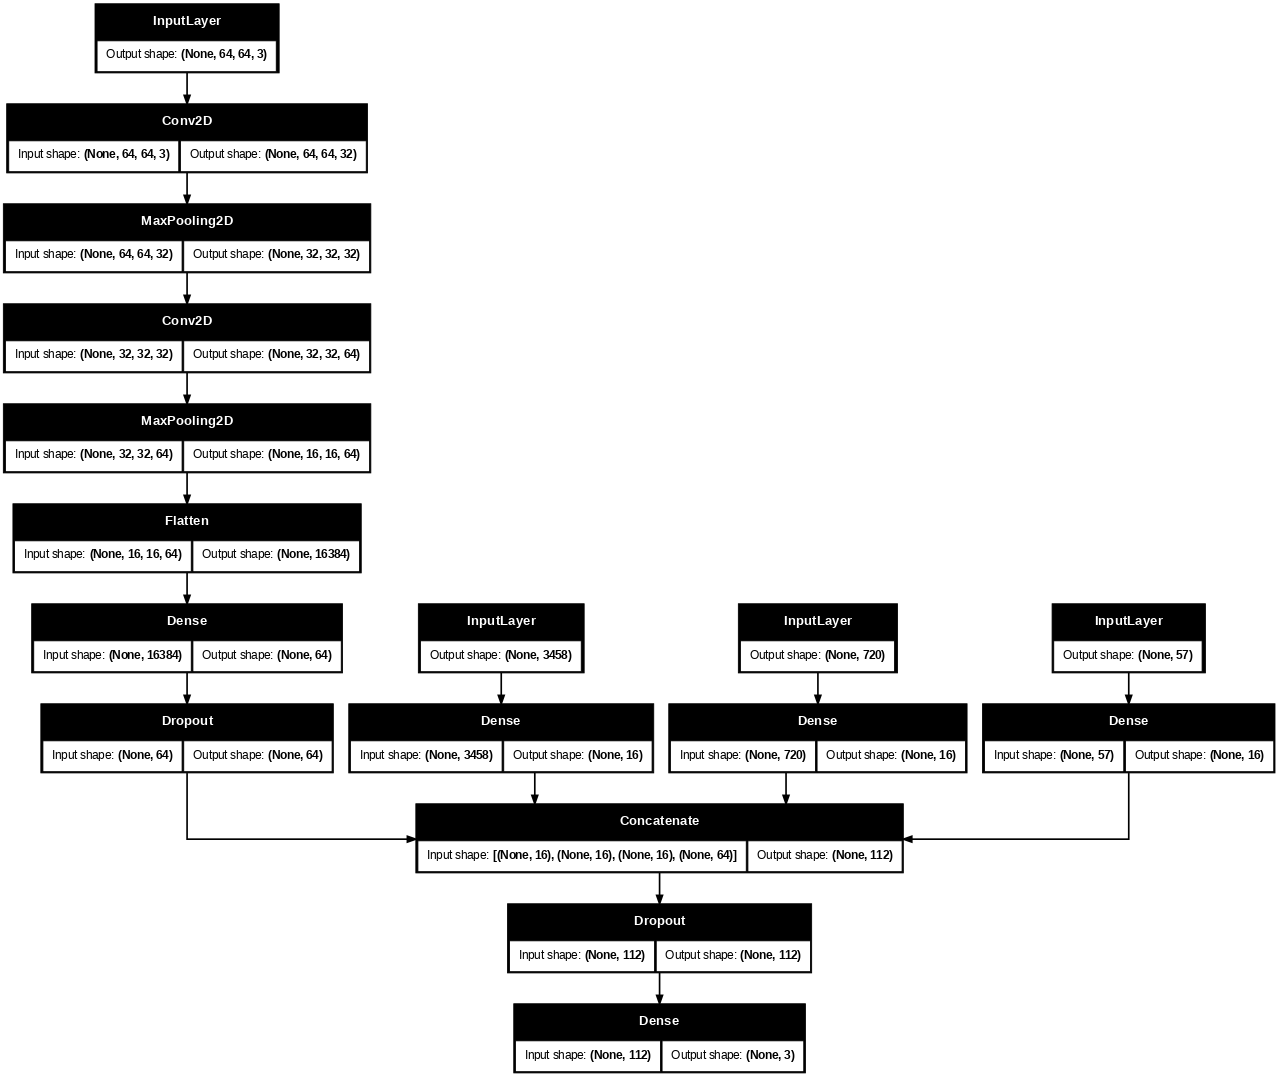

In [ ]:
#Adapt separate multi-hot vectorizers for each
#text column on filtered ChatGPT multiclass
#training data.
tv_about_s_cgm = keras.layers.TextVectorization(max_tokens=20_000, output_mode="multi_hot")
tv_about_s_cgm.adapt(X_cg_train_about_cm_f)

tv_founder_s_cgm = keras.layers.TextVectorization(max_tokens=20_000, output_mode="multi_hot")
tv_founder_s_cgm.adapt(X_cg_train_founder_cm_f)

#Vectorize all filtered multiclass splits.
X_cg_train_about_s_cgm   = tv_about_s_cgm(X_cg_train_about_cm_f).numpy()
X_cg_val_about_s_cgm     = tv_about_s_cgm(X_cg_val_about_cm_f).numpy()
X_cg_test_about_s_cgm    = tv_about_s_cgm(X_cg_test_about_cm_f).numpy()

X_cg_train_founder_s_cgm = tv_founder_s_cgm(X_cg_train_founder_cm_f).numpy()
X_cg_val_founder_s_cgm   = tv_founder_s_cgm(X_cg_val_founder_cm_f).numpy()
X_cg_test_founder_s_cgm  = tv_founder_s_cgm(X_cg_test_founder_cm_f).numpy()

#Retrieve vocabulary sizes and structured column
#count for the input layer dimensions.
n_struct_s_cgm    = X_cg_train_struct_cm_f.shape[1]
about_vocab_cgm   = tv_about_s_cgm.vocabulary_size()
founder_vocab_cgm = tv_founder_s_cgm.vocabulary_size()

#About text branch.
about_input_s_cgm   = keras.Input(shape=(about_vocab_cgm,),   name="about_input")
founder_input_s_cgm = keras.Input(shape=(founder_vocab_cgm,), name="founder_input")
struct_input_s_cgm  = keras.Input(shape=(n_struct_s_cgm,),    name="struct_input")

x_a_s_cgm = keras.layers.Dense(16, activation="relu")(about_input_s_cgm)
x_f_s_cgm = keras.layers.Dense(16, activation="relu")(founder_input_s_cgm)
x_s_s_cgm = keras.layers.Dense(16, activation="relu")(struct_input_s_cgm)

#Image (CNN) branch.
img_input_s_cgm, x_img_s_cgm = build_image_branch("logo_s_cgm")

#Merge all four branches and output 3
#classes via softmax.
merged_s_cgm = keras.layers.Concatenate()([x_a_s_cgm, x_f_s_cgm, x_s_s_cgm, x_img_s_cgm])
merged_s_cgm = keras.layers.Dropout(0.5)(merged_s_cgm)
output_s_cgm = keras.layers.Dense(3, activation="softmax")(merged_s_cgm)

#Define the model blueprint and compile it.
simple_logo_model_cgm = keras.Model(
    inputs=[about_input_s_cgm, founder_input_s_cgm, struct_input_s_cgm, img_input_s_cgm],
    outputs=output_s_cgm)
simple_logo_model_cgm.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(simple_logo_model_cgm, show_shapes=True, dpi=60)

In [ ]:
#Fit the model using filtered ChatGPT multiclass
#splits. class_weight_dict_cm_f is recomputed on
#filtered labels to handle IPO class imbalance.
history_simple_logo_cgm = simple_logo_model_cgm.fit(
    x=[X_cg_train_about_s_cgm, X_cg_train_founder_s_cgm,
       X_cg_train_struct_cm_f, X_cg_train_logos],
    y=y_cg_train_cm_f,
    validation_data=(
        [X_cg_val_about_s_cgm, X_cg_val_founder_s_cgm,
         X_cg_val_struct_cm_f, X_cg_val_logos],
        y_cg_val_cm_f),
    epochs=10, batch_size=32, class_weight=class_weight_dict_cm_f
)

#Evaluate on the filtered test set.
test_loss_s_cgm, test_acc_s_cgm = simple_logo_model_cgm.evaluate(
    [X_cg_test_about_s_cgm, X_cg_test_founder_s_cgm,
     X_cg_test_struct_cm_f, X_cg_test_logos],
    y_cg_test_cm_f)
print(f"\nSimple + Logo CG (Multiclass) — Test Accuracy: {test_acc_s_cgm:.4f} | Loss: {test_loss_s_cgm:.4f}")

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.3115 - loss: 103.6821 - val_accuracy: 0.4100 - val_loss: 25.9852
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3184 - loss: 45.6622 - val_accuracy: 0.4807 - val_loss: 14.4688
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3457 - loss: 14.8674 - val_accuracy: 0.4807 - val_loss: 4.3427
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3783 - loss: 2.6667 - val_accuracy: 0.1838 - val_loss: 1.1845
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4211 - loss: 1.1362 - val_accuracy: 0.5476 - val_loss: 0.9666
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5062 - loss: 1.0349 - val_accuracy: 0.5219 - val_loss: 1.0217
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5597 - loss: 0.9702 - val_accuracy: 0.4332 - val_loss: 1.0495
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5824 - loss: 0.9270 - val_accuracy: 0.5347 - va

####Logo: Embedding Model Multi-class

The embeding model with Logos performed about the same as the benchmark with the accuracy of 48.7%.

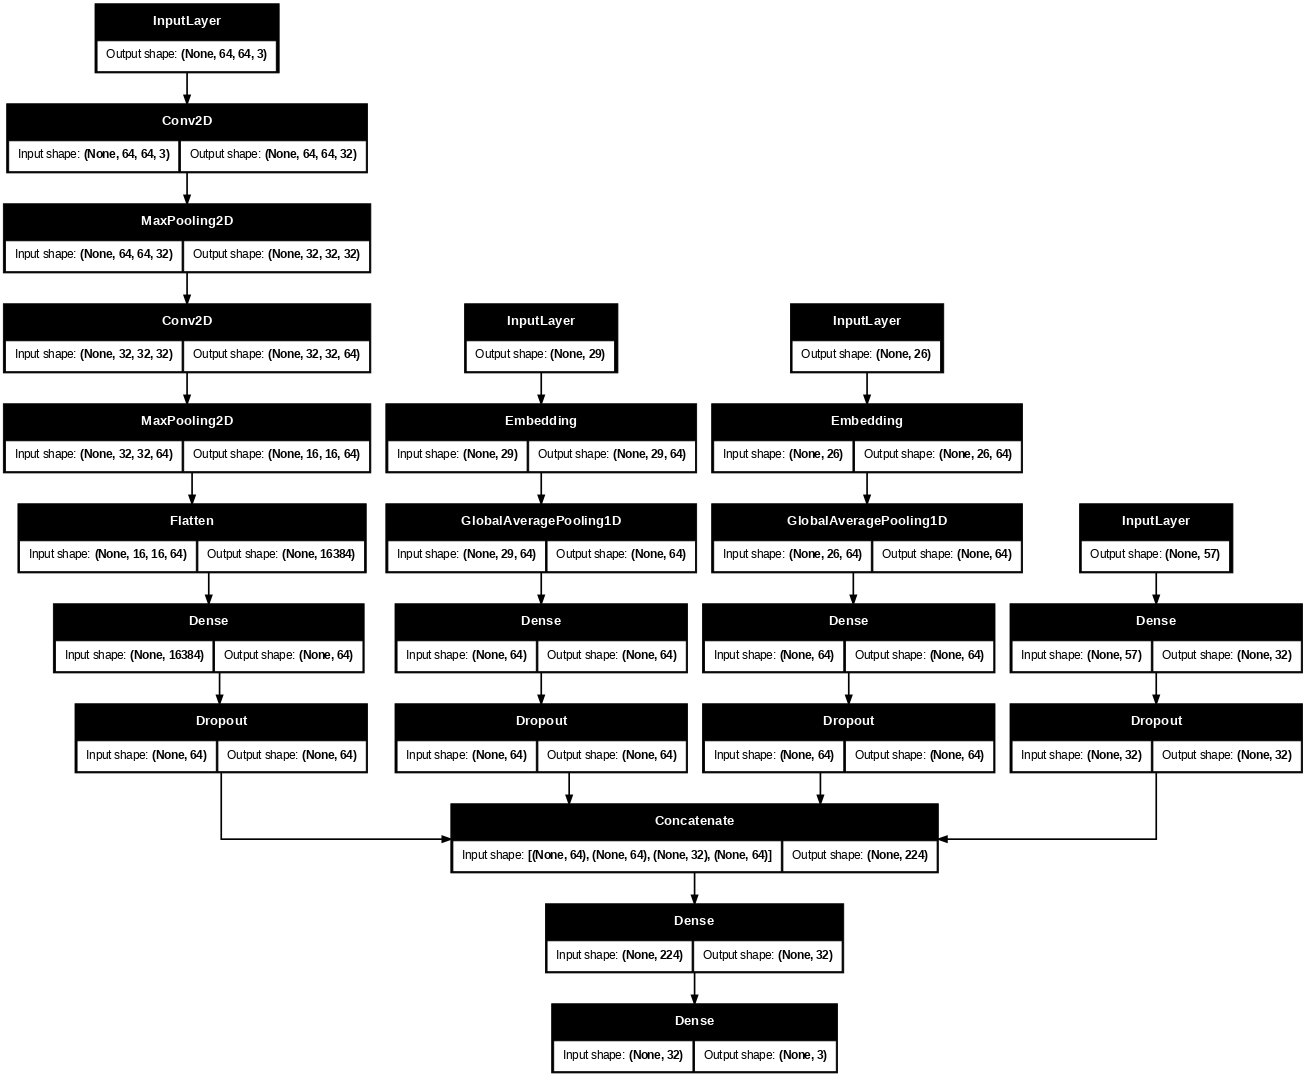

In [ ]:
#Compute 95th percentile lengths for each text
#column on filtered ChatGPT multiclass training data.
about_len_e_cgm   = int(pd.Series(X_cg_train_about_cm_f).str.split().str.len().quantile(0.95))
founder_len_e_cgm = int(pd.Series(X_cg_train_founder_cm_f).str.split().str.len().quantile(0.95))

#Get the number of structured columns.
n_struct_e_cgm    = X_cg_train_struct_cm_f.shape[1]

#Adapt separate embedding vectorizers for each
#text column on the filtered training data.
tv_about_e_cgm = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="int", output_sequence_length=about_len_e_cgm)
tv_about_e_cgm.adapt(X_cg_train_about_cm_f)

tv_founder_e_cgm = keras.layers.TextVectorization(
    max_tokens=20_000, output_mode="int", output_sequence_length=founder_len_e_cgm)
tv_founder_e_cgm.adapt(X_cg_train_founder_cm_f)

#Vectorize all filtered multiclass splits.
X_cg_train_about_e_cgm   = tv_about_e_cgm(X_cg_train_about_cm_f).numpy()
X_cg_val_about_e_cgm     = tv_about_e_cgm(X_cg_val_about_cm_f).numpy()
X_cg_test_about_e_cgm    = tv_about_e_cgm(X_cg_test_about_cm_f).numpy()

X_cg_train_founder_e_cgm = tv_founder_e_cgm(X_cg_train_founder_cm_f).numpy()
X_cg_val_founder_e_cgm   = tv_founder_e_cgm(X_cg_val_founder_cm_f).numpy()
X_cg_test_founder_e_cgm  = tv_founder_e_cgm(X_cg_test_founder_cm_f).numpy()

#About text branch — embed, pool, dense.
about_input_e_cgm   = keras.Input(shape=(about_len_e_cgm,),   name="about_input")
founder_input_e_cgm = keras.Input(shape=(founder_len_e_cgm,), name="founder_input")
struct_input_e_cgm  = keras.Input(shape=(n_struct_e_cgm,),    name="struct_input")

x_a_e_cgm = keras.layers.Embedding(20_000, 64, name="emb_about_e_cgm")(about_input_e_cgm)
x_a_e_cgm = keras.layers.GlobalAveragePooling1D()(x_a_e_cgm)
x_a_e_cgm = keras.layers.Dense(64, activation="relu")(x_a_e_cgm)
x_a_e_cgm = keras.layers.Dropout(0.3)(x_a_e_cgm)

#Founder background branch — embed, pool, dense.
x_f_e_cgm = keras.layers.Embedding(20_000, 64, name="emb_founder_e_cgm")(founder_input_e_cgm)
x_f_e_cgm = keras.layers.GlobalAveragePooling1D()(x_f_e_cgm)
x_f_e_cgm = keras.layers.Dense(64, activation="relu")(x_f_e_cgm)
x_f_e_cgm = keras.layers.Dropout(0.3)(x_f_e_cgm)

#Structured branch.
x_s_e_cgm = keras.layers.Dense(32, activation="relu")(struct_input_e_cgm)
x_s_e_cgm = keras.layers.Dropout(0.3)(x_s_e_cgm)

#Image (CNN) branch.
img_input_e_cgm, x_img_e_cgm = build_image_branch("logo_e_cgm")

#Merge all four branches and output 3 classes.
combined_e_cgm = keras.layers.Concatenate()([x_a_e_cgm, x_f_e_cgm, x_s_e_cgm, x_img_e_cgm])
x_e_cgm        = keras.layers.Dense(32, activation="relu")(combined_e_cgm)
output_e_cgm   = keras.layers.Dense(3, activation="softmax")(x_e_cgm)

#Define the model blueprint and compile it.
emb_logo_model_cgm = keras.Model(
    inputs=[about_input_e_cgm, founder_input_e_cgm, struct_input_e_cgm, img_input_e_cgm],
    outputs=output_e_cgm)
emb_logo_model_cgm.compile(
    optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(emb_logo_model_cgm, show_shapes=True, dpi=60)

In [ ]:
#Fit the model using filtered ChatGPT multiclass splits.
history_emb_logo_cgm = emb_logo_model_cgm.fit(
    x=[X_cg_train_about_e_cgm, X_cg_train_founder_e_cgm,
       X_cg_train_struct_cm_f, X_cg_train_logos],
    y=y_cg_train_cm_f,
    validation_data=(
        [X_cg_val_about_e_cgm, X_cg_val_founder_e_cgm,
         X_cg_val_struct_cm_f, X_cg_val_logos],
        y_cg_val_cm_f),
    epochs=10, batch_size=32, class_weight=class_weight_dict_cm_f
)

#Evaluate on the filtered test set.
test_loss_e_cgm, test_acc_e_cgm = emb_logo_model_cgm.evaluate(
    [X_cg_test_about_e_cgm, X_cg_test_founder_e_cgm,
     X_cg_test_struct_cm_f, X_cg_test_logos],
    y_cg_test_cm_f)
print(f"\nEmbedding + Logo CG (Multiclass) — Test Accuracy: {test_acc_e_cgm:.4f} | Loss: {test_loss_e_cgm:.4f}")

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.3427 - loss: 25.7524 - val_accuracy: 0.0887 - val_loss: 4.8144
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3500 - loss: 9.4276 - val_accuracy: 0.4319 - val_loss: 6.7436
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3556 - loss: 5.5547 - val_accuracy: 0.4319 - val_loss: 2.8418
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3457 - loss: 3.7132 - val_accuracy: 0.4794 - val_loss: 3.0472
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3385 - loss: 2.6609 - val_accuracy: 0.4319 - val_loss: 2.7874
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3633 - loss: 1.8297 - val_accuracy: 0.4332 - val_loss: 1.2674
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3496 - loss: 1.5378 - val_accuracy: 0.4344 - val_loss: 1.5842
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3526 - loss: 1.3279 - val_accuracy: 0.4781 - val_l

####Logo: RNN Model  Multi-class

The best model here was the Bi-LSTM model with an accuracy of 54.27%, better than the benchmark.

In [ ]:
#Builder function for the ChatGPT multiclass RNN
#+ logo model. Four branches: about text, founder
#background, structured, and image.
def build_rnn_logo_model_cgm(rnn_layer):
    """Multiclass 4-branch RNN + logo CNN for the ChatGPT dataset."""

    #Compute 95th percentile lengths for each
    #text column on filtered multiclass training data.
    about_len   = int(pd.Series(X_cg_train_about_cm_f).str.split().str.len().quantile(0.95))
    founder_len = int(pd.Series(X_cg_train_founder_cm_f).str.split().str.len().quantile(0.95))

    #Get the number of structured columns.
    n_struct    = X_cg_train_struct_cm_f.shape[1]
    base_name   = rnn_layer.name.split("_")[0]

    #Adapt separate vectorizers for each column
    #on the filtered training data.
    tv_a = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode="int", output_sequence_length=about_len)
    tv_a.adapt(X_cg_train_about_cm_f)

    tv_f = keras.layers.TextVectorization(
        max_tokens=20_000, output_mode="int", output_sequence_length=founder_len)
    tv_f.adapt(X_cg_train_founder_cm_f)

    #Create a renamed copy of the RNN layer for
    #the founder branch to avoid duplicate names.
    config = rnn_layer.get_config()
    config["name"] = f"{base_name}_founder_cgm"
    founder_rnn = type(rnn_layer).from_config(config)

    #Handle the Bidirectional case separately.
    if isinstance(rnn_layer, keras.layers.Bidirectional):
        inner        = rnn_layer.forward_layer
        inner_config = inner.get_config()
        inner_config["name"] = f"{inner.name.split('_')[0]}_founder_cgm_inner"
        founder_rnn  = keras.layers.Bidirectional(
            type(inner).from_config(inner_config), name="bidirectional_founder_cgm")

    #About text branch.
    about_input = keras.Input(shape=(1,), dtype=tf.string, name="about_input")
    x_a = tv_a(about_input)
    x_a = keras.layers.Embedding(20_000, 64, name=f"emb_about_{base_name}_cgm")(x_a)
    x_a = rnn_layer(x_a)
    x_a = keras.layers.Dropout(0.3)(x_a)

    #Founder background branch.
    founder_input = keras.Input(shape=(1,), dtype=tf.string, name="founder_input")
    x_f = tv_f(founder_input)
    x_f = keras.layers.Embedding(20_000, 64, name=f"emb_founder_{base_name}_cgm")(x_f)
    x_f = founder_rnn(x_f)
    x_f = keras.layers.Dropout(0.3)(x_f)

    #Structured branch.
    struct_input = keras.Input(shape=(n_struct,), name="struct_input")
    x_s = keras.layers.Dense(32, activation="relu")(struct_input)
    x_s = keras.layers.Dropout(0.3)(x_s)

    #Image (CNN) branch.
    img_input, x_img = build_image_branch(f"logo_{base_name}_cgm")

    #Merge all four branches and output 3 classes.
    combined = keras.layers.Concatenate()([x_a, x_f, x_s, x_img])
    x        = keras.layers.Dense(32, activation="relu")(combined)
    output   = keras.layers.Dense(3, activation="softmax")(x)

    #Define the model and compile it.
    model = keras.Model(
        inputs=[about_input, founder_input, struct_input, img_input], outputs=output)
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


#Dictionary of the six RNN variants to test.
rnn_logo_models_cgm = {
    "SimpleRNN":    keras.layers.SimpleRNN(64),
    "LSTM":         keras.layers.LSTM(64),
    "GRU":          keras.layers.GRU(64),
    "Bi-SimpleRNN": keras.layers.Bidirectional(keras.layers.SimpleRNN(64)),
    "Bi-LSTM":      keras.layers.Bidirectional(keras.layers.LSTM(64)),
    "Bi-GRU":       keras.layers.Bidirectional(keras.layers.GRU(64)),
}

#Empty list to store results.
results_rnn_logo_cgm = []

#Loop through each RNN variant and record results.
for model_name, rnn_layer in rnn_logo_models_cgm.items():
    print(f"\n{'='*50}")
    print(f"Training (ChatGPT Multiclass + Logo): {model_name}")
    print(f"{'='*50}")

    #Build the model with the current RNN layer.
    model = build_rnn_logo_model_cgm(rnn_layer)

    #Fit the model using filtered ChatGPT multiclass splits.
    history = model.fit(
        x=[X_cg_train_about_cm_f, X_cg_train_founder_cm_f,
           X_cg_train_struct_cm_f, X_cg_train_logos],
        y=y_cg_train_cm_f,
        validation_data=(
            [X_cg_val_about_cm_f, X_cg_val_founder_cm_f,
             X_cg_val_struct_cm_f, X_cg_val_logos],
            y_cg_val_cm_f),
        epochs=10, batch_size=32, class_weight=class_weight_dict_cm_f
    )

    #Calculate average validation accuracy and loss.
    avg_val_acc  = sum(history.history["val_accuracy"]) / len(history.history["val_accuracy"])
    avg_val_loss = sum(history.history["val_loss"])     / len(history.history["val_loss"])

    #Evaluate on the filtered test set.
    test_loss, test_acc = model.evaluate(
        [X_cg_test_about_cm_f, X_cg_test_founder_cm_f,
         X_cg_test_struct_cm_f, X_cg_test_logos],
        y_cg_test_cm_f, verbose=0)

    #Store the results for the summary table.
    results_rnn_logo_cgm.append({
        "Model":            model_name,
        "Avg Val Accuracy": round(avg_val_acc,  4),
        "Avg Val Loss":     round(avg_val_loss,  4),
        "Test Accuracy":    round(test_acc,  4),
        "Test Loss":        round(test_loss, 4),
    })
    print(f"Done! Test Accuracy: {test_acc:.4f}")

#Print a summary table of all RNN results.
results_rnn_logo_cgm_df = pd.DataFrame(results_rnn_logo_cgm).set_index("Model")
print("\n\n===== CHATGPT MULTICLASS + LOGO — RNN SUMMARY =====")
print(results_rnn_logo_cgm_df.to_string())


Training (ChatGPT Multiclass + Logo): SimpleRNN
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.3329 - loss: 58.3640 - val_accuracy: 0.4794 - val_loss: 20.8389
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3526 - loss: 16.4479 - val_accuracy: 0.4319 - val_loss: 24.6746
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.3611 - loss: 9.0350 - val_accuracy: 0.4319 - val_loss: 4.9642
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.3629 - loss: 6.0867 - val_accuracy: 0.4319 - val_loss: 14.5747
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3825 - loss: 4.6812 - val_accuracy: 0.4794 - val_loss: 7.8522
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.4335 - loss: 3.4919 - val_accuracy: 0.2442 - val_loss: 5.0330
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5053 - loss: 2.3273 - val_accuracy: 0.4177 - val_loss: 2.1180
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accu

####Logo: QKV Attention Multiclass

The QKV multiclass model with logos performed better than the becnhmark with an accuracy of 57.64%.

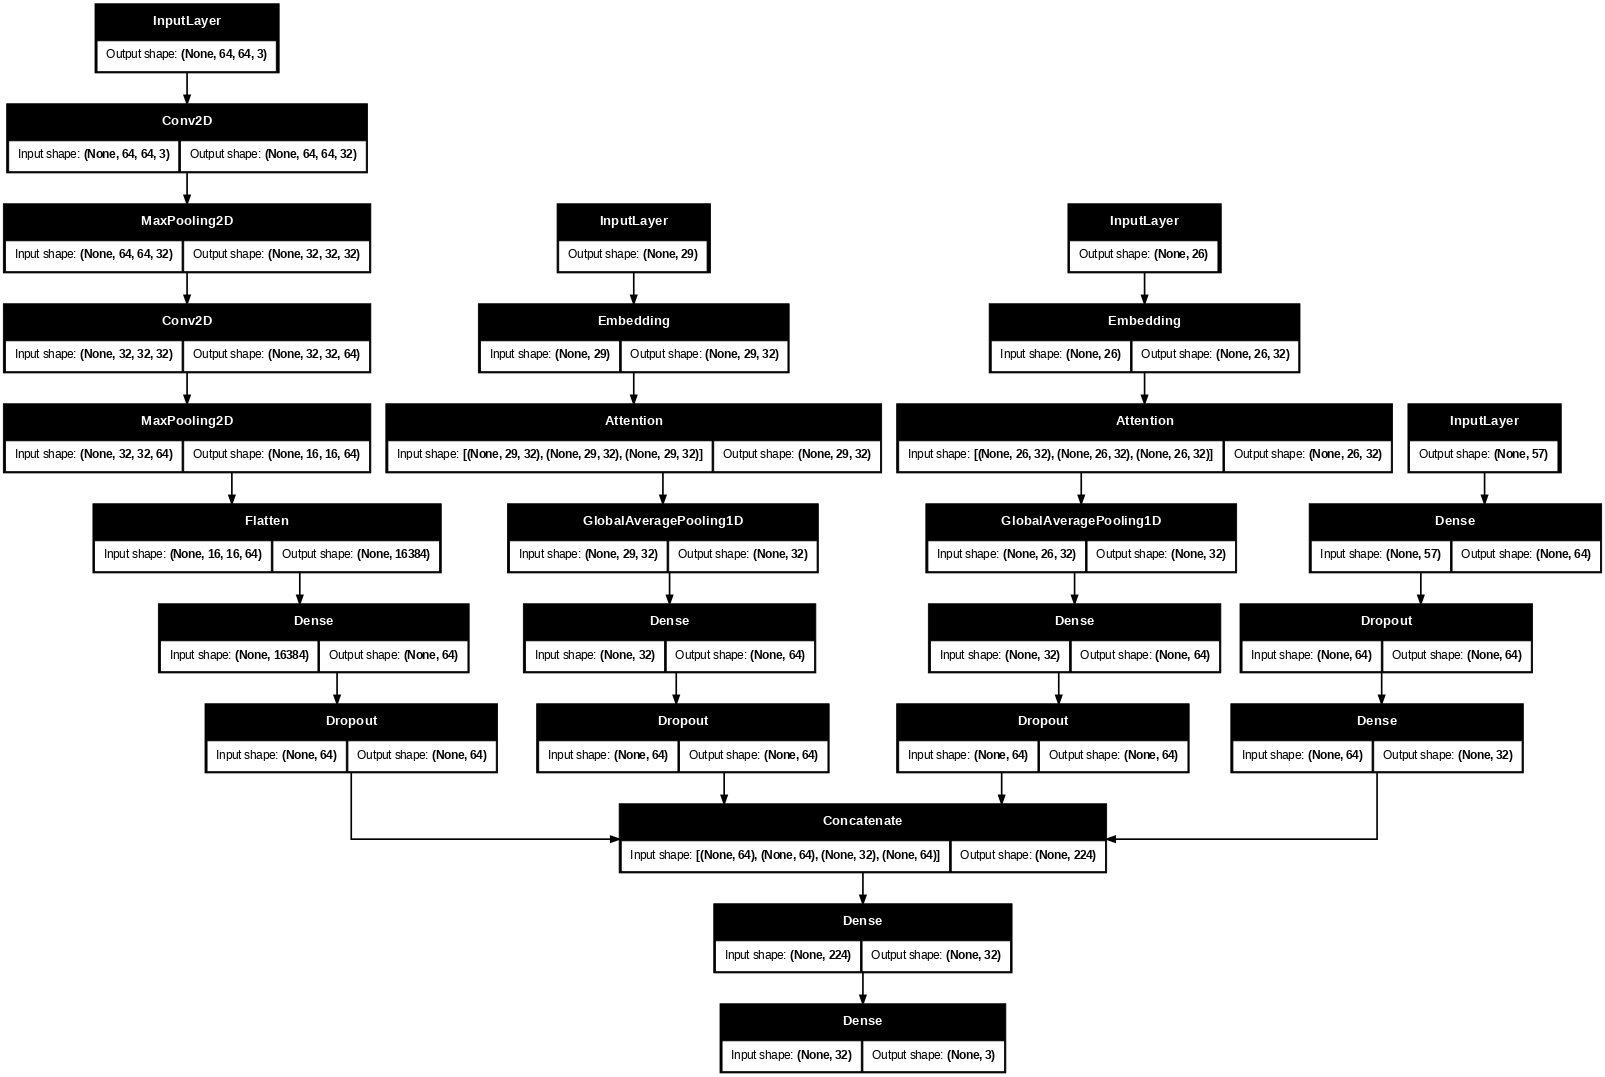

In [ ]:
#Compute 95th percentile lengths for each text
#column on filtered ChatGPT multiclass training data.
about_len_qkv_cgm   = int(pd.Series(X_cg_train_about_cm_f).str.split().str.len().quantile(0.95))
founder_len_qkv_cgm = int(pd.Series(X_cg_train_founder_cm_f).str.split().str.len().quantile(0.95))

#Get the number of structured columns.
n_struct_qkv_cgm    = X_cg_train_struct_cm_f.shape[1]

#Adapt separate QKV vectorizers for each text
#column on filtered multiclass training data.
tv_about_qkv_cgm = keras.layers.TextVectorization(
    output_mode="int", max_tokens=20_000, output_sequence_length=about_len_qkv_cgm)
tv_about_qkv_cgm.adapt(X_cg_train_about_cm_f)

tv_founder_qkv_cgm = keras.layers.TextVectorization(
    output_mode="int", max_tokens=20_000, output_sequence_length=founder_len_qkv_cgm)
tv_founder_qkv_cgm.adapt(X_cg_train_founder_cm_f)

#Vectorize all filtered multiclass splits.
X_cg_train_about_qkv_cgm   = tv_about_qkv_cgm(X_cg_train_about_cm_f)
X_cg_val_about_qkv_cgm     = tv_about_qkv_cgm(X_cg_val_about_cm_f)
X_cg_test_about_qkv_cgm    = tv_about_qkv_cgm(X_cg_test_about_cm_f)

X_cg_train_founder_qkv_cgm = tv_founder_qkv_cgm(X_cg_train_founder_cm_f)
X_cg_val_founder_qkv_cgm   = tv_founder_qkv_cgm(X_cg_val_founder_cm_f)
X_cg_test_founder_qkv_cgm  = tv_founder_qkv_cgm(X_cg_test_founder_cm_f)

#About text branch with QKV self-attention.
about_input_qkv_cgm   = keras.Input(shape=(about_len_qkv_cgm,),   name="about_input")
founder_input_qkv_cgm = keras.Input(shape=(founder_len_qkv_cgm,), name="founder_input")
struct_input_qkv_cgm  = keras.Input(shape=(n_struct_qkv_cgm,),    name="struct_input")

about_emb_qkv_cgm  = layers.Embedding(20_001, 32, name="emb_about_qkv_cgm")(about_input_qkv_cgm)
attended_a_qkv_cgm = layers.Attention()([about_emb_qkv_cgm, about_emb_qkv_cgm, about_emb_qkv_cgm])
x_a_qkv_cgm = layers.GlobalAveragePooling1D()(attended_a_qkv_cgm)
x_a_qkv_cgm = layers.Dense(64, activation="relu")(x_a_qkv_cgm)
x_a_qkv_cgm = layers.Dropout(0.3)(x_a_qkv_cgm)

#Founder background branch with QKV self-attention.
founder_emb_qkv_cgm  = layers.Embedding(20_001, 32, name="emb_founder_qkv_cgm")(founder_input_qkv_cgm)
attended_f_qkv_cgm   = layers.Attention()([founder_emb_qkv_cgm, founder_emb_qkv_cgm, founder_emb_qkv_cgm])
x_f_qkv_cgm = layers.GlobalAveragePooling1D()(attended_f_qkv_cgm)
x_f_qkv_cgm = layers.Dense(64, activation="relu")(x_f_qkv_cgm)
x_f_qkv_cgm = layers.Dropout(0.3)(x_f_qkv_cgm)

#Structured branch.
x_s_qkv_cgm = layers.Dense(64, activation="relu")(struct_input_qkv_cgm)
x_s_qkv_cgm = layers.Dropout(0.3)(x_s_qkv_cgm)
x_s_qkv_cgm = layers.Dense(32, activation="relu")(x_s_qkv_cgm)

#Image (CNN) branch.
img_input_qkv_cgm, x_img_qkv_cgm = build_image_branch("logo_qkv_cgm")

#Merge all four branches and output 3 classes.
merged_qkv_cgm = layers.Concatenate()([x_a_qkv_cgm, x_f_qkv_cgm, x_s_qkv_cgm, x_img_qkv_cgm])
merged_qkv_cgm = layers.Dense(32, activation="relu")(merged_qkv_cgm)
output_qkv_cgm = layers.Dense(3, activation="softmax")(merged_qkv_cgm)

#Define the model blueprint and compile it.
qkv_logo_model_cgm = keras.Model(
    inputs=[about_input_qkv_cgm, founder_input_qkv_cgm, struct_input_qkv_cgm, img_input_qkv_cgm],
    outputs=output_qkv_cgm)
qkv_logo_model_cgm.compile(
    optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(qkv_logo_model_cgm, show_shapes=True, dpi=60)

In [ ]:
#Fit the QKV model using filtered ChatGPT multiclass splits.
history_qkv_logo_cgm = qkv_logo_model_cgm.fit(
    x=[X_cg_train_about_qkv_cgm.numpy(), X_cg_train_founder_qkv_cgm.numpy(),
       X_cg_train_struct_cm_f, X_cg_train_logos],
    y=y_cg_train_cm_f,
    validation_data=(
        [X_cg_val_about_qkv_cgm.numpy(), X_cg_val_founder_qkv_cgm.numpy(),
         X_cg_val_struct_cm_f, X_cg_val_logos],
        y_cg_val_cm_f),
    epochs=20, batch_size=16, class_weight=class_weight_dict_cm_f,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)]
)

#Evaluate on the filtered test set.
test_loss_qkv_cgm, test_acc_qkv_cgm = qkv_logo_model_cgm.evaluate(
    [X_cg_test_about_qkv_cgm.numpy(), X_cg_test_founder_qkv_cgm.numpy(),
     X_cg_test_struct_cm_f, X_cg_test_logos],
    y_cg_test_cm_f)
print(f"\nQKV + Logo CG (Multiclass) — Test Accuracy: {test_acc_qkv_cgm:.4f} | Loss: {test_loss_qkv_cgm:.4f}")

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.3303 - loss: 14.7863 - val_accuracy: 0.4794 - val_loss: 1.9750
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3196 - loss: 4.9780 - val_accuracy: 0.4794 - val_loss: 4.0701
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3522 - loss: 2.0650 - val_accuracy: 0.4794 - val_loss: 2.0694
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3718 - loss: 1.4161 - val_accuracy: 0.4833 - val_loss: 1.0065
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4296 - loss: 1.2209 - val_accuracy: 0.5630 - val_loss: 0.9458
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4561 - loss: 1.0767 - val_accuracy: 0.5746 - val_loss: 0.9509
Epoch 7/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5165 - loss: 1.0016 - val_accuracy: 0.3830 - val_loss: 1.0791
Epoch 8/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5349 - loss: 0.9459 - val_accuracy:

####Logo: MultiHead Attention Multiclass

The Multi-Head Attention Model with Logos performed better than the benchmark with an accuracy of 52.85%.

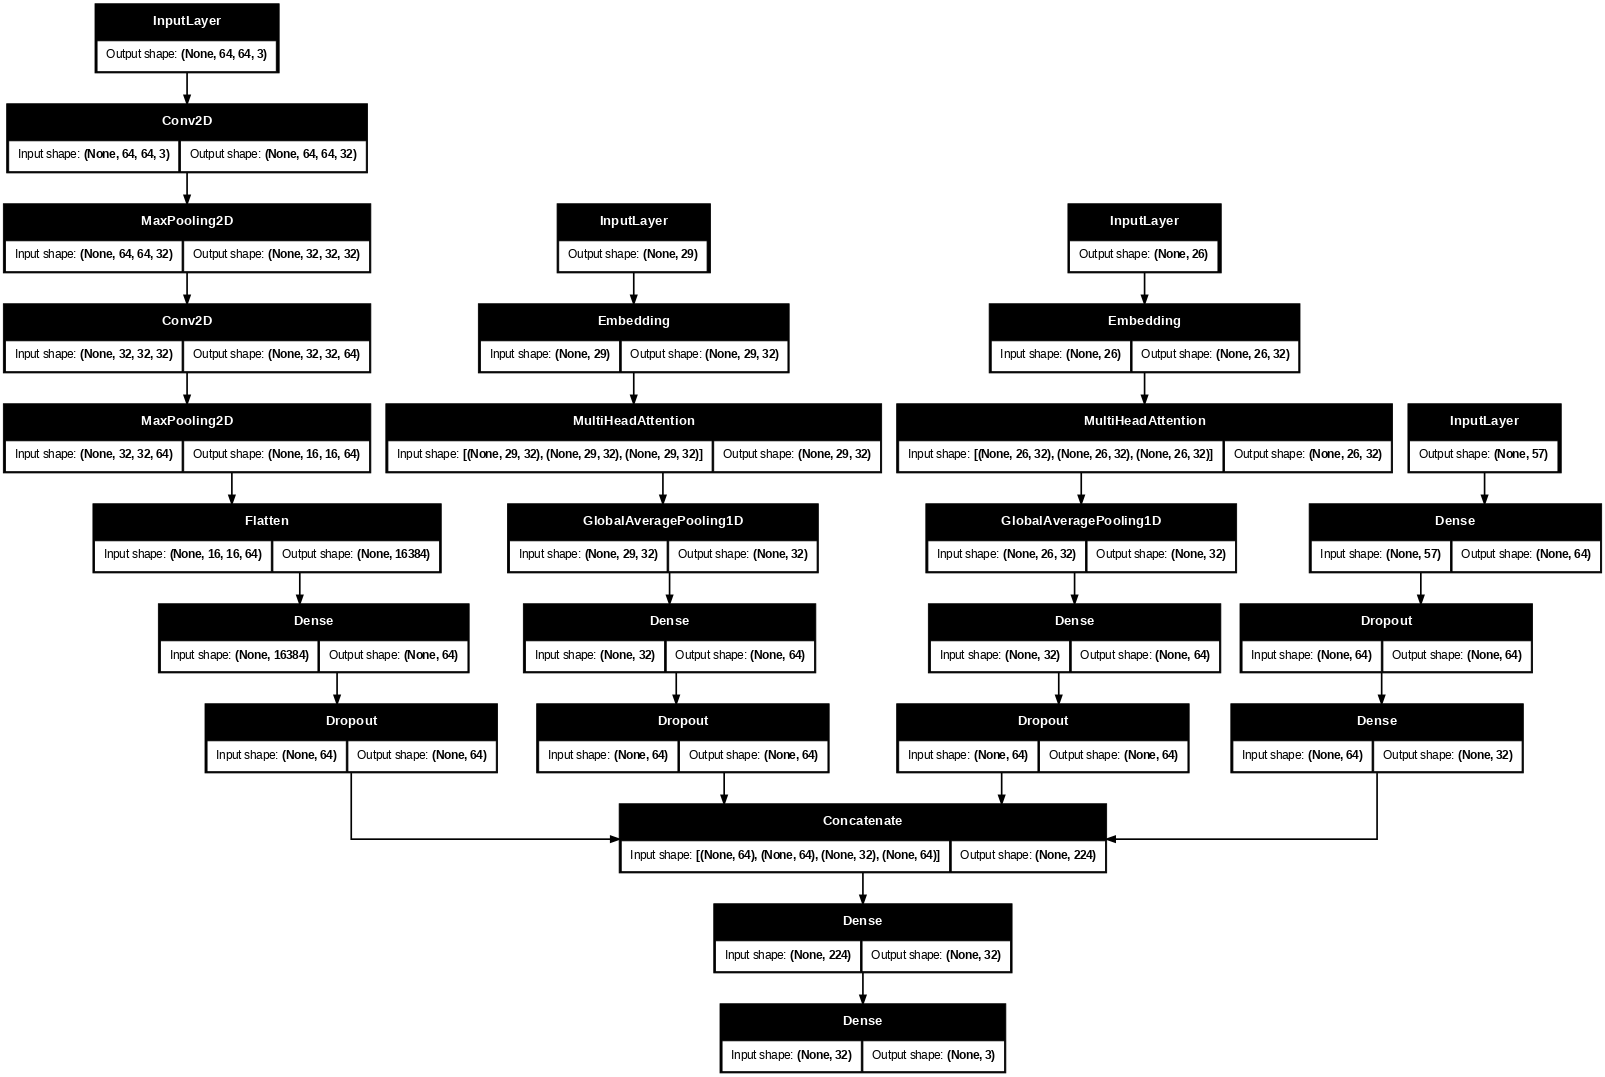

In [ ]:
#Compute 95th percentile lengths for each text
#column on filtered ChatGPT multiclass training data.
about_len_mha_cgm   = int(pd.Series(X_cg_train_about_cm_f).str.split().str.len().quantile(0.95))
founder_len_mha_cgm = int(pd.Series(X_cg_train_founder_cm_f).str.split().str.len().quantile(0.95))

#Define the same hyperparameters as the original
#ChatGPT multiclass MHA model.
VOCAB_MHA_CGM    = 10_001
EMBED_MHA_CGM    = 32
HEADS_MHA_CGM    = 2

#Get the number of structured columns.
n_struct_mha_cgm = X_cg_train_struct_cm_f.shape[1]

#Adapt separate MHA vectorizers for each text
#column on the filtered training data.
tv_about_mha_cgm = keras.layers.TextVectorization(
    max_tokens=10_000, output_mode="int", output_sequence_length=about_len_mha_cgm)
tv_about_mha_cgm.adapt(X_cg_train_about_cm_f)

tv_founder_mha_cgm = keras.layers.TextVectorization(
    max_tokens=10_000, output_mode="int", output_sequence_length=founder_len_mha_cgm)
tv_founder_mha_cgm.adapt(X_cg_train_founder_cm_f)

#Vectorize all filtered multiclass splits.
X_cg_train_about_mha_cgm   = tv_about_mha_cgm(X_cg_train_about_cm_f)
X_cg_val_about_mha_cgm     = tv_about_mha_cgm(X_cg_val_about_cm_f)
X_cg_test_about_mha_cgm    = tv_about_mha_cgm(X_cg_test_about_cm_f)

X_cg_train_founder_mha_cgm = tv_founder_mha_cgm(X_cg_train_founder_cm_f)
X_cg_val_founder_mha_cgm   = tv_founder_mha_cgm(X_cg_val_founder_cm_f)
X_cg_test_founder_mha_cgm  = tv_founder_mha_cgm(X_cg_test_founder_cm_f)

#About text branch with multi-head self-attention.
about_input_mha_cgm   = keras.Input(shape=(about_len_mha_cgm,),   name="about_input")
founder_input_mha_cgm = keras.Input(shape=(founder_len_mha_cgm,), name="founder_input")
struct_input_mha_cgm  = keras.Input(shape=(n_struct_mha_cgm,),    name="struct_input")

about_emb_mha_cgm  = layers.Embedding(VOCAB_MHA_CGM, EMBED_MHA_CGM,
                                       name="emb_about_mha_cgm")(about_input_mha_cgm)
attended_a_mha_cgm = layers.MultiHeadAttention(
    num_heads=HEADS_MHA_CGM, key_dim=EMBED_MHA_CGM // HEADS_MHA_CGM
)(about_emb_mha_cgm, about_emb_mha_cgm, about_emb_mha_cgm) #Q=K=V for self-attention.
x_a_mha_cgm = layers.GlobalAveragePooling1D()(attended_a_mha_cgm)
x_a_mha_cgm = layers.Dense(64, activation="relu")(x_a_mha_cgm)
x_a_mha_cgm = layers.Dropout(0.3)(x_a_mha_cgm)

#Founder background branch with multi-head self-attention.
founder_emb_mha_cgm  = layers.Embedding(VOCAB_MHA_CGM, EMBED_MHA_CGM,
                                         name="emb_founder_mha_cgm")(founder_input_mha_cgm)
attended_f_mha_cgm   = layers.MultiHeadAttention(
    num_heads=HEADS_MHA_CGM, key_dim=EMBED_MHA_CGM // HEADS_MHA_CGM
)(founder_emb_mha_cgm, founder_emb_mha_cgm, founder_emb_mha_cgm) #Q=K=V for self-attention.
x_f_mha_cgm = layers.GlobalAveragePooling1D()(attended_f_mha_cgm)
x_f_mha_cgm = layers.Dense(64, activation="relu")(x_f_mha_cgm)
x_f_mha_cgm = layers.Dropout(0.3)(x_f_mha_cgm)

#Structured branch.
x_s_mha_cgm = layers.Dense(64, activation="relu")(struct_input_mha_cgm)
x_s_mha_cgm = layers.Dropout(0.3)(x_s_mha_cgm)
x_s_mha_cgm = layers.Dense(32, activation="relu")(x_s_mha_cgm)

#Image (CNN) branch.
img_input_mha_cgm, x_img_mha_cgm = build_image_branch("logo_mha_cgm")

#Merge all four branches and output 3 classes.
merged_mha_cgm = layers.Concatenate()([x_a_mha_cgm, x_f_mha_cgm, x_s_mha_cgm, x_img_mha_cgm])
merged_mha_cgm = layers.Dense(32, activation="relu")(merged_mha_cgm)
output_mha_cgm = layers.Dense(3, activation="softmax")(merged_mha_cgm)

#Define the model blueprint and compile it.
mha_logo_model_cgm = keras.Model(
    inputs=[about_input_mha_cgm, founder_input_mha_cgm, struct_input_mha_cgm, img_input_mha_cgm],
    outputs=output_mha_cgm)
mha_logo_model_cgm.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

#Visualize the model architecture.
keras.utils.plot_model(mha_logo_model_cgm, show_shapes=True, dpi=60)

In [ ]:
#Fit the MHA model using filtered ChatGPT multiclass splits.
history_mha_logo_cgm = mha_logo_model_cgm.fit(
    x=[X_cg_train_about_mha_cgm.numpy(), X_cg_train_founder_mha_cgm.numpy(),
       X_cg_train_struct_cm_f, X_cg_train_logos],
    y=y_cg_train_cm_f,
    validation_data=(
        [X_cg_val_about_mha_cgm.numpy(), X_cg_val_founder_mha_cgm.numpy(),
         X_cg_val_struct_cm_f, X_cg_val_logos],
        y_cg_val_cm_f),
    epochs=20, batch_size=16, class_weight=class_weight_dict_cm_f,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)]
)

#Evaluate on the filtered test set.
test_loss_mha_cgm, test_acc_mha_cgm = mha_logo_model_cgm.evaluate(
    [X_cg_test_about_mha_cgm.numpy(), X_cg_test_founder_mha_cgm.numpy(),
     X_cg_test_struct_cm_f, X_cg_test_logos],
    y_cg_test_cm_f)
print(f"\nMHA + Logo CG (Multiclass) — Test Accuracy: {test_acc_mha_cgm:.4f} | Loss: {test_loss_mha_cgm:.4f}")

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.3265 - loss: 15.5973 - val_accuracy: 0.4769 - val_loss: 1.1727
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3261 - loss: 5.6072 - val_accuracy: 0.5334 - val_loss: 1.2142
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3945 - loss: 3.4670 - val_accuracy: 0.5141 - val_loss: 1.0854
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4347 - loss: 2.2976 - val_accuracy: 0.2738 - val_loss: 2.1514
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4728 - loss: 2.2599 - val_accuracy: 0.2776 - val_loss: 1.4498
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5285 - loss: 1.2054

MHA + Logo CG (Multiclass) — Test Accuracy: 0.5285 | Loss: 1.2054


##Final Model Results

In this section, I summarize the results from all models, so we can compare across models more easily. For this purpose, the code concatenates and organizes the results from all the models and creates a helper function to help draw out the visuals. The Goal here is to find the best model for binary and multiclass respectively and use those model in the next phase of the project.

In [ ]:
results_all_logo = pd.DataFrame([
    # Original Binary
    {"Dataset":"Original","Mode":"Binary","Architecture":"Simple",       "Test Accuracy":round(test_acc_slb,4),     "Test Loss":round(test_loss_slb,4)},
    {"Dataset":"Original","Mode":"Binary","Architecture":"Embedding",    "Test Accuracy":round(test_acc_elb,4),     "Test Loss":round(test_loss_elb,4)},
    {"Dataset":"Original","Mode":"Binary","Architecture":"QKV Attention","Test Accuracy":round(test_acc_qkv_lb,4),  "Test Loss":round(test_loss_qkv_lb,4)},
    {"Dataset":"Original","Mode":"Binary","Architecture":"MHA",          "Test Accuracy":round(test_acc_mha_lb,4),  "Test Loss":round(test_loss_mha_lb,4)},
    # Original Multiclass
    {"Dataset":"Original","Mode":"Multiclass","Architecture":"Simple",       "Test Accuracy":round(test_acc_slm,4),    "Test Loss":round(test_loss_slm,4)},
    {"Dataset":"Original","Mode":"Multiclass","Architecture":"Embedding",    "Test Accuracy":round(test_acc_elm,4),    "Test Loss":round(test_loss_elm,4)},
    {"Dataset":"Original","Mode":"Multiclass","Architecture":"QKV Attention","Test Accuracy":round(test_acc_qkv_lm,4), "Test Loss":round(test_loss_qkv_lm,4)},
    {"Dataset":"Original","Mode":"Multiclass","Architecture":"MHA",          "Test Accuracy":round(test_acc_mha_lm,4), "Test Loss":round(test_loss_mha_lm,4)},
    # ChatGPT Binary
    {"Dataset":"ChatGPT","Mode":"Binary","Architecture":"Simple",       "Test Accuracy":round(test_acc_s_cgb,4),    "Test Loss":round(test_loss_s_cgb,4)},
    {"Dataset":"ChatGPT","Mode":"Binary","Architecture":"Embedding",    "Test Accuracy":round(test_acc_e_cgb,4),    "Test Loss":round(test_loss_e_cgb,4)},
    {"Dataset":"ChatGPT","Mode":"Binary","Architecture":"QKV Attention","Test Accuracy":round(test_acc_qkv_cgb,4),  "Test Loss":round(test_loss_qkv_cgb,4)},
    {"Dataset":"ChatGPT","Mode":"Binary","Architecture":"MHA",          "Test Accuracy":round(test_acc_mha_cgb,4),  "Test Loss":round(test_loss_mha_cgb,4)},
    # ChatGPT Multiclass
    {"Dataset":"ChatGPT","Mode":"Multiclass","Architecture":"Simple",       "Test Accuracy":round(test_acc_s_cgm,4),   "Test Loss":round(test_loss_s_cgm,4)},
    {"Dataset":"ChatGPT","Mode":"Multiclass","Architecture":"Embedding",    "Test Accuracy":round(test_acc_e_cgm,4),   "Test Loss":round(test_loss_e_cgm,4)},
    {"Dataset":"ChatGPT","Mode":"Multiclass","Architecture":"QKV Attention","Test Accuracy":round(test_acc_qkv_cgm,4), "Test Loss":round(test_loss_qkv_cgm,4)},
    {"Dataset":"ChatGPT","Mode":"Multiclass","Architecture":"MHA",          "Test Accuracy":round(test_acc_mha_cgm,4), "Test Loss":round(test_loss_mha_cgm,4)},
]).set_index(["Dataset","Mode","Architecture"])

# Append RNN results
for row in results_rnn_logo_bin:
    results_all_logo = pd.concat([results_all_logo,
        pd.DataFrame([{"Dataset":"Original","Mode":"Binary","Architecture":row["Model"],
                       "Test Accuracy":row["Test Accuracy"],"Test Loss":row["Test Loss"]}
                     ]).set_index(["Dataset","Mode","Architecture"])])
for row in results_rnn_logo_m:
    results_all_logo = pd.concat([results_all_logo,
        pd.DataFrame([{"Dataset":"Original","Mode":"Multiclass","Architecture":row["Model"],
                       "Test Accuracy":row["Test Accuracy"],"Test Loss":row["Test Loss"]}
                     ]).set_index(["Dataset","Mode","Architecture"])])
for row in results_rnn_logo_cgb:
    results_all_logo = pd.concat([results_all_logo,
        pd.DataFrame([{"Dataset":"ChatGPT","Mode":"Binary","Architecture":row["Model"],
                       "Test Accuracy":row["Test Accuracy"],"Test Loss":row["Test Loss"]}
                     ]).set_index(["Dataset","Mode","Architecture"])])
for row in results_rnn_logo_cgm:
    results_all_logo = pd.concat([results_all_logo,
        pd.DataFrame([{"Dataset":"ChatGPT","Mode":"Multiclass","Architecture":row["Model"],
                       "Test Accuracy":row["Test Accuracy"],"Test Loss":row["Test Loss"]}
                     ]).set_index(["Dataset","Mode","Architecture"])])

print("\n\n===== ALL LOGO CNN MODEL RESULTS =====")
print(results_all_logo.sort_index().to_string())



===== ALL LOGO CNN MODEL RESULTS =====
                                   Test Accuracy  Test Loss
Dataset  Mode       Architecture                           
ChatGPT  Binary     Bi-GRU                0.5725     0.9651
                    Bi-LSTM               0.6114     0.8835
                    Bi-SimpleRNN          0.5920     1.1390
                    Embedding             0.4404     2.0669
                    GRU                   0.4404     3.4214
                    LSTM                  0.4417     1.4914
                    MHA                   0.6749     0.6935
                    QKV Attention         0.5596     4.3324
                    Simple                0.6438     0.6130
                    SimpleRNN             0.6244     0.8202
         Multiclass Bi-GRU                0.4624     1.0144
                    Bi-LSTM               0.5427     1.2490
                    Bi-SimpleRNN          0.4521     2.6849
                    Embedding             0.4870     0.9936

In [ ]:
#Build a master results table that covers every
#model trained in this notebook — both the
#text-only versions (no image branch) and the
#full versions that add a Logo CNN branch.
#This gives us four comparison groups:
#  1. Original dataset, no logo
#  2. ChatGPT dataset, no logo
#  3. Original dataset, with logo CNN
#  4. ChatGPT dataset, with logo CNN



#---- ORIGINAL DATASET — BINARY (No Logo) --------------------------------
#Note: the original binary section reused the variable names
#test_loss / test_acc for the RNN loop, QKV, and MHA models,
#so those values were overwritten by the time the notebook
#finished. Only the Simple model stored a unique variable
#(test_accuracy). The RNN results were saved in 'results'
#and are retrieved below.
rows_orig_bin_nl = []

#Simple model — stored as test_accuracy (unique name).
rows_orig_bin_nl.append({"Architecture": "Simple",
                          "Test Accuracy": round(test_accuracy, 4),
                          "Test Loss":     round(test_loss,     4)})

#RNN models — stored in the 'results' list from the
#build_rnn_model() loop. Each entry has 'Model',
#'Test Accuracy', and 'Test Loss' keys.
for row in results:
    rows_orig_bin_nl.append({"Architecture": row["Model"],
                              "Test Accuracy": row["Test Accuracy"],
                              "Test Loss":     row["Test Loss"]})

#QKV and MHA shared the name test_loss / test_acc with the
#RNN loop so their final values reflect only whichever
#ran last. We mark them as unavailable to be transparent.
rows_orig_bin_nl.append({"Architecture": "QKV Attention",
                          "Test Accuracy": float('nan'),
                          "Test Loss":     float('nan')})
rows_orig_bin_nl.append({"Architecture": "MHA",
                          "Test Accuracy": float('nan'),
                          "Test Loss":     float('nan')})

#---- ORIGINAL DATASET — MULTICLASS (No Logo) ----------------------------
#These models each stored their own uniquely named variables.
rows_orig_mul_nl = [
    {"Architecture": "Simple",        "Test Accuracy": round(test_acc_simple_m, 4), "Test Loss": round(test_loss_simple_m, 4)},
    {"Architecture": "Embedding",     "Test Accuracy": round(test_acc_emb_m,    4), "Test Loss": round(test_loss_emb_m,    4)},
    {"Architecture": "QKV Attention", "Test Accuracy": round(test_acc_qkv_m,    4), "Test Loss": round(test_loss_qkv_m,    4)},
    {"Architecture": "MHA",           "Test Accuracy": round(test_acc_mha_m,    4), "Test Loss": round(test_loss_mha_m,    4)},
]
#Append the RNN loop results stored in results_m.
for row in results_m:
    rows_orig_mul_nl.append({"Architecture": row["Model"],
                              "Test Accuracy": row["Test Accuracy"],
                              "Test Loss":     row["Test Loss"]})

#---- CHATGPT DATASET — BINARY (No Logo) ---------------------------------
rows_cg_bin_nl = [
    {"Architecture": "Simple",        "Test Accuracy": round(test_acc_cg,      4), "Test Loss": round(test_loss_cg,      4)},
    {"Architecture": "Embedding",     "Test Accuracy": round(test_acc_emb_cg,  4), "Test Loss": round(test_loss_emb_cg,  4)},
    {"Architecture": "QKV Attention", "Test Accuracy": round(test_acc_qkv_cg,  4), "Test Loss": round(test_loss_qkv_cg,  4)},
    {"Architecture": "MHA",           "Test Accuracy": round(test_acc_mha_cg,  4), "Test Loss": round(test_loss_mha_cg,  4)},
]
#Append the RNN loop results stored in results_cg.
for row in results_cg:
    rows_cg_bin_nl.append({"Architecture": row["Model"],
                            "Test Accuracy": row["Test Accuracy"],
                            "Test Loss":     row["Test Loss"]})

#---- CHATGPT DATASET — MULTICLASS (No Logo) -----------------------------
rows_cg_mul_nl = [
    {"Architecture": "Simple",        "Test Accuracy": round(test_acc_s_cm,    4), "Test Loss": round(test_loss_s_cm,    4)},
    {"Architecture": "Embedding",     "Test Accuracy": round(test_acc_emb_cm,  4), "Test Loss": round(test_loss_emb_cm,  4)},
    {"Architecture": "QKV Attention", "Test Accuracy": round(test_acc_qkv_cm,  4), "Test Loss": round(test_loss_qkv_cm,  4)},
    {"Architecture": "MHA",           "Test Accuracy": round(test_acc_mha_cm,  4), "Test Loss": round(test_loss_mha_cm,  4)},
]
#Append the RNN loop results stored in results_cm.
for row in results_cm:
    rows_cg_mul_nl.append({"Architecture": row["Model"],
                            "Test Accuracy": row["Test Accuracy"],
                            "Test Loss":     row["Test Loss"]})

#---- LOGO MODEL RESULTS — pulled from results_all_logo -----------------
#results_all_logo already has all four logo groups.
#Reset the MultiIndex so we can filter with normal columns.
df_logo = results_all_logo.reset_index()

orig_bin_l = df_logo[(df_logo['Dataset']=='Original') & (df_logo['Mode']=='Binary')].copy()
orig_mul_l = df_logo[(df_logo['Dataset']=='Original') & (df_logo['Mode']=='Multiclass')].copy()
cg_bin_l   = df_logo[(df_logo['Dataset']=='ChatGPT')  & (df_logo['Mode']=='Binary')].copy()
cg_mul_l   = df_logo[(df_logo['Dataset']=='ChatGPT')  & (df_logo['Mode']=='Multiclass')].copy()

#Convert each logo sub-table to the same list-of-dicts
#format as the no-logo rows so everything stays consistent.
def df_to_rows(df):
    return [{"Architecture": r['Architecture'],
             "Test Accuracy": r['Test Accuracy'],
             "Test Loss":     r['Test Loss']}
            for _, r in df.iterrows()]

rows_orig_bin_l = df_to_rows(orig_bin_l)
rows_orig_mul_l = df_to_rows(orig_mul_l)
rows_cg_bin_l   = df_to_rows(cg_bin_l)
rows_cg_mul_l   = df_to_rows(cg_mul_l)

print('Master results tables built successfully.')
print(f'  Orig Binary  no-logo : {len(rows_orig_bin_nl)} models')
print(f'  Orig Multi   no-logo : {len(rows_orig_mul_nl)} models')
print(f'  CG Binary    no-logo : {len(rows_cg_bin_nl)} models')
print(f'  CG Multi     no-logo : {len(rows_cg_mul_nl)} models')
print(f'  Orig Binary  + logo  : {len(rows_orig_bin_l)} models')
print(f'  Orig Multi   + logo  : {len(rows_orig_mul_l)} models')
print(f'  CG Binary    + logo  : {len(rows_cg_bin_l)} models')
print(f'  CG Multi     + logo  : {len(rows_cg_mul_l)} models')

Master results tables built successfully.
  Orig Binary  no-logo : 9 models
  Orig Multi   no-logo : 10 models
  CG Binary    no-logo : 10 models
  CG Multi     no-logo : 10 models
  Orig Binary  + logo  : 10 models
  Orig Multi   + logo  : 10 models
  CG Binary    + logo  : 10 models
  CG Multi     + logo  : 10 models


In [ ]:
#Reusable helper that draws one bar-chart panel.
#Each architecture gets two bars side by side:
#one for Test Accuracy and one for Test Loss.
#A dashed red line marks the dummy-classifier
#baseline so we can instantly see which models
#beat majority-class guessing.
#NaN values (missing data) are silently skipped.
def draw_panel(ax, rows, dummy_acc, title, palette=('#4C72B0', '#DD8452')):

    #Filter out any rows where accuracy is NaN
    #(original binary QKV and MHA whose variable
    #names were overwritten during training).
    rows = [r for r in rows if not (isinstance(r['Test Accuracy'], float)
                                    and np.isnan(r['Test Accuracy']))]

    #Pull architecture names and metric values
    #into plain Python lists.
    archs  = [r['Architecture']  for r in rows]
    accs   = [r['Test Accuracy'] for r in rows]
    losses = [r['Test Loss']     for r in rows]
    n      = len(archs)

    #Set up evenly spaced x-positions and fix
    #the width of each individual bar.
    x     = np.arange(n)
    width = 0.35

    #Draw accuracy bars slightly left of center
    #and loss bars slightly right so the two
    #metrics sit next to each other per model.
    bars_acc  = ax.bar(x - width/2, accs,   width, label='Test Accuracy',
                       color=palette[0], edgecolor='white', linewidth=0.6, zorder=3)
    bars_loss = ax.bar(x + width/2, losses, width, label='Test Loss',
                       color=palette[1], edgecolor='white', linewidth=0.6, zorder=3)

    #Draw the dummy-classifier horizontal reference
    #line. This is our 'did the model actually learn
    #anything beyond majority-class guessing?' check.
    ax.axhline(dummy_acc, color='crimson', linewidth=1.8,
               linestyle='--', zorder=4,
               label=f'Dummy Classifier ({dummy_acc:.1%})')

    #Add a numeric label above each accuracy bar
    #so the exact value is readable at a glance.
    for bar in bars_acc:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f'{h:.3f}', ha='center', va='bottom',
                fontsize=7, color=palette[0])

    #Do the same for each loss bar.
    for bar in bars_loss:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f'{h:.3f}', ha='center', va='bottom',
                fontsize=7, color=palette[1])

    #Label x-axis ticks with architecture names,
    #rotated so they do not overlap each other.
    ax.set_xticks(x)
    ax.set_xticklabels(archs, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Score', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    #Add 22% headroom above the tallest bar so
    #numeric labels are never clipped.
    ax.set_ylim(0, max(max(accs), max(losses)) * 1.22)

    #Light horizontal gridlines make values
    #easier to read without cluttering the chart.
    ax.yaxis.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, loc='upper left', framealpha=0.85)

Based on the results below, the best models for the Wayback machine dataset for binary were Simple, LSTM, and Simple RNN. Again, these were the same as the dummy classifier, indicating that these do not provide a substantial improvement. From the multiclass side, the best model was teh Biderectional GRU, barely beating out the majority classifier(50.92%).

###Wayback Machine Dataset

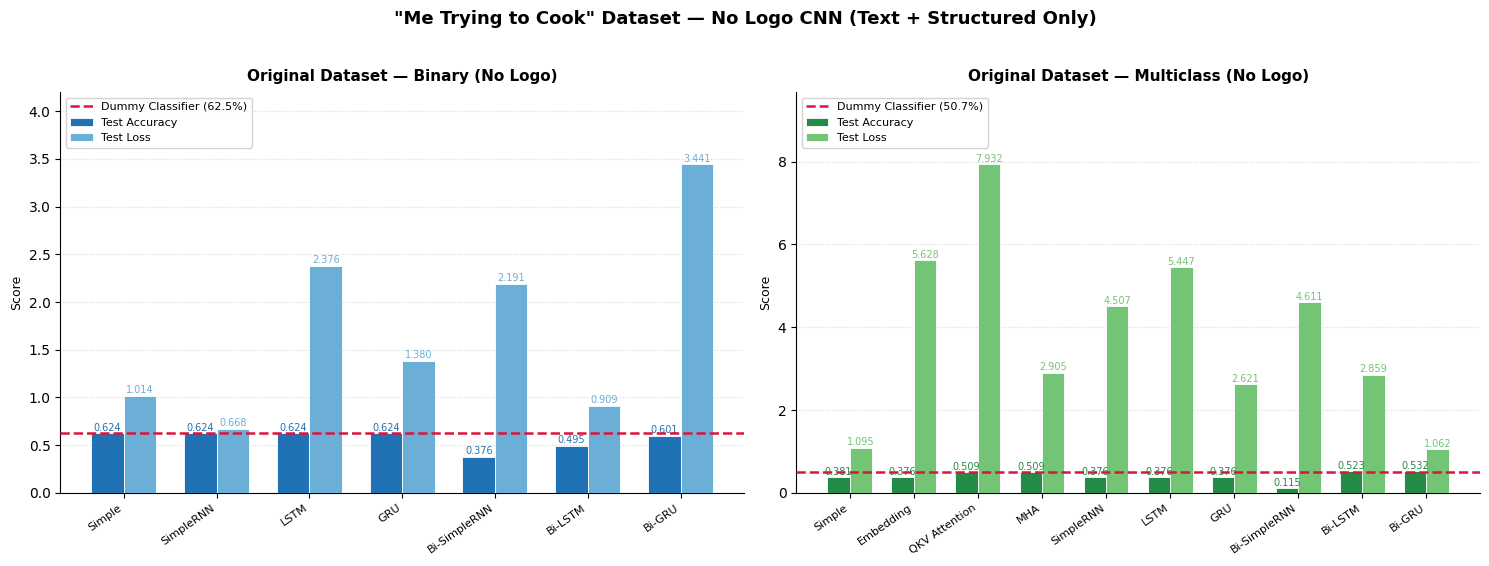

Figure 1 saved → fig1_original_no_logo.png


In [ ]:
#Figure 1: 'Wayback Machine' dataset — text
#and structured features only (no logo CNN).
#Binary classification is on the left panel
#and multiclass is on the right so we can
#compare task difficulty in one glance.
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
fig1.suptitle(
    '"Wayback Machine" Dataset — No Logo CNN (Text + Structured Only)',
    fontsize=13, fontweight='bold', y=1.02
)

#Binary panel. majority_class_proportion is the
#accuracy of always predicting the most common
#class (success vs. failure).
draw_panel(ax1, rows_orig_bin_nl,
           dummy_acc=float(majority_class_proportion),
           title='Original Dataset — Binary (No Logo)',
           palette=('#2171B5', '#6BAED6'))

#Multiclass panel. majority_class_acc_m is the
#baseline for always predicting 'closed', the
#most common of the three outcome classes.
draw_panel(ax2, rows_orig_mul_nl,
           dummy_acc=float(majority_class_acc_m),
           title='Original Dataset — Multiclass (No Logo)',
           palette=('#238B45', '#74C476'))

plt.tight_layout()
plt.savefig('fig1_original_no_logo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved → fig1_original_no_logo.png')

###Chatgpt Dataset

In the Chatgpt Dataset, the best model were QKV Attention and MultiHead Attention for binary and Multi-class respectively. Key thing to note here is that these models beat out their dummy classifiers by a higher margin than the models in the Wayback Machine Dataset.

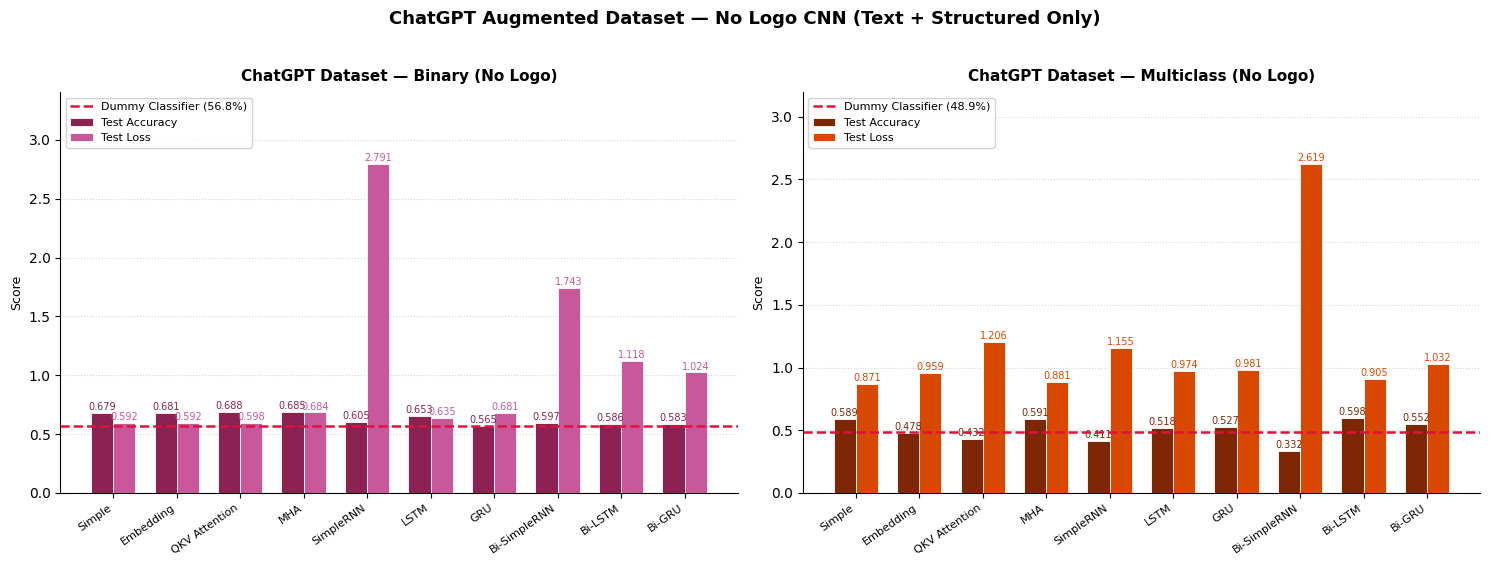

Figure 2 saved → fig2_chatgpt_no_logo.png


In [ ]:
#Figure 2: ChatGPT-augmented dataset — text and
#structured features only (no logo CNN). Pink and
#red palette keeps it visually distinct from the
#original-dataset charts.
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 5.5))
fig2.suptitle(
    'ChatGPT Augmented Dataset — No Logo CNN (Text + Structured Only)',
    fontsize=13, fontweight='bold', y=1.02
)

#Binary panel. majority_class_proportion_cg is
#the dummy baseline for the ChatGPT binary task.
draw_panel(ax3, rows_cg_bin_nl,
           dummy_acc=float(majority_class_proportion_cg),
           title='ChatGPT Dataset — Binary (No Logo)',
           palette=('#8B2252', '#C9589A'))

#Multiclass panel. majority_class_acc_cm is the
#dummy baseline for the ChatGPT multiclass task.
draw_panel(ax4, rows_cg_mul_nl,
           dummy_acc=float(majority_class_acc_cm),
           title='ChatGPT Dataset — Multiclass (No Logo)',
           palette=('#7F2704', '#D94801'))

plt.tight_layout()
plt.savefig('fig2_chatgpt_no_logo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved → fig2_chatgpt_no_logo.png')

###Logo: Wayback Machine Dataset

As for the Wayback Machine dataset with logos, the best model was Bi-Simple RNN, just barely beating the dummy classifier of 62.5%. As for multiclass, all the models performed below the dummy classifier benchmark.

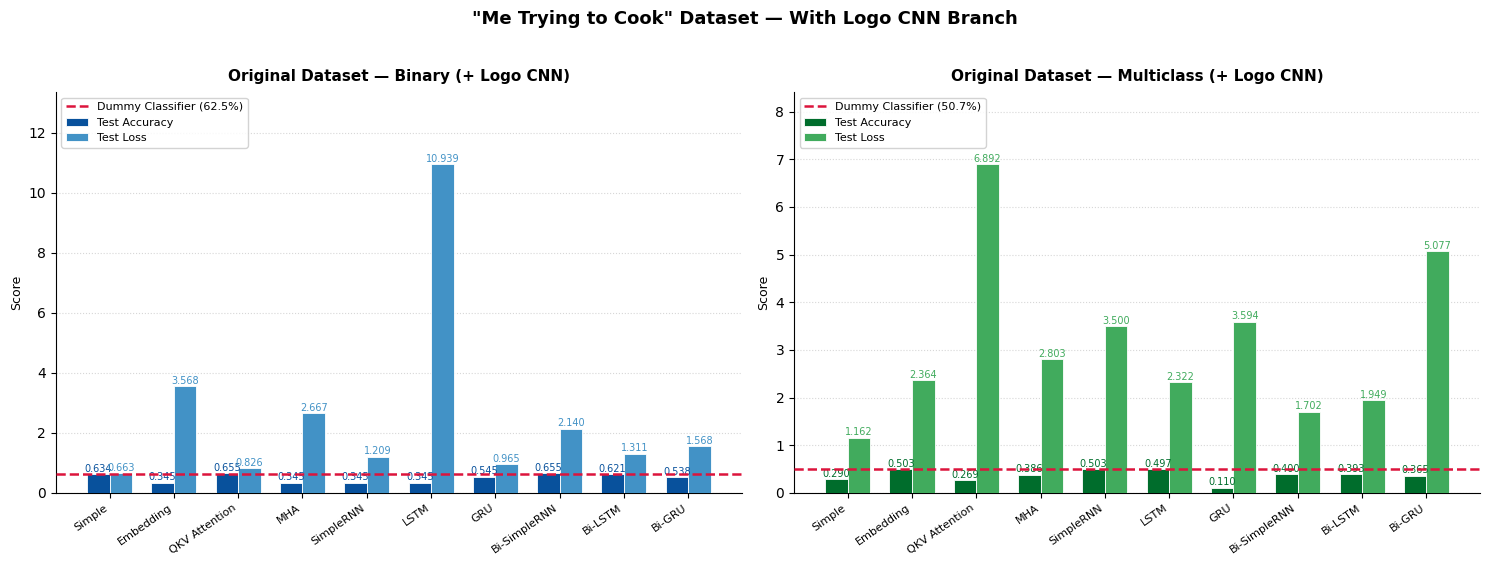

Figure 3 saved → fig3_original_with_logo.png


In [ ]:
#Figure 3: 'Wayback Machine' dataset — full
#architecture including the Logo CNN branch.
#These are the same model families as Figure 1
#but with the extra image input added, so a
#direct comparison between the two figures shows
#whether adding logo images helped or hurt.
fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(15, 5.5))
fig3.suptitle(
    '"Wayback Machine" Dataset — With Logo CNN Branch',
    fontsize=13, fontweight='bold', y=1.02
)

#Binary panel with logo models.
draw_panel(ax5, rows_orig_bin_l,
           dummy_acc=float(majority_class_proportion),
           title='Original Dataset — Binary (+ Logo CNN)',
           palette=('#08519C', '#4292C6'))

#Multiclass panel with logo models.
draw_panel(ax6, rows_orig_mul_l,
           dummy_acc=float(majority_class_acc_m),
           title='Original Dataset — Multiclass (+ Logo CNN)',
           palette=('#006D2C', '#41AB5D'))

plt.tight_layout()
plt.savefig('fig3_original_with_logo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved → fig3_original_with_logo.png')

###Logo Chatgpt Dataset

As for the Chatgpt Dataset with Logos, the best performing models were MultiHead Attention and QKV Attention for binary and multi-class respectively, again with higher margins to their classifirs as compared to the wayback machine dataset.

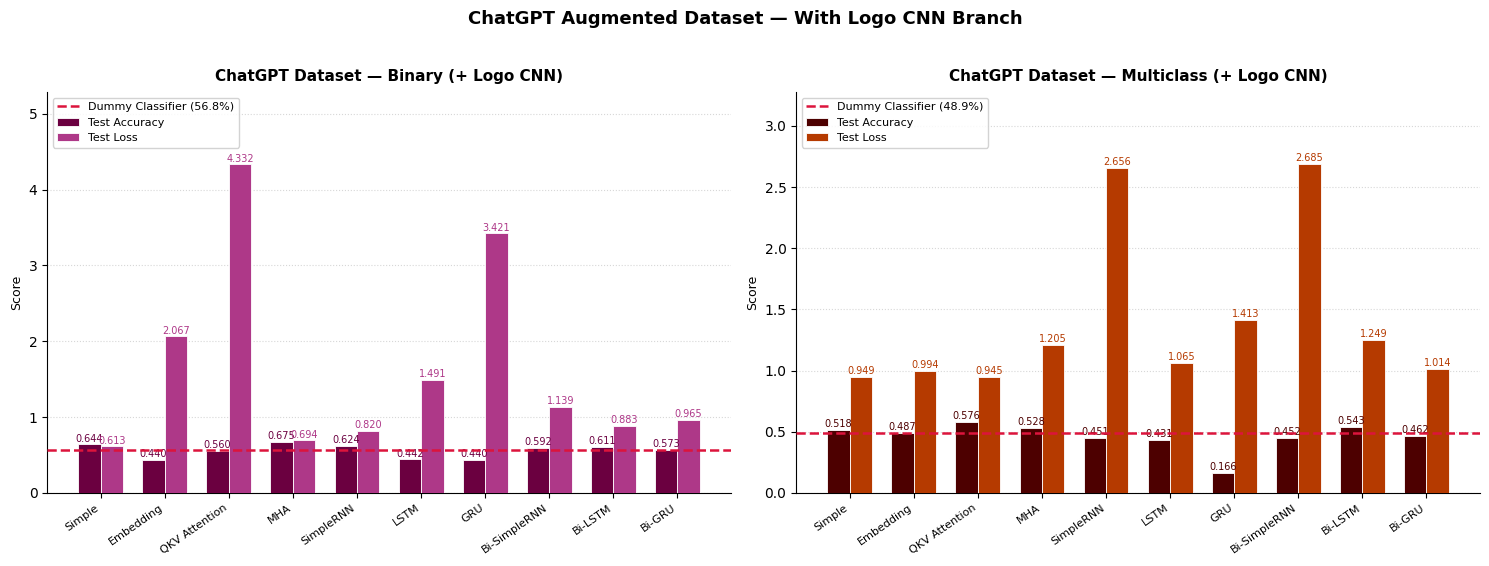

Figure 4 saved → fig4_chatgpt_with_logo.png


In [ ]:
#Figure 4: ChatGPT-augmented dataset — full
#architecture including the Logo CNN branch.
#Compare this directly with Figure 2 to see
#whether logo images improved performance on
#the augmented dataset.
fig4, (ax7, ax8) = plt.subplots(1, 2, figsize=(15, 5.5))
fig4.suptitle(
    'ChatGPT Augmented Dataset — With Logo CNN Branch',
    fontsize=13, fontweight='bold', y=1.02
)

#Binary panel with logo models.
draw_panel(ax7, rows_cg_bin_l,
           dummy_acc=float(majority_class_proportion_cg),
           title='ChatGPT Dataset — Binary (+ Logo CNN)',
           palette=('#6B0040', '#AE3888'))

#Multiclass panel with logo models.
draw_panel(ax8, rows_cg_mul_l,
           dummy_acc=float(majority_class_acc_cm),
           title='ChatGPT Dataset — Multiclass (+ Logo CNN)',
           palette=('#4D0000', '#B53A00'))

plt.tight_layout()
plt.savefig('fig4_chatgpt_with_logo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved → fig4_chatgpt_with_logo.png')

In [ ]:
#Print a summary table for each of the four
#comparison groups, showing every model's
#test accuracy next to the dummy baseline and
#the delta (gain or loss) vs that baseline.

def print_summary(rows, dummy_acc, label):
    print(f'\n{"-"*60}')
    print(f'  {label}')
    print(f'  Dummy Classifier Baseline: {dummy_acc:.4f} ({dummy_acc:.1%})')
    print(f'{"-"*60}')
    print(f'  {"Architecture":<20} {"Accuracy":>10} {"Loss":>10} {"Delta":>10}')
    print(f'  {"-"*52}')
    for r in rows:
        acc  = r['Test Accuracy']
        loss = r['Test Loss']
        #Skip rows with missing data.
        if isinstance(acc, float) and np.isnan(acc):
            print(f'  {r["Architecture"]:<20} {"N/A":>10} {"N/A":>10} {"N/A":>10}')
        else:
            delta = acc - dummy_acc
            print(f'  {r["Architecture"]:<20} {acc:>10.4f} {loss:>10.4f} {delta:>+10.4f}')

print_summary(rows_orig_bin_nl, float(majority_class_proportion),
              '"Me Trying to Cook" — Binary (No Logo)')
print_summary(rows_orig_mul_nl, float(majority_class_acc_m),
              '"Me Trying to Cook" — Multiclass (No Logo)')
print_summary(rows_cg_bin_nl,   float(majority_class_proportion_cg),
              'ChatGPT — Binary (No Logo)')
print_summary(rows_cg_mul_nl,   float(majority_class_acc_cm),
              'ChatGPT — Multiclass (No Logo)')
print_summary(rows_orig_bin_l,  float(majority_class_proportion),
              '"Me Trying to Cook" — Binary (+ Logo CNN)')
print_summary(rows_orig_mul_l,  float(majority_class_acc_m),
              '"Me Trying to Cook" — Multiclass (+ Logo CNN)')
print_summary(rows_cg_bin_l,    float(majority_class_proportion_cg),
              'ChatGPT — Binary (+ Logo CNN)')
print_summary(rows_cg_mul_l,    float(majority_class_acc_cm),
              'ChatGPT — Multiclass (+ Logo CNN)')


------------------------------------------------------------
  "Me Trying to Cook" — Binary (No Logo)
  Dummy Classifier Baseline: 0.6254 (62.5%)
------------------------------------------------------------
  Architecture           Accuracy       Loss      Delta
  ----------------------------------------------------
  Simple                   0.6239     1.0144    -0.0015
  SimpleRNN                0.6239     0.6682    -0.0015
  LSTM                     0.6239     2.3759    -0.0015
  GRU                      0.6239     1.3797    -0.0015
  Bi-SimpleRNN             0.3761     2.1909    -0.2493
  Bi-LSTM                  0.4954     0.9089    -0.1300
  Bi-GRU                   0.6009     3.4411    -0.0245
  QKV Attention               N/A        N/A        N/A
  MHA                         N/A        N/A        N/A

------------------------------------------------------------
  "Me Trying to Cook" — Multiclass (No Logo)
  Dummy Classifier Baseline: 0.5073 (50.7%)
--------------------------

In [ ]:
#Extract the single best-performing model from
#each of the four figure groups. We pick the
#model with the highest Test Accuracy in each
#group, skipping any NaN rows (original binary
#QKV and MHA whose variables were overwritten).

def get_best(rows, group_label):
    #Filter out rows with missing accuracy data.
    valid = [r for r in rows
             if not (isinstance(r['Test Accuracy'], float)
                     and np.isnan(r['Test Accuracy']))]

    #Find the row with the maximum Test Accuracy.
    best = max(valid, key=lambda r: r['Test Accuracy'])

    #Return a dict that also carries the group
    #label so we can use it as a chart x-tick.
    return {
        'Group':        group_label,
        'Architecture': best['Architecture'],
        'Test Accuracy': best['Test Accuracy'],
        'Test Loss':     best['Test Loss'],
    }

#One winner per figure group.
champion_orig_bin_nl = get_best(
    rows_orig_bin_nl,
    'Orig\nNo Logo\nBinary'
)
champion_cg_bin_nl   = get_best(
    rows_cg_bin_nl,
    'ChatGPT\nNo Logo\nBinary'
)
champion_orig_bin_l  = get_best(
    rows_orig_bin_l,
    'Orig\n+ Logo\nBinary'
)
champion_cg_bin_l    = get_best(
    rows_cg_bin_l,
    'ChatGPT\n+ Logo\nBinary'
)
champion_orig_mul_nl = get_best(
    rows_orig_mul_nl,
    'Orig\nNo Logo\nMulticlass'
)
champion_cg_mul_nl   = get_best(
    rows_cg_mul_nl,
    'ChatGPT\nNo Logo\nMulticlass'
)
champion_orig_mul_l  = get_best(
    rows_orig_mul_l,
    'Orig\n+ Logo\nMulticlass'
)
champion_cg_mul_l    = get_best(
    rows_cg_mul_l,
    'ChatGPT\n+ Logo\nMulticlass'
)

#Print a quick preview so we can confirm the
#correct winner was selected in each group.
print('Best model selected from each group:')
print(f'{"Group":<28} {"Architecture":<20} {"Accuracy":>10} {"Loss":>10}')
print('-' * 72)
for champ in [
    champion_orig_bin_nl, champion_cg_bin_nl,
    champion_orig_bin_l,  champion_cg_bin_l,
    champion_orig_mul_nl, champion_cg_mul_nl,
    champion_orig_mul_l,  champion_cg_mul_l,
]:
    label = champ['Group'].replace('\n', ' ')
    print(f'{label:<28} {champ["Architecture"]:<20}'
          f' {champ["Test Accuracy"]:>10.4f}'
          f' {champ["Test Loss"]:>10.4f}')

Best model selected from each group:
Group                        Architecture           Accuracy       Loss
------------------------------------------------------------------------
Orig No Logo Binary          Simple                   0.6239     1.0144
ChatGPT No Logo Binary       QKV Attention            0.6875     0.5979
Orig + Logo Binary           QKV Attention            0.6552     0.8264
ChatGPT + Logo Binary        MHA                      0.6749     0.6935
Orig No Logo Multiclass      Bi-GRU                   0.5321     1.0624
ChatGPT No Logo Multiclass   Bi-LSTM                  0.5981     0.9055
Orig + Logo Multiclass       Embedding                0.5034     2.3637
ChatGPT + Logo Multiclass    QKV Attention            0.5764     0.9451


###Best Model Graph Comparisons

Among these best models, the QKV Attention Chatgpt Dataset with no Logos was the best for Binary. As for multiclass, the best one was Chatgpt no Logo dataset with Bi-Lstm. Both of these models will be used in the next step where we would apply cross validation and test out different textual embeddings.

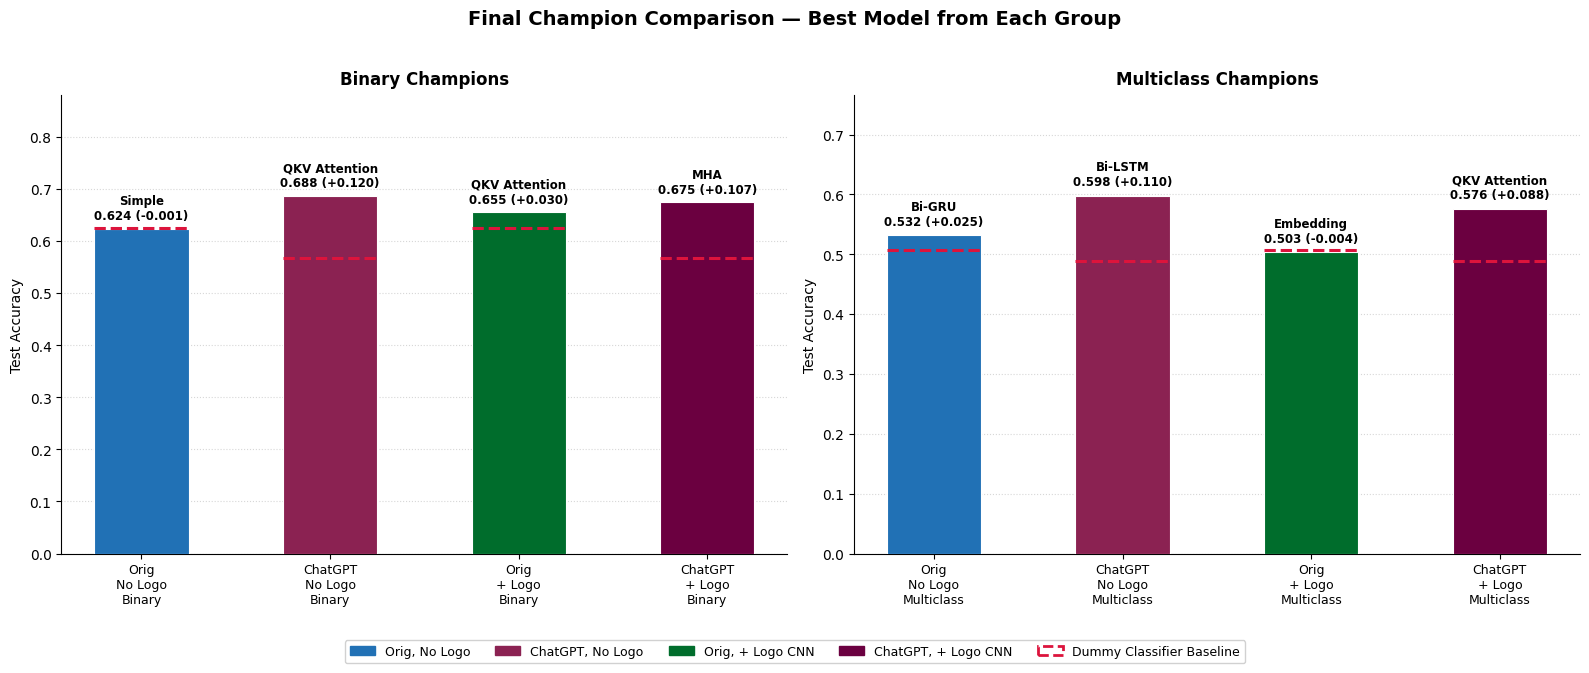

Figure 5 saved → fig5_champion_comparison.png


In [ ]:
#Figure 5: the grand champion comparison.
#We split it into two side-by-side panels:
#  Left  — Binary champions (one per figure group)
#  Right — Multiclass champions (one per figure group)
#Each bar is labelled with its winning architecture
#and a per-group dummy-classifier segment shows
#exactly how much headroom each winner had over
#majority-class guessing.

#Gather the four binary champions and their
#respective dummy baselines into parallel lists.
bin_champs  = [champion_orig_bin_nl, champion_cg_bin_nl,
               champion_orig_bin_l,  champion_cg_bin_l]
bin_dummies = [float(majority_class_proportion),
               float(majority_class_proportion_cg),
               float(majority_class_proportion),
               float(majority_class_proportion_cg)]

#Gather the four multiclass champions and their
#respective dummy baselines.
mul_champs  = [champion_orig_mul_nl, champion_cg_mul_nl,
               champion_orig_mul_l,  champion_cg_mul_l]
mul_dummies = [float(majority_class_acc_m),
               float(majority_class_acc_cm),
               float(majority_class_acc_m),
               float(majority_class_acc_cm)]

#Color each bar by dataset + logo combination
#so the four groups are immediately distinct.
#Same color scheme is reused in both panels
#so the legend reads across both at once.
group_colors = ['#2171B5',   # Orig, No Logo
                '#8B2252',   # ChatGPT, No Logo
                '#006D2C',   # Orig, + Logo
                '#6B0040']   # ChatGPT, + Logo

fig5, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6))
fig5.suptitle(
    'Final Champion Comparison — Best Model from Each Group',
    fontsize=14, fontweight='bold', y=1.02
)

def draw_champion_panel(ax, champs, dummies, title):
    #Draw one champion-comparison panel.
    #champs  -- list of 4 champion dicts.
    #dummies -- list of 4 dummy baseline floats,
    #           one per champion.
    #title   -- string shown as the panel title.

    x     = np.arange(len(champs))
    width = 0.5

    #Draw one bar per champion, coloured by group.
    bars = ax.bar(
        x,
        [c['Test Accuracy'] for c in champs],
        width,
        color=group_colors,
        edgecolor='white',
        linewidth=0.8,
        zorder=3
    )

    #Draw the dummy-classifier segment directly
    #above each bar rather than one continuous
    #line, so each baseline stays linked to its
    #own group rather than looking like a single
    #shared threshold.
    for xpos, dv in zip(x, dummies):
        ax.plot(
            [xpos - width/2, xpos + width/2],
            [dv, dv],
            color='crimson',
            linewidth=2.2,
            linestyle='--',
            zorder=4
        )

    #Label each bar with the winning architecture
    #name on the first line and the exact accuracy
    #on the second, then add a small delta arrow
    #showing the gain over the dummy baseline.
    for bar, champ, dv in zip(bars, champs, dummies):
        h     = bar.get_height()
        delta = h - dv
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.012,
            f'{champ["Architecture"]}\n{h:.3f} ({delta:+.3f})',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold'
        )

    #Use the group label from each champion dict
    #as the x-axis tick (already has newlines
    #baked in so it wraps nicely).
    ax.set_xticks(x)
    ax.set_xticklabels(
        [c['Group'] for c in champs],
        fontsize=9
    )
    ax.set_ylabel('Test Accuracy', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)

    #Add 28% headroom so architecture labels
    #never get clipped at the top.
    ax.set_ylim(0, max(c['Test Accuracy'] for c in champs) * 1.28)

    #Light horizontal gridlines for readability.
    ax.yaxis.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

#Draw the binary champion panel on the left.
draw_champion_panel(
    axL, bin_champs, bin_dummies,
    'Binary Champions'
)

#Draw the multiclass champion panel on the right.
draw_champion_panel(
    axR, mul_champs, mul_dummies,
    'Multiclass Champions'
)

#Build a shared legend that maps colors to
#group names so the reader can decode both
#panels from a single legend block.
legend_labels = [
    'Orig, No Logo',
    'ChatGPT, No Logo',
    'Orig, + Logo CNN',
    'ChatGPT, + Logo CNN',
]
legend_patches = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(group_colors, legend_labels)
]
legend_patches.append(
    mpatches.Patch(color='crimson',
                   label='Dummy Classifier Baseline',
                   linestyle='--', fill=False,
                   linewidth=2)
)
fig5.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.08),
    framealpha=0.9
)

plt.tight_layout()
plt.savefig('fig5_champion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved → fig5_champion_comparison.png')